In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full/jira/camel-2.11.0.csv
/kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full/jira/derby-10.5.1.1.csv
/kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full/jira/activemq-5.3.0.csv
/kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full/jira/derby-10.3.1.4.csv
/kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full/jira/activemq-5.2.0.csv
/kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full/jira/hive-0.12.0.csv
/kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full/jira/camel-2.10.0.csv
/kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full/jira/jruby-1.1.csv
/kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full/jira/hive-0.9.0.csv
/kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full/jira/hbase-0.94.0.csv
/kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full/jira/derby-10.2.1.6

In [2]:
from pathlib import Path

print("Kaggle input datasets:\n")

for p in Path("/kaggle/input").iterdir():
    print("📁", p)

Kaggle input datasets:

📁 /kaggle/input/datasets


In [3]:
from pathlib import Path

ROOT = Path("/kaggle/input/datasets")

print("Inside /kaggle/input/datasets:\n")

for p in ROOT.rglob("*"):
    if p.is_dir():
        print("📁", p)

Inside /kaggle/input/datasets:

📁 /kaggle/input/datasets/efrathhossainshihab
📁 /kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full
📁 /kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full/jira


In [4]:
from pathlib import Path

DATA_ROOT = Path(
    "/kaggle/input/datasets/efrathhossainshihab/"
    "jira-defect-datasets-full/jira"
)

csv_files = sorted(DATA_ROOT.rglob("*.csv"))

print("Dataset path :", DATA_ROOT)
print("CSV files    :", len(csv_files))

print("\nFiles:")
for i, f in enumerate(csv_files, start=1):
    print(f"{i:02d}. {f.name}")

Dataset path : /kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full/jira
CSV files    : 32

Files:
01. activemq-5.0.0.csv
02. activemq-5.1.0.csv
03. activemq-5.2.0.csv
04. activemq-5.3.0.csv
05. activemq-5.8.0.csv
06. camel-1.4.0.csv
07. camel-2.10.0.csv
08. camel-2.11.0.csv
09. camel-2.9.0.csv
10. derby-10.2.1.6.csv
11. derby-10.3.1.4.csv
12. derby-10.5.1.1.csv
13. groovy-1_5_7.csv
14. groovy-1_6_BETA_1.csv
15. groovy-1_6_BETA_2.csv
16. hbase-0.94.0.csv
17. hbase-0.95.0.csv
18. hbase-0.95.2.csv
19. hive-0.10.0.csv
20. hive-0.12.0.csv
21. hive-0.9.0.csv
22. jruby-1.1.csv
23. jruby-1.4.0.csv
24. jruby-1.5.0.csv
25. jruby-1.7.0.preview1.csv
26. lucene-2.3.0.csv
27. lucene-2.9.0.csv
28. lucene-3.0.0.csv
29. lucene-3.1.csv
30. wicket-1.3.0-beta2.csv
31. wicket-1.3.0-incubating-beta-1.csv
32. wicket-1.5.3.csv


In [5]:
# =====================================================================
# CELL 0 — 32-RELEASE JIRA MASTER AUDIT
# =====================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json

# =====================================================================
# 1. PATH
# =====================================================================

DATA_ROOT = Path(
    "/kaggle/input/datasets/efrathhossainshihab/"
    "jira-defect-datasets-full/jira"
)

OUTPUT_ROOT = Path(
    "/kaggle/working/IA_EGBE_32_RELEASE"
)

AUDIT_DIR = OUTPUT_ROOT / "00_Audit"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)


# =====================================================================
# 2. EXPECTED 32 RELEASES
# =====================================================================

EXPECTED_32 = [
    # ActiveMQ
    "activemq-5.0.0.csv",
    "activemq-5.1.0.csv",
    "activemq-5.2.0.csv",
    "activemq-5.3.0.csv",
    "activemq-5.8.0.csv",

    # Camel
    "camel-1.4.0.csv",
    "camel-2.9.0.csv",
    "camel-2.10.0.csv",
    "camel-2.11.0.csv",

    # Derby
    "derby-10.2.1.6.csv",
    "derby-10.3.1.4.csv",
    "derby-10.5.1.1.csv",

    # Groovy
    "groovy-1_5_7.csv",
    "groovy-1_6_BETA_1.csv",
    "groovy-1_6_BETA_2.csv",

    # HBase
    "hbase-0.94.0.csv",
    "hbase-0.95.0.csv",
    "hbase-0.95.2.csv",

    # Hive
    "hive-0.9.0.csv",
    "hive-0.10.0.csv",
    "hive-0.12.0.csv",

    # JRuby
    "jruby-1.1.csv",
    "jruby-1.4.0.csv",
    "jruby-1.5.0.csv",
    "jruby-1.7.0.preview1.csv",

    # Lucene
    "lucene-2.3.0.csv",
    "lucene-2.9.0.csv",
    "lucene-3.0.0.csv",
    "lucene-3.1.csv",

    # Wicket
    "wicket-1.3.0-beta2.csv",
    "wicket-1.3.0-incubating-beta-1.csv",
    "wicket-1.5.3.csv",
]

assert len(EXPECTED_32) == 32


# =====================================================================
# 3. PROJECT PARSER
# =====================================================================

def get_project(filename):

    name = filename.lower()

    mapping = {
        "activemq-": "ActiveMQ",
        "camel-": "Camel",
        "derby-": "Derby",
        "groovy-": "Groovy",
        "hbase-": "HBase",
        "hive-": "Hive",
        "jruby-": "JRuby",
        "lucene-": "Lucene",
        "wicket-": "Wicket",
    }

    for prefix, project in mapping.items():
        if name.startswith(prefix):
            return project

    return "Unknown"


def get_release(filename):
    return Path(filename).stem


# =====================================================================
# 4. REQUIRED COLUMN SETTINGS
# =====================================================================

TARGET = "RealBug"

EXCLUDE_FROM_PREDICTORS = [
    "File",
    "HeuBug",
    "HeuBugCount",
    "RealBugCount",
    TARGET
]


# =====================================================================
# 5. FILE CHECK
# =====================================================================

csv_files = sorted(DATA_ROOT.glob("*.csv"))

file_lookup = {
    f.name.lower(): f
    for f in csv_files
}

missing_files = [
    f
    for f in EXPECTED_32
    if f.lower() not in file_lookup
]

extra_files = [
    f.name
    for f in csv_files
    if f.name.lower()
    not in {x.lower() for x in EXPECTED_32}
]


print("=" * 115)
print("32-RELEASE FILE CHECK")
print("=" * 115)

print("Required :", len(EXPECTED_32))
print("Found    :", len(csv_files))
print("Missing  :", len(missing_files))
print("Extra    :", len(extra_files))

if missing_files:
    print("\nMissing files:")
    for f in missing_files:
        print(" -", f)
else:
    print("\n✅ All 32 required releases found.")


# =====================================================================
# 6. RELEASE AUDIT
# =====================================================================

audit_rows = []

feature_sets = {}
feature_orders = {}

TOTAL_RAW_ROWS = 0


print("\n")
print("=" * 115)
print("AUDITING 32 RELEASES")
print("=" * 115)


for i, filename in enumerate(EXPECTED_32, start=1):

    path = file_lookup.get(filename.lower())

    if path is None:
        continue

    df = pd.read_csv(path)

    project = get_project(filename)
    release = get_release(filename)

    TOTAL_RAW_ROWS += len(df)

    # -------------------------------------------------------------
    # TARGET
    # -------------------------------------------------------------

    has_target = TARGET in df.columns

    if not has_target:
        raise ValueError(
            f"{filename}: RealBug column not found."
        )

    target_numeric = pd.to_numeric(
        df[TARGET],
        errors="coerce"
    )

    target_numeric_valid = (
        target_numeric.notna().all()
    )

    if not target_numeric_valid:
        raise ValueError(
            f"{filename}: RealBug contains non-numeric values."
        )

    y = (
        target_numeric > 0
    ).astype(int)

    defective = int(y.sum())
    clean = int(len(y) - defective)

    defect_pct = (
        defective / len(y) * 100
    )

    imbalance_ratio = (
        clean / defective
        if defective > 0
        else np.inf
    )

    raw_target_values = sorted(
        pd.Series(df[TARGET])
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )


    # -------------------------------------------------------------
    # FEATURES
    # -------------------------------------------------------------

    predictors = [
        col
        for col in df.columns
        if col not in EXCLUDE_FROM_PREDICTORS
    ]

    feature_sets[release] = set(predictors)
    feature_orders[release] = predictors


    # -------------------------------------------------------------
    # CONVERT PREDICTORS TO NUMERIC FOR AUDIT
    # -------------------------------------------------------------

    X_numeric = df[predictors].apply(
        pd.to_numeric,
        errors="coerce"
    )

    missing_count = int(
        X_numeric.isna().sum().sum()
    )

    arr = X_numeric.to_numpy(dtype=float)

    infinite_count = int(
        np.isinf(arr).sum()
    )

    duplicate_rows = int(
        df.duplicated().sum()
    )

    non_numeric_columns = [
        col
        for col in predictors
        if not pd.api.types.is_numeric_dtype(df[col])
    ]


    # -------------------------------------------------------------
    # AUDIT ROW
    # -------------------------------------------------------------

    audit_rows.append({

        "Project":
            project,

        "Release":
            release,

        "Filename":
            filename,

        "Rows":
            len(df),

        "Raw_Columns":
            len(df.columns),

        "Predictors":
            len(predictors),

        "Has_RealBug":
            has_target,

        "Target_Values":
            ", ".join(raw_target_values),

        "Clean":
            clean,

        "Defective":
            defective,

        "Defect_Percent":
            defect_pct,

        "Imbalance_Ratio":
            imbalance_ratio,

        "Missing_Predictor_Values":
            missing_count,

        "Infinite_Values":
            infinite_count,

        "Duplicate_Rows":
            duplicate_rows,

        "NonNumeric_Predictor_Columns":
            len(non_numeric_columns)
    })


    print(
        f"[{i:02d}/32] "
        f"{release:<35} "
        f"| rows={len(df):>6,} "
        f"| defect={defective:>5,} "
        f"| rate={defect_pct:>6.2f}% "
        f"| features={len(predictors)}"
    )


AUDIT = pd.DataFrame(audit_rows)


# =====================================================================
# 7. FEATURE-SPACE CONSISTENCY
# =====================================================================

all_feature_sets = list(
    feature_sets.values()
)

COMMON_FEATURES = set.intersection(
    *all_feature_sets
)

UNION_FEATURES = set.union(
    *all_feature_sets
)

IDENTICAL_FEATURE_SET = (
    len(COMMON_FEATURES) == 65
    and
    len(UNION_FEATURES) == 65
)


# Check identical feature order too
reference_release = list(
    feature_orders.keys()
)[0]

reference_order = feature_orders[
    reference_release
]

IDENTICAL_FEATURE_ORDER = all(
    feature_orders[release] == reference_order
    for release in feature_orders
)


# =====================================================================
# 8. PROJECT SUMMARY
# =====================================================================

PROJECT_SUMMARY = (
    AUDIT
    .groupby("Project", as_index=False)
    .agg(
        Releases=("Release", "count"),
        Total_Rows=("Rows", "sum"),
        Clean=("Clean", "sum"),
        Defective=("Defective", "sum")
    )
)


PROJECT_SUMMARY[
    "Defect_Percent"
] = (
    PROJECT_SUMMARY["Defective"]
    /
    PROJECT_SUMMARY["Total_Rows"]
    *
    100
)


PROJECT_SUMMARY[
    "Imbalance_Ratio"
] = (
    PROJECT_SUMMARY["Clean"]
    /
    PROJECT_SUMMARY["Defective"]
)


# =====================================================================
# 9. EXPECTED RELEASE COUNTS BY PROJECT
# =====================================================================

EXPECTED_PROJECT_RELEASES = {
    "ActiveMQ": 5,
    "Camel": 4,
    "Derby": 3,
    "Groovy": 3,
    "HBase": 3,
    "Hive": 3,
    "JRuby": 4,
    "Lucene": 4,
    "Wicket": 3
}


PROJECT_SUMMARY[
    "Expected_Releases"
] = (
    PROJECT_SUMMARY[
        "Project"
    ]
    .map(
        EXPECTED_PROJECT_RELEASES
    )
)


PROJECT_SUMMARY[
    "Release_Count_OK"
] = (
    PROJECT_SUMMARY[
        "Releases"
    ]
    ==
    PROJECT_SUMMARY[
        "Expected_Releases"
    ]
)


# =====================================================================
# 10. OVERALL DATA SUMMARY
# =====================================================================

TOTAL_INSTANCES = int(
    AUDIT["Rows"].sum()
)

TOTAL_DEFECTS = int(
    AUDIT["Defective"].sum()
)

TOTAL_CLEAN = int(
    AUDIT["Clean"].sum()
)

OVERALL_DEFECT_PERCENT = (
    TOTAL_DEFECTS
    /
    TOTAL_INSTANCES
    *
    100
)


# =====================================================================
# 11. FINAL AUDIT PASS CONDITIONS
# =====================================================================

ALL_32_FOUND = (
    len(missing_files) == 0
    and
    len(AUDIT) == 32
)

ALL_HAVE_65 = (
    AUDIT["Predictors"] == 65
).all()

ALL_TARGET_OK = (
    AUDIT["Has_RealBug"]
).all()

NO_MISSING = (
    AUDIT["Missing_Predictor_Values"].sum()
    == 0
)

NO_INFINITE = (
    AUDIT["Infinite_Values"].sum()
    == 0
)

NO_NON_NUMERIC = (
    AUDIT[
        "NonNumeric_Predictor_Columns"
    ].sum()
    == 0
)

PROJECT_COUNTS_OK = (
    PROJECT_SUMMARY[
        "Release_Count_OK"
    ].all()
)


AUDIT_PASS = all([
    ALL_32_FOUND,
    ALL_HAVE_65,
    ALL_TARGET_OK,
    IDENTICAL_FEATURE_SET,
    NO_MISSING,
    NO_INFINITE,
    NO_NON_NUMERIC,
    PROJECT_COUNTS_OK
])


# =====================================================================
# 12. DISPLAY RELEASE SUMMARY
# =====================================================================

print("\n")
print("=" * 115)
print("RELEASE-LEVEL DATASET SUMMARY")
print("=" * 115)

display(
    AUDIT[
        [
            "Project",
            "Release",
            "Rows",
            "Clean",
            "Defective",
            "Defect_Percent",
            "Imbalance_Ratio",
            "Raw_Columns",
            "Predictors",
            "Missing_Predictor_Values",
            "Infinite_Values",
            "Duplicate_Rows"
        ]
    ]
)


# =====================================================================
# 13. DISPLAY PROJECT SUMMARY
# =====================================================================

print("\n")
print("=" * 115)
print("PROJECT-LEVEL SUMMARY")
print("=" * 115)

display(
    PROJECT_SUMMARY
)


# =====================================================================
# 14. FINAL AUDIT SUMMARY
# =====================================================================

print("\n")
print("=" * 115)
print("FINAL 32-RELEASE AUDIT SUMMARY")
print("=" * 115)

print(
    f"Required Releases           : 32"
)

print(
    f"Found Releases              : {len(AUDIT)}"
)

print(
    f"Software Projects           : {AUDIT['Project'].nunique()}"
)

print(
    f"Total Instances             : {TOTAL_INSTANCES:,}"
)

print(
    f"Total Clean                 : {TOTAL_CLEAN:,}"
)

print(
    f"Total Defective             : {TOTAL_DEFECTS:,}"
)

print(
    f"Overall Defect Rate         : {OVERALL_DEFECT_PERCENT:.2f}%"
)

print(
    f"All have RealBug target     : {ALL_TARGET_OK}"
)

print(
    f"All have 65 predictors      : {ALL_HAVE_65}"
)

print(
    f"Common Features             : {len(COMMON_FEATURES)}"
)

print(
    f"Union Features              : {len(UNION_FEATURES)}"
)

print(
    f"Identical Feature Set       : {IDENTICAL_FEATURE_SET}"
)

print(
    f"Identical Feature Order     : {IDENTICAL_FEATURE_ORDER}"
)

print(
    f"Missing Predictor Values    : {AUDIT['Missing_Predictor_Values'].sum()}"
)

print(
    f"Infinite Values             : {AUDIT['Infinite_Values'].sum()}"
)

print(
    f"Non-Numeric Predictors      : {AUDIT['NonNumeric_Predictor_Columns'].sum()}"
)

print(
    f"Duplicate Rows              : {AUDIT['Duplicate_Rows'].sum()}"
)

print(
    f"Project Release Counts OK   : {PROJECT_COUNTS_OK}"
)


# =====================================================================
# 15. SAVE AUDIT FILES
# =====================================================================

AUDIT.to_csv(
    AUDIT_DIR /
    "JIRA_32_RELEASE_AUDIT.csv",
    index=False
)

PROJECT_SUMMARY.to_csv(
    AUDIT_DIR /
    "JIRA_9_PROJECT_SUMMARY.csv",
    index=False
)

pd.DataFrame({
    "Feature": reference_order
}).to_csv(
    AUDIT_DIR /
    "JIRA_65_FEATURES.csv",
    index=False
)


metadata = {

    "releases": 32,
    "projects": 9,
    "instances": TOTAL_INSTANCES,
    "clean": TOTAL_CLEAN,
    "defective": TOTAL_DEFECTS,
    "defect_percent": OVERALL_DEFECT_PERCENT,
    "predictors": 65,
    "audit_pass": bool(AUDIT_PASS)
}


with open(
    AUDIT_DIR /
    "AUDIT_METADATA.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=4
    )


# =====================================================================
# 16. PASS / FAIL
# =====================================================================

print("\n")
print("=" * 115)

if AUDIT_PASS:

    print(
        "✅ AUDIT PASSED"
    )

    print(
        "✅ 32 RELEASES + 9 PROJECTS + 65 FEATURES VERIFIED"
    )

    print(
        "✅ READY FOR UPGRADED EXPERIMENT"
    )

else:

    print(
        "❌ AUDIT NEEDS REVIEW"
    )

    print(
        "❌ DO NOT START TRAINING YET"
    )

print("=" * 115)

32-RELEASE FILE CHECK
Required : 32
Found    : 32
Missing  : 0
Extra    : 0

✅ All 32 required releases found.


AUDITING 32 RELEASES
[01/32] activemq-5.0.0                      | rows= 1,884 | defect=  293 | rate= 15.55% | features=65
[02/32] activemq-5.1.0                      | rows= 1,970 | defect=  154 | rate=  7.82% | features=65
[03/32] activemq-5.2.0                      | rows= 2,040 | defect=  219 | rate= 10.74% | features=65
[04/32] activemq-5.3.0                      | rows= 2,367 | defect=  258 | rate= 10.90% | features=65
[05/32] activemq-5.8.0                      | rows= 3,420 | defect=  206 | rate=  6.02% | features=65
[06/32] camel-1.4.0                         | rows= 1,515 | defect=  285 | rate= 18.81% | features=65
[07/32] camel-2.9.0                         | rows= 7,120 | defect=  199 | rate=  2.79% | features=65
[08/32] camel-2.10.0                        | rows= 7,914 | defect=  230 | rate=  2.91% | features=65
[09/32] camel-2.11.0                        | rows

,Project,Release,Rows,Clean,Defective,Defect_Percent,Imbalance_Ratio,Raw_Columns,Predictors,Missing_Predictor_Values,Infinite_Values,Duplicate_Rows
0,ActiveMQ,activemq-5.0.0,1884,1591,293,15.552017,5.430034,70,65,0,0,0
1,ActiveMQ,activemq-5.1.0,1970,1816,154,7.817259,11.792208,70,65,0,0,0
2,ActiveMQ,activemq-5.2.0,2040,1821,219,10.735294,8.315068,70,65,0,0,0
3,ActiveMQ,activemq-5.3.0,2367,2109,258,10.899873,8.174419,70,65,0,0,0
4,ActiveMQ,activemq-5.8.0,3420,3214,206,6.023392,15.601942,70,65,0,0,0
5,Camel,camel-1.4.0,1515,1230,285,18.811881,4.315789,70,65,0,0,0
6,Camel,camel-2.9.0,7120,6921,199,2.794944,34.778894,70,65,0,0,0
7,Camel,camel-2.10.0,7914,7684,230,2.906242,33.408696,70,65,0,0,0
8,Camel,camel-2.11.0,8846,8654,192,2.170473,45.072917,70,65,0,0,0
9,Derby,derby-10.2.1.6,1963,1302,661,33.672950,1.969743,70,65,0,0,0




PROJECT-LEVEL SUMMARY


,Project,Releases,Total_Rows,Clean,Defective,Defect_Percent,Imbalance_Ratio,Expected_Releases,Release_Count_OK
0,ActiveMQ,5,11681,10551,1130,9.673829,9.337168,5,True
1,Camel,4,25395,24489,906,3.567631,27.029801,4,True
2,Derby,3,6874,5161,1713,24.919988,3.012843,3,True
3,Groovy,3,2462,2290,172,6.986190,13.313953,3,True
4,HBase,3,4562,3478,1084,23.761508,3.208487,3,True
5,Hive,3,5638,4966,672,11.919120,7.389881,3,True
6,JRuby,4,4454,4018,436,9.788954,9.215596,4,True
7,Lucene,4,6316,5585,731,11.573781,7.640219,4,True
8,Wicket,3,6013,5677,336,5.587893,16.895833,3,True




FINAL 32-RELEASE AUDIT SUMMARY
Required Releases           : 32
Found Releases              : 32
Software Projects           : 9
Total Instances             : 73,395
Total Clean                 : 66,215
Total Defective             : 7,180
Overall Defect Rate         : 9.78%
All have RealBug target     : True
All have 65 predictors      : True
Common Features             : 65
Union Features              : 65
Identical Feature Set       : True
Identical Feature Order     : True
Missing Predictor Values    : 0
Infinite Values             : 0
Non-Numeric Predictors      : 0
Duplicate Rows              : 0
Project Release Counts OK   : True


✅ AUDIT PASSED
✅ 32 RELEASES + 9 PROJECTS + 65 FEATURES VERIFIED
✅ READY FOR UPGRADED EXPERIMENT


In [6]:
# =====================================================================
# CELL 1 — IA-EGBE 32-RELEASE UPGRADED MASTER SETUP
# =====================================================================

# =====================================================================
# 1. INSTALL REQUIRED PACKAGES
# =====================================================================

!pip install -q \
    imbalanced-learn \
    xgboost \
    lightgbm \
    catboost \
    optuna \
    shap \
    lime \
    statsmodels \
    openpyxl \
    joblib


# =====================================================================
# 2. IMPORTS
# =====================================================================

import os
import gc
import json
import time
import random
import warnings
import platform
from pathlib import Path

import numpy as np
import pandas as pd

import sklearn
import scipy
import statsmodels
import optuna
import shap

import xgboost
import lightgbm
import catboost

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

warnings.filterwarnings("ignore")

optuna.logging.set_verbosity(
    optuna.logging.WARNING
)


# =====================================================================
# 3. REPRODUCIBILITY
# =====================================================================

RANDOM_SEED = 42

random.seed(
    RANDOM_SEED
)

np.random.seed(
    RANDOM_SEED
)


# =====================================================================
# 4. DATASET PATH
# =====================================================================

DATA_ROOT = Path(
    "/kaggle/input/datasets/"
    "efrathhossainshihab/"
    "jira-defect-datasets-full/"
    "jira"
)

assert DATA_ROOT.exists(), (
    f"Dataset path not found: {DATA_ROOT}"
)


# =====================================================================
# 5. RELEASE LIST
# =====================================================================

RELEASE_FILES = [
    # ActiveMQ
    "activemq-5.0.0.csv",
    "activemq-5.1.0.csv",
    "activemq-5.2.0.csv",
    "activemq-5.3.0.csv",
    "activemq-5.8.0.csv",

    # Camel
    "camel-1.4.0.csv",
    "camel-2.9.0.csv",
    "camel-2.10.0.csv",
    "camel-2.11.0.csv",

    # Derby
    "derby-10.2.1.6.csv",
    "derby-10.3.1.4.csv",
    "derby-10.5.1.1.csv",

    # Groovy
    "groovy-1_5_7.csv",
    "groovy-1_6_BETA_1.csv",
    "groovy-1_6_BETA_2.csv",

    # HBase
    "hbase-0.94.0.csv",
    "hbase-0.95.0.csv",
    "hbase-0.95.2.csv",

    # Hive
    "hive-0.9.0.csv",
    "hive-0.10.0.csv",
    "hive-0.12.0.csv",

    # JRuby
    "jruby-1.1.csv",
    "jruby-1.4.0.csv",
    "jruby-1.5.0.csv",
    "jruby-1.7.0.preview1.csv",

    # Lucene
    "lucene-2.3.0.csv",
    "lucene-2.9.0.csv",
    "lucene-3.0.0.csv",
    "lucene-3.1.csv",

    # Wicket
    "wicket-1.3.0-beta2.csv",
    "wicket-1.3.0-incubating-beta-1.csv",
    "wicket-1.5.3.csv"
]

assert len(
    RELEASE_FILES
) == 32


# =====================================================================
# 6. PROJECT / RELEASE HELPERS
# =====================================================================

PROJECT_PREFIX_MAP = {
    "activemq-": "ActiveMQ",
    "camel-": "Camel",
    "derby-": "Derby",
    "groovy-": "Groovy",
    "hbase-": "HBase",
    "hive-": "Hive",
    "jruby-": "JRuby",
    "lucene-": "Lucene",
    "wicket-": "Wicket"
}


def get_project(
    filename
):

    lower = filename.lower()

    for prefix, project in (
        PROJECT_PREFIX_MAP.items()
    ):

        if lower.startswith(
            prefix
        ):
            return project

    raise ValueError(
        f"Unknown project: {filename}"
    )


def get_release_id(
    filename
):

    return Path(
        filename
    ).stem


RELEASE_METADATA = pd.DataFrame(
    [
        {
            "Filename":
                filename,

            "Project":
                get_project(
                    filename
                ),

            "Release":
                get_release_id(
                    filename
                )
        }

        for filename
        in RELEASE_FILES
    ]
)


# =====================================================================
# 7. TARGET / FEATURE CONFIG
# =====================================================================

TARGET = "RealBug"

DROP_COLUMNS = [
    "File",
    "HeuBug",
    "HeuBugCount",
    "RealBugCount"
]

EXPECTED_FEATURES = 65


# =====================================================================
# 8. EVALUATION CONFIG
# =====================================================================

TEST_SIZE = 0.20

INNER_CV_FOLDS = 5

PRIMARY_METRIC = "MCC"

METRICS = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "Balanced_Accuracy",
    "ROC_AUC",
    "PR_AUC"
]


# =====================================================================
# 9. THRESHOLD CONFIG
# =====================================================================

DEFAULT_THRESHOLD = 0.50

THRESHOLD_MIN = 0.05

THRESHOLD_MAX = 0.95

THRESHOLD_STEP = 0.01


# =====================================================================
# 10. BASELINE MODELS
# =====================================================================

BASELINE_MODELS = [
    "LogisticRegression",
    "RandomForest",
    "XGBoost",
    "LightGBM",
    "CatBoost"
]

ENSEMBLE_MODELS = [
    "EGBE_Equal",
    "EGBE_Weighted",
    "EGBE_Stacked"
]

ALL_MODELS = (
    BASELINE_MODELS
    +
    ENSEMBLE_MODELS
)


# =====================================================================
# 11. FEATURE-SELECTION EXPERIMENT
# =====================================================================

FEATURE_SET_OPTIONS = [
    "All65",
    "Top30",
    "Top20",
    "Top15"
]

# Feature selection MUST be fitted on training data only.
# Test data must never influence feature selection.

FEATURE_SELECTION_PRIMARY = "Top20"


# =====================================================================
# 12. IMBALANCE CONFIG
# =====================================================================

IMBALANCE_METHODS = [
    "Original",
    "SMOTE",
    "ADASYN",
    "CostSensitive"
]

# We will NOT automatically assume one method is best.
# Selection remains training/OOF-only.


# =====================================================================
# 13. HYPERPARAMETER OPTIMIZATION
# =====================================================================

ENABLE_HPO = True

# Keep first upgraded run computationally manageable.
HPO_TRIALS = 12

HPO_CV_FOLDS = 3

HPO_MODELS = [
    "XGBoost",
    "LightGBM",
    "CatBoost"
]

HPO_OBJECTIVE = "MCC"


# =====================================================================
# 14. ENSEMBLE CONFIG
# =====================================================================

ENSEMBLE_MEMBERS = [
    "XGBoost",
    "LightGBM",
    "CatBoost"
]

# Equal:
# 1/3 + 1/3 + 1/3
#
# Weighted:
# weights learned from TRAINING OOF only
#
# Stacked:
# meta-model trained using TRAINING OOF probabilities only


# =====================================================================
# 15. PROBABILITY CALIBRATION
# =====================================================================

CALIBRATION_METHODS = [
    "None",
    "Sigmoid"
]

# Isotonic may be added later where sample size is sufficient.
# For the first upgraded experiment we keep calibration stable/simple.


# =====================================================================
# 16. XAI CONFIG
# =====================================================================

XAI_TOP_K = 10

GLOBAL_SHAP_MAX_SAMPLES = 500

LOCAL_XAI_SAMPLES_PER_TYPE = 3

LIME_STABILITY_RUNS = 10

# Detailed SHAP/LIME reliability analysis:
# primarily on the matched 9-release subset.
#
# Global SHAP:
# can later be extended across all 32 releases.


# =====================================================================
# 17. CROSS-RELEASE / CPDP CONFIG
# =====================================================================

ENABLE_CRDP = True

ENABLE_CPDP = True

# Strict CPDP:
# all releases from the target PROJECT are excluded from training.

PROJECTS = [
    "ActiveMQ",
    "Camel",
    "Derby",
    "Groovy",
    "HBase",
    "Hive",
    "JRuby",
    "Lucene",
    "Wicket"
]

assert len(
    PROJECTS
) == 9


# =====================================================================
# 18. MATCHED 9-RELEASE BASELINE
# =====================================================================

MATCHED_9_RELEASES = [
    "activemq-5.8.0",
    "camel-2.11.0",
    "derby-10.5.1.1",
    "groovy-1_5_7",
    "hbase-0.95.0",
    "hive-0.12.0",
    "jruby-1.7.0.preview1",
    "lucene-3.1",
    "wicket-1.5.3"
]

assert len(
    MATCHED_9_RELEASES
) == 9


# =====================================================================
# 19. OUTPUT STRUCTURE
# =====================================================================

ROOT = Path(
    "/kaggle/working/"
    "IA_EGBE_32_RELEASE"
)


DIRS = {

    "audit":
        ROOT /
        "00_Audit",

    "clean":
        ROOT /
        "01_Clean_Data",

    "summary":
        ROOT /
        "02_Dataset_Summary",

    "checkpoints":
        ROOT /
        "03_Checkpoints",

    "wpdp":
        ROOT /
        "04_WPDP",

    "feature_selection":
        ROOT /
        "05_Feature_Selection",

    "hpo":
        ROOT /
        "06_HPO",

    "statistics":
        ROOT /
        "07_Statistics",

    "xai":
        ROOT /
        "08_XAI",

    "crdp":
        ROOT /
        "09_CRDP",

    "cpdp":
        ROOT /
        "10_CPDP",

    "graphs":
        ROOT /
        "11_Graphs",

    "tables":
        ROOT /
        "12_Final_Tables",

    "models":
        ROOT /
        "13_Models",

    "export":
        ROOT /
        "14_Final_Export"
}


for folder in (
    DIRS.values()
):

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 20. SAVE RELEASE METADATA
# =====================================================================

RELEASE_METADATA.to_csv(

    DIRS[
        "summary"
    ]
    /
    "RELEASE_METADATA.csv",

    index=False
)


# =====================================================================
# 21. EXPERIMENT CONFIG
# =====================================================================

CONFIG = {

    "Random_Seed":
        RANDOM_SEED,

    "Releases":
        32,

    "Projects":
        9,

    "Predictors":
        EXPECTED_FEATURES,

    "Target":
        TARGET,

    "Outer_Test_Size":
        TEST_SIZE,

    "Inner_CV_Folds":
        INNER_CV_FOLDS,

    "Primary_Metric":
        PRIMARY_METRIC,

    "Threshold_Range":
        [
            THRESHOLD_MIN,
            THRESHOLD_MAX,
            THRESHOLD_STEP
        ],

    "Feature_Set_Options":
        FEATURE_SET_OPTIONS,

    "HPO_Enabled":
        ENABLE_HPO,

    "HPO_Trials":
        HPO_TRIALS,

    "HPO_CV_Folds":
        HPO_CV_FOLDS,

    "Ensembles":
        ENSEMBLE_MODELS,

    "Imbalance_Methods":
        IMBALANCE_METHODS,

    "Calibration_Methods":
        CALIBRATION_METHODS,

    "CRDP":
        ENABLE_CRDP,

    "Strict_Project_LOPO_CPDP":
        ENABLE_CPDP
}


with open(

    ROOT /
    "experiment_config.json",

    "w"

) as f:

    json.dump(
        CONFIG,
        f,
        indent=4
    )


# =====================================================================
# 22. ENVIRONMENT VERSIONS
# =====================================================================

ENVIRONMENT = {

    "Python":
        platform.python_version(),

    "NumPy":
        np.__version__,

    "Pandas":
        pd.__version__,

    "Scikit_Learn":
        sklearn.__version__,

    "SciPy":
        scipy.__version__,

    "XGBoost":
        xgboost.__version__,

    "LightGBM":
        lightgbm.__version__,

    "CatBoost":
        catboost.__version__,

    "Optuna":
        optuna.__version__,

    "SHAP":
        shap.__version__
}


with open(

    ROOT /
    "environment_versions.json",

    "w"

) as f:

    json.dump(
        ENVIRONMENT,
        f,
        indent=4
    )


# =====================================================================
# 23. FINAL VALIDATION
# =====================================================================

available_files = {

    p.name

    for p in DATA_ROOT.glob(
        "*.csv"
    )
}


missing = [

    filename

    for filename in RELEASE_FILES

    if filename
    not in available_files
]


assert len(
    missing
) == 0, (
    f"Missing files: {missing}"
)


# =====================================================================
# 24. DISPLAY
# =====================================================================

print("=" * 115)
print("IA-EGBE 32-RELEASE UPGRADED EXPERIMENT")
print("CELL 1 — MASTER SETUP")
print("=" * 115)

print(
    f"Dataset path        : {DATA_ROOT}"
)

print(
    f"Releases            : {len(RELEASE_FILES)}"
)

print(
    f"Projects            : {len(PROJECTS)}"
)

print(
    f"Predictors          : {EXPECTED_FEATURES}"
)

print(
    f"Primary metric      : {PRIMARY_METRIC}"
)

print(
    f"Outer Test          : {int(TEST_SIZE*100)}%"
)

print(
    f"Inner CV            : {INNER_CV_FOLDS}-Fold"
)

print(
    f"HPO                 : {ENABLE_HPO}"
)

print(
    f"HPO trials/model    : {HPO_TRIALS}"
)

print(
    f"Feature sets        : {FEATURE_SET_OPTIONS}"
)

print(
    f"Ensemble variants   : {ENSEMBLE_MODELS}"
)

print(
    f"CRDP                : {ENABLE_CRDP}"
)

print(
    f"Strict LOPO CPDP    : {ENABLE_CPDP}"
)

print("\nOutput root:")
print(
    ROOT
)


print("\nRelease distribution:")

display(
    RELEASE_METADATA
    .groupby(
        "Project",
        as_index=False
    )
    .agg(
        Releases=(
            "Release",
            "count"
        )
    )
)


print("=" * 115)
print("✅ CELL 1 COMPLETED SUCCESSFULLY")
print("=" * 115)

print(
    "NEXT: CELL 2 — "
    "CLEAN DATA + FEATURE GROUPS + "
    "32-RELEASE DATA CACHE"
)

print("=" * 115)

IA-EGBE 32-RELEASE UPGRADED EXPERIMENT
CELL 1 — MASTER SETUP
Dataset path        : /kaggle/input/datasets/efrathhossainshihab/jira-defect-datasets-full/jira
Releases            : 32
Projects            : 9
Predictors          : 65
Primary metric      : MCC
Outer Test          : 20%
Inner CV            : 5-Fold
HPO                 : True
HPO trials/model    : 12
Feature sets        : ['All65', 'Top30', 'Top20', 'Top15']
Ensemble variants   : ['EGBE_Equal', 'EGBE_Weighted', 'EGBE_Stacked']
CRDP                : True
Strict LOPO CPDP    : True

Output root:
/kaggle/working/IA_EGBE_32_RELEASE

Release distribution:


,Project,Releases
0,ActiveMQ,5
1,Camel,4
2,Derby,3
3,Groovy,3
4,HBase,3
5,Hive,3
6,JRuby,4
7,Lucene,4
8,Wicket,3


✅ CELL 1 COMPLETED SUCCESSFULLY
NEXT: CELL 2 — CLEAN DATA + FEATURE GROUPS + 32-RELEASE DATA CACHE


In [7]:
# =====================================================================
# CELL 2 — CLEAN DATA + FEATURE GROUPS + 32-RELEASE DATA CACHE
# =====================================================================
#
# Tasks:
# 1. Load all 32 releases
# 2. Convert RealBug -> binary target {0,1}
# 3. Remove leakage / non-predictor columns
# 4. Preserve exactly 65 predictors
# 5. Define:
#       54 Code
#        5 Process
#        6 Ownership
# 6. Save clean CSV per release
# 7. Build DATA_CACHE for later cells
# 8. Save release/project/class summaries
#
# IMPORTANT:
# No scaling
# No feature selection
# No resampling
# No train/test split
# No model training
# =====================================================================


# =====================================================================
# 1. IMPORTS
# =====================================================================

import json
import numpy as np
import pandas as pd
from pathlib import Path


# =====================================================================
# 2. FEATURE GROUP DEFINITIONS
# =====================================================================

CODE_FEATURES = [
    "CountDeclMethodPrivate",
    "AvgLineCode",
    "CountLine",
    "MaxCyclomatic",
    "CountDeclMethodDefault",
    "AvgEssential",
    "CountDeclClassVariable",
    "SumCyclomaticStrict",
    "AvgCyclomatic",
    "AvgLine",
    "CountDeclClassMethod",
    "AvgLineComment",
    "AvgCyclomaticModified",
    "CountDeclFunction",
    "CountLineComment",
    "CountDeclClass",
    "CountDeclMethod",
    "SumCyclomaticModified",
    "CountLineCodeDecl",
    "CountDeclMethodProtected",
    "CountDeclInstanceVariable",
    "MaxCyclomaticStrict",
    "CountDeclMethodPublic",
    "CountLineCodeExe",
    "SumCyclomatic",
    "SumEssential",
    "CountStmtDecl",
    "CountLineCode",
    "CountStmtExe",
    "RatioCommentToCode",
    "CountLineBlank",
    "CountStmt",
    "MaxCyclomaticModified",
    "CountSemicolon",
    "AvgLineBlank",
    "CountDeclInstanceMethod",
    "AvgCyclomaticStrict",
    "PercentLackOfCohesion",
    "MaxInheritanceTree",
    "CountClassDerived",
    "CountClassCoupled",
    "CountClassBase",
    "CountInput_Max",
    "CountInput_Mean",
    "CountInput_Min",
    "CountOutput_Max",
    "CountOutput_Mean",
    "CountOutput_Min",
    "CountPath_Max",
    "CountPath_Mean",
    "CountPath_Min",
    "MaxNesting_Max",
    "MaxNesting_Mean",
    "MaxNesting_Min"
]

PROCESS_FEATURES = [
    "COMM",
    "ADEV",
    "DDEV",
    "Added_lines",
    "Del_lines"
]

OWNERSHIP_FEATURES = [
    "OWN_LINE",
    "OWN_COMMIT",
    "MINOR_COMMIT",
    "MINOR_LINE",
    "MAJOR_COMMIT",
    "MAJOR_LINE"
]


ALL_FEATURES = (
    CODE_FEATURES
    +
    PROCESS_FEATURES
    +
    OWNERSHIP_FEATURES
)


assert len(CODE_FEATURES) == 54
assert len(PROCESS_FEATURES) == 5
assert len(OWNERSHIP_FEATURES) == 6
assert len(ALL_FEATURES) == 65
assert len(set(ALL_FEATURES)) == 65


# =====================================================================
# 3. FEATURE GROUP LOOKUP
# =====================================================================

FEATURE_TO_GROUP = {}

for feature in CODE_FEATURES:
    FEATURE_TO_GROUP[feature] = "Code"

for feature in PROCESS_FEATURES:
    FEATURE_TO_GROUP[feature] = "Process"

for feature in OWNERSHIP_FEATURES:
    FEATURE_TO_GROUP[feature] = "Ownership"


FEATURE_GROUP_DF = pd.DataFrame(
    [
        {
            "Feature": feature,
            "Group": FEATURE_TO_GROUP[feature]
        }
        for feature in ALL_FEATURES
    ]
)


# =====================================================================
# 4. OUTPUT STORAGE
# =====================================================================

DATA_CACHE = {}

RELEASE_SUMMARY_ROWS = []

PROJECT_RELEASE_MAP = {}


# =====================================================================
# 5. CLEAN ALL 32 RELEASES
# =====================================================================

print("=" * 120)
print("CELL 2 — CLEANING 32 RELEASES")
print("=" * 120)


for idx, filename in enumerate(
    RELEASE_FILES,
    start=1
):

    # -------------------------------------------------------------
    # Metadata
    # -------------------------------------------------------------

    project = get_project(
        filename
    )

    release = get_release_id(
        filename
    )

    path = (
        DATA_ROOT
        /
        filename
    )


    # -------------------------------------------------------------
    # Load raw CSV
    # -------------------------------------------------------------

    raw_df = pd.read_csv(
        path
    )


    # -------------------------------------------------------------
    # Verify required columns
    # -------------------------------------------------------------

    missing_features = [
        feature
        for feature in ALL_FEATURES
        if feature not in raw_df.columns
    ]


    if missing_features:

        raise ValueError(
            f"{release}: missing predictor(s): "
            f"{missing_features}"
        )


    if TARGET not in raw_df.columns:

        raise ValueError(
            f"{release}: target {TARGET} missing."
        )


    # -------------------------------------------------------------
    # Numeric predictors
    # -------------------------------------------------------------

    X = (
        raw_df[
            ALL_FEATURES
        ]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
        .copy()
    )


    # -------------------------------------------------------------
    # Binary RealBug target
    # Any positive RealBug value = defective
    # -------------------------------------------------------------

    raw_target = pd.to_numeric(
        raw_df[TARGET],
        errors="coerce"
    )


    if raw_target.isna().any():

        raise ValueError(
            f"{release}: non-numeric RealBug value found."
        )


    y = (
        raw_target > 0
    ).astype(int)


    # -------------------------------------------------------------
    # Final safety checks
    # -------------------------------------------------------------

    if X.isna().any().any():

        raise ValueError(
            f"{release}: missing numeric predictor values detected."
        )


    if np.isinf(
        X.to_numpy(
            dtype=float
        )
    ).any():

        raise ValueError(
            f"{release}: infinite predictor values detected."
        )


    if len(X.columns) != 65:

        raise ValueError(
            f"{release}: expected 65 predictors, "
            f"found {len(X.columns)}."
        )


    if X.columns.tolist() != ALL_FEATURES:

        raise ValueError(
            f"{release}: predictor ordering mismatch."
        )


    # -------------------------------------------------------------
    # Build clean dataframe
    # -------------------------------------------------------------

    clean_df = X.copy()

    clean_df[
        TARGET
    ] = y.values


    # -------------------------------------------------------------
    # Save clean release
    # -------------------------------------------------------------

    clean_path = (
        DIRS["clean"]
        /
        f"{release}_clean.csv"
    )


    clean_df.to_csv(
        clean_path,
        index=False
    )


    # -------------------------------------------------------------
    # DATA CACHE
    # -------------------------------------------------------------

    DATA_CACHE[
        release
    ] = {

        "Project":
            project,

        "Release":
            release,

        "Filename":
            filename,

        "X":
            X.copy(),

        "y":
            y.copy(),

        "Clean_Data":
            clean_df.copy(),

        "Rows":
            len(clean_df),

        "Defective":
            int(y.sum()),

        "Clean":
            int(
                len(y)
                -
                y.sum()
            )
    }


    # -------------------------------------------------------------
    # Project → releases map
    # -------------------------------------------------------------

    if project not in PROJECT_RELEASE_MAP:

        PROJECT_RELEASE_MAP[
            project
        ] = []


    PROJECT_RELEASE_MAP[
        project
    ].append(
        release
    )


    # -------------------------------------------------------------
    # Summary
    # -------------------------------------------------------------

    total = len(
        y
    )

    defective = int(
        y.sum()
    )

    clean_count = (
        total
        -
        defective
    )

    defect_pct = (
        defective
        /
        total
        *
        100
    )

    imbalance_ratio = (
        clean_count
        /
        defective
        if defective > 0
        else np.inf
    )


    RELEASE_SUMMARY_ROWS.append(
        {

            "Project":
                project,

            "Release":
                release,

            "Filename":
                filename,

            "Rows":
                total,

            "Clean":
                clean_count,

            "Defective":
                defective,

            "Defect_Percent":
                defect_pct,

            "Imbalance_Ratio":
                imbalance_ratio,

            "Features":
                X.shape[1]
        }
    )


    print(
        f"[{idx:02d}/32] "
        f"{release:<34} "
        f"| rows={total:>6,} "
        f"| defect={defective:>5,} "
        f"| rate={defect_pct:>6.2f}% "
        f"| features={X.shape[1]}"
    )


# =====================================================================
# 6. RELEASE SUMMARY
# =====================================================================

RELEASE_SUMMARY = pd.DataFrame(
    RELEASE_SUMMARY_ROWS
)


# =====================================================================
# 7. PROJECT-LEVEL SUMMARY
# =====================================================================

PROJECT_SUMMARY_32 = (
    RELEASE_SUMMARY

    .groupby(
        "Project",
        as_index=False
    )

    .agg(

        Releases=(
            "Release",
            "count"
        ),

        Total_Rows=(
            "Rows",
            "sum"
        ),

        Clean=(
            "Clean",
            "sum"
        ),

        Defective=(
            "Defective",
            "sum"
        )
    )
)


PROJECT_SUMMARY_32[
    "Defect_Percent"
] = (

    PROJECT_SUMMARY_32[
        "Defective"
    ]
    /
    PROJECT_SUMMARY_32[
        "Total_Rows"
    ]
    *
    100
)


PROJECT_SUMMARY_32[
    "Imbalance_Ratio"
] = (

    PROJECT_SUMMARY_32[
        "Clean"
    ]
    /
    PROJECT_SUMMARY_32[
        "Defective"
    ]
)


# =====================================================================
# 8. OVERALL CLASS DISTRIBUTION
# =====================================================================

TOTAL_ROWS_32 = int(
    RELEASE_SUMMARY[
        "Rows"
    ].sum()
)

TOTAL_DEFECTS_32 = int(
    RELEASE_SUMMARY[
        "Defective"
    ].sum()
)

TOTAL_CLEAN_32 = int(
    RELEASE_SUMMARY[
        "Clean"
    ].sum()
)

OVERALL_DEFECT_RATE_32 = (
    TOTAL_DEFECTS_32
    /
    TOTAL_ROWS_32
    *
    100
)


CLASS_DISTRIBUTION = pd.DataFrame(
    [
        {
            "Class":
                "Clean",

            "Count":
                TOTAL_CLEAN_32,

            "Percent":
                (
                    TOTAL_CLEAN_32
                    /
                    TOTAL_ROWS_32
                    *
                    100
                )
        },

        {
            "Class":
                "Defective",

            "Count":
                TOTAL_DEFECTS_32,

            "Percent":
                (
                    TOTAL_DEFECTS_32
                    /
                    TOTAL_ROWS_32
                    *
                    100
                )
        }
    ]
)


# =====================================================================
# 9. MATCHED 9-RELEASE SUBSET CHECK
# =====================================================================

MATCHED_9_SUMMARY = (

    RELEASE_SUMMARY[
        RELEASE_SUMMARY[
            "Release"
        ]
        .isin(
            MATCHED_9_RELEASES
        )
    ]

    .copy()
)


assert len(
    MATCHED_9_SUMMARY
) == 9


# =====================================================================
# 10. FEATURE GROUP SUMMARY
# =====================================================================

FEATURE_GROUP_SUMMARY = pd.DataFrame(
    [
        {
            "Feature_Group":
                "Code",

            "Number_of_Features":
                len(
                    CODE_FEATURES
                )
        },

        {
            "Feature_Group":
                "Process",

            "Number_of_Features":
                len(
                    PROCESS_FEATURES
                )
        },

        {
            "Feature_Group":
                "Ownership",

            "Number_of_Features":
                len(
                    OWNERSHIP_FEATURES
                )
        }
    ]
)


# =====================================================================
# 11. SAVE OUTPUT FILES
# =====================================================================

RELEASE_SUMMARY.to_csv(

    DIRS["summary"]
    /
    "JIRA_32_RELEASE_SUMMARY.csv",

    index=False
)


PROJECT_SUMMARY_32.to_csv(

    DIRS["summary"]
    /
    "JIRA_9_PROJECT_SUMMARY_32_RELEASE.csv",

    index=False
)


CLASS_DISTRIBUTION.to_csv(

    DIRS["summary"]
    /
    "JIRA_32_CLASS_DISTRIBUTION.csv",

    index=False
)


FEATURE_GROUP_DF.to_csv(

    DIRS["summary"]
    /
    "JIRA_65_FEATURE_GROUPS.csv",

    index=False
)


FEATURE_GROUP_SUMMARY.to_csv(

    DIRS["summary"]
    /
    "JIRA_FEATURE_GROUP_SUMMARY.csv",

    index=False
)


MATCHED_9_SUMMARY.to_csv(

    DIRS["summary"]
    /
    "MATCHED_9_RELEASE_SUMMARY.csv",

    index=False
)


# =====================================================================
# 12. SAVE PROJECT-RELEASE MAP
# =====================================================================

with open(

    DIRS["summary"]
    /
    "PROJECT_RELEASE_MAP.json",

    "w"
) as f:

    json.dump(
        PROJECT_RELEASE_MAP,
        f,
        indent=4
    )


# =====================================================================
# 13. DATASET METADATA
# =====================================================================

CELL2_METADATA = {

    "Releases":
        len(
            DATA_CACHE
        ),

    "Projects":
        len(
            PROJECT_RELEASE_MAP
        ),

    "Total_Instances":
        TOTAL_ROWS_32,

    "Clean":
        TOTAL_CLEAN_32,

    "Defective":
        TOTAL_DEFECTS_32,

    "Defect_Percent":
        OVERALL_DEFECT_RATE_32,

    "Predictors":
        len(
            ALL_FEATURES
        ),

    "Code_Features":
        len(
            CODE_FEATURES
        ),

    "Process_Features":
        len(
            PROCESS_FEATURES
        ),

    "Ownership_Features":
        len(
            OWNERSHIP_FEATURES
        ),

    "Matched_9_Releases":
        len(
            MATCHED_9_SUMMARY
        )
}


with open(

    DIRS["summary"]
    /
    "CELL2_DATASET_METADATA.json",

    "w"
) as f:

    json.dump(
        CELL2_METADATA,
        f,
        indent=4
    )


# =====================================================================
# 14. SAVE CHECKPOINT
# =====================================================================

checkpoint = (

    DIRS["checkpoints"]
    /
    "CELL_2_COMPLETED.txt"
)


with open(
    checkpoint,
    "w"
) as f:

    f.write(
        "CELL 2 completed successfully.\n"
    )

    f.write(
        f"Releases: {len(DATA_CACHE)}\n"
    )

    f.write(
        f"Projects: {len(PROJECT_RELEASE_MAP)}\n"
    )

    f.write(
        f"Instances: {TOTAL_ROWS_32}\n"
    )

    f.write(
        f"Features: {len(ALL_FEATURES)}\n"
    )


# =====================================================================
# 15. FINAL VALIDATION
# =====================================================================

assert len(
    DATA_CACHE
) == 32

assert len(
    PROJECT_RELEASE_MAP
) == 9

assert TOTAL_ROWS_32 == 73395

assert TOTAL_DEFECTS_32 == 7180

assert TOTAL_CLEAN_32 == 66215

assert len(
    ALL_FEATURES
) == 65


# =====================================================================
# 16. DISPLAY RESULTS
# =====================================================================

print("\n")
print("=" * 120)
print("32-RELEASE CLEAN DATA SUMMARY")
print("=" * 120)

display(
    RELEASE_SUMMARY
)


print("\n")
print("=" * 120)
print("PROJECT-LEVEL SUMMARY")
print("=" * 120)

display(
    PROJECT_SUMMARY_32
)


print("\n")
print("=" * 120)
print("FEATURE GROUPS")
print("=" * 120)

display(
    FEATURE_GROUP_SUMMARY
)


print("\n")
print("=" * 120)
print("OVERALL CLASS DISTRIBUTION")
print("=" * 120)

display(
    CLASS_DISTRIBUTION
)


print("\n")
print("=" * 120)
print("MATCHED ORIGINAL 9 RELEASES")
print("=" * 120)

display(
    MATCHED_9_SUMMARY[
        [
            "Project",
            "Release",
            "Rows",
            "Defective",
            "Defect_Percent",
            "Imbalance_Ratio"
        ]
    ]
)


# =====================================================================
# 17. FINAL STATUS
# =====================================================================

print("\n")
print("=" * 120)
print("✅ CELL 2 COMPLETED SUCCESSFULLY")
print("=" * 120)

print(
    f"Clean releases       : "
    f"{len(DATA_CACHE)} / 32"
)

print(
    f"Projects             : "
    f"{len(PROJECT_RELEASE_MAP)}"
)

print(
    f"Total instances      : "
    f"{TOTAL_ROWS_32:,}"
)

print(
    f"Total defective      : "
    f"{TOTAL_DEFECTS_32:,}"
)

print(
    f"Overall defect rate  : "
    f"{OVERALL_DEFECT_RATE_32:.2f}%"
)

print(
    f"Predictors           : "
    f"{len(ALL_FEATURES)}"
)

print(
    f"Code                 : "
    f"{len(CODE_FEATURES)}"
)

print(
    f"Process              : "
    f"{len(PROCESS_FEATURES)}"
)

print(
    f"Ownership            : "
    f"{len(OWNERSHIP_FEATURES)}"
)

print(
    f"Matched 9 subset     : "
    f"{len(MATCHED_9_SUMMARY)}"
)

print("\nSaved clean data:")
print(
    DIRS["clean"]
)

print("\nSaved summaries:")
print(
    DIRS["summary"]
)

print("=" * 120)
print(
    "NEXT: CELL 3 — "
    "LEAKAGE-SAFE FEATURE SELECTION ABLATION"
)
print("=" * 120)

CELL 2 — CLEANING 32 RELEASES
[01/32] activemq-5.0.0                     | rows= 1,884 | defect=  293 | rate= 15.55% | features=65
[02/32] activemq-5.1.0                     | rows= 1,970 | defect=  154 | rate=  7.82% | features=65
[03/32] activemq-5.2.0                     | rows= 2,040 | defect=  219 | rate= 10.74% | features=65
[04/32] activemq-5.3.0                     | rows= 2,367 | defect=  258 | rate= 10.90% | features=65
[05/32] activemq-5.8.0                     | rows= 3,420 | defect=  206 | rate=  6.02% | features=65
[06/32] camel-1.4.0                        | rows= 1,515 | defect=  285 | rate= 18.81% | features=65
[07/32] camel-2.9.0                        | rows= 7,120 | defect=  199 | rate=  2.79% | features=65
[08/32] camel-2.10.0                       | rows= 7,914 | defect=  230 | rate=  2.91% | features=65
[09/32] camel-2.11.0                       | rows= 8,846 | defect=  192 | rate=  2.17% | features=65
[10/32] derby-10.2.1.6                     | rows= 1,963 | de

,Project,Release,Filename,Rows,Clean,Defective,Defect_Percent,Imbalance_Ratio,Features
0,ActiveMQ,activemq-5.0.0,activemq-5.0.0.csv,1884,1591,293,15.552017,5.430034,65
1,ActiveMQ,activemq-5.1.0,activemq-5.1.0.csv,1970,1816,154,7.817259,11.792208,65
2,ActiveMQ,activemq-5.2.0,activemq-5.2.0.csv,2040,1821,219,10.735294,8.315068,65
3,ActiveMQ,activemq-5.3.0,activemq-5.3.0.csv,2367,2109,258,10.899873,8.174419,65
4,ActiveMQ,activemq-5.8.0,activemq-5.8.0.csv,3420,3214,206,6.023392,15.601942,65
5,Camel,camel-1.4.0,camel-1.4.0.csv,1515,1230,285,18.811881,4.315789,65
6,Camel,camel-2.9.0,camel-2.9.0.csv,7120,6921,199,2.794944,34.778894,65
7,Camel,camel-2.10.0,camel-2.10.0.csv,7914,7684,230,2.906242,33.408696,65
8,Camel,camel-2.11.0,camel-2.11.0.csv,8846,8654,192,2.170473,45.072917,65
9,Derby,derby-10.2.1.6,derby-10.2.1.6.csv,1963,1302,661,33.672950,1.969743,65




PROJECT-LEVEL SUMMARY


,Project,Releases,Total_Rows,Clean,Defective,Defect_Percent,Imbalance_Ratio
0,ActiveMQ,5,11681,10551,1130,9.673829,9.337168
1,Camel,4,25395,24489,906,3.567631,27.029801
2,Derby,3,6874,5161,1713,24.919988,3.012843
3,Groovy,3,2462,2290,172,6.986190,13.313953
4,HBase,3,4562,3478,1084,23.761508,3.208487
5,Hive,3,5638,4966,672,11.919120,7.389881
6,JRuby,4,4454,4018,436,9.788954,9.215596
7,Lucene,4,6316,5585,731,11.573781,7.640219
8,Wicket,3,6013,5677,336,5.587893,16.895833




FEATURE GROUPS


...



OVERALL CLASS DISTRIBUTION


,Class,Count,Percent
0,Clean,66215,90.217317
1,Defective,7180,9.782683




MATCHED ORIGINAL 9 RELEASES


,Project,Release,Rows,Defective,Defect_Percent,Imbalance_Ratio
4,ActiveMQ,activemq-5.8.0,3420,206,6.023392,15.601942
8,Camel,camel-2.11.0,8846,192,2.170473,45.072917
11,Derby,derby-10.5.1.1,2705,383,14.158965,6.062663
12,Groovy,groovy-1_5_7,757,26,3.434610,28.115385
16,HBase,hbase-0.95.0,1669,383,22.947873,3.357702
20,Hive,hive-0.12.0,2662,213,8.001503,11.497653
24,JRuby,jruby-1.7.0.preview1,1614,87,5.390335,17.551724
28,Lucene,lucene-3.1,2806,107,3.813257,25.224299
31,Wicket,wicket-1.5.3,2578,105,4.072925,23.552381




✅ CELL 2 COMPLETED SUCCESSFULLY
Clean releases       : 32 / 32
Projects             : 9
Total instances      : 73,395
Total defective      : 7,180
Overall defect rate  : 9.78%
Predictors           : 65
Code                 : 54
Process              : 5
Ownership            : 6
Matched 9 subset     : 9

Saved clean data:
/kaggle/working/IA_EGBE_32_RELEASE/01_Clean_Data

Saved summaries:
/kaggle/working/IA_EGBE_32_RELEASE/02_Dataset_Summary
NEXT: CELL 3 — LEAKAGE-SAFE FEATURE SELECTION ABLATION


In [8]:
# =====================================================================
# CELL 3 — LEAKAGE-SAFE FEATURE SELECTION ABLATION
# =====================================================================
#
# Compare:
#   All65
#   Top30
#   Top20
#   Top15
#
# Hybrid Feature Ranking:
#   Chi-Square + XGBoost Importance + RFE
#
# Leakage Safety:
#
# Outer Train
#     ↓
# Inner CV
#     ↓
# Feature ranking fitted ONLY on fold-train
#     ↓
# EGBE Equal evaluated on fold-validation
#     ↓
# OOF probabilities
#     ↓
# OOF MCC threshold optimization
#
# Then:
# Full outer-train feature ranking
#     ↓
# Final EGBE training
#     ↓
# Untouched 20% test
#
# IMPORTANT:
# Test performance is NOT used to select feature-set size.
# Global primary feature set is chosen using OOF MCC only.
# =====================================================================


# =====================================================================
# 0. FRESH START / RESUME
# =====================================================================

RESET_CELL3 = True


# =====================================================================
# 1. IMPORTS
# =====================================================================

import gc
import json
import time
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import rankdata

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.preprocessing import (
    MinMaxScaler,
    StandardScaler
)

from sklearn.feature_selection import (
    chi2,
    RFE
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")


# =====================================================================
# 2. CELL 3 OUTPUT DIRECTORIES
# =====================================================================

FS_ROOT = DIRS["feature_selection"]

FS_PER_RELEASE = (
    FS_ROOT /
    "Per_Release"
)

FS_RANKINGS = (
    FS_ROOT /
    "Feature_Rankings"
)

FS_SPLITS = (
    FS_ROOT /
    "Outer_Splits"
)

FS_CHECKPOINTS = (
    FS_ROOT /
    "Checkpoints"
)

for folder in [
    FS_ROOT,
    FS_PER_RELEASE,
    FS_RANKINGS,
    FS_SPLITS,
    FS_CHECKPOINTS
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 3. RESET
# =====================================================================

if RESET_CELL3:

    print("=" * 110)
    print("RESETTING PREVIOUS CELL 3 OUTPUTS")
    print("=" * 110)

    for folder in [
        FS_PER_RELEASE,
        FS_RANKINGS,
        FS_SPLITS,
        FS_CHECKPOINTS
    ]:

        if folder.exists():

            shutil.rmtree(
                folder
            )

        folder.mkdir(
            parents=True,
            exist_ok=True
        )

    print("✓ Previous Cell 3 outputs removed")
    print("✓ Cell 1 / Cell 2 outputs preserved")


# =====================================================================
# 4. REBUILD DATA CACHE IF NEEDED
# =====================================================================

if "DATA_CACHE" not in globals():

    print(
        "DATA_CACHE not found in memory."
    )

    print(
        "Rebuilding from clean CSV files..."
    )

    DATA_CACHE = {}

    for filename in RELEASE_FILES:

        project = get_project(
            filename
        )

        release = get_release_id(
            filename
        )

        clean_path = (
            DIRS["clean"]
            /
            f"{release}_clean.csv"
        )

        df = pd.read_csv(
            clean_path
        )

        DATA_CACHE[
            release
        ] = {

            "Project":
                project,

            "Release":
                release,

            "Filename":
                filename,

            "X":
                df[
                    ALL_FEATURES
                ].copy(),

            "y":
                df[
                    TARGET
                ].astype(int)
        }

    print(
        f"✓ DATA_CACHE rebuilt: "
        f"{len(DATA_CACHE)} releases"
    )


# =====================================================================
# 5. FEATURE SET CONFIG
# =====================================================================

FEATURE_SET_SIZES = {

    "All65":
        65,

    "Top30":
        30,

    "Top20":
        20,

    "Top15":
        15
}


# =====================================================================
# 6. METRIC HELPER
# =====================================================================

def calculate_metrics(
    y_true,
    probabilities,
    threshold
):

    y_true = np.asarray(
        y_true
    ).astype(int)

    probabilities = np.asarray(
        probabilities
    ).astype(float)

    predictions = (
        probabilities
        >=
        threshold
    ).astype(int)

    return {

        "Accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "Precision":
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                predictions
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                predictions
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                probabilities
            )
    }


# =====================================================================
# 7. OOF THRESHOLD OPTIMIZATION
# =====================================================================

def optimize_threshold(
    y_true,
    probabilities
):

    best_threshold = (
        DEFAULT_THRESHOLD
    )

    best_mcc = -np.inf
    best_f1 = -np.inf

    thresholds = np.arange(

        THRESHOLD_MIN,

        THRESHOLD_MAX
        +
        1e-12,

        THRESHOLD_STEP
    )


    for threshold in thresholds:

        prediction = (
            probabilities
            >=
            threshold
        ).astype(int)

        mcc = matthews_corrcoef(
            y_true,
            prediction
        )

        f1 = f1_score(
            y_true,
            prediction,
            zero_division=0
        )


        better = False


        if mcc > best_mcc + 1e-12:

            better = True


        elif abs(
            mcc
            -
            best_mcc
        ) <= 1e-12:


            if f1 > best_f1 + 1e-12:

                better = True


            elif abs(
                f1
                -
                best_f1
            ) <= 1e-12:


                if (
                    abs(
                        threshold
                        -
                        DEFAULT_THRESHOLD
                    )
                    <
                    abs(
                        best_threshold
                        -
                        DEFAULT_THRESHOLD
                    )
                ):

                    better = True


        if better:

            best_threshold = threshold

            best_mcc = mcc

            best_f1 = f1


    return float(
        round(
            best_threshold,
            4
        )
    )


# =====================================================================
# 8. NORMALIZE RANK
# =====================================================================

def normalize_rank(
    ranking
):

    ranking = np.asarray(
        ranking,
        dtype=float
    )

    min_rank = ranking.min()

    max_rank = ranking.max()

    if max_rank == min_rank:

        return np.zeros_like(
            ranking
        )

    return (
        ranking
        -
        min_rank
    ) / (
        max_rank
        -
        min_rank
    )


# =====================================================================
# 9. HYBRID FEATURE RANKING
# =====================================================================

def hybrid_feature_ranking(
    X_train,
    y_train,
    seed
):

    X_train = (
        X_train[
            ALL_FEATURES
        ]
        .copy()
    )

    y_train = np.asarray(
        y_train
    ).astype(int)


    # =============================================================
    # A. CHI-SQUARE
    # =============================================================

    minmax = (
        MinMaxScaler()
    )

    X_nonnegative = (
        minmax.fit_transform(
            X_train
        )
    )

    chi_scores, _ = chi2(
        X_nonnegative,
        y_train
    )

    chi_scores = np.nan_to_num(
        chi_scores,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    chi_rank = rankdata(
        -chi_scores,
        method="average"
    )


    # =============================================================
    # B. XGBOOST IMPORTANCE
    # =============================================================

    selector_xgb = XGBClassifier(

        n_estimators=150,

        max_depth=3,

        learning_rate=0.05,

        subsample=0.80,

        colsample_bytree=0.80,

        objective="binary:logistic",

        eval_metric="logloss",

        tree_method="hist",

        n_jobs=-1,

        random_state=seed
    )


    selector_xgb.fit(
        X_train,
        y_train
    )


    xgb_importance = (
        selector_xgb
        .feature_importances_
    )


    xgb_rank = rankdata(
        -xgb_importance,
        method="average"
    )


    # =============================================================
    # C. RFE
    # =============================================================

    scaler = (
        StandardScaler()
    )

    X_scaled = (
        scaler.fit_transform(
            X_train
        )
    )


    rfe_estimator = (
        LogisticRegression(

            C=1.0,

            solver="liblinear",

            class_weight="balanced",

            max_iter=2000,

            random_state=seed
        )
    )


    rfe = RFE(

        estimator=
            rfe_estimator,

        n_features_to_select=
            1,

        # Removes 20% remaining features
        # per iteration to keep runtime manageable.
        step=
            0.20
    )


    rfe.fit(
        X_scaled,
        y_train
    )


    rfe_rank = (
        rfe.ranking_
    )


    # =============================================================
    # D. COMBINED HYBRID SCORE
    # =============================================================

    hybrid_score = (

        normalize_rank(
            chi_rank
        )

        +

        normalize_rank(
            xgb_rank
        )

        +

        normalize_rank(
            rfe_rank
        )

    ) / 3.0


    ranking_df = pd.DataFrame({

        "Feature":
            ALL_FEATURES,

        "Chi2_Score":
            chi_scores,

        "Chi2_Rank":
            chi_rank,

        "XGB_Importance":
            xgb_importance,

        "XGB_Rank":
            xgb_rank,

        "RFE_Rank":
            rfe_rank,

        "Hybrid_Score":
            hybrid_score
    })


    ranking_df = (

        ranking_df

        .sort_values(
            [
                "Hybrid_Score",
                "XGB_Rank",
                "Chi2_Rank"
            ]
        )

        .reset_index(
            drop=True
        )
    )


    ranking_df[
        "Hybrid_Rank"
    ] = np.arange(
        1,
        len(
            ranking_df
        ) + 1
    )


    return ranking_df


# =====================================================================
# 10. FIXED PRE-HPO EGBE MODELS
# =====================================================================

def build_fs_models(
    seed
):

    xgb = XGBClassifier(

        n_estimators=200,

        max_depth=4,

        learning_rate=0.05,

        subsample=0.80,

        colsample_bytree=0.80,

        objective="binary:logistic",

        eval_metric="logloss",

        tree_method="hist",

        n_jobs=-1,

        random_state=seed
    )


    lgb = LGBMClassifier(

        n_estimators=200,

        learning_rate=0.05,

        num_leaves=31,

        subsample=0.80,

        colsample_bytree=0.80,

        objective="binary",

        verbosity=-1,

        n_jobs=-1,

        random_state=seed
    )


    cat = CatBoostClassifier(

        iterations=200,

        depth=6,

        learning_rate=0.05,

        loss_function="Logloss",

        verbose=False,

        allow_writing_files=False,

        random_seed=seed,

        thread_count=-1
    )


    return (
        xgb,
        lgb,
        cat
    )


# =====================================================================
# 11. TRAIN EGBE + RETURN PROBABILITY
# =====================================================================

def fit_predict_egbe(
    X_train,
    y_train,
    X_eval,
    seed
):

    (
        xgb,
        lgb,
        cat
    ) = build_fs_models(
        seed
    )


    xgb.fit(
        X_train,
        y_train
    )

    lgb.fit(
        X_train,
        y_train
    )

    cat.fit(
        X_train,
        y_train
    )


    p_xgb = (
        xgb.predict_proba(
            X_eval
        )[:, 1]
    )

    p_lgb = (
        lgb.predict_proba(
            X_eval
        )[:, 1]
    )

    p_cat = (
        cat.predict_proba(
            X_eval
        )[:, 1]
    )


    ensemble_probability = (

        p_xgb
        +
        p_lgb
        +
        p_cat

    ) / 3.0


    return ensemble_probability


# =====================================================================
# 12. MASTER STORAGE
# =====================================================================

OOF_MASTER_ROWS = []

TEST_MASTER_ROWS = []

SELECTION_ROWS = []

FEATURE_FREQUENCY_ROWS = []


CELL3_START = time.time()


# =====================================================================
# 13. RELEASE LOOP
# =====================================================================

print("\n")
print("=" * 120)
print("CELL 3 — LEAKAGE-SAFE FEATURE SELECTION ABLATION")
print("=" * 120)

print(
    "Releases       : 32"
)

print(
    "Feature Sets   :",
    list(
        FEATURE_SET_SIZES.keys()
    )
)

print(
    "Selector       : Chi2 + XGBoost + RFE"
)

print(
    "Evaluator      : EGBE Equal"
)

print(
    "Inner CV       : 5-Fold Stratified"
)

print(
    "Primary metric : OOF MCC"
)

print(
    "Test usage     : Final evaluation only"
)

print("=" * 120)


for release_number, filename in enumerate(
    RELEASE_FILES,
    start=1
):

    release_start = (
        time.time()
    )


    project = get_project(
        filename
    )

    release = get_release_id(
        filename
    )


    completion_marker = (
        FS_CHECKPOINTS
        /
        f"{release}_COMPLETED.txt"
    )


    release_oof_path = (
        FS_PER_RELEASE
        /
        f"{release}_OOF.csv"
    )

    release_test_path = (
        FS_PER_RELEASE
        /
        f"{release}_TEST.csv"
    )


    # =============================================================
    # RESUME
    # =============================================================

    if (
        not RESET_CELL3
        and
        completion_marker.exists()
        and
        release_oof_path.exists()
        and
        release_test_path.exists()
    ):

        print(
            f"[{release_number:02d}/32] "
            f"{release} — already complete, skipping."
        )


        old_oof = pd.read_csv(
            release_oof_path
        )

        old_test = pd.read_csv(
            release_test_path
        )


        OOF_MASTER_ROWS.extend(
            old_oof.to_dict(
                "records"
            )
        )

        TEST_MASTER_ROWS.extend(
            old_test.to_dict(
                "records"
            )
        )

        continue


    print("\n")
    print("#" * 120)

    print(
        f"[{release_number:02d}/32] "
        f"{project} — {release}"
    )

    print("#" * 120)


    # =============================================================
    # DATA
    # =============================================================

    X = (
        DATA_CACHE[
            release
        ][
            "X"
        ]
        .reset_index(
            drop=True
        )
    )

    y = (
        DATA_CACHE[
            release
        ][
            "y"
        ]
        .reset_index(
            drop=True
        )
    )


    original_indices = (
        np.arange(
            len(X)
        )
    )


    train_idx, test_idx = train_test_split(

        original_indices,

        test_size=
            TEST_SIZE,

        stratify=
            y,

        random_state=
            RANDOM_SEED
    )


    X_train = (
        X.iloc[
            train_idx
        ]
        .reset_index(
            drop=True
        )
    )

    y_train = (
        y.iloc[
            train_idx
        ]
        .reset_index(
            drop=True
        )
    )


    X_test = (
        X.iloc[
            test_idx
        ]
        .reset_index(
            drop=True
        )
    )

    y_test = (
        y.iloc[
            test_idx
        ]
        .reset_index(
            drop=True
        )
    )


    print(
        f"Total         : {len(X):,}"
    )

    print(
        f"Train         : {len(X_train):,}"
    )

    print(
        f"Test          : {len(X_test):,}"
    )

    print(
        f"Train defects : {int(y_train.sum()):,}"
    )

    print(
        f"Test defects  : {int(y_test.sum()):,}"
    )


    # =============================================================
    # SAVE OUTER SPLIT
    # =============================================================

    split_df = pd.DataFrame({

        "Original_Row_Index":
            np.concatenate(
                [
                    train_idx,
                    test_idx
                ]
            ),

        "Split":
            (
                ["Train"]
                *
                len(
                    train_idx
                )

                +

                ["Test"]
                *
                len(
                    test_idx
                )
            )
    })


    split_df.to_csv(

        FS_SPLITS
        /
        f"{release}_split.csv",

        index=False
    )


    # =============================================================
    # INNER CV
    # =============================================================

    cv = StratifiedKFold(

        n_splits=
            INNER_CV_FOLDS,

        shuffle=True,

        random_state=
            RANDOM_SEED
    )


    oof_probabilities = {

        feature_set:
            np.zeros(
                len(
                    X_train
                ),
                dtype=float
            )

        for feature_set
        in FEATURE_SET_SIZES
    }


    selection_counter = {

        feature:
            0

        for feature
        in ALL_FEATURES
    }


    print("\nOOF Feature Selection + Evaluation")


    for fold_number, (
        fold_train_idx,
        fold_val_idx
    ) in enumerate(

        cv.split(
            X_train,
            y_train
        ),

        start=1
    ):


        X_fold_train = (
            X_train.iloc[
                fold_train_idx
            ]
        )

        y_fold_train = (
            y_train.iloc[
                fold_train_idx
            ]
        )


        X_fold_val = (
            X_train.iloc[
                fold_val_idx
            ]
        )


        # ---------------------------------------------------------
        # Feature ranking fitted ONLY on fold training data
        # ---------------------------------------------------------

        ranking = (
            hybrid_feature_ranking(

                X_fold_train,

                y_fold_train,

                RANDOM_SEED
                +
                fold_number
            )
        )


        ranked_features = (
            ranking[
                "Feature"
            ]
            .tolist()
        )


        # Track Top20 frequency
        for feature in ranked_features[
            :20
        ]:

            selection_counter[
                feature
            ] += 1


        # ---------------------------------------------------------
        # Evaluate each feature-set size
        # ---------------------------------------------------------

        for feature_set, k in (
            FEATURE_SET_SIZES.items()
        ):


            if feature_set == "All65":

                selected_features = (
                    ALL_FEATURES
                )

            else:

                selected_features = (
                    ranked_features[
                        :k
                    ]
                )


            probability = (
                fit_predict_egbe(

                    X_fold_train[
                        selected_features
                    ],

                    y_fold_train,

                    X_fold_val[
                        selected_features
                    ],

                    RANDOM_SEED
                    +
                    fold_number
                )
            )


            oof_probabilities[
                feature_set
            ][
                fold_val_idx
            ] = probability


        print(
            f"  Fold "
            f"{fold_number}/"
            f"{INNER_CV_FOLDS} ✓"
        )


        gc.collect()


    # =============================================================
    # OOF RESULT TABLE
    # =============================================================

    release_oof_rows = []


    for feature_set in (
        FEATURE_SET_SIZES
    ):


        probabilities = (
            oof_probabilities[
                feature_set
            ]
        )


        threshold = (
            optimize_threshold(

                y_train,

                probabilities
            )
        )


        default_metrics = (
            calculate_metrics(

                y_train,

                probabilities,

                DEFAULT_THRESHOLD
            )
        )


        optimized_metrics = (
            calculate_metrics(

                y_train,

                probabilities,

                threshold
            )
        )


        row = {

            "Project":
                project,

            "Release":
                release,

            "Feature_Set":
                feature_set,

            "Feature_Count":
                FEATURE_SET_SIZES[
                    feature_set
                ],

            "OOF_Threshold":
                threshold
        }


        for metric in METRICS:

            row[
                f"OOF_{metric}_Default"
            ] = (
                default_metrics[
                    metric
                ]
            )

            row[
                f"OOF_{metric}_Optimized"
            ] = (
                optimized_metrics[
                    metric
                ]
            )


        release_oof_rows.append(
            row
        )


    release_oof_df = pd.DataFrame(
        release_oof_rows
    )


    # =============================================================
    # FEATURE SET SELECTED USING OOF ONLY
    # =============================================================

    best_oof = (

        release_oof_df

        .sort_values(

            by=[
                "OOF_MCC_Optimized",
                "OOF_F1_Optimized",
                "OOF_PR_AUC_Optimized"
            ],

            ascending=[
                False,
                False,
                False
            ]
        )

        .iloc[
            0
        ]
    )


    selected_oof_set = (
        best_oof[
            "Feature_Set"
        ]
    )


    print("\nOOF Results:")


    for _, row in (
        release_oof_df.iterrows()
    ):

        print(
            f"{row['Feature_Set']:<8}"
            f" | MCC="
            f"{row['OOF_MCC_Optimized']:.4f}"
            f" | F1="
            f"{row['OOF_F1_Optimized']:.4f}"
            f" | Thr="
            f"{row['OOF_Threshold']:.2f}"
        )


    print(
        f"\nSelected by OOF → "
        f"{selected_oof_set}"
    )


    # =============================================================
    # FINAL FEATURE RANKING — FULL OUTER TRAIN ONLY
    # =============================================================

    full_ranking = (
        hybrid_feature_ranking(

            X_train,

            y_train,

            RANDOM_SEED
        )
    )


    full_ranking.insert(
        0,
        "Project",
        project
    )

    full_ranking.insert(
        1,
        "Release",
        release
    )


    full_ranking.to_csv(

        FS_RANKINGS
        /
        f"{release}_Hybrid_Feature_Ranking.csv",

        index=False
    )


    final_ranked_features = (
        full_ranking[
            "Feature"
        ]
        .tolist()
    )


    # =============================================================
    # TEST EVALUATION
    # =============================================================

    release_test_rows = []


    print("\nUntouched Test Evaluation:")


    for feature_set, k in (
        FEATURE_SET_SIZES.items()
    ):


        if feature_set == "All65":

            selected_features = (
                ALL_FEATURES
            )

        else:

            selected_features = (
                final_ranked_features[
                    :k
                ]
            )


        threshold = float(

            release_oof_df.loc[
                release_oof_df[
                    "Feature_Set"
                ]
                ==
                feature_set,

                "OOF_Threshold"
            ].iloc[
                0
            ]
        )


        test_probability = (
            fit_predict_egbe(

                X_train[
                    selected_features
                ],

                y_train,

                X_test[
                    selected_features
                ],

                RANDOM_SEED
            )
        )


        default_metrics = (
            calculate_metrics(

                y_test,

                test_probability,

                DEFAULT_THRESHOLD
            )
        )


        optimized_metrics = (
            calculate_metrics(

                y_test,

                test_probability,

                threshold
            )
        )


        test_row = {

            "Project":
                project,

            "Release":
                release,

            "Feature_Set":
                feature_set,

            "Feature_Count":
                len(
                    selected_features
                ),

            "OOF_Threshold":
                threshold,

            "Selected_By_Release_OOF":
                (
                    feature_set
                    ==
                    selected_oof_set
                ),

            "Selected_Features":
                "|".join(
                    selected_features
                )
        }


        for metric in METRICS:

            test_row[
                f"Test_{metric}_Default"
            ] = (
                default_metrics[
                    metric
                ]
            )

            test_row[
                f"Test_{metric}_Optimized"
            ] = (
                optimized_metrics[
                    metric
                ]
            )


        release_test_rows.append(
            test_row
        )


        print(
            f"{feature_set:<8}"
            f" | MCC="
            f"{optimized_metrics['MCC']:.4f}"
            f" | F1="
            f"{optimized_metrics['F1']:.4f}"
            f" | PR-AUC="
            f"{optimized_metrics['PR_AUC']:.4f}"
        )


    release_test_df = pd.DataFrame(
        release_test_rows
    )


    # =============================================================
    # FEATURE FREQUENCY
    # =============================================================

    for feature, count in (
        selection_counter.items()
    ):

        FEATURE_FREQUENCY_ROWS.append(
            {

                "Project":
                    project,

                "Release":
                    release,

                "Feature":
                    feature,

                "Top20_Fold_Count":
                    count,

                "Top20_Fold_Percent":
                    (
                        count
                        /
                        INNER_CV_FOLDS
                        *
                        100
                    )
            }
        )


    # =============================================================
    # SAVE PER RELEASE
    # =============================================================

    release_oof_df.to_csv(
        release_oof_path,
        index=False
    )


    release_test_df.to_csv(
        release_test_path,
        index=False
    )


    OOF_MASTER_ROWS.extend(
        release_oof_rows
    )

    TEST_MASTER_ROWS.extend(
        release_test_rows
    )


    SELECTION_ROWS.append({

        "Project":
            project,

        "Release":
            release,

        "Selected_Feature_Set":
            selected_oof_set,

        "Selection_OOF_MCC":
            float(
                best_oof[
                    "OOF_MCC_Optimized"
                ]
            )
    })


    with open(
        completion_marker,
        "w"
    ) as f:

        f.write(
            f"{release} completed.\n"
        )


    elapsed = (

        time.time()
        -
        release_start

    ) / 60


    print(
        f"\n✅ {release} COMPLETE "
        f"({elapsed:.1f} min)"
    )


    gc.collect()


# =====================================================================
# 14. MASTER DATAFRAMES
# =====================================================================

OOF_RESULTS = pd.DataFrame(
    OOF_MASTER_ROWS
)


TEST_RESULTS = pd.DataFrame(
    TEST_MASTER_ROWS
)


SELECTION_RESULTS = pd.DataFrame(
    SELECTION_ROWS
)


FEATURE_FREQUENCY = pd.DataFrame(
    FEATURE_FREQUENCY_ROWS
)


# =====================================================================
# 15. GLOBAL FEATURE SET SELECTION — OOF ONLY
# =====================================================================

GLOBAL_OOF_SUMMARY = (

    OOF_RESULTS

    .groupby(
        "Feature_Set",
        as_index=False
    )

    .agg(

        Mean_OOF_MCC=(
            "OOF_MCC_Optimized",
            "mean"
        ),

        Std_OOF_MCC=(
            "OOF_MCC_Optimized",
            "std"
        ),

        Mean_OOF_F1=(
            "OOF_F1_Optimized",
            "mean"
        ),

        Mean_OOF_PR_AUC=(
            "OOF_PR_AUC_Optimized",
            "mean"
        )
    )

    .sort_values(
        [
            "Mean_OOF_MCC",
            "Mean_OOF_F1",
            "Mean_OOF_PR_AUC"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )

    .reset_index(
        drop=True
    )
)


GLOBAL_PRIMARY_FEATURE_SET = (

    GLOBAL_OOF_SUMMARY.iloc[
        0
    ][
        "Feature_Set"
    ]
)


FEATURE_SELECTION_PRIMARY = (
    GLOBAL_PRIMARY_FEATURE_SET
)


# =====================================================================
# 16. TEST ABLATION SUMMARY
# =====================================================================

GLOBAL_TEST_SUMMARY = (

    TEST_RESULTS

    .groupby(
        "Feature_Set",
        as_index=False
    )

    .agg(

        Mean_Test_MCC=(
            "Test_MCC_Optimized",
            "mean"
        ),

        Std_Test_MCC=(
            "Test_MCC_Optimized",
            "std"
        ),

        Mean_Test_F1=(
            "Test_F1_Optimized",
            "mean"
        ),

        Mean_Test_Recall=(
            "Test_Recall_Optimized",
            "mean"
        ),

        Mean_Test_Precision=(
            "Test_Precision_Optimized",
            "mean"
        ),

        Mean_Test_Balanced_Accuracy=(
            "Test_Balanced_Accuracy_Optimized",
            "mean"
        ),

        Mean_Test_ROC_AUC=(
            "Test_ROC_AUC_Optimized",
            "mean"
        ),

        Mean_Test_PR_AUC=(
            "Test_PR_AUC_Optimized",
            "mean"
        )
    )

    .sort_values(
        "Mean_Test_MCC",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 17. PER-RELEASE SELECTION FREQUENCY
# =====================================================================

SELECTION_FREQUENCY = (

    SELECTION_RESULTS[
        "Selected_Feature_Set"
    ]

    .value_counts()

    .reindex(
        FEATURE_SET_SIZES.keys(),
        fill_value=0
    )

    .rename_axis(
        "Feature_Set"
    )

    .reset_index(
        name="Selected_Count"
    )
)


SELECTION_FREQUENCY[
    "Selected_Percent"
] = (

    SELECTION_FREQUENCY[
        "Selected_Count"
    ]
    /
    32
    *
    100
)


# =====================================================================
# 18. GLOBAL FEATURE STABILITY
# =====================================================================

GLOBAL_FEATURE_STABILITY = (

    FEATURE_FREQUENCY

    .groupby(
        "Feature",
        as_index=False
    )

    .agg(

        Mean_Top20_Fold_Percent=(
            "Top20_Fold_Percent",
            "mean"
        ),

        Median_Top20_Fold_Percent=(
            "Top20_Fold_Percent",
            "median"
        ),

        Releases_Selected_At_Least_Once=(
            "Top20_Fold_Count",
            lambda x:
                int(
                    (x > 0).sum()
                )
        )
    )

    .sort_values(
        [
            "Mean_Top20_Fold_Percent",
            "Releases_Selected_At_Least_Once"
        ],
        ascending=[
            False,
            False
        ]
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 19. SAVE MASTER FILES
# =====================================================================

OOF_RESULTS.to_csv(

    FS_ROOT /
    "FS_OOF_ALL_RESULTS.csv",

    index=False
)


TEST_RESULTS.to_csv(

    FS_ROOT /
    "FS_TEST_ALL_RESULTS.csv",

    index=False
)


SELECTION_RESULTS.to_csv(

    FS_ROOT /
    "FS_RELEASE_OOF_SELECTION.csv",

    index=False
)


GLOBAL_OOF_SUMMARY.to_csv(

    FS_ROOT /
    "FS_GLOBAL_OOF_SUMMARY.csv",

    index=False
)


GLOBAL_TEST_SUMMARY.to_csv(

    FS_ROOT /
    "FS_GLOBAL_TEST_SUMMARY.csv",

    index=False
)


SELECTION_FREQUENCY.to_csv(

    FS_ROOT /
    "FS_SELECTION_FREQUENCY.csv",

    index=False
)


GLOBAL_FEATURE_STABILITY.to_csv(

    FS_ROOT /
    "FS_GLOBAL_FEATURE_STABILITY.csv",

    index=False
)


# =====================================================================
# 20. SAVE GLOBAL PRIMARY FEATURE SET
# =====================================================================

with open(

    FS_ROOT /
    "GLOBAL_PRIMARY_FEATURE_SET.json",

    "w"
) as f:

    json.dump(
        {
            "Feature_Set":
                GLOBAL_PRIMARY_FEATURE_SET,

            "Selection_Basis":
                "Highest Mean OOF MCC across 32 releases",

            "Test_Data_Used_For_Selection":
                False
        },
        f,
        indent=4
    )


# =====================================================================
# 21. SAVE EXCEL
# =====================================================================

FS_EXCEL = (

    DIRS["tables"]
    /
    "IA_EGBE_CELL3_FEATURE_SELECTION.xlsx"
)


with pd.ExcelWriter(
    FS_EXCEL,
    engine="openpyxl"
) as writer:

    GLOBAL_OOF_SUMMARY.to_excel(
        writer,
        sheet_name="OOF Summary",
        index=False
    )

    GLOBAL_TEST_SUMMARY.to_excel(
        writer,
        sheet_name="Test Ablation",
        index=False
    )

    SELECTION_RESULTS.to_excel(
        writer,
        sheet_name="Release Selection",
        index=False
    )

    SELECTION_FREQUENCY.to_excel(
        writer,
        sheet_name="Selection Frequency",
        index=False
    )

    GLOBAL_FEATURE_STABILITY.to_excel(
        writer,
        sheet_name="Feature Stability",
        index=False
    )

    OOF_RESULTS.to_excel(
        writer,
        sheet_name="All OOF Results",
        index=False
    )

    TEST_RESULTS.to_excel(
        writer,
        sheet_name="All Test Results",
        index=False
    )


# =====================================================================
# 22. FINAL CELL 3 CHECKPOINT
# =====================================================================

with open(

    DIRS["checkpoints"]
    /
    "CELL_3_FEATURE_SELECTION_COMPLETED.txt",

    "w"
) as f:

    f.write(
        "Cell 3 feature-selection ablation completed.\n"
    )

    f.write(
        f"Global OOF-selected feature set: "
        f"{GLOBAL_PRIMARY_FEATURE_SET}\n"
    )


# =====================================================================
# 23. FINAL DISPLAY
# =====================================================================

print("\n")
print("=" * 120)
print("GLOBAL OOF FEATURE-SET COMPARISON")
print("=" * 120)

display(
    GLOBAL_OOF_SUMMARY
)


print("\n")
print("=" * 120)
print("UNTOUCHED TEST FEATURE-SET ABLATION")
print("=" * 120)

display(
    GLOBAL_TEST_SUMMARY
)


print("\n")
print("=" * 120)
print("PER-RELEASE OOF FEATURE-SET SELECTION")
print("=" * 120)

display(
    SELECTION_FREQUENCY
)


print("\n")
print("=" * 120)
print("TOP-20 MOST STABLE FEATURES")
print("=" * 120)

display(
    GLOBAL_FEATURE_STABILITY.head(
        20
    )
)


# =====================================================================
# 24. FINAL SUMMARY
# =====================================================================

total_minutes = (

    time.time()
    -
    CELL3_START

) / 60


print("\n")
print("=" * 120)
print("✅ CELL 3 COMPLETED SUCCESSFULLY")
print("=" * 120)

print(
    f"Releases completed      : "
    f"{OOF_RESULTS['Release'].nunique()} / 32"
)

print(
    f"Feature sets evaluated  : "
    f"{len(FEATURE_SET_SIZES)}"
)

print(
    f"Global OOF-selected set : "
    f"{GLOBAL_PRIMARY_FEATURE_SET}"
)

print(
    f"Mean OOF MCC            : "
    f"{GLOBAL_OOF_SUMMARY.iloc[0]['Mean_OOF_MCC']:.4f}"
)

selected_test_row = (
    GLOBAL_TEST_SUMMARY[
        GLOBAL_TEST_SUMMARY[
            "Feature_Set"
        ]
        ==
        GLOBAL_PRIMARY_FEATURE_SET
    ]
    .iloc[
        0
    ]
)

print(
    f"Selected-set Test MCC   : "
    f"{selected_test_row['Mean_Test_MCC']:.4f}"
)

print(
    f"Selected-set Test F1    : "
    f"{selected_test_row['Mean_Test_F1']:.4f}"
)

print(
    f"Selected-set Test PR-AUC: "
    f"{selected_test_row['Mean_Test_PR_AUC']:.4f}"
)

print(
    f"Runtime                  : "
    f"{total_minutes:.1f} minutes"
)

print("\nSaved Excel:")
print(
    FS_EXCEL
)

print("=" * 120)

print(
    "NEXT: CELL 4 — "
    "HPO + IMBALANCE ANALYSIS + "
    "EQUAL vs WEIGHTED vs STACKED EGBE"
)

print("=" * 120)

RESETTING PREVIOUS CELL 3 OUTPUTS
✓ Previous Cell 3 outputs removed
✓ Cell 1 / Cell 2 outputs preserved


CELL 3 — LEAKAGE-SAFE FEATURE SELECTION ABLATION
Releases       : 32
Feature Sets   : ['All65', 'Top30', 'Top20', 'Top15']
Selector       : Chi2 + XGBoost + RFE
Evaluator      : EGBE Equal
Inner CV       : 5-Fold Stratified
Primary metric : OOF MCC
Test usage     : Final evaluation only


########################################################################################################################
[01/32] ActiveMQ — activemq-5.0.0
########################################################################################################################
Total         : 1,884
Train         : 1,507
Test          : 377
Train defects : 234
Test defects  : 59

OOF Feature Selection + Evaluation
  Fold 1/5 ✓
  Fold 2/5 ✓
  Fold 3/5 ✓
  Fold 4/5 ✓
  Fold 5/5 ✓

OOF Results:
All65    | MCC=0.6091 | F1=0.6695 | Thr=0.30
Top30    | MCC=0.6161 | F1=0.6753 | Thr=0.27
Top20    | MCC=0.591

,Feature_Set,Mean_OOF_MCC,Std_OOF_MCC,Mean_OOF_F1,Mean_OOF_PR_AUC
0,All65,0.483895,0.110456,0.538061,0.540421
1,Top30,0.471130,0.118052,0.517073,0.527966
2,Top20,0.463879,0.118850,0.513650,0.518553
3,Top15,0.461910,0.119601,0.512891,0.513987




UNTOUCHED TEST FEATURE-SET ABLATION


,Feature_Set,Mean_Test_MCC,Std_Test_MCC,Mean_Test_F1,Mean_Test_Recall,Mean_Test_Precision,Mean_Test_Balanced_Accuracy,Mean_Test_ROC_AUC,Mean_Test_PR_AUC
0,All65,0.459153,0.146159,0.516119,0.543892,0.517331,0.737089,0.863619,0.546472
1,Top30,0.415436,0.146051,0.468172,0.468276,0.519327,0.700364,0.858803,0.525326
2,Top20,0.412094,0.149236,0.468417,0.482261,0.502682,0.704423,0.853588,0.509947
3,Top15,0.403252,0.137693,0.463772,0.493523,0.479375,0.705778,0.845005,0.499940




PER-RELEASE OOF FEATURE-SET SELECTION


,Feature_Set,Selected_Count,Selected_Percent
0,All65,21,65.625
1,Top30,4,12.500
2,Top20,2,6.250
3,Top15,5,15.625




TOP-20 MOST STABLE FEATURES


,Feature,Mean_Top20_Fold_Percent,Median_Top20_Fold_Percent,Releases_Selected_At_Least_Once
0,COMM,93.125,100.0,31
1,ADEV,83.125,100.0,31
2,Added_lines,70.625,80.0,29
3,CountLineCodeDecl,68.125,80.0,32
4,CountLineCodeExe,66.250,80.0,29
5,CountClassCoupled,65.000,80.0,27
6,CountStmtDecl,63.125,80.0,30
7,SumCyclomaticStrict,63.125,70.0,27
8,CountSemicolon,61.250,60.0,31
9,CountLineCode,61.250,70.0,27




✅ CELL 3 COMPLETED SUCCESSFULLY
Releases completed      : 32 / 32
Feature sets evaluated  : 4
Global OOF-selected set : All65
Mean OOF MCC            : 0.4839
Selected-set Test MCC   : 0.4592
Selected-set Test F1    : 0.5161
Selected-set Test PR-AUC: 0.5465
Runtime                  : 13.8 minutes

Saved Excel:
/kaggle/working/IA_EGBE_32_RELEASE/12_Final_Tables/IA_EGBE_CELL3_FEATURE_SELECTION.xlsx
NEXT: CELL 4 — HPO + IMBALANCE ANALYSIS + EQUAL vs WEIGHTED vs STACKED EGBE


In [9]:
import shutil

shutil.make_archive(
    "/kaggle/working/IA_EGBE_AFTER_CELL3",
    "zip",
    "/kaggle/working/IA_EGBE_32_RELEASE"
)

print("✅ Backup created:")
print("/kaggle/working/IA_EGBE_AFTER_CELL3.zip")

✅ Backup created:
/kaggle/working/IA_EGBE_AFTER_CELL3.zip


In [10]:
# =====================================================================
# CELL 4 — HPO + IMBALANCE + EQUAL/WEIGHTED/STACKED EGBE
# =====================================================================

RESET_CELL4 = True

import gc
import json
import time
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import optuna

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

from imblearn.over_sampling import SMOTE, ADASYN

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)


# =====================================================================
# 1. OUTPUT DIRECTORIES
# =====================================================================

CELL4_ROOT = ROOT / "15_Cell4_Improved_EGBE"

C4_IMBALANCE = CELL4_ROOT / "01_Imbalance"
C4_HPO = CELL4_ROOT / "02_HPO"
C4_RELEASE = CELL4_ROOT / "03_Per_Release"
C4_MODELS = CELL4_ROOT / "04_Model_Info"
C4_CHECKPOINTS = CELL4_ROOT / "05_Checkpoints"

for folder in [
    CELL4_ROOT,
    C4_IMBALANCE,
    C4_HPO,
    C4_RELEASE,
    C4_MODELS,
    C4_CHECKPOINTS
]:
    folder.mkdir(parents=True, exist_ok=True)


if RESET_CELL4:

    print("=" * 110)
    print("RESETTING PREVIOUS CELL 4 OUTPUTS")
    print("=" * 110)

    for folder in [
        C4_IMBALANCE,
        C4_HPO,
        C4_RELEASE,
        C4_MODELS,
        C4_CHECKPOINTS
    ]:

        if folder.exists():
            shutil.rmtree(folder)

        folder.mkdir(
            parents=True,
            exist_ok=True
        )

    print("✓ Cell 4 reset complete")


# =====================================================================
# 2. REBUILD DATA CACHE IF NEEDED
# =====================================================================

if "DATA_CACHE" not in globals():

    print("Rebuilding DATA_CACHE...")

    DATA_CACHE = {}

    for filename in RELEASE_FILES:

        project = get_project(filename)
        release = get_release_id(filename)

        df = pd.read_csv(
            DIRS["clean"] /
            f"{release}_clean.csv"
        )

        DATA_CACHE[release] = {
            "Project": project,
            "Release": release,
            "Filename": filename,
            "X": df[ALL_FEATURES].copy(),
            "y": df[TARGET].astype(int).copy()
        }

    print(
        "✓ DATA_CACHE rebuilt:",
        len(DATA_CACHE)
    )


# =====================================================================
# 3. METRICS
# =====================================================================

def metrics_from_probability(
    y_true,
    probability,
    threshold
):

    y_true = np.asarray(y_true).astype(int)
    probability = np.asarray(probability)

    pred = (
        probability >= threshold
    ).astype(int)

    return {
        "Accuracy":
            accuracy_score(y_true, pred),

        "Precision":
            precision_score(
                y_true,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                pred,
                zero_division=0
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                pred
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                pred
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                probability
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                probability
            )
    }


# =====================================================================
# 4. THRESHOLD OPTIMIZATION
# =====================================================================

def optimize_mcc_threshold(
    y_true,
    probability
):

    best_threshold = 0.50
    best_mcc = -999
    best_f1 = -999

    thresholds = np.arange(
        0.05,
        0.951,
        0.01
    )

    for threshold in thresholds:

        pred = (
            probability >= threshold
        ).astype(int)

        mcc = matthews_corrcoef(
            y_true,
            pred
        )

        f1 = f1_score(
            y_true,
            pred,
            zero_division=0
        )

        better = False

        if mcc > best_mcc + 1e-12:
            better = True

        elif abs(
            mcc - best_mcc
        ) <= 1e-12:

            if f1 > best_f1 + 1e-12:
                better = True

            elif abs(
                f1 - best_f1
            ) <= 1e-12:

                if abs(
                    threshold - 0.50
                ) < abs(
                    best_threshold - 0.50
                ):
                    better = True

        if better:

            best_threshold = threshold
            best_mcc = mcc
            best_f1 = f1

    return round(
        float(best_threshold),
        4
    )


# =====================================================================
# 5. CLASS RATIO
# =====================================================================

def get_class_ratio(y):

    y = np.asarray(y)

    positive = int(
        np.sum(y == 1)
    )

    negative = int(
        np.sum(y == 0)
    )

    if positive == 0:
        return 1.0

    return (
        negative /
        positive
    )


# =====================================================================
# 6. RESAMPLING / DATA PREPARATION
# =====================================================================

def prepare_fold_data(
    X_train,
    y_train,
    X_eval,
    method,
    seed
):

    X_train = np.asarray(
        X_train,
        dtype=float
    )

    X_eval = np.asarray(
        X_eval,
        dtype=float
    )

    y_train = np.asarray(
        y_train
    ).astype(int)


    if method not in [
        "SMOTE",
        "ADASYN"
    ]:

        return (
            X_train,
            y_train,
            X_eval,
            "None"
        )


    # -------------------------------------------------------------
    # Distance-based samplers should operate on scaled features
    # -------------------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = (
        scaler.fit_transform(
            X_train
        )
    )

    X_eval_scaled = (
        scaler.transform(
            X_eval
        )
    )


    minority_count = min(
        np.sum(y_train == 0),
        np.sum(y_train == 1)
    )

    k = int(
        min(
            5,
            minority_count - 1
        )
    )

    k = max(
        k,
        1
    )


    if method == "SMOTE":

        sampler = SMOTE(
            random_state=seed,
            k_neighbors=k
        )

        X_resampled, y_resampled = (
            sampler.fit_resample(
                X_train_scaled,
                y_train
            )
        )

        fallback = "None"


    else:

        sampler = ADASYN(
            random_state=seed,
            n_neighbors=k
        )

        try:

            X_resampled, y_resampled = (
                sampler.fit_resample(
                    X_train_scaled,
                    y_train
                )
            )

            fallback = "None"

        except Exception:

            # Explicit fallback
            sampler = SMOTE(
                random_state=seed,
                k_neighbors=k
            )

            X_resampled, y_resampled = (
                sampler.fit_resample(
                    X_train_scaled,
                    y_train
                )
            )

            fallback = "ADASYN_to_SMOTE"


    return (
        X_resampled,
        y_resampled,
        X_eval_scaled,
        fallback
    )


# =====================================================================
# 7. MODEL BUILDER
# =====================================================================

def build_model(
    model_name,
    params,
    seed,
    imbalance_method,
    original_y
):

    ratio = get_class_ratio(
        original_y
    )


    # =============================================================
    # XGBOOST
    # =============================================================

    if model_name == "XGBoost":

        model_params = {
            "objective":
                "binary:logistic",

            "eval_metric":
                "logloss",

            "tree_method":
                "hist",

            "n_jobs":
                -1,

            "random_state":
                seed
        }

        model_params.update(
            params
        )

        if imbalance_method == "CostSensitive":

            model_params[
                "scale_pos_weight"
            ] = ratio


        return XGBClassifier(
            **model_params
        )


    # =============================================================
    # LIGHTGBM
    # =============================================================

    elif model_name == "LightGBM":

        model_params = {
            "objective":
                "binary",

            "verbosity":
                -1,

            "n_jobs":
                -1,

            "random_state":
                seed
        }

        model_params.update(
            params
        )

        if imbalance_method == "CostSensitive":

            model_params[
                "scale_pos_weight"
            ] = ratio


        return LGBMClassifier(
            **model_params
        )


    # =============================================================
    # CATBOOST
    # =============================================================

    elif model_name == "CatBoost":

        model_params = {
            "loss_function":
                "Logloss",

            "verbose":
                False,

            "allow_writing_files":
                False,

            "random_seed":
                seed,

            "thread_count":
                -1
        }

        model_params.update(
            params
        )

        if imbalance_method == "CostSensitive":

            model_params[
                "class_weights"
            ] = [
                1.0,
                ratio
            ]


        return CatBoostClassifier(
            **model_params
        )


    raise ValueError(
        f"Unknown model: {model_name}"
    )


# =====================================================================
# 8. FIXED PRE-HPO PARAMETERS
# =====================================================================

FIXED_PARAMS = {

    "XGBoost": {
        "n_estimators": 200,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.80,
        "colsample_bytree": 0.80
    },

    "LightGBM": {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "subsample": 0.80,
        "subsample_freq": 1,
        "colsample_bytree": 0.80
    },

    "CatBoost": {
        "iterations": 200,
        "depth": 6,
        "learning_rate": 0.05
    }
}


BASE_MODELS_3 = [
    "XGBoost",
    "LightGBM",
    "CatBoost"
]


# =====================================================================
# 9. GENERATE MODEL OOF
# =====================================================================

def generate_model_oof(
    model_name,
    params,
    X,
    y,
    imbalance_method,
    n_splits,
    seed
):

    X = np.asarray(
        X,
        dtype=float
    )

    y = np.asarray(
        y
    ).astype(int)

    oof = np.zeros(
        len(y),
        dtype=float
    )

    fallback_count = 0


    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed
    )


    for fold, (
        train_idx,
        val_idx
    ) in enumerate(
        cv.split(X, y),
        start=1
    ):


        X_fit = X[
            train_idx
        ]

        y_fit = y[
            train_idx
        ]

        X_val = X[
            val_idx
        ]


        (
            X_ready,
            y_ready,
            X_val_ready,
            fallback
        ) = prepare_fold_data(

            X_fit,
            y_fit,
            X_val,
            imbalance_method,
            seed + fold
        )


        if fallback != "None":
            fallback_count += 1


        model = build_model(
            model_name,
            params,
            seed + fold,
            imbalance_method,
            y_fit
        )


        model.fit(
            X_ready,
            y_ready
        )


        oof[
            val_idx
        ] = (
            model.predict_proba(
                X_val_ready
            )[:, 1]
        )


        del model
        gc.collect()


    return (
        oof,
        fallback_count
    )


# =====================================================================
# 10. FINAL FULL-TRAIN → TEST PREDICTION
# =====================================================================

def fit_full_and_predict(
    model_name,
    params,
    X_train,
    y_train,
    X_test,
    imbalance_method,
    seed
):

    (
        X_ready,
        y_ready,
        X_test_ready,
        fallback
    ) = prepare_fold_data(

        X_train,
        y_train,
        X_test,
        imbalance_method,
        seed
    )


    model = build_model(

        model_name,
        params,
        seed,
        imbalance_method,
        y_train
    )


    model.fit(
        X_ready,
        y_ready
    )


    probability = (
        model.predict_proba(
            X_test_ready
        )[:, 1]
    )


    return (
        probability,
        fallback
    )


# =====================================================================
# 11. IMBALANCE METHOD SELECTION
# =====================================================================

def evaluate_imbalance_methods(
    X_train,
    y_train,
    seed
):

    rows = []


    for method in IMBALANCE_METHODS:

        base_probs = []

        total_fallbacks = 0


        for model_name in BASE_MODELS_3:

            probability, fallbacks = (
                generate_model_oof(

                    model_name,

                    FIXED_PARAMS[
                        model_name
                    ],

                    X_train,

                    y_train,

                    method,

                    INNER_CV_FOLDS,

                    seed
                )
            )


            base_probs.append(
                probability
            )

            total_fallbacks += (
                fallbacks
            )


        ensemble_prob = np.mean(
            np.column_stack(
                base_probs
            ),
            axis=1
        )


        threshold = (
            optimize_mcc_threshold(
                y_train,
                ensemble_prob
            )
        )


        metric = (
            metrics_from_probability(
                y_train,
                ensemble_prob,
                threshold
            )
        )


        row = {
            "Imbalance_Method":
                method,

            "OOF_Threshold":
                threshold,

            "ADASYN_Fallbacks":
                total_fallbacks
        }


        for key, value in (
            metric.items()
        ):

            row[
                f"OOF_{key}"
            ] = value


        rows.append(
            row
        )


    result = pd.DataFrame(
        rows
    )


    result = result.sort_values(
        [
            "OOF_MCC",
            "OOF_F1",
            "OOF_PR_AUC"
        ],
        ascending=[
            False,
            False,
            False
        ]
    ).reset_index(
        drop=True
    )


    selected_method = (
        result.iloc[0][
            "Imbalance_Method"
        ]
    )


    return (
        result,
        selected_method
    )


# =====================================================================
# 12. OPTUNA PARAMETER SPACE
# =====================================================================

def suggest_model_params(
    trial,
    model_name
):

    if model_name == "XGBoost":

        return {

            "n_estimators":
                trial.suggest_int(
                    "n_estimators",
                    180,
                    420,
                    step=60
                ),

            "max_depth":
                trial.suggest_int(
                    "max_depth",
                    2,
                    7
                ),

            "learning_rate":
                trial.suggest_float(
                    "learning_rate",
                    0.02,
                    0.15,
                    log=True
                ),

            "min_child_weight":
                trial.suggest_int(
                    "min_child_weight",
                    1,
                    8
                ),

            "subsample":
                trial.suggest_float(
                    "subsample",
                    0.65,
                    1.0
                ),

            "colsample_bytree":
                trial.suggest_float(
                    "colsample_bytree",
                    0.65,
                    1.0
                ),

            "reg_alpha":
                trial.suggest_float(
                    "reg_alpha",
                    1e-4,
                    1.0,
                    log=True
                ),

            "reg_lambda":
                trial.suggest_float(
                    "reg_lambda",
                    1e-2,
                    10.0,
                    log=True
                )
        }


    elif model_name == "LightGBM":

        return {

            "n_estimators":
                trial.suggest_int(
                    "n_estimators",
                    180,
                    420,
                    step=60
                ),

            "learning_rate":
                trial.suggest_float(
                    "learning_rate",
                    0.02,
                    0.15,
                    log=True
                ),

            "num_leaves":
                trial.suggest_int(
                    "num_leaves",
                    15,
                    63
                ),

            "max_depth":
                trial.suggest_int(
                    "max_depth",
                    3,
                    10
                ),

            "min_child_samples":
                trial.suggest_int(
                    "min_child_samples",
                    10,
                    50
                ),

            "subsample":
                trial.suggest_float(
                    "subsample",
                    0.65,
                    1.0
                ),

            "subsample_freq":
                1,

            "colsample_bytree":
                trial.suggest_float(
                    "colsample_bytree",
                    0.65,
                    1.0
                ),

            "reg_alpha":
                trial.suggest_float(
                    "reg_alpha",
                    1e-4,
                    1.0,
                    log=True
                ),

            "reg_lambda":
                trial.suggest_float(
                    "reg_lambda",
                    1e-2,
                    10.0,
                    log=True
                )
        }


    elif model_name == "CatBoost":

        return {

            "iterations":
                trial.suggest_int(
                    "iterations",
                    180,
                    420,
                    step=60
                ),

            "depth":
                trial.suggest_int(
                    "depth",
                    4,
                    8
                ),

            "learning_rate":
                trial.suggest_float(
                    "learning_rate",
                    0.02,
                    0.15,
                    log=True
                ),

            "l2_leaf_reg":
                trial.suggest_float(
                    "l2_leaf_reg",
                    1.0,
                    10.0,
                    log=True
                ),

            "random_strength":
                trial.suggest_float(
                    "random_strength",
                    0.0,
                    2.0
                ),

            "border_count":
                trial.suggest_categorical(
                    "border_count",
                    [64, 128]
                )
        }


    raise ValueError(
        model_name
    )


# =====================================================================
# 13. HPO ONE MODEL
# =====================================================================

def tune_model(
    model_name,
    X_train,
    y_train,
    imbalance_method,
    seed,
    trials
):

    def objective(trial):

        params = suggest_model_params(
            trial,
            model_name
        )


        probability, _ = (
            generate_model_oof(

                model_name,
                params,
                X_train,
                y_train,
                imbalance_method,
                HPO_CV_FOLDS,
                seed
            )
        )


        threshold = (
            optimize_mcc_threshold(
                y_train,
                probability
            )
        )


        metric = (
            metrics_from_probability(
                y_train,
                probability,
                threshold
            )
        )


        trial.set_user_attr(
            "threshold",
            threshold
        )

        trial.set_user_attr(
            "F1",
            float(
                metric["F1"]
            )
        )

        trial.set_user_attr(
            "PR_AUC",
            float(
                metric["PR_AUC"]
            )
        )


        return float(
            metric["MCC"]
        )


    sampler = (
        optuna.samplers.TPESampler(
            seed=seed
        )
    )


    study = optuna.create_study(
        direction="maximize",
        sampler=sampler
    )


    study.optimize(
        objective,
        n_trials=trials,
        show_progress_bar=False
    )


    return (
        study.best_params,
        float(
            study.best_value
        ),
        study
    )


# =====================================================================
# 14. WEIGHTED ENSEMBLE SEARCH
# =====================================================================

def find_weighted_ensemble(
    y,
    p_xgb,
    p_lgb,
    p_cat
):

    best = None

    grid = np.arange(
        0.0,
        1.01,
        0.10
    )


    for w_xgb in grid:

        for w_lgb in grid:

            w_cat = (
                1.0
                -
                w_xgb
                -
                w_lgb
            )


            if w_cat < -1e-9:
                continue


            w_cat = max(
                0.0,
                w_cat
            )


            probability = (
                w_xgb * p_xgb
                +
                w_lgb * p_lgb
                +
                w_cat * p_cat
            )


            threshold = (
                optimize_mcc_threshold(
                    y,
                    probability
                )
            )


            metric = (
                metrics_from_probability(
                    y,
                    probability,
                    threshold
                )
            )


            candidate = {

                "w_XGB":
                    float(w_xgb),

                "w_LGBM":
                    float(w_lgb),

                "w_CAT":
                    float(w_cat),

                "threshold":
                    threshold,

                "MCC":
                    metric["MCC"],

                "F1":
                    metric["F1"],

                "PR_AUC":
                    metric["PR_AUC"]
            }


            if best is None:

                best = candidate


            else:

                current_key = (
                    candidate["MCC"],
                    candidate["F1"],
                    candidate["PR_AUC"]
                )

                best_key = (
                    best["MCC"],
                    best["F1"],
                    best["PR_AUC"]
                )


                if current_key > best_key:

                    best = candidate


    return best


# =====================================================================
# 15. CROSS-FITTED STACKING
# =====================================================================

def make_stacked_oof(
    y,
    base_oof_matrix,
    seed
):

    y = np.asarray(
        y
    ).astype(int)


    meta_oof = np.zeros(
        len(y),
        dtype=float
    )


    meta_cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )


    for train_idx, val_idx in (
        meta_cv.split(
            base_oof_matrix,
            y
        )
    ):

        meta = LogisticRegression(
            C=1.0,
            solver="liblinear",
            class_weight="balanced",
            max_iter=2000,
            random_state=seed
        )


        meta.fit(
            base_oof_matrix[
                train_idx
            ],
            y[
                train_idx
            ]
        )


        meta_oof[
            val_idx
        ] = (
            meta.predict_proba(
                base_oof_matrix[
                    val_idx
                ]
            )[:, 1]
        )


    final_meta = LogisticRegression(
        C=1.0,
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=seed
    )


    final_meta.fit(
        base_oof_matrix,
        y
    )


    return (
        meta_oof,
        final_meta
    )


# =====================================================================
# 16. MASTER STORAGE
# =====================================================================

IMBALANCE_MASTER = []
HPO_MASTER = []
OOF_MASTER = []
TEST_MASTER = []
WEIGHT_MASTER = []

CELL4_START = time.time()


# =====================================================================
# 17. RELEASE LOOP
# =====================================================================

print("\n")
print("=" * 120)
print("CELL 4 — IMPROVED EGBE EXPERIMENT")
print("=" * 120)

print(
    "Features         : All65"
)

print(
    "Imbalance        : Original / SMOTE / ADASYN / CostSensitive"
)

print(
    f"HPO trials       : {HPO_TRIALS}"
)

print(
    f"HPO CV           : {HPO_CV_FOLDS}-Fold"
)

print(
    "Ensembles        : Equal / Weighted / Stacked"
)

print(
    "Selection source : TRAINING OOF ONLY"
)

print(
    "Test             : Untouched"
)

print("=" * 120)


for release_no, filename in enumerate(
    RELEASE_FILES,
    start=1
):

    release_start = time.time()

    project = get_project(
        filename
    )

    release = get_release_id(
        filename
    )


    marker = (
        C4_CHECKPOINTS /
        f"{release}_DONE.txt"
    )


    oof_path = (
        C4_RELEASE /
        f"{release}_OOF.csv"
    )

    test_path = (
        C4_RELEASE /
        f"{release}_TEST.csv"
    )

    imbalance_path = (
        C4_IMBALANCE /
        f"{release}_IMBALANCE.csv"
    )

    hpo_path = (
        C4_HPO /
        f"{release}_HPO.csv"
    )

    weight_path = (
        C4_MODELS /
        f"{release}_WEIGHTS.json"
    )


    # =============================================================
    # RESUME
    # =============================================================

    if (
        not RESET_CELL4
        and marker.exists()
        and oof_path.exists()
        and test_path.exists()
    ):

        print(
            f"[{release_no:02d}/32] "
            f"{release} already complete — skipping."
        )

        OOF_MASTER.extend(
            pd.read_csv(
                oof_path
            ).to_dict(
                "records"
            )
        )

        TEST_MASTER.extend(
            pd.read_csv(
                test_path
            ).to_dict(
                "records"
            )
        )

        if imbalance_path.exists():

            IMBALANCE_MASTER.extend(
                pd.read_csv(
                    imbalance_path
                ).to_dict(
                    "records"
                )
            )

        if hpo_path.exists():

            HPO_MASTER.extend(
                pd.read_csv(
                    hpo_path
                ).to_dict(
                    "records"
                )
            )

        if weight_path.exists():

            with open(
                weight_path
            ) as f:

                w = json.load(f)

            WEIGHT_MASTER.append(
                w
            )

        continue


    print("\n")
    print("#" * 120)

    print(
        f"[{release_no:02d}/32] "
        f"{project} — {release}"
    )

    print("#" * 120)


    # =============================================================
    # RECONSTRUCT EXACT CELL-3 OUTER SPLIT
    # =============================================================

    X = (
        DATA_CACHE[
            release
        ]["X"]
        .reset_index(
            drop=True
        )
    )

    y = (
        DATA_CACHE[
            release
        ]["y"]
        .reset_index(
            drop=True
        )
    )


    split_df = pd.read_csv(

        DIRS["feature_selection"]
        /
        "Outer_Splits"
        /
        f"{release}_split.csv"
    )


    train_indices = (

        split_df.loc[
            split_df["Split"] == "Train",
            "Original_Row_Index"
        ]

        .astype(int)

        .to_numpy()
    )


    test_indices = (

        split_df.loc[
            split_df["Split"] == "Test",
            "Original_Row_Index"
        ]

        .astype(int)

        .to_numpy()
    )


    X_train = (
        X.iloc[
            train_indices
        ]
        .reset_index(
            drop=True
        )
    )


    y_train = (
        y.iloc[
            train_indices
        ]
        .reset_index(
            drop=True
        )
    )


    X_test = (
        X.iloc[
            test_indices
        ]
        .reset_index(
            drop=True
        )
    )


    y_test = (
        y.iloc[
            test_indices
        ]
        .reset_index(
            drop=True
        )
    )


    print(
        f"Train: {len(X_train):,}"
        f" | defects={int(y_train.sum()):,}"
    )

    print(
        f"Test : {len(X_test):,}"
        f" | defects={int(y_test.sum()):,}"
    )


    # =============================================================
    # A. IMBALANCE METHOD SELECTION
    # =============================================================

    print("\nA. Imbalance Strategy Selection")


    imbalance_result, selected_method = (
        evaluate_imbalance_methods(

            X_train,
            y_train,

            RANDOM_SEED
        )
    )


    imbalance_result.insert(
        0,
        "Project",
        project
    )

    imbalance_result.insert(
        1,
        "Release",
        release
    )


    imbalance_result.to_csv(
        imbalance_path,
        index=False
    )


    IMBALANCE_MASTER.extend(
        imbalance_result.to_dict(
            "records"
        )
    )


    for _, row in (
        imbalance_result.iterrows()
    ):

        print(
            f"  "
            f"{row['Imbalance_Method']:<14}"
            f" MCC={row['OOF_MCC']:.4f}"
            f" F1={row['OOF_F1']:.4f}"
            f" PR-AUC={row['OOF_PR_AUC']:.4f}"
        )


    print(
        f"  → Selected: "
        f"{selected_method}"
    )


    # =============================================================
    # B. HPO — 3 BASE MODELS
    # =============================================================

    print("\nB. Optuna HPO")


    best_params = {}

    release_hpo_rows = []


    for model_idx, model_name in enumerate(
        BASE_MODELS_3,
        start=1
    ):

        print(
            f"  [{model_idx}/3] "
            f"{model_name} tuning..."
        )


        (
            params,
            best_value,
            study
        ) = tune_model(

            model_name,

            X_train,
            y_train,

            selected_method,

            RANDOM_SEED,

            HPO_TRIALS
        )


        best_params[
            model_name
        ] = params


        release_hpo_rows.append({

            "Project":
                project,

            "Release":
                release,

            "Model":
                model_name,

            "Imbalance_Method":
                selected_method,

            "Best_OOF_MCC":
                best_value,

            "Best_Params":
                json.dumps(
                    params
                )
        })


        trials_df = (
            study.trials_dataframe()
        )


        trials_df.to_csv(

            C4_HPO /
            f"{release}_{model_name}_TRIALS.csv",

            index=False
        )


        print(
            f"      Best MCC="
            f"{best_value:.4f}"
        )


    release_hpo_df = pd.DataFrame(
        release_hpo_rows
    )


    release_hpo_df.to_csv(
        hpo_path,
        index=False
    )


    HPO_MASTER.extend(
        release_hpo_rows
    )


    # =============================================================
    # C. GENERATE 5-FOLD TUNED OOF FOR BASE MODELS
    # =============================================================

    print("\nC. Tuned 5-Fold OOF Predictions")


    base_oof = {}
    base_test = {}


    for model_name in BASE_MODELS_3:

        probability, fallback_count = (
            generate_model_oof(

                model_name,

                best_params[
                    model_name
                ],

                X_train,

                y_train,

                selected_method,

                INNER_CV_FOLDS,

                RANDOM_SEED
            )
        )


        base_oof[
            model_name
        ] = probability


        test_probability, fallback = (
            fit_full_and_predict(

                model_name,

                best_params[
                    model_name
                ],

                X_train,

                y_train,

                X_test,

                selected_method,

                RANDOM_SEED
            )
        )


        base_test[
            model_name
        ] = (
            test_probability
        )


        print(
            f"  {model_name} ✓"
        )


    # =============================================================
    # D. EQUAL ENSEMBLE
    # =============================================================

    equal_oof = (

        base_oof["XGBoost"]
        +
        base_oof["LightGBM"]
        +
        base_oof["CatBoost"]

    ) / 3.0


    equal_test = (

        base_test["XGBoost"]
        +
        base_test["LightGBM"]
        +
        base_test["CatBoost"]

    ) / 3.0


    # =============================================================
    # E. WEIGHTED ENSEMBLE
    # =============================================================

    weights = find_weighted_ensemble(

        y_train,

        base_oof["XGBoost"],

        base_oof["LightGBM"],

        base_oof["CatBoost"]
    )


    weighted_oof = (

        weights["w_XGB"]
        *
        base_oof["XGBoost"]

        +

        weights["w_LGBM"]
        *
        base_oof["LightGBM"]

        +

        weights["w_CAT"]
        *
        base_oof["CatBoost"]
    )


    weighted_test = (

        weights["w_XGB"]
        *
        base_test["XGBoost"]

        +

        weights["w_LGBM"]
        *
        base_test["LightGBM"]

        +

        weights["w_CAT"]
        *
        base_test["CatBoost"]
    )


    # =============================================================
    # F. STACKED ENSEMBLE
    # =============================================================

    base_oof_matrix = np.column_stack(
        [
            base_oof["XGBoost"],
            base_oof["LightGBM"],
            base_oof["CatBoost"]
        ]
    )


    base_test_matrix = np.column_stack(
        [
            base_test["XGBoost"],
            base_test["LightGBM"],
            base_test["CatBoost"]
        ]
    )


    stacked_oof, meta_model = (
        make_stacked_oof(

            np.asarray(
                y_train
            ),

            base_oof_matrix,

            RANDOM_SEED
        )
    )


    stacked_test = (

        meta_model.predict_proba(
            base_test_matrix
        )[:, 1]
    )


    # =============================================================
    # G. ALL CANDIDATE MODELS
    # =============================================================

    candidate_oof = {

        "XGBoost":
            base_oof["XGBoost"],

        "LightGBM":
            base_oof["LightGBM"],

        "CatBoost":
            base_oof["CatBoost"],

        "EGBE_Equal":
            equal_oof,

        "EGBE_Weighted":
            weighted_oof,

        "EGBE_Stacked":
            stacked_oof
    }


    candidate_test = {

        "XGBoost":
            base_test["XGBoost"],

        "LightGBM":
            base_test["LightGBM"],

        "CatBoost":
            base_test["CatBoost"],

        "EGBE_Equal":
            equal_test,

        "EGBE_Weighted":
            weighted_test,

        "EGBE_Stacked":
            stacked_test
    }


    # =============================================================
    # H. OOF THRESHOLD + TEST
    # =============================================================

    release_oof_rows = []
    release_test_rows = []


    print("\nD. Final Candidate Evaluation")


    for model_name in (
        candidate_oof.keys()
    ):


        oof_probability = (
            candidate_oof[
                model_name
            ]
        )


        test_probability = (
            candidate_test[
                model_name
            ]
        )


        threshold = (
            optimize_mcc_threshold(

                y_train,

                oof_probability
            )
        )


        oof_metric = (
            metrics_from_probability(

                y_train,

                oof_probability,

                threshold
            )
        )


        test_metric = (
            metrics_from_probability(

                y_test,

                test_probability,

                threshold
            )
        )


        oof_row = {

            "Project":
                project,

            "Release":
                release,

            "Model":
                model_name,

            "Imbalance_Method":
                selected_method,

            "OOF_Threshold":
                threshold
        }


        test_row = {

            "Project":
                project,

            "Release":
                release,

            "Model":
                model_name,

            "Imbalance_Method":
                selected_method,

            "OOF_Threshold":
                threshold
        }


        for key, value in (
            oof_metric.items()
        ):

            oof_row[
                f"OOF_{key}"
            ] = value


        for key, value in (
            test_metric.items()
        ):

            test_row[
                f"Test_{key}"
            ] = value


        release_oof_rows.append(
            oof_row
        )

        release_test_rows.append(
            test_row
        )


        print(
            f"  {model_name:<16}"
            f" OOF_MCC="
            f"{oof_metric['MCC']:.4f}"
            f" | Test_MCC="
            f"{test_metric['MCC']:.4f}"
            f" | Test_F1="
            f"{test_metric['F1']:.4f}"
        )


    # =============================================================
    # I. SAVE WEIGHTS / PARAMS
    # =============================================================

    weight_info = {

        "Project":
            project,

        "Release":
            release,

        "Imbalance_Method":
            selected_method,

        "XGBoost_Weight":
            weights["w_XGB"],

        "LightGBM_Weight":
            weights["w_LGBM"],

        "CatBoost_Weight":
            weights["w_CAT"]
    }


    WEIGHT_MASTER.append(
        weight_info
    )


    with open(
        weight_path,
        "w"
    ) as f:

        json.dump(
            weight_info,
            f,
            indent=4
        )


    with open(

        C4_MODELS /
        f"{release}_BEST_PARAMS.json",

        "w"
    ) as f:

        json.dump(
            best_params,
            f,
            indent=4
        )


    # =============================================================
    # J. SAVE RELEASE RESULTS
    # =============================================================

    release_oof_df = pd.DataFrame(
        release_oof_rows
    )

    release_test_df = pd.DataFrame(
        release_test_rows
    )


    release_oof_df.to_csv(
        oof_path,
        index=False
    )


    release_test_df.to_csv(
        test_path,
        index=False
    )


    OOF_MASTER.extend(
        release_oof_rows
    )


    TEST_MASTER.extend(
        release_test_rows
    )


    with open(
        marker,
        "w"
    ) as f:

        f.write(
            f"{release} complete\n"
        )


    elapsed = (
        time.time()
        -
        release_start
    ) / 60


    print(
        f"\n✅ {release} COMPLETE "
        f"({elapsed:.1f} min)"
    )


    gc.collect()


# =====================================================================
# 18. MASTER DATAFRAMES
# =====================================================================

IMBALANCE_RESULTS = pd.DataFrame(
    IMBALANCE_MASTER
)

HPO_RESULTS = pd.DataFrame(
    HPO_MASTER
)

OOF_RESULTS_CELL4 = pd.DataFrame(
    OOF_MASTER
)

TEST_RESULTS_CELL4 = pd.DataFrame(
    TEST_MASTER
)

WEIGHT_RESULTS = pd.DataFrame(
    WEIGHT_MASTER
)


# =====================================================================
# 19. GLOBAL MODEL OOF SUMMARY
# =====================================================================

GLOBAL_MODEL_OOF = (

    OOF_RESULTS_CELL4

    .groupby(
        "Model",
        as_index=False
    )

    .agg(

        Mean_OOF_MCC=(
            "OOF_MCC",
            "mean"
        ),

        Std_OOF_MCC=(
            "OOF_MCC",
            "std"
        ),

        Mean_OOF_F1=(
            "OOF_F1",
            "mean"
        ),

        Mean_OOF_PR_AUC=(
            "OOF_PR_AUC",
            "mean"
        )
    )

    .sort_values(
        [
            "Mean_OOF_MCC",
            "Mean_OOF_F1"
        ],
        ascending=[
            False,
            False
        ]
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 20. GLOBAL TEST SUMMARY
# =====================================================================

GLOBAL_MODEL_TEST = (

    TEST_RESULTS_CELL4

    .groupby(
        "Model",
        as_index=False
    )

    .agg(

        Mean_Test_Accuracy=(
            "Test_Accuracy",
            "mean"
        ),

        Mean_Test_Precision=(
            "Test_Precision",
            "mean"
        ),

        Mean_Test_Recall=(
            "Test_Recall",
            "mean"
        ),

        Mean_Test_F1=(
            "Test_F1",
            "mean"
        ),

        Mean_Test_MCC=(
            "Test_MCC",
            "mean"
        ),

        Std_Test_MCC=(
            "Test_MCC",
            "std"
        ),

        Mean_Test_Balanced_Accuracy=(
            "Test_Balanced_Accuracy",
            "mean"
        ),

        Mean_Test_ROC_AUC=(
            "Test_ROC_AUC",
            "mean"
        ),

        Mean_Test_PR_AUC=(
            "Test_PR_AUC",
            "mean"
        )
    )

    .sort_values(
        "Mean_Test_MCC",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 21. IMBALANCE SELECTION FREQUENCY
# =====================================================================

selected_imbalance_rows = (

    IMBALANCE_RESULTS

    .sort_values(
        [
            "Project",
            "Release",
            "OOF_MCC",
            "OOF_F1"
        ],
        ascending=[
            True,
            True,
            False,
            False
        ]
    )

    .groupby(
        [
            "Project",
            "Release"
        ],
        as_index=False
    )

    .first()
)


IMBALANCE_SELECTION_FREQ = (

    selected_imbalance_rows[
        "Imbalance_Method"
    ]

    .value_counts()

    .reindex(
        IMBALANCE_METHODS,
        fill_value=0
    )

    .rename_axis(
        "Imbalance_Method"
    )

    .reset_index(
        name="Selected_Count"
    )
)


IMBALANCE_SELECTION_FREQ[
    "Selected_Percent"
] = (

    IMBALANCE_SELECTION_FREQ[
        "Selected_Count"
    ]
    /
    32
    *
    100
)


# =====================================================================
# 22. OOF-BASED GLOBAL SELECTION
# =====================================================================

GLOBAL_PRIMARY_MODEL = (

    GLOBAL_MODEL_OOF
    .iloc[0][
        "Model"
    ]
)


EGBE_ONLY_OOF = (

    GLOBAL_MODEL_OOF[
        GLOBAL_MODEL_OOF[
            "Model"
        ].isin(
            [
                "EGBE_Equal",
                "EGBE_Weighted",
                "EGBE_Stacked"
            ]
        )
    ]

    .sort_values(
        "Mean_OOF_MCC",
        ascending=False
    )
)


GLOBAL_PRIMARY_EGBE = (

    EGBE_ONLY_OOF
    .iloc[0][
        "Model"
    ]
)


# =====================================================================
# 23. SAVE ALL FILES
# =====================================================================

IMBALANCE_RESULTS.to_csv(
    CELL4_ROOT /
    "CELL4_ALL_IMBALANCE_RESULTS.csv",
    index=False
)

HPO_RESULTS.to_csv(
    CELL4_ROOT /
    "CELL4_HPO_RESULTS.csv",
    index=False
)

OOF_RESULTS_CELL4.to_csv(
    CELL4_ROOT /
    "CELL4_ALL_OOF_RESULTS.csv",
    index=False
)

TEST_RESULTS_CELL4.to_csv(
    CELL4_ROOT /
    "CELL4_ALL_TEST_RESULTS.csv",
    index=False
)

GLOBAL_MODEL_OOF.to_csv(
    CELL4_ROOT /
    "CELL4_GLOBAL_OOF_MODEL_SUMMARY.csv",
    index=False
)

GLOBAL_MODEL_TEST.to_csv(
    CELL4_ROOT /
    "CELL4_GLOBAL_TEST_MODEL_SUMMARY.csv",
    index=False
)

IMBALANCE_SELECTION_FREQ.to_csv(
    CELL4_ROOT /
    "CELL4_IMBALANCE_SELECTION_FREQUENCY.csv",
    index=False
)

WEIGHT_RESULTS.to_csv(
    CELL4_ROOT /
    "CELL4_WEIGHTED_EGBE_WEIGHTS.csv",
    index=False
)


# =====================================================================
# 24. SAVE EXCEL
# =====================================================================

CELL4_EXCEL = (

    DIRS["tables"]
    /
    "IA_EGBE_CELL4_IMPROVED_EGBE.xlsx"
)


with pd.ExcelWriter(
    CELL4_EXCEL,
    engine="openpyxl"
) as writer:

    GLOBAL_MODEL_OOF.to_excel(
        writer,
        sheet_name="Global OOF",
        index=False
    )

    GLOBAL_MODEL_TEST.to_excel(
        writer,
        sheet_name="Global Test",
        index=False
    )

    IMBALANCE_SELECTION_FREQ.to_excel(
        writer,
        sheet_name="Imbalance Frequency",
        index=False
    )

    selected_imbalance_rows.to_excel(
        writer,
        sheet_name="Selected Imbalance",
        index=False
    )

    WEIGHT_RESULTS.to_excel(
        writer,
        sheet_name="EGBE Weights",
        index=False
    )

    HPO_RESULTS.to_excel(
        writer,
        sheet_name="HPO Best",
        index=False
    )

    OOF_RESULTS_CELL4.to_excel(
        writer,
        sheet_name="All OOF",
        index=False
    )

    TEST_RESULTS_CELL4.to_excel(
        writer,
        sheet_name="All Test",
        index=False
    )


# =====================================================================
# 25. FINAL CONFIG
# =====================================================================

CELL4_FINAL_CONFIG = {

    "Features":
        "All65",

    "Feature_Selection_Basis":
        "Cell 3 OOF",

    "Global_Primary_Model":
        GLOBAL_PRIMARY_MODEL,

    "Global_Primary_EGBE":
        GLOBAL_PRIMARY_EGBE,

    "Selection_Uses_Test_Data":
        False,

    "HPO_Trials":
        HPO_TRIALS,

    "HPO_CV":
        HPO_CV_FOLDS,

    "Threshold_Source":
        "Training OOF only"
}


with open(

    CELL4_ROOT /
    "CELL4_FINAL_CONFIG.json",

    "w"
) as f:

    json.dump(
        CELL4_FINAL_CONFIG,
        f,
        indent=4
    )


# =====================================================================
# 26. DISPLAY
# =====================================================================

print("\n")
print("=" * 120)
print("GLOBAL OOF MODEL COMPARISON")
print("=" * 120)

display(
    GLOBAL_MODEL_OOF
)


print("\n")
print("=" * 120)
print("UNTOUCHED TEST MODEL COMPARISON")
print("=" * 120)

display(
    GLOBAL_MODEL_TEST
)


print("\n")
print("=" * 120)
print("IMBALANCE STRATEGY SELECTION FREQUENCY")
print("=" * 120)

display(
    IMBALANCE_SELECTION_FREQ
)


print("\n")
print("=" * 120)
print("WEIGHTED EGBE — RELEASE-WISE WEIGHTS")
print("=" * 120)

display(
    WEIGHT_RESULTS
)


# =====================================================================
# 27. FINAL SUMMARY
# =====================================================================

runtime = (
    time.time()
    -
    CELL4_START
) / 60


print("\n")
print("=" * 120)
print("✅ CELL 4 COMPLETED SUCCESSFULLY")
print("=" * 120)

print(
    f"Releases completed : "
    f"{OOF_RESULTS_CELL4['Release'].nunique()} / 32"
)

print(
    f"Feature set        : All65"
)

print(
    f"Best OOF model     : "
    f"{GLOBAL_PRIMARY_MODEL}"
)

print(
    f"Best OOF EGBE      : "
    f"{GLOBAL_PRIMARY_EGBE}"
)

print(
    f"Best OOF Mean MCC  : "
    f"{GLOBAL_MODEL_OOF.iloc[0]['Mean_OOF_MCC']:.4f}"
)


primary_test = (

    GLOBAL_MODEL_TEST[
        GLOBAL_MODEL_TEST[
            "Model"
        ]
        ==
        GLOBAL_PRIMARY_MODEL
    ]
    .iloc[0]
)


egbe_test = (

    GLOBAL_MODEL_TEST[
        GLOBAL_MODEL_TEST[
            "Model"
        ]
        ==
        GLOBAL_PRIMARY_EGBE
    ]
    .iloc[0]
)


print(
    f"Primary Test MCC   : "
    f"{primary_test['Mean_Test_MCC']:.4f}"
)

print(
    f"Primary Test F1    : "
    f"{primary_test['Mean_Test_F1']:.4f}"
)

print(
    f"Best EGBE Test MCC : "
    f"{egbe_test['Mean_Test_MCC']:.4f}"
)

print(
    f"Best EGBE Test F1  : "
    f"{egbe_test['Mean_Test_F1']:.4f}"
)

print(
    f"Runtime            : "
    f"{runtime:.1f} minutes"
)

print("\nSaved Excel:")
print(
    CELL4_EXCEL
)

print("=" * 120)

print(
    "NEXT: CELL 5 — "
    "STATISTICAL TESTS + HPO GAIN + "
    "THRESHOLD ANALYSIS + ROBUSTNESS"
)

print("=" * 120)

RESETTING PREVIOUS CELL 4 OUTPUTS
✓ Cell 4 reset complete


CELL 4 — IMPROVED EGBE EXPERIMENT
Features         : All65
Imbalance        : Original / SMOTE / ADASYN / CostSensitive
HPO trials       : 12
HPO CV           : 3-Fold
Ensembles        : Equal / Weighted / Stacked
Selection source : TRAINING OOF ONLY
Test             : Untouched


########################################################################################################################
[01/32] ActiveMQ — activemq-5.0.0
########################################################################################################################
Train: 1,507 | defects=234
Test : 377 | defects=59

A. Imbalance Strategy Selection
  ADASYN         MCC=0.6025 F1=0.6575 PR-AUC=0.7078
  Original       MCC=0.5918 F1=0.6578 PR-AUC=0.7223
  CostSensitive  MCC=0.5868 F1=0.6455 PR-AUC=0.7147
  SMOTE          MCC=0.5845 F1=0.6383 PR-AUC=0.7081
  → Selected: ADASYN

B. Optuna HPO
  [1/3] XGBoost tuning...
      Best MCC=0.5682
  [2/3

,Model,Mean_OOF_MCC,Std_OOF_MCC,Mean_OOF_F1,Mean_OOF_PR_AUC
0,EGBE_Weighted,0.509343,0.111409,0.559815,0.545102
1,EGBE_Equal,0.494677,0.112405,0.546403,0.543460
2,EGBE_Stacked,0.490024,0.110613,0.542252,0.529537
3,LightGBM,0.486559,0.117598,0.539223,0.532550
4,CatBoost,0.485631,0.109489,0.535435,0.542072
5,XGBoost,0.484126,0.111237,0.535007,0.526966




UNTOUCHED TEST MODEL COMPARISON


,Model,Mean_Test_Accuracy,Mean_Test_Precision,Mean_Test_Recall,Mean_Test_F1,Mean_Test_MCC,Std_Test_MCC,Mean_Test_Balanced_Accuracy,Mean_Test_ROC_AUC,Mean_Test_PR_AUC
0,CatBoost,0.890031,0.533901,0.528952,0.511105,0.456637,0.142376,0.729129,0.856897,0.537260
1,EGBE_Equal,0.888213,0.515059,0.522319,0.506759,0.446911,0.150352,0.725932,0.862570,0.543548
2,EGBE_Stacked,0.887194,0.508446,0.521841,0.500391,0.441613,0.148743,0.724716,0.861349,0.540027
3,EGBE_Weighted,0.888235,0.509804,0.512800,0.501280,0.440165,0.141449,0.721277,0.862304,0.537467
4,XGBoost,0.885053,0.516430,0.506397,0.493050,0.435028,0.157116,0.716866,0.856247,0.525848
5,LightGBM,0.884111,0.499394,0.507817,0.491130,0.429561,0.145995,0.716183,0.856609,0.531746




IMBALANCE STRATEGY SELECTION FREQUENCY


,Imbalance_Method,Selected_Count,Selected_Percent
0,Original,9,28.125
1,SMOTE,6,18.750
2,ADASYN,7,21.875
3,CostSensitive,10,31.250




WEIGHTED EGBE — RELEASE-WISE WEIGHTS


,Project,Release,Imbalance_Method,XGBoost_Weight,LightGBM_Weight,CatBoost_Weight
0,ActiveMQ,activemq-5.0.0,ADASYN,0.2,0.7,0.1
1,ActiveMQ,activemq-5.1.0,SMOTE,0.1,0.2,0.7
2,ActiveMQ,activemq-5.2.0,CostSensitive,0.9,0.0,0.1
3,ActiveMQ,activemq-5.3.0,CostSensitive,0.0,0.1,0.9
4,ActiveMQ,activemq-5.8.0,Original,0.3,0.6,0.1
5,Camel,camel-1.4.0,CostSensitive,0.7,0.2,0.1
6,Camel,camel-2.9.0,CostSensitive,0.4,0.3,0.3
7,Camel,camel-2.10.0,CostSensitive,0.6,0.1,0.3
8,Camel,camel-2.11.0,CostSensitive,0.2,0.3,0.5
9,Derby,derby-10.2.1.6,ADASYN,0.0,0.3,0.7




✅ CELL 4 COMPLETED SUCCESSFULLY
Releases completed : 32 / 32
Feature set        : All65
Best OOF model     : EGBE_Weighted
Best OOF EGBE      : EGBE_Weighted
Best OOF Mean MCC  : 0.5093
Primary Test MCC   : 0.4402
Primary Test F1    : 0.5013
Best EGBE Test MCC : 0.4402
Best EGBE Test F1  : 0.5013
Runtime            : 92.1 minutes

Saved Excel:
/kaggle/working/IA_EGBE_32_RELEASE/12_Final_Tables/IA_EGBE_CELL4_IMPROVED_EGBE.xlsx
NEXT: CELL 5 — STATISTICAL TESTS + HPO GAIN + THRESHOLD ANALYSIS + ROBUSTNESS


In [11]:
# =====================================================================
# CELL 5 — STATISTICS + ROBUSTNESS + THRESHOLD + HPO ANALYSIS
# =====================================================================
#
# NO MODEL RETRAINING
#
# Analyses:
# 1. Release-level Friedman model comparison
# 2. Project-level sensitivity analysis
# 3. EGBE Weighted vs baselines — Wilcoxon + Holm + effect size
# 4. Bootstrap confidence intervals
# 5. Cell3 baseline vs Cell4 upgraded variants
# 6. Development-side HPO delta
# 7. OOF threshold optimization effect
# 8. OOF → untouched-test generalization gap
#
# =====================================================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import (
    friedmanchisquare,
    wilcoxon,
    rankdata
)

from statsmodels.stats.multitest import (
    multipletests
)

warnings.filterwarnings("ignore")


# =====================================================================
# 1. PATHS
# =====================================================================

CELL5_ROOT = (
    ROOT /
    "16_Cell5_Statistics"
)

CELL5_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


FS_ROOT = (
    DIRS["feature_selection"]
)

CELL4_ROOT = (
    ROOT /
    "15_Cell4_Improved_EGBE"
)


# =====================================================================
# 2. LOAD SAVED RESULTS
# =====================================================================

FS_OOF = pd.read_csv(
    FS_ROOT /
    "FS_OOF_ALL_RESULTS.csv"
)

FS_TEST = pd.read_csv(
    FS_ROOT /
    "FS_TEST_ALL_RESULTS.csv"
)


C4_IMBALANCE = pd.read_csv(
    CELL4_ROOT /
    "CELL4_ALL_IMBALANCE_RESULTS.csv"
)

C4_OOF = pd.read_csv(
    CELL4_ROOT /
    "CELL4_ALL_OOF_RESULTS.csv"
)

C4_TEST = pd.read_csv(
    CELL4_ROOT /
    "CELL4_ALL_TEST_RESULTS.csv"
)

C4_GLOBAL_OOF = pd.read_csv(
    CELL4_ROOT /
    "CELL4_GLOBAL_OOF_MODEL_SUMMARY.csv"
)

C4_GLOBAL_TEST = pd.read_csv(
    CELL4_ROOT /
    "CELL4_GLOBAL_TEST_MODEL_SUMMARY.csv"
)


print("=" * 120)
print("CELL 5 — LOADED SAVED RESULTS")
print("=" * 120)

print(
    "Cell 3 OOF rows  :",
    len(FS_OOF)
)

print(
    "Cell 3 Test rows :",
    len(FS_TEST)
)

print(
    "Cell 4 OOF rows  :",
    len(C4_OOF)
)

print(
    "Cell 4 Test rows :",
    len(C4_TEST)
)

print("=" * 120)


# =====================================================================
# 3. HELPERS
# =====================================================================

def safe_wilcoxon(
    treatment,
    comparator
):

    treatment = np.asarray(
        treatment,
        dtype=float
    )

    comparator = np.asarray(
        comparator,
        dtype=float
    )

    diff = (
        treatment -
        comparator
    )


    if np.allclose(
        diff,
        0
    ):

        return (
            0.0,
            1.0
        )


    result = wilcoxon(
        treatment,
        comparator,
        zero_method="wilcox",
        alternative="two-sided",
        method="auto"
    )


    return (
        float(
            result.statistic
        ),
        float(
            result.pvalue
        )
    )


def rank_biserial_effect(
    treatment,
    comparator
):

    treatment = np.asarray(
        treatment,
        dtype=float
    )

    comparator = np.asarray(
        comparator,
        dtype=float
    )

    diff = (
        treatment -
        comparator
    )


    nonzero = (
        np.abs(
            diff
        )
        >
        1e-15
    )

    diff = diff[
        nonzero
    ]


    if len(diff) == 0:
        return 0.0


    ranks = rankdata(
        np.abs(
            diff
        ),
        method="average"
    )


    positive = ranks[
        diff > 0
    ].sum()

    negative = ranks[
        diff < 0
    ].sum()


    denominator = (
        positive +
        negative
    )


    if denominator == 0:
        return 0.0


    return float(
        (
            positive -
            negative
        )
        /
        denominator
    )


def bootstrap_mean_ci(
    values,
    n_boot=20000,
    seed=42
):

    values = np.asarray(
        values,
        dtype=float
    )

    rng = np.random.default_rng(
        seed
    )

    bootstrap_means = np.empty(
        n_boot
    )


    for i in range(
        n_boot
    ):

        sample = rng.choice(
            values,
            size=len(values),
            replace=True
        )

        bootstrap_means[
            i
        ] = np.mean(
            sample
        )


    return (
        float(
            np.percentile(
                bootstrap_means,
                2.5
            )
        ),

        float(
            np.percentile(
                bootstrap_means,
                97.5
            )
        )
    )


def project_bootstrap_ci(
    df,
    value_column,
    n_boot=20000,
    seed=42
):

    # Equal-project weighting:
    # first average releases within each project

    project_values = (

        df.groupby(
            "Project"
        )[
            value_column
        ]

        .mean()

        .to_numpy(
            dtype=float
        )
    )


    return bootstrap_mean_ci(
        project_values,
        n_boot=n_boot,
        seed=seed
    )


# =====================================================================
# 4. MODEL ORDER
# =====================================================================

MODEL_ORDER = [
    "XGBoost",
    "LightGBM",
    "CatBoost",
    "EGBE_Equal",
    "EGBE_Weighted",
    "EGBE_Stacked"
]


# =====================================================================
# 5. RELEASE-LEVEL MCC MATRIX
# =====================================================================

release_matrix = (

    C4_TEST

    .pivot_table(
        index=[
            "Project",
            "Release"
        ],

        columns="Model",

        values="Test_MCC"
    )

    [MODEL_ORDER]

    .dropna()
)


assert len(
    release_matrix
) == 32


# =====================================================================
# 6. RELEASE-LEVEL FRIEDMAN TEST
# =====================================================================

friedman_release = (
    friedmanchisquare(
        *[
            release_matrix[
                model
            ].values

            for model in MODEL_ORDER
        ]
    )
)


# =====================================================================
# 7. RELEASE-LEVEL AVERAGE RANK
# =====================================================================

release_rank_matrix = np.apply_along_axis(

    lambda row:
        rankdata(
            -row,
            method="average"
        ),

    axis=1,

    arr=release_matrix.values
)


release_avg_ranks = (
    release_rank_matrix.mean(
        axis=0
    )
)


RELEASE_MODEL_RANKING = pd.DataFrame({

    "Model":
        MODEL_ORDER,

    "Mean_Test_MCC":
        [
            release_matrix[
                model
            ].mean()

            for model in MODEL_ORDER
        ],

    "Std_Test_MCC":
        [
            release_matrix[
                model
            ].std(
                ddof=1
            )

            for model in MODEL_ORDER
        ],

    "Average_Rank":
        release_avg_ranks
})


RELEASE_MODEL_RANKING = (

    RELEASE_MODEL_RANKING

    .sort_values(
        "Average_Rank"
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 8. RELEASE-WISE WIN COUNTS
# =====================================================================

winner_counts = (

    release_matrix

    .idxmax(
        axis=1
    )

    .value_counts()

    .reindex(
        MODEL_ORDER,
        fill_value=0
    )
)


RELEASE_WIN_COUNTS = pd.DataFrame({

    "Model":
        MODEL_ORDER,

    "Best_MCC_Release_Count":
        [
            int(
                winner_counts[
                    model
                ]
            )

            for model
            in MODEL_ORDER
        ]
})


# =====================================================================
# 9. EGBE WEIGHTED VS ALL BASELINES
# =====================================================================

REFERENCE_MODEL = (
    "EGBE_Weighted"
)


pairwise_rows = []


for comparator in MODEL_ORDER:

    if comparator == REFERENCE_MODEL:
        continue


    treatment = (
        release_matrix[
            REFERENCE_MODEL
        ].values
    )

    control = (
        release_matrix[
            comparator
        ].values
    )


    statistic, p_value = (
        safe_wilcoxon(
            treatment,
            control
        )
    )


    effect = (
        rank_biserial_effect(
            treatment,
            control
        )
    )


    delta = (
        treatment -
        control
    )


    pairwise_rows.append({

        "Reference":
            REFERENCE_MODEL,

        "Comparator":
            comparator,

        "Mean_MCC_Reference":
            np.mean(
                treatment
            ),

        "Mean_MCC_Comparator":
            np.mean(
                control
            ),

        "Mean_Delta":
            np.mean(
                delta
            ),

        "Median_Delta":
            np.median(
                delta
            ),

        "Reference_Wins":
            int(
                np.sum(
                    delta > 1e-12
                )
            ),

        "Comparator_Wins":
            int(
                np.sum(
                    delta < -1e-12
                )
            ),

        "Ties":
            int(
                np.sum(
                    np.abs(
                        delta
                    )
                    <=
                    1e-12
                )
            ),

        "Wilcoxon_Statistic":
            statistic,

        "Raw_P":
            p_value,

        "Rank_Biserial":
            effect
    })


PAIRWISE_RELEASE = pd.DataFrame(
    pairwise_rows
)


holm_result = multipletests(

    PAIRWISE_RELEASE[
        "Raw_P"
    ].values,

    alpha=0.05,

    method="holm"
)


PAIRWISE_RELEASE[
    "Holm_Adjusted_P"
] = holm_result[
    1
]


PAIRWISE_RELEASE[
    "Significant_Holm_0.05"
] = holm_result[
    0
]


# =====================================================================
# 10. PROJECT-LEVEL MODEL ANALYSIS
# =====================================================================
#
# Multiple releases belong to the same software project.
# Therefore we also average releases within each project
# and repeat the statistical comparison on 9 project units.
# =====================================================================

project_model_data = (

    C4_TEST

    .groupby(
        [
            "Project",
            "Model"
        ],
        as_index=False
    )

    .agg(
        Project_Mean_MCC=(
            "Test_MCC",
            "mean"
        )
    )
)


project_matrix = (

    project_model_data

    .pivot(
        index="Project",
        columns="Model",
        values="Project_Mean_MCC"
    )

    [MODEL_ORDER]

    .dropna()
)


assert len(
    project_matrix
) == 9


friedman_project = (
    friedmanchisquare(
        *[
            project_matrix[
                model
            ].values

            for model in MODEL_ORDER
        ]
    )
)


project_rank_matrix = np.apply_along_axis(

    lambda row:
        rankdata(
            -row,
            method="average"
        ),

    axis=1,

    arr=project_matrix.values
)


PROJECT_MODEL_RANKING = pd.DataFrame({

    "Model":
        MODEL_ORDER,

    "Project_Mean_MCC":
        [
            project_matrix[
                model
            ].mean()

            for model in MODEL_ORDER
        ],

    "Average_Project_Rank":
        project_rank_matrix.mean(
            axis=0
        )
})


PROJECT_MODEL_RANKING = (

    PROJECT_MODEL_RANKING

    .sort_values(
        "Average_Project_Rank"
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 11. PROJECT-LEVEL PAIRWISE EGBE WEIGHTED
# =====================================================================

project_pairwise_rows = []


for comparator in MODEL_ORDER:

    if comparator == REFERENCE_MODEL:
        continue


    treatment = (
        project_matrix[
            REFERENCE_MODEL
        ].values
    )

    control = (
        project_matrix[
            comparator
        ].values
    )


    statistic, p_value = (
        safe_wilcoxon(
            treatment,
            control
        )
    )


    effect = (
        rank_biserial_effect(
            treatment,
            control
        )
    )


    project_pairwise_rows.append({

        "Reference":
            REFERENCE_MODEL,

        "Comparator":
            comparator,

        "Mean_Delta":
            np.mean(
                treatment -
                control
            ),

        "Wilcoxon_Statistic":
            statistic,

        "Raw_P":
            p_value,

        "Rank_Biserial":
            effect
    })


PAIRWISE_PROJECT = pd.DataFrame(
    project_pairwise_rows
)


project_holm = multipletests(

    PAIRWISE_PROJECT[
        "Raw_P"
    ],

    alpha=0.05,

    method="holm"
)


PAIRWISE_PROJECT[
    "Holm_Adjusted_P"
] = project_holm[
    1
]


PAIRWISE_PROJECT[
    "Significant_Holm_0.05"
] = project_holm[
    0
]


# =====================================================================
# 12. BOOTSTRAP CONFIDENCE INTERVALS
# =====================================================================

bootstrap_rows = []


for model in MODEL_ORDER:

    model_df = (

        C4_TEST[
            C4_TEST[
                "Model"
            ]
            ==
            model
        ]

        .copy()
    )


    low_release, high_release = (
        bootstrap_mean_ci(

            model_df[
                "Test_MCC"
            ].values,

            n_boot=20000,

            seed=RANDOM_SEED
        )
    )


    low_project, high_project = (
        project_bootstrap_ci(

            model_df,

            "Test_MCC",

            n_boot=20000,

            seed=RANDOM_SEED
        )
    )


    project_equal_mean = (

        model_df

        .groupby(
            "Project"
        )[
            "Test_MCC"
        ]

        .mean()

        .mean()
    )


    bootstrap_rows.append({

        "Model":
            model,

        "Release_Mean_MCC":
            model_df[
                "Test_MCC"
            ].mean(),

        "Release_Bootstrap_CI_Low":
            low_release,

        "Release_Bootstrap_CI_High":
            high_release,

        "Equal_Project_Mean_MCC":
            project_equal_mean,

        "Project_Bootstrap_CI_Low":
            low_project,

        "Project_Bootstrap_CI_High":
            high_project
    })


BOOTSTRAP_CI = pd.DataFrame(
    bootstrap_rows
)


# =====================================================================
# 13. CELL 3 BASELINE VS CELL 4 UPGRADED PIPELINES
# =====================================================================
#
# Cell3 baseline:
# Fixed-parameter Equal EGBE, Original data, All65
#
# Cell4:
# OOF-selected imbalance + HPO + ensemble variants
#
# This is an OVERALL PIPELINE DELTA, not a pure HPO effect.
# =====================================================================

BASELINE_CELL3 = (

    FS_TEST[
        FS_TEST[
            "Feature_Set"
        ]
        ==
        "All65"
    ]

    [
        [
            "Project",
            "Release",
            "Test_MCC_Optimized",
            "Test_F1_Optimized",
            "Test_PR_AUC_Optimized"
        ]
    ]

    .rename(
        columns={

            "Test_MCC_Optimized":
                "Baseline_MCC",

            "Test_F1_Optimized":
                "Baseline_F1",

            "Test_PR_AUC_Optimized":
                "Baseline_PR_AUC"
        }
    )
)


UPGRADE_VARIANTS = [
    "CatBoost",
    "EGBE_Equal",
    "EGBE_Weighted",
    "EGBE_Stacked"
]


upgrade_rows = []


for model in UPGRADE_VARIANTS:

    new = (

        C4_TEST[
            C4_TEST[
                "Model"
            ]
            ==
            model
        ]

        [
            [
                "Project",
                "Release",
                "Test_MCC",
                "Test_F1",
                "Test_PR_AUC"
            ]
        ]

        .rename(
            columns={

                "Test_MCC":
                    "New_MCC",

                "Test_F1":
                    "New_F1",

                "Test_PR_AUC":
                    "New_PR_AUC"
            }
        )
    )


    merged = BASELINE_CELL3.merge(

        new,

        on=[
            "Project",
            "Release"
        ],

        how="inner"
    )


    delta = (
        merged[
            "New_MCC"
        ]
        -
        merged[
            "Baseline_MCC"
        ]
    )


    statistic, p_value = (
        safe_wilcoxon(

            merged[
                "New_MCC"
            ],

            merged[
                "Baseline_MCC"
            ]
        )
    )


    effect = (
        rank_biserial_effect(

            merged[
                "New_MCC"
            ],

            merged[
                "Baseline_MCC"
            ]
        )
    )


    upgrade_rows.append({

        "Cell4_Model":
            model,

        "Cell3_Baseline_Mean_MCC":
            merged[
                "Baseline_MCC"
            ].mean(),

        "Cell4_Mean_MCC":
            merged[
                "New_MCC"
            ].mean(),

        "Mean_MCC_Delta":
            delta.mean(),

        "Cell4_Improved_Releases":
            int(
                np.sum(
                    delta > 1e-12
                )
            ),

        "Cell4_Decreased_Releases":
            int(
                np.sum(
                    delta < -1e-12
                )
            ),

        "Ties":
            int(
                np.sum(
                    np.abs(
                        delta
                    )
                    <=
                    1e-12
                )
            ),

        "Wilcoxon_P":
            p_value,

        "Rank_Biserial":
            effect,

        "Baseline_F1":
            merged[
                "Baseline_F1"
            ].mean(),

        "Cell4_F1":
            merged[
                "New_F1"
            ].mean(),

        "Baseline_PR_AUC":
            merged[
                "Baseline_PR_AUC"
            ].mean(),

        "Cell4_PR_AUC":
            merged[
                "New_PR_AUC"
            ].mean()
    })


PIPELINE_DELTA = pd.DataFrame(
    upgrade_rows
)


# =====================================================================
# 14. DEVELOPMENT-SIDE HPO DELTA
# =====================================================================
#
# Fixed equal EGBE performance under the OOF-selected
# imbalance method is available from imbalance selection.
#
# Compare that with tuned EGBE Equal OOF.
#
# Same features + same selected imbalance strategy.
#
# IMPORTANT:
# This is DEVELOPMENT-SIDE evidence only.
# It is NOT an untouched-test estimate of isolated HPO gain.
# =====================================================================

selected_fixed_imbalance = (

    C4_IMBALANCE

    .sort_values(
        [
            "Project",
            "Release",
            "OOF_MCC",
            "OOF_F1",
            "OOF_PR_AUC"
        ],

        ascending=[
            True,
            True,
            False,
            False,
            False
        ]
    )

    .groupby(
        [
            "Project",
            "Release"
        ],
        as_index=False
    )

    .first()

    [
        [
            "Project",
            "Release",
            "Imbalance_Method",
            "OOF_MCC",
            "OOF_F1",
            "OOF_PR_AUC"
        ]
    ]

    .rename(
        columns={

            "OOF_MCC":
                "Fixed_OOF_MCC",

            "OOF_F1":
                "Fixed_OOF_F1",

            "OOF_PR_AUC":
                "Fixed_OOF_PR_AUC"
        }
    )
)


tuned_equal_oof = (

    C4_OOF[
        C4_OOF[
            "Model"
        ]
        ==
        "EGBE_Equal"
    ]

    [
        [
            "Project",
            "Release",
            "OOF_MCC",
            "OOF_F1",
            "OOF_PR_AUC"
        ]
    ]

    .rename(
        columns={

            "OOF_MCC":
                "Tuned_OOF_MCC",

            "OOF_F1":
                "Tuned_OOF_F1",

            "OOF_PR_AUC":
                "Tuned_OOF_PR_AUC"
        }
    )
)


HPO_DELTA_DETAIL = (
    selected_fixed_imbalance.merge(

        tuned_equal_oof,

        on=[
            "Project",
            "Release"
        ],

        how="inner"
    )
)


HPO_DELTA_DETAIL[
    "MCC_Delta"
] = (

    HPO_DELTA_DETAIL[
        "Tuned_OOF_MCC"
    ]

    -

    HPO_DELTA_DETAIL[
        "Fixed_OOF_MCC"
    ]
)


hpo_stat, hpo_p = (
    safe_wilcoxon(

        HPO_DELTA_DETAIL[
            "Tuned_OOF_MCC"
        ],

        HPO_DELTA_DETAIL[
            "Fixed_OOF_MCC"
        ]
    )
)


hpo_effect = (
    rank_biserial_effect(

        HPO_DELTA_DETAIL[
            "Tuned_OOF_MCC"
        ],

        HPO_DELTA_DETAIL[
            "Fixed_OOF_MCC"
        ]
    )
)


HPO_SUMMARY = pd.DataFrame(
    [
        {

            "Fixed_Equal_EGBE_OOF_MCC":
                HPO_DELTA_DETAIL[
                    "Fixed_OOF_MCC"
                ].mean(),

            "Tuned_Equal_EGBE_OOF_MCC":
                HPO_DELTA_DETAIL[
                    "Tuned_OOF_MCC"
                ].mean(),

            "Mean_Development_MCC_Delta":
                HPO_DELTA_DETAIL[
                    "MCC_Delta"
                ].mean(),

            "Improved_Releases":
                int(
                    (
                        HPO_DELTA_DETAIL[
                            "MCC_Delta"
                        ]
                        >
                        1e-12
                    ).sum()
                ),

            "Decreased_Releases":
                int(
                    (
                        HPO_DELTA_DETAIL[
                            "MCC_Delta"
                        ]
                        <
                        -1e-12
                    ).sum()
                ),

            "Wilcoxon_P":
                hpo_p,

            "Rank_Biserial":
                hpo_effect,

            "Important_Note":
                (
                    "Development-side comparison only; "
                    "not isolated untouched-test HPO gain."
                )
        }
    ]
)


# =====================================================================
# 15. THRESHOLD OPTIMIZATION ANALYSIS — CELL 3 ALL65
# =====================================================================
#
# Threshold selected from training OOF.
# Test remains untouched.
# This allows a clean default 0.50 vs OOF-optimized threshold analysis.
# =====================================================================

THRESHOLD_OOF = (

    FS_OOF[
        FS_OOF[
            "Feature_Set"
        ]
        ==
        "All65"
    ]

    .copy()
)


THRESHOLD_TEST = (

    FS_TEST[
        FS_TEST[
            "Feature_Set"
        ]
        ==
        "All65"
    ]

    .copy()
)


threshold_delta = (

    THRESHOLD_TEST[
        "Test_MCC_Optimized"
    ]

    -

    THRESHOLD_TEST[
        "Test_MCC_Default"
    ]
)


threshold_stat, threshold_p = (
    safe_wilcoxon(

        THRESHOLD_TEST[
            "Test_MCC_Optimized"
        ],

        THRESHOLD_TEST[
            "Test_MCC_Default"
        ]
    )
)


threshold_effect = (
    rank_biserial_effect(

        THRESHOLD_TEST[
            "Test_MCC_Optimized"
        ],

        THRESHOLD_TEST[
            "Test_MCC_Default"
        ]
    )
)


THRESHOLD_SUMMARY = pd.DataFrame(
    [
        {

            "Default_Test_MCC":
                THRESHOLD_TEST[
                    "Test_MCC_Default"
                ].mean(),

            "OOF_Optimized_Test_MCC":
                THRESHOLD_TEST[
                    "Test_MCC_Optimized"
                ].mean(),

            "Mean_MCC_Delta":
                threshold_delta.mean(),

            "Improved_Releases":
                int(
                    (
                        threshold_delta
                        >
                        1e-12
                    ).sum()
                ),

            "Decreased_Releases":
                int(
                    (
                        threshold_delta
                        <
                        -1e-12
                    ).sum()
                ),

            "Ties":
                int(
                    (
                        np.abs(
                            threshold_delta
                        )
                        <=
                        1e-12
                    ).sum()
                ),

            "Mean_OOF_Selected_Threshold":
                THRESHOLD_OOF[
                    "OOF_Threshold"
                ].mean(),

            "Median_OOF_Selected_Threshold":
                THRESHOLD_OOF[
                    "OOF_Threshold"
                ].median(),

            "Min_OOF_Selected_Threshold":
                THRESHOLD_OOF[
                    "OOF_Threshold"
                ].min(),

            "Max_OOF_Selected_Threshold":
                THRESHOLD_OOF[
                    "OOF_Threshold"
                ].max(),

            "Wilcoxon_P":
                threshold_p,

            "Rank_Biserial":
                threshold_effect
        }
    ]
)


# =====================================================================
# 16. OOF → TEST GENERALIZATION GAP
# =====================================================================

OOF_TEST_GAP_DETAIL = (

    C4_OOF[
        [
            "Project",
            "Release",
            "Model",
            "OOF_MCC"
        ]
    ]

    .merge(

        C4_TEST[
            [
                "Project",
                "Release",
                "Model",
                "Test_MCC"
            ]
        ],

        on=[
            "Project",
            "Release",
            "Model"
        ],

        how="inner"
    )
)


OOF_TEST_GAP_DETAIL[
    "Signed_Gap_OOF_minus_Test"
] = (

    OOF_TEST_GAP_DETAIL[
        "OOF_MCC"
    ]

    -

    OOF_TEST_GAP_DETAIL[
        "Test_MCC"
    ]
)


OOF_TEST_GAP_DETAIL[
    "Absolute_Gap"
] = (

    np.abs(
        OOF_TEST_GAP_DETAIL[
            "Signed_Gap_OOF_minus_Test"
        ]
    )
)


GENERALIZATION_GAP = (

    OOF_TEST_GAP_DETAIL

    .groupby(
        "Model",
        as_index=False
    )

    .agg(

        Mean_OOF_MCC=(
            "OOF_MCC",
            "mean"
        ),

        Mean_Test_MCC=(
            "Test_MCC",
            "mean"
        ),

        Mean_Signed_Gap=(
            "Signed_Gap_OOF_minus_Test",
            "mean"
        ),

        Mean_Absolute_Gap=(
            "Absolute_Gap",
            "mean"
        ),

        Median_Absolute_Gap=(
            "Absolute_Gap",
            "median"
        )
    )

    .sort_values(
        "Mean_Absolute_Gap"
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 17. IMBALANCE OOF SUMMARY
# =====================================================================

IMBALANCE_OOF_SUMMARY = (

    C4_IMBALANCE

    .groupby(
        "Imbalance_Method",
        as_index=False
    )

    .agg(

        Mean_OOF_MCC=(
            "OOF_MCC",
            "mean"
        ),

        Std_OOF_MCC=(
            "OOF_MCC",
            "std"
        ),

        Mean_OOF_F1=(
            "OOF_F1",
            "mean"
        ),

        Mean_OOF_PR_AUC=(
            "OOF_PR_AUC",
            "mean"
        )
    )

    .sort_values(
        "Mean_OOF_MCC",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 18. SAVE CSV FILES
# =====================================================================

RELEASE_MODEL_RANKING.to_csv(
    CELL5_ROOT /
    "01_RELEASE_MODEL_RANKING.csv",
    index=False
)

RELEASE_WIN_COUNTS.to_csv(
    CELL5_ROOT /
    "02_RELEASE_WIN_COUNTS.csv",
    index=False
)

PAIRWISE_RELEASE.to_csv(
    CELL5_ROOT /
    "03_PAIRWISE_RELEASE_WILCOXON_HOLM.csv",
    index=False
)

PROJECT_MODEL_RANKING.to_csv(
    CELL5_ROOT /
    "04_PROJECT_MODEL_RANKING.csv",
    index=False
)

PAIRWISE_PROJECT.to_csv(
    CELL5_ROOT /
    "05_PAIRWISE_PROJECT_WILCOXON_HOLM.csv",
    index=False
)

BOOTSTRAP_CI.to_csv(
    CELL5_ROOT /
    "06_BOOTSTRAP_CONFIDENCE_INTERVALS.csv",
    index=False
)

PIPELINE_DELTA.to_csv(
    CELL5_ROOT /
    "07_CELL3_VS_CELL4_PIPELINE_DELTA.csv",
    index=False
)

HPO_SUMMARY.to_csv(
    CELL5_ROOT /
    "08_HPO_DEVELOPMENT_SUMMARY.csv",
    index=False
)

HPO_DELTA_DETAIL.to_csv(
    CELL5_ROOT /
    "09_HPO_DEVELOPMENT_DETAIL.csv",
    index=False
)

THRESHOLD_SUMMARY.to_csv(
    CELL5_ROOT /
    "10_THRESHOLD_ANALYSIS.csv",
    index=False
)

GENERALIZATION_GAP.to_csv(
    CELL5_ROOT /
    "11_OOF_TEST_GENERALIZATION_GAP.csv",
    index=False
)

IMBALANCE_OOF_SUMMARY.to_csv(
    CELL5_ROOT /
    "12_IMBALANCE_OOF_SUMMARY.csv",
    index=False
)


# =====================================================================
# 19. SAVE MASTER EXCEL
# =====================================================================

CELL5_EXCEL = (

    DIRS["tables"]
    /
    "IA_EGBE_CELL5_STATISTICAL_ROBUSTNESS.xlsx"
)


with pd.ExcelWriter(
    CELL5_EXCEL,
    engine="openpyxl"
) as writer:

    RELEASE_MODEL_RANKING.to_excel(
        writer,
        sheet_name="Release Model Ranking",
        index=False
    )

    RELEASE_WIN_COUNTS.to_excel(
        writer,
        sheet_name="Release Wins",
        index=False
    )

    PAIRWISE_RELEASE.to_excel(
        writer,
        sheet_name="Release Pairwise",
        index=False
    )

    PROJECT_MODEL_RANKING.to_excel(
        writer,
        sheet_name="Project Ranking",
        index=False
    )

    PAIRWISE_PROJECT.to_excel(
        writer,
        sheet_name="Project Pairwise",
        index=False
    )

    BOOTSTRAP_CI.to_excel(
        writer,
        sheet_name="Bootstrap CI",
        index=False
    )

    PIPELINE_DELTA.to_excel(
        writer,
        sheet_name="Cell3 vs Cell4",
        index=False
    )

    HPO_SUMMARY.to_excel(
        writer,
        sheet_name="HPO Summary",
        index=False
    )

    HPO_DELTA_DETAIL.to_excel(
        writer,
        sheet_name="HPO Detail",
        index=False
    )

    THRESHOLD_SUMMARY.to_excel(
        writer,
        sheet_name="Threshold",
        index=False
    )

    GENERALIZATION_GAP.to_excel(
        writer,
        sheet_name="OOF Test Gap",
        index=False
    )

    IMBALANCE_OOF_SUMMARY.to_excel(
        writer,
        sheet_name="Imbalance OOF",
        index=False
    )


# =====================================================================
# 20. SAVE STATISTICAL SUMMARY JSON
# =====================================================================

STATISTICAL_SUMMARY = {

    "Release_Level_Friedman": {

        "Statistic":
            float(
                friedman_release.statistic
            ),

        "P_Value":
            float(
                friedman_release.pvalue
            )
    },


    "Project_Level_Friedman": {

        "Statistic":
            float(
                friedman_project.statistic
            ),

        "P_Value":
            float(
                friedman_project.pvalue
            )
    },


    "Development_Selected_EGBE":
        "EGBE_Weighted",

    "Observed_Best_Test_Mean_Model":
        str(
            C4_GLOBAL_TEST
            .sort_values(
                "Mean_Test_MCC",
                ascending=False
            )
            .iloc[0][
                "Model"
            ]
        ),

    "Test_Data_Used_For_Model_Selection":
        False
}


with open(

    CELL5_ROOT /
    "CELL5_STATISTICAL_SUMMARY.json",

    "w"
) as f:

    json.dump(
        STATISTICAL_SUMMARY,
        f,
        indent=4
    )


# =====================================================================
# 21. DISPLAY — RELEASE STATISTICS
# =====================================================================

print("\n")
print("=" * 120)
print("RELEASE-LEVEL MODEL RANKING — 32 RELEASES")
print("=" * 120)

display(
    RELEASE_MODEL_RANKING
)


print(
    f"\nFriedman Statistic : "
    f"{friedman_release.statistic:.4f}"
)

print(
    f"Friedman p-value   : "
    f"{friedman_release.pvalue:.6f}"
)


# =====================================================================
# 22. DISPLAY — PAIRWISE
# =====================================================================

print("\n")
print("=" * 120)
print("EGBE_WEIGHTED VS OTHER MODELS — RELEASE LEVEL")
print("=" * 120)

display(
    PAIRWISE_RELEASE
)


# =====================================================================
# 23. DISPLAY — PROJECT SENSITIVITY
# =====================================================================

print("\n")
print("=" * 120)
print("PROJECT-LEVEL SENSITIVITY — 9 SOFTWARE PROJECTS")
print("=" * 120)

display(
    PROJECT_MODEL_RANKING
)


print(
    f"\nProject Friedman Statistic : "
    f"{friedman_project.statistic:.4f}"
)

print(
    f"Project Friedman p-value   : "
    f"{friedman_project.pvalue:.6f}"
)


# =====================================================================
# 24. DISPLAY — BOOTSTRAP CI
# =====================================================================

print("\n")
print("=" * 120)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 120)

display(
    BOOTSTRAP_CI
)


# =====================================================================
# 25. DISPLAY — BASELINE VS UPGRADE
# =====================================================================

print("\n")
print("=" * 120)
print("CELL 3 BASELINE VS CELL 4 UPGRADED PIPELINES")
print("=" * 120)

display(
    PIPELINE_DELTA
)


# =====================================================================
# 26. DISPLAY — HPO DEVELOPMENT DELTA
# =====================================================================

print("\n")
print("=" * 120)
print("HPO DEVELOPMENT-SIDE ANALYSIS")
print("=" * 120)

display(
    HPO_SUMMARY
)


# =====================================================================
# 27. DISPLAY — THRESHOLD
# =====================================================================

print("\n")
print("=" * 120)
print("OOF THRESHOLD OPTIMIZATION — UNTOUCHED TEST EFFECT")
print("=" * 120)

display(
    THRESHOLD_SUMMARY
)


# =====================================================================
# 28. DISPLAY — GENERALIZATION GAP
# =====================================================================

print("\n")
print("=" * 120)
print("OOF → UNTOUCHED TEST GENERALIZATION GAP")
print("=" * 120)

display(
    GENERALIZATION_GAP
)


# =====================================================================
# 29. DISPLAY — IMBALANCE
# =====================================================================

print("\n")
print("=" * 120)
print("FIXED IMBALANCE STRATEGY — DEVELOPMENT OOF SUMMARY")
print("=" * 120)

display(
    IMBALANCE_OOF_SUMMARY
)


# =====================================================================
# 30. FINAL RESEARCH DECISION SUMMARY
# =====================================================================

baseline_mean = float(

    BASELINE_CELL3[
        "Baseline_MCC"
    ].mean()
)


weighted_test_mean = float(

    C4_TEST[
        C4_TEST[
            "Model"
        ]
        ==
        "EGBE_Weighted"
    ][
        "Test_MCC"
    ].mean()
)


cat_test_mean = float(

    C4_TEST[
        C4_TEST[
            "Model"
        ]
        ==
        "CatBoost"
    ][
        "Test_MCC"
    ].mean()
)


equal_test_mean = float(

    C4_TEST[
        C4_TEST[
            "Model"
        ]
        ==
        "EGBE_Equal"
    ][
        "Test_MCC"
    ].mean()
)


print("\n")
print("=" * 120)
print("✅ CELL 5 COMPLETED SUCCESSFULLY")
print("=" * 120)


print(
    f"Cell3 Fixed All65 EGBE Test MCC : "
    f"{baseline_mean:.4f}"
)

print(
    f"Cell4 Tuned Equal EGBE Test MCC : "
    f"{equal_test_mean:.4f}"
)

print(
    f"Cell4 Weighted EGBE Test MCC    : "
    f"{weighted_test_mean:.4f}"
)

print(
    f"Cell4 CatBoost Test MCC         : "
    f"{cat_test_mean:.4f}"
)


print(
    f"\nRelease Friedman p              : "
    f"{friedman_release.pvalue:.6f}"
)

print(
    f"Project Friedman p              : "
    f"{friedman_project.pvalue:.6f}"
)


print(
    f"\nThreshold Test MCC delta        : "
    f"{THRESHOLD_SUMMARY.iloc[0]['Mean_MCC_Delta']:+.4f}"
)

print(
    f"Threshold Wilcoxon p            : "
    f"{THRESHOLD_SUMMARY.iloc[0]['Wilcoxon_P']:.6f}"
)


print(
    f"\nDevelopment HPO MCC delta       : "
    f"{HPO_SUMMARY.iloc[0]['Mean_Development_MCC_Delta']:+.4f}"
)

print(
    f"HPO development Wilcoxon p      : "
    f"{HPO_SUMMARY.iloc[0]['Wilcoxon_P']:.6f}"
)


print("\nInterpretation rule:")

print(
    "• EGBE_Weighted remains the development-selected variant."
)

print(
    "• Do NOT switch to CatBoost because of test performance alone."
)

print(
    "• Do NOT claim HPO/weighting superiority unless statistics support it."
)

print(
    "• Cell3 All65 result remains a valid baseline."
)

print(
    "• Release-level statistics must be accompanied by "
    "9-project sensitivity analysis."
)


print("\nSaved Excel:")
print(
    CELL5_EXCEL
)

print("=" * 120)

print(
    "NEXT: CELL 6 — "
    "XAI RELIABILITY + CONSENSUS ANALYSIS"
)

print(
    "THEN: CRDP + STRICT PROJECT-LEVEL LOPO CPDP"
)

print("=" * 120)

CELL 5 — LOADED SAVED RESULTS
Cell 3 OOF rows  : 128
Cell 3 Test rows : 128
Cell 4 OOF rows  : 192
Cell 4 Test rows : 192


RELEASE-LEVEL MODEL RANKING — 32 RELEASES


,Model,Mean_Test_MCC,Std_Test_MCC,Average_Rank
0,CatBoost,0.456637,0.142376,2.812500
1,EGBE_Equal,0.446911,0.150352,3.218750
2,EGBE_Stacked,0.441613,0.148743,3.328125
3,EGBE_Weighted,0.440165,0.141449,3.390625
4,LightGBM,0.429561,0.145995,3.906250
5,XGBoost,0.435028,0.157116,4.343750



Friedman Statistic : 13.6739
Friedman p-value   : 0.017819


EGBE_WEIGHTED VS OTHER MODELS — RELEASE LEVEL


,Reference,Comparator,Mean_MCC_Reference,Mean_MCC_Comparator,Mean_Delta,Median_Delta,Reference_Wins,Comparator_Wins,Ties,Wilcoxon_Statistic,Raw_P,Rank_Biserial,Holm_Adjusted_P,Significant_Holm_0.05
0,EGBE_Weighted,XGBoost,0.440165,0.435028,0.005137,0.011155,22,9,1,164.0,0.099741,0.338710,0.398965,False
1,EGBE_Weighted,LightGBM,0.440165,0.429561,0.010604,0.003583,17,13,2,192.0,0.404835,0.174194,1.000000,False
2,EGBE_Weighted,CatBoost,0.440165,0.456637,-0.016472,-0.009020,11,21,0,166.0,0.067848,-0.371212,0.339239,False
3,EGBE_Weighted,EGBE_Equal,0.440165,0.446911,-0.006746,-0.001035,15,17,0,238.0,0.637883,-0.098485,1.000000,False
4,EGBE_Weighted,EGBE_Stacked,0.440165,0.441613,-0.001448,0.000000,15,13,4,178.0,0.569162,-0.123153,1.000000,False




PROJECT-LEVEL SENSITIVITY — 9 SOFTWARE PROJECTS


...



OOF → UNTOUCHED TEST GENERALIZATION GAP


,Model,Mean_OOF_MCC,Mean_Test_MCC,Mean_Signed_Gap,Mean_Absolute_Gap,Median_Absolute_Gap
0,CatBoost,0.485631,0.456637,0.028994,0.071897,0.051549
1,LightGBM,0.486559,0.429561,0.056999,0.080978,0.061501
2,EGBE_Stacked,0.490024,0.441613,0.048411,0.081531,0.058158
3,XGBoost,0.484126,0.435028,0.049098,0.085234,0.060728
4,EGBE_Equal,0.494677,0.446911,0.047766,0.086016,0.063994
5,EGBE_Weighted,0.509343,0.440165,0.069178,0.086687,0.085401




FIXED IMBALANCE STRATEGY — DEVELOPMENT OOF SUMMARY


,Imbalance_Method,Mean_OOF_MCC,Std_OOF_MCC,Mean_OOF_F1,Mean_OOF_PR_AUC
0,SMOTE,0.484962,0.117630,0.533309,0.537277
1,CostSensitive,0.483446,0.114558,0.531567,0.540301
2,ADASYN,0.482075,0.118064,0.526756,0.533617
3,Original,0.481309,0.112222,0.534528,0.540760




✅ CELL 5 COMPLETED SUCCESSFULLY
Cell3 Fixed All65 EGBE Test MCC : 0.4592
Cell4 Tuned Equal EGBE Test MCC : 0.4469
Cell4 Weighted EGBE Test MCC    : 0.4402
Cell4 CatBoost Test MCC         : 0.4566

Release Friedman p              : 0.017819
Project Friedman p              : 0.400580

Threshold Test MCC delta        : +0.0473
Threshold Wilcoxon p            : 0.003379

Development HPO MCC delta       : -0.0016
HPO development Wilcoxon p      : 0.465283

Interpretation rule:
• EGBE_Weighted remains the development-selected variant.
• Do NOT switch to CatBoost because of test performance alone.
• Do NOT claim HPO/weighting superiority unless statistics support it.
• Cell3 All65 result remains a valid baseline.
• Release-level statistics must be accompanied by 9-project sensitivity analysis.

Saved Excel:
/kaggle/working/IA_EGBE_32_RELEASE/12_Final_Tables/IA_EGBE_CELL5_STATISTICAL_ROBUSTNESS.xlsx
NEXT: CELL 6 — XAI RELIABILITY + CONSENSUS ANALYSIS
THEN: CRDP + STRICT PROJECT-LEVEL LOPO CP

In [12]:
# =====================================================================
# CELL 5B — CROSS-FITTED WEIGHTED EGBE CORRECTION
# =====================================================================
#
# WHY?
# Old EGBE_Weighted:
#   - weights optimized using all OOF predictions
#   - performance also measured on those same OOF predictions
#
# This may make development OOF performance optimistic.
#
# Correction:
#
# Base-model OOF predictions
#          ↓
# Second-level Stratified CV
#          ↓
# Learn ensemble weights on META-TRAIN only
#          ↓
# Predict META-VALIDATION
#          ↓
# Cross-fitted Weighted OOF
#          ↓
# Threshold selected from corrected OOF
#          ↓
# Untouched Test
#
# Test data NEVER chooses:
#   weights
#   model
#   threshold
#
# =====================================================================


# =====================================================================
# 0. CONFIG
# =====================================================================

RESET_CELL5B = True

META_CV_FOLDS = 5


# =====================================================================
# 1. IMPORTS
# =====================================================================

import gc
import json
import time
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    StratifiedKFold
)

from sklearn.metrics import (
    matthews_corrcoef,
    f1_score
)

warnings.filterwarnings("ignore")


# =====================================================================
# 2. CHECK CELL 4 HELPERS
# =====================================================================
#
# Run this in the SAME notebook/session after Cell 4/5.
# It reuses the already-defined leakage-safe training functions.
# =====================================================================

required_helpers = [
    "generate_model_oof",
    "fit_full_and_predict",
    "find_weighted_ensemble",
    "optimize_mcc_threshold",
    "metrics_from_probability"
]


missing_helpers = [

    name

    for name in required_helpers

    if name not in globals()
]


if missing_helpers:

    raise RuntimeError(
        "Required Cell 4 helper functions are not in memory: "
        f"{missing_helpers}\n"
        "The Kaggle session was probably reset. "
        "Tell ChatGPT and I will give you a self-contained "
        "Cell 5B version without rerunning the 90-minute experiment."
    )


# =====================================================================
# 3. PATHS
# =====================================================================

CELL4_ROOT = (
    ROOT /
    "15_Cell4_Improved_EGBE"
)

C4_MODELS = (
    CELL4_ROOT /
    "04_Model_Info"
)

CELL5B_ROOT = (
    ROOT /
    "17_Cell5B_CrossFitted_Weights"
)

C5B_RELEASES = (
    CELL5B_ROOT /
    "Per_Release"
)

C5B_WEIGHTS = (
    CELL5B_ROOT /
    "Fold_Weights"
)

C5B_PROBS = (
    CELL5B_ROOT /
    "Probabilities"
)

C5B_CHECKPOINTS = (
    CELL5B_ROOT /
    "Checkpoints"
)


for folder in [
    CELL5B_ROOT,
    C5B_RELEASES,
    C5B_WEIGHTS,
    C5B_PROBS,
    C5B_CHECKPOINTS
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 4. RESET
# =====================================================================

if RESET_CELL5B:

    print("=" * 115)
    print("RESETTING CELL 5B OUTPUT")
    print("=" * 115)

    for folder in [
        C5B_RELEASES,
        C5B_WEIGHTS,
        C5B_PROBS,
        C5B_CHECKPOINTS
    ]:

        if folder.exists():

            shutil.rmtree(
                folder
            )

        folder.mkdir(
            parents=True,
            exist_ok=True
        )

    print(
        "✓ Cell 5B reset complete"
    )


# =====================================================================
# 5. LOAD SAVED RESULTS
# =====================================================================

C4_OOF = pd.read_csv(

    CELL4_ROOT /
    "CELL4_ALL_OOF_RESULTS.csv"
)


C4_TEST = pd.read_csv(

    CELL4_ROOT /
    "CELL4_ALL_TEST_RESULTS.csv"
)


FS_TEST = pd.read_csv(

    DIRS["feature_selection"] /
    "FS_TEST_ALL_RESULTS.csv"
)


# =====================================================================
# 6. DATA CACHE RECOVERY
# =====================================================================

if "DATA_CACHE" not in globals():

    print(
        "Rebuilding DATA_CACHE..."
    )

    DATA_CACHE = {}

    for filename in RELEASE_FILES:

        project = get_project(
            filename
        )

        release = get_release_id(
            filename
        )

        df = pd.read_csv(

            DIRS["clean"] /
            f"{release}_clean.csv"
        )


        DATA_CACHE[
            release
        ] = {

            "Project":
                project,

            "Release":
                release,

            "Filename":
                filename,

            "X":
                df[
                    ALL_FEATURES
                ].copy(),

            "y":
                df[
                    TARGET
                ].astype(
                    int
                ).copy()
        }


    print(
        "✓ DATA_CACHE rebuilt:",
        len(DATA_CACHE)
    )


# =====================================================================
# 7. BASE MODELS
# =====================================================================

BASE_MODELS = [
    "XGBoost",
    "LightGBM",
    "CatBoost"
]


# =====================================================================
# 8. CROSS-FITTED WEIGHT FUNCTION
# =====================================================================

def cross_fitted_weighted_oof(
    y,
    p_xgb,
    p_lgb,
    p_cat,
    seed
):

    y = np.asarray(
        y
    ).astype(int)


    base_matrix = np.column_stack(
        [
            p_xgb,
            p_lgb,
            p_cat
        ]
    )


    cross_fitted_probability = np.zeros(
        len(y),
        dtype=float
    )


    fold_weight_rows = []


    meta_cv = StratifiedKFold(

        n_splits=
            META_CV_FOLDS,

        shuffle=True,

        random_state=
            seed + 9000
    )


    for fold, (
        meta_train_idx,
        meta_val_idx
    ) in enumerate(

        meta_cv.split(
            base_matrix,
            y
        ),

        start=1
    ):


        # ---------------------------------------------------------
        # LEARN WEIGHTS ONLY FROM META-TRAIN
        # ---------------------------------------------------------

        best = find_weighted_ensemble(

            y[
                meta_train_idx
            ],

            base_matrix[
                meta_train_idx,
                0
            ],

            base_matrix[
                meta_train_idx,
                1
            ],

            base_matrix[
                meta_train_idx,
                2
            ]
        )


        # ---------------------------------------------------------
        # APPLY WEIGHTS TO UNSEEN META-VALIDATION
        # ---------------------------------------------------------

        cross_fitted_probability[
            meta_val_idx
        ] = (

            best[
                "w_XGB"
            ]
            *
            base_matrix[
                meta_val_idx,
                0
            ]

            +

            best[
                "w_LGBM"
            ]
            *
            base_matrix[
                meta_val_idx,
                1
            ]

            +

            best[
                "w_CAT"
            ]
            *
            base_matrix[
                meta_val_idx,
                2
            ]
        )


        fold_weight_rows.append({

            "Meta_Fold":
                fold,

            "w_XGB":
                best[
                    "w_XGB"
                ],

            "w_LGBM":
                best[
                    "w_LGBM"
                ],

            "w_CAT":
                best[
                    "w_CAT"
                ],

            "Meta_Train_MCC":
                best[
                    "MCC"
                ],

            "Meta_Train_Threshold":
                best[
                    "threshold"
                ]
        })


    return (
        cross_fitted_probability,
        pd.DataFrame(
            fold_weight_rows
        )
    )


# =====================================================================
# 9. STORAGE
# =====================================================================

CORRECTED_ROWS = []

WEIGHT_FOLD_MASTER = []

FINAL_WEIGHT_ROWS = []

CELL5B_START = time.time()


# =====================================================================
# 10. RELEASE LOOP
# =====================================================================

print("\n")
print("=" * 120)
print("CELL 5B — CROSS-FITTED WEIGHTED EGBE")
print("=" * 120)

print(
    "Releases          : 32"
)

print(
    "Features          : All65"
)

print(
    "Base Models       : XGB + LGBM + CatBoost"
)

print(
    f"Meta CV           : "
    f"{META_CV_FOLDS}-Fold"
)

print(
    "Weight search     : 0.10 grid"
)

print(
    "Weight selection  : Meta-training only"
)

print(
    "Threshold         : Corrected OOF only"
)

print(
    "Test              : Untouched"
)

print("=" * 120)


for release_no, filename in enumerate(
    RELEASE_FILES,
    start=1
):

    start = time.time()

    project = get_project(
        filename
    )

    release = get_release_id(
        filename
    )


    marker = (

        C5B_CHECKPOINTS /
        f"{release}_DONE.txt"
    )


    result_path = (

        C5B_RELEASES /
        f"{release}_CORRECTED.csv"
    )


    weight_path = (

        C5B_WEIGHTS /
        f"{release}_META_WEIGHTS.csv"
    )


    # =============================================================
    # RESUME
    # =============================================================

    if (
        not RESET_CELL5B
        and
        marker.exists()
        and
        result_path.exists()
    ):

        print(
            f"[{release_no:02d}/32] "
            f"{release} already complete."
        )


        old_result = pd.read_csv(
            result_path
        )

        CORRECTED_ROWS.extend(
            old_result.to_dict(
                "records"
            )
        )


        if weight_path.exists():

            temp = pd.read_csv(
                weight_path
            )

            WEIGHT_FOLD_MASTER.extend(
                temp.to_dict(
                    "records"
                )
            )


        continue


    print("\n")
    print("#" * 120)

    print(
        f"[{release_no:02d}/32] "
        f"{project} — {release}"
    )

    print("#" * 120)


    # =============================================================
    # EXACT OUTER SPLIT FROM CELL 3
    # =============================================================

    X = (

        DATA_CACHE[
            release
        ][
            "X"
        ]

        .reset_index(
            drop=True
        )
    )


    y = (

        DATA_CACHE[
            release
        ][
            "y"
        ]

        .reset_index(
            drop=True
        )
    )


    split_df = pd.read_csv(

        DIRS[
            "feature_selection"
        ]
        /
        "Outer_Splits"
        /
        f"{release}_split.csv"
    )


    train_indices = (

        split_df.loc[
            split_df[
                "Split"
            ]
            ==
            "Train",

            "Original_Row_Index"
        ]

        .astype(int)

        .to_numpy()
    )


    test_indices = (

        split_df.loc[
            split_df[
                "Split"
            ]
            ==
            "Test",

            "Original_Row_Index"
        ]

        .astype(int)

        .to_numpy()
    )


    X_train = (

        X.iloc[
            train_indices
        ]

        .reset_index(
            drop=True
        )
    )


    y_train = (

        y.iloc[
            train_indices
        ]

        .reset_index(
            drop=True
        )
    )


    X_test = (

        X.iloc[
            test_indices
        ]

        .reset_index(
            drop=True
        )
    )


    y_test = (

        y.iloc[
            test_indices
        ]

        .reset_index(
            drop=True
        )
    )


    # =============================================================
    # SELECTED IMBALANCE METHOD
    # =============================================================

    selected_method = (

        C4_TEST.loc[
            (
                C4_TEST[
                    "Release"
                ]
                ==
                release
            )
            &
            (
                C4_TEST[
                    "Model"
                ]
                ==
                "EGBE_Weighted"
            ),

            "Imbalance_Method"
        ]

        .iloc[0]
    )


    # =============================================================
    # LOAD SAVED TUNED PARAMETERS
    # =============================================================

    with open(

        C4_MODELS /
        f"{release}_BEST_PARAMS.json"

    ) as f:

        best_params = json.load(
            f
        )


    print(
        f"Train: {len(X_train):,}"
        f" | Test: {len(X_test):,}"
        f" | Imbalance: {selected_method}"
    )


    # =============================================================
    # BASE OOF + TEST PROBABILITIES
    # =============================================================

    base_oof = {}

    base_test = {}


    for model_name in BASE_MODELS:

        oof_probability, _ = (
            generate_model_oof(

                model_name,

                best_params[
                    model_name
                ],

                X_train,

                y_train,

                selected_method,

                INNER_CV_FOLDS,

                RANDOM_SEED
            )
        )


        test_probability, _ = (
            fit_full_and_predict(

                model_name,

                best_params[
                    model_name
                ],

                X_train,

                y_train,

                X_test,

                selected_method,

                RANDOM_SEED
            )
        )


        base_oof[
            model_name
        ] = (
            oof_probability
        )


        base_test[
            model_name
        ] = (
            test_probability
        )


    print(
        "✓ Base probabilities regenerated"
    )


    # =============================================================
    # CROSS-FITTED WEIGHTED OOF
    # =============================================================

    (
        corrected_oof,
        fold_weights
    ) = cross_fitted_weighted_oof(

        y_train,

        base_oof[
            "XGBoost"
        ],

        base_oof[
            "LightGBM"
        ],

        base_oof[
            "CatBoost"
        ],

        RANDOM_SEED
    )


    fold_weights.insert(
        0,
        "Project",
        project
    )

    fold_weights.insert(
        1,
        "Release",
        release
    )


    fold_weights.to_csv(
        weight_path,
        index=False
    )


    WEIGHT_FOLD_MASTER.extend(
        fold_weights.to_dict(
            "records"
        )
    )


    # =============================================================
    # FINAL DEPLOYMENT WEIGHTS
    # =============================================================
    #
    # Once development evaluation is complete,
    # use ALL training OOF predictions to learn final weights.
    #
    # These weights are applied only to untouched TEST probabilities.
    # =============================================================

    final_weights = (
        find_weighted_ensemble(

            y_train,

            base_oof[
                "XGBoost"
            ],

            base_oof[
                "LightGBM"
            ],

            base_oof[
                "CatBoost"
            ]
        )
    )


    corrected_test_probability = (

        final_weights[
            "w_XGB"
        ]
        *
        base_test[
            "XGBoost"
        ]

        +

        final_weights[
            "w_LGBM"
        ]
        *
        base_test[
            "LightGBM"
        ]

        +

        final_weights[
            "w_CAT"
        ]
        *
        base_test[
            "CatBoost"
        ]
    )


    # =============================================================
    # THRESHOLD FROM CROSS-FITTED OOF
    # =============================================================

    corrected_threshold = (
        optimize_mcc_threshold(

            y_train,

            corrected_oof
        )
    )


    corrected_oof_metrics = (
        metrics_from_probability(

            y_train,

            corrected_oof,

            corrected_threshold
        )
    )


    corrected_test_metrics = (
        metrics_from_probability(

            y_test,

            corrected_test_probability,

            corrected_threshold
        )
    )


    # =============================================================
    # OLD WEIGHTED RESULTS
    # =============================================================

    old_oof_row = (

        C4_OOF.loc[
            (
                C4_OOF[
                    "Release"
                ]
                ==
                release
            )
            &
            (
                C4_OOF[
                    "Model"
                ]
                ==
                "EGBE_Weighted"
            )
        ]

        .iloc[0]
    )


    old_test_row = (

        C4_TEST.loc[
            (
                C4_TEST[
                    "Release"
                ]
                ==
                release
            )
            &
            (
                C4_TEST[
                    "Model"
                ]
                ==
                "EGBE_Weighted"
            )
        ]

        .iloc[0]
    )


    # =============================================================
    # SAVE BASE PROBABILITIES
    # =============================================================

    pd.DataFrame({

        "y":
            y_train.values,

        "XGBoost":
            base_oof[
                "XGBoost"
            ],

        "LightGBM":
            base_oof[
                "LightGBM"
            ],

        "CatBoost":
            base_oof[
                "CatBoost"
            ],

        "Weighted_CrossFitted":
            corrected_oof

    }).to_csv(

        C5B_PROBS /
        f"{release}_OOF_PROBABILITIES.csv",

        index=False
    )


    pd.DataFrame({

        "y":
            y_test.values,

        "XGBoost":
            base_test[
                "XGBoost"
            ],

        "LightGBM":
            base_test[
                "LightGBM"
            ],

        "CatBoost":
            base_test[
                "CatBoost"
            ],

        "Weighted_Corrected":
            corrected_test_probability

    }).to_csv(

        C5B_PROBS /
        f"{release}_TEST_PROBABILITIES.csv",

        index=False
    )


    # =============================================================
    # RESULT
    # =============================================================

    result = {

        "Project":
            project,

        "Release":
            release,

        "Imbalance_Method":
            selected_method,

        "Corrected_OOF_Threshold":
            corrected_threshold,

        "Old_Weighted_OOF_MCC":
            float(
                old_oof_row[
                    "OOF_MCC"
                ]
            ),

        "Corrected_Weighted_OOF_MCC":
            corrected_oof_metrics[
                "MCC"
            ],

        "OOF_Optimism_Delta":
            (
                float(
                    old_oof_row[
                        "OOF_MCC"
                    ]
                )
                -
                corrected_oof_metrics[
                    "MCC"
                ]
            ),

        "Old_Weighted_Test_MCC":
            float(
                old_test_row[
                    "Test_MCC"
                ]
            ),

        "Corrected_Weighted_Test_MCC":
            corrected_test_metrics[
                "MCC"
            ],

        "Corrected_Test_F1":
            corrected_test_metrics[
                "F1"
            ],

        "Corrected_Test_Precision":
            corrected_test_metrics[
                "Precision"
            ],

        "Corrected_Test_Recall":
            corrected_test_metrics[
                "Recall"
            ],

        "Corrected_Test_Balanced_Accuracy":
            corrected_test_metrics[
                "Balanced_Accuracy"
            ],

        "Corrected_Test_ROC_AUC":
            corrected_test_metrics[
                "ROC_AUC"
            ],

        "Corrected_Test_PR_AUC":
            corrected_test_metrics[
                "PR_AUC"
            ],

        "Final_w_XGB":
            final_weights[
                "w_XGB"
            ],

        "Final_w_LGBM":
            final_weights[
                "w_LGBM"
            ],

        "Final_w_CAT":
            final_weights[
                "w_CAT"
            ]
    }


    result_df = pd.DataFrame(
        [result]
    )


    result_df.to_csv(
        result_path,
        index=False
    )


    CORRECTED_ROWS.append(
        result
    )


    FINAL_WEIGHT_ROWS.append({

        "Project":
            project,

        "Release":
            release,

        "w_XGB":
            final_weights[
                "w_XGB"
            ],

        "w_LGBM":
            final_weights[
                "w_LGBM"
            ],

        "w_CAT":
            final_weights[
                "w_CAT"
            ]
    })


    # =============================================================
    # CHECKPOINT
    # =============================================================

    with open(
        marker,
        "w"
    ) as f:

        f.write(
            "Completed\n"
        )


    elapsed = (

        time.time()
        -
        start

    ) / 60


    print(
        f"Old OOF MCC       : "
        f"{old_oof_row['OOF_MCC']:.4f}"
    )

    print(
        f"Corrected OOF MCC : "
        f"{corrected_oof_metrics['MCC']:.4f}"
    )

    print(
        f"Old Test MCC      : "
        f"{old_test_row['Test_MCC']:.4f}"
    )

    print(
        f"Corrected Test MCC: "
        f"{corrected_test_metrics['MCC']:.4f}"
    )

    print(
        f"✅ {release} COMPLETE "
        f"({elapsed:.1f} min)"
    )


    gc.collect()


# =====================================================================
# 11. MASTER RESULTS
# =====================================================================

CORRECTED_WEIGHTED = pd.DataFrame(
    CORRECTED_ROWS
)


FOLD_WEIGHTS = pd.DataFrame(
    WEIGHT_FOLD_MASTER
)


FINAL_WEIGHTS = pd.DataFrame(
    FINAL_WEIGHT_ROWS
)


# =====================================================================
# 12. WEIGHT STABILITY
# =====================================================================

WEIGHT_STABILITY = (

    FOLD_WEIGHTS

    .groupby(
        [
            "Project",
            "Release"
        ],
        as_index=False
    )

    .agg(

        XGB_Mean=(
            "w_XGB",
            "mean"
        ),

        XGB_Std=(
            "w_XGB",
            "std"
        ),

        LGBM_Mean=(
            "w_LGBM",
            "mean"
        ),

        LGBM_Std=(
            "w_LGBM",
            "std"
        ),

        CAT_Mean=(
            "w_CAT",
            "mean"
        ),

        CAT_Std=(
            "w_CAT",
            "std"
        )
    )
)


# =====================================================================
# 13. CORRECTED GLOBAL OOF SUMMARY
# =====================================================================

existing_egbe_oof = (

    C4_OOF[
        C4_OOF[
            "Model"
        ].isin(
            [
                "EGBE_Equal",
                "EGBE_Stacked"
            ]
        )
    ]

    .groupby(
        "Model",
        as_index=False
    )

    .agg(

        Mean_OOF_MCC=(
            "OOF_MCC",
            "mean"
        ),

        Std_OOF_MCC=(
            "OOF_MCC",
            "std"
        ),

        Mean_OOF_F1=(
            "OOF_F1",
            "mean"
        ),

        Mean_OOF_PR_AUC=(
            "OOF_PR_AUC",
            "mean"
        )
    )
)


corrected_weighted_summary = pd.DataFrame(
    [
        {

            "Model":
                "EGBE_Weighted_CF",

            "Mean_OOF_MCC":
                CORRECTED_WEIGHTED[
                    "Corrected_Weighted_OOF_MCC"
                ].mean(),

            "Std_OOF_MCC":
                CORRECTED_WEIGHTED[
                    "Corrected_Weighted_OOF_MCC"
                ].std(),

            "Mean_OOF_F1":
                np.nan,

            "Mean_OOF_PR_AUC":
                np.nan
        }
    ]
)


old_weighted_summary = pd.DataFrame(
    [
        {

            "Model":
                "EGBE_Weighted_Old",

            "Mean_OOF_MCC":
                CORRECTED_WEIGHTED[
                    "Old_Weighted_OOF_MCC"
                ].mean(),

            "Std_OOF_MCC":
                CORRECTED_WEIGHTED[
                    "Old_Weighted_OOF_MCC"
                ].std(),

            "Mean_OOF_F1":
                np.nan,

            "Mean_OOF_PR_AUC":
                np.nan
        }
    ]
)


CORRECTED_EGBE_OOF_SUMMARY = pd.concat(

    [
        existing_egbe_oof,
        corrected_weighted_summary,
        old_weighted_summary
    ],

    ignore_index=True
)


CORRECTED_EGBE_OOF_SUMMARY = (

    CORRECTED_EGBE_OOF_SUMMARY

    .sort_values(
        "Mean_OOF_MCC",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 14. FAIR DEVELOPMENT MODEL SELECTION
# =====================================================================

fair_candidates = (

    CORRECTED_EGBE_OOF_SUMMARY[
        CORRECTED_EGBE_OOF_SUMMARY[
            "Model"
        ]
        !=
        "EGBE_Weighted_Old"
    ]

    .copy()
)


GLOBAL_PRIMARY_EGBE_CORRECTED = (

    fair_candidates

    .sort_values(
        "Mean_OOF_MCC",
        ascending=False
    )

    .iloc[0][
        "Model"
    ]
)


# =====================================================================
# 15. CORRECTED TEST SUMMARY
# =====================================================================

existing_test_summary = (

    C4_TEST[
        C4_TEST[
            "Model"
        ].isin(
            [
                "EGBE_Equal",
                "EGBE_Stacked"
            ]
        )
    ]

    .groupby(
        "Model",
        as_index=False
    )

    .agg(

        Mean_Test_MCC=(
            "Test_MCC",
            "mean"
        ),

        Mean_Test_F1=(
            "Test_F1",
            "mean"
        ),

        Mean_Test_PR_AUC=(
            "Test_PR_AUC",
            "mean"
        )
    )
)


corrected_test_row = pd.DataFrame(
    [
        {

            "Model":
                "EGBE_Weighted_CF",

            "Mean_Test_MCC":
                CORRECTED_WEIGHTED[
                    "Corrected_Weighted_Test_MCC"
                ].mean(),

            "Mean_Test_F1":
                CORRECTED_WEIGHTED[
                    "Corrected_Test_F1"
                ].mean(),

            "Mean_Test_PR_AUC":
                CORRECTED_WEIGHTED[
                    "Corrected_Test_PR_AUC"
                ].mean()
        }
    ]
)


CORRECTED_EGBE_TEST_SUMMARY = pd.concat(

    [
        existing_test_summary,
        corrected_test_row
    ],

    ignore_index=True
)


CORRECTED_EGBE_TEST_SUMMARY = (

    CORRECTED_EGBE_TEST_SUMMARY

    .sort_values(
        "Mean_Test_MCC",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 16. OPTIMISM SUMMARY
# =====================================================================

OPTIMISM_SUMMARY = pd.DataFrame(
    [
        {

            "Old_Weighted_Mean_OOF_MCC":
                CORRECTED_WEIGHTED[
                    "Old_Weighted_OOF_MCC"
                ].mean(),

            "CrossFitted_Weighted_Mean_OOF_MCC":
                CORRECTED_WEIGHTED[
                    "Corrected_Weighted_OOF_MCC"
                ].mean(),

            "Mean_Optimism":
                CORRECTED_WEIGHTED[
                    "OOF_Optimism_Delta"
                ].mean(),

            "Old_Weighted_Mean_Test_MCC":
                CORRECTED_WEIGHTED[
                    "Old_Weighted_Test_MCC"
                ].mean(),

            "Corrected_Weighted_Mean_Test_MCC":
                CORRECTED_WEIGHTED[
                    "Corrected_Weighted_Test_MCC"
                ].mean()
        }
    ]
)


# =====================================================================
# 17. CELL3 BASELINE COMPARISON
# =====================================================================

baseline = (

    FS_TEST[
        FS_TEST[
            "Feature_Set"
        ]
        ==
        "All65"
    ]

    [
        [
            "Project",
            "Release",
            "Test_MCC_Optimized"
        ]
    ]

    .rename(
        columns={
            "Test_MCC_Optimized":
                "Baseline_MCC"
        }
    )
)


CORRECTED_BASELINE_COMPARISON = (

    baseline.merge(

        CORRECTED_WEIGHTED[
            [
                "Project",
                "Release",
                "Corrected_Weighted_Test_MCC"
            ]
        ],

        on=[
            "Project",
            "Release"
        ]
    )
)


CORRECTED_BASELINE_COMPARISON[
    "Delta"
] = (

    CORRECTED_BASELINE_COMPARISON[
        "Corrected_Weighted_Test_MCC"
    ]

    -

    CORRECTED_BASELINE_COMPARISON[
        "Baseline_MCC"
    ]
)


# =====================================================================
# 18. SAVE
# =====================================================================

CORRECTED_WEIGHTED.to_csv(

    CELL5B_ROOT /
    "01_CORRECTED_WEIGHTED_RESULTS.csv",

    index=False
)


FOLD_WEIGHTS.to_csv(

    CELL5B_ROOT /
    "02_META_FOLD_WEIGHTS.csv",

    index=False
)


WEIGHT_STABILITY.to_csv(

    CELL5B_ROOT /
    "03_WEIGHT_STABILITY.csv",

    index=False
)


CORRECTED_EGBE_OOF_SUMMARY.to_csv(

    CELL5B_ROOT /
    "04_CORRECTED_EGBE_OOF_SUMMARY.csv",

    index=False
)


CORRECTED_EGBE_TEST_SUMMARY.to_csv(

    CELL5B_ROOT /
    "05_CORRECTED_EGBE_TEST_SUMMARY.csv",

    index=False
)


OPTIMISM_SUMMARY.to_csv(

    CELL5B_ROOT /
    "06_WEIGHT_OPTIMISM_SUMMARY.csv",

    index=False
)


CORRECTED_BASELINE_COMPARISON.to_csv(

    CELL5B_ROOT /
    "07_CORRECTED_VS_CELL3_BASELINE.csv",

    index=False
)


# =====================================================================
# 19. SAVE EXCEL
# =====================================================================

CELL5B_EXCEL = (

    DIRS["tables"] /
    "IA_EGBE_CELL5B_CROSSFITTED_WEIGHT_CORRECTION.xlsx"
)


with pd.ExcelWriter(
    CELL5B_EXCEL,
    engine="openpyxl"
) as writer:

    CORRECTED_WEIGHTED.to_excel(
        writer,
        sheet_name="Corrected Results",
        index=False
    )

    CORRECTED_EGBE_OOF_SUMMARY.to_excel(
        writer,
        sheet_name="Corrected OOF",
        index=False
    )

    CORRECTED_EGBE_TEST_SUMMARY.to_excel(
        writer,
        sheet_name="Corrected Test",
        index=False
    )

    FOLD_WEIGHTS.to_excel(
        writer,
        sheet_name="Meta Fold Weights",
        index=False
    )

    WEIGHT_STABILITY.to_excel(
        writer,
        sheet_name="Weight Stability",
        index=False
    )

    OPTIMISM_SUMMARY.to_excel(
        writer,
        sheet_name="Optimism",
        index=False
    )

    CORRECTED_BASELINE_COMPARISON.to_excel(
        writer,
        sheet_name="Vs Cell3 Baseline",
        index=False
    )


# =====================================================================
# 20. SAVE FINAL DECISION
# =====================================================================

with open(

    CELL5B_ROOT /
    "FINAL_EGBE_SELECTION.json",

    "w"
) as f:

    json.dump(
        {

            "Selected_EGBE":
                GLOBAL_PRIMARY_EGBE_CORRECTED,

            "Selection_Basis":
                (
                    "Highest comparable cross-fitted "
                    "development OOF MCC"
                ),

            "Test_Data_Used":
                False
        },

        f,
        indent=4
    )


# =====================================================================
# 21. DISPLAY
# =====================================================================

print("\n")
print("=" * 120)
print("CORRECTED EGBE — DEVELOPMENT OOF COMPARISON")
print("=" * 120)

display(
    CORRECTED_EGBE_OOF_SUMMARY
)


print("\n")
print("=" * 120)
print("CORRECTED EGBE — UNTOUCHED TEST COMPARISON")
print("=" * 120)

display(
    CORRECTED_EGBE_TEST_SUMMARY
)


print("\n")
print("=" * 120)
print("WEIGHT OPTIMISM ANALYSIS")
print("=" * 120)

display(
    OPTIMISM_SUMMARY
)


print("\n")
print("=" * 120)
print("META-FOLD WEIGHT STABILITY — FIRST 15")
print("=" * 120)

display(
    WEIGHT_STABILITY.head(
        15
    )
)


# =====================================================================
# 22. FINAL SUMMARY
# =====================================================================

runtime = (

    time.time()
    -
    CELL5B_START

) / 60


print("\n")
print("=" * 120)
print("✅ CELL 5B COMPLETED SUCCESSFULLY")
print("=" * 120)


print(
    "Old Weighted OOF MCC       : "
    f"{OPTIMISM_SUMMARY.iloc[0]['Old_Weighted_Mean_OOF_MCC']:.4f}"
)


print(
    "Cross-Fitted Weighted MCC  : "
    f"{OPTIMISM_SUMMARY.iloc[0]['CrossFitted_Weighted_Mean_OOF_MCC']:.4f}"
)


print(
    "Estimated OOF Optimism     : "
    f"{OPTIMISM_SUMMARY.iloc[0]['Mean_Optimism']:+.4f}"
)


print(
    "Corrected Weighted Test MCC: "
    f"{OPTIMISM_SUMMARY.iloc[0]['Corrected_Weighted_Mean_Test_MCC']:.4f}"
)


print(
    "\nFinal development-selected EGBE:"
)

print(
    GLOBAL_PRIMARY_EGBE_CORRECTED
)


print(
    f"\nRuntime: "
    f"{runtime:.1f} minutes"
)


print("\nSaved Excel:")
print(
    CELL5B_EXCEL
)


print("=" * 120)

print(
    "NEXT: CELL 6 — "
    "XAI RELIABILITY + CONSENSUS ANALYSIS "
    "USING THE CORRECTED DEVELOPMENT-SELECTED EGBE"
)

print("=" * 120)

RESETTING CELL 5B OUTPUT
✓ Cell 5B reset complete


CELL 5B — CROSS-FITTED WEIGHTED EGBE
Releases          : 32
Features          : All65
Base Models       : XGB + LGBM + CatBoost
Meta CV           : 5-Fold
Weight search     : 0.10 grid
Weight selection  : Meta-training only
Threshold         : Corrected OOF only
Test              : Untouched


########################################################################################################################
[01/32] ActiveMQ — activemq-5.0.0
########################################################################################################################
Train: 1,507 | Test: 377 | Imbalance: ADASYN
✓ Base probabilities regenerated
Old OOF MCC       : 0.6100
Corrected OOF MCC : 0.5992
Old Test MCC      : 0.5849
Corrected Test MCC: 0.6111
✅ activemq-5.0.0 COMPLETE (2.2 min)


########################################################################################################################
[02/32] ActiveMQ — activemq-5.1.

,Model,Mean_OOF_MCC,Std_OOF_MCC,Mean_OOF_F1,Mean_OOF_PR_AUC
0,EGBE_Weighted_Old,0.509343,0.111409,NaN,NaN
1,EGBE_Equal,0.494677,0.112405,0.546403,0.543460
2,EGBE_Weighted_CF,0.492416,0.109583,NaN,NaN
3,EGBE_Stacked,0.490024,0.110613,0.542252,0.529537




CORRECTED EGBE — UNTOUCHED TEST COMPARISON


,Model,Mean_Test_MCC,Mean_Test_F1,Mean_Test_PR_AUC
0,EGBE_Equal,0.446911,0.506759,0.543548
1,EGBE_Stacked,0.441613,0.500391,0.540027
2,EGBE_Weighted_CF,0.440528,0.496961,0.537467




WEIGHT OPTIMISM ANALYSIS


,Old_Weighted_Mean_OOF_MCC,CrossFitted_Weighted_Mean_OOF_MCC,Mean_Optimism,Old_Weighted_Mean_Test_MCC,Corrected_Weighted_Mean_Test_MCC
0,0.509343,0.492416,0.016927,0.440165,0.440528




META-FOLD WEIGHT STABILITY — FIRST 15


,Project,Release,XGB_Mean,XGB_Std,LGBM_Mean,LGBM_Std,CAT_Mean,CAT_Std
0,ActiveMQ,activemq-5.0.0,0.24,0.089443,0.62,0.109545,0.14,0.089443
1,ActiveMQ,activemq-5.1.0,0.10,0.000000,0.12,0.083666,0.78,0.083666
2,ActiveMQ,activemq-5.2.0,0.82,0.178885,0.08,0.130384,0.10,0.070711
3,ActiveMQ,activemq-5.3.0,0.18,0.303315,0.12,0.044721,0.70,0.291548
4,ActiveMQ,activemq-5.8.0,0.18,0.178885,0.32,0.258844,0.50,0.387298
5,Camel,camel-1.4.0,0.52,0.178885,0.10,0.100000,0.38,0.228035
6,Camel,camel-2.10.0,0.48,0.303315,0.04,0.054772,0.48,0.319374
7,Camel,camel-2.11.0,0.18,0.044721,0.36,0.054772,0.46,0.054772
8,Camel,camel-2.9.0,0.32,0.109545,0.38,0.228035,0.30,0.141421
9,Derby,derby-10.2.1.6,0.02,0.044721,0.36,0.378153,0.62,0.356371




✅ CELL 5B COMPLETED SUCCESSFULLY
Old Weighted OOF MCC       : 0.5093
Cross-Fitted Weighted MCC  : 0.4924
Estimated OOF Optimism     : +0.0169
Corrected Weighted Test MCC: 0.4405

Final development-selected EGBE:
EGBE_Equal

Runtime: 66.2 minutes

Saved Excel:
/kaggle/working/IA_EGBE_32_RELEASE/12_Final_Tables/IA_EGBE_CELL5B_CROSSFITTED_WEIGHT_CORRECTION.xlsx
NEXT: CELL 6 — XAI RELIABILITY + CONSENSUS ANALYSIS USING THE CORRECTED DEVELOPMENT-SELECTED EGBE


In [13]:
import shutil

shutil.make_archive(
    "/kaggle/working/IA_EGBE_AFTER_CELL5B",
    "zip",
    "/kaggle/working/IA_EGBE_32_RELEASE"
)

print("✅ Backup created")
print("/kaggle/working/IA_EGBE_AFTER_CELL5B.zip")

✅ Backup created
/kaggle/working/IA_EGBE_AFTER_CELL5B.zip


In [14]:
# =====================================================================
# CELL 6 — XAI RELIABILITY + CONSENSUS ANALYSIS
# CORRECTED / FINAL VERSION
# =====================================================================
#
# FINAL DEVELOPMENT-SELECTED ENSEMBLE:
#       EGBE_Equal
#       XGBoost + LightGBM + CatBoost
#
# GLOBAL XAI:
#       All 32 releases
#
# DETAILED XAI RELIABILITY:
#       Matched original 9 releases
#
# SHAP:
#       Model-agnostic Permutation SHAP directly on
#       EGBE ensemble probability
#
# LIME:
#       Local ensemble probability explanations
#
# Reliability:
#       SHAP-LIME Top-K Feature Agreement
#       Jaccard
#       Rank Spearman
#       Sign Agreement
#       Repeated LIME Stability
#       Cross-release / cross-project SHAP consistency
#
# =====================================================================


# =====================================================================
# 0. SETTINGS
# =====================================================================

RESET_CELL6 = True

GLOBAL_SHAP_SAMPLES_PER_RELEASE = 20

SHAP_BACKGROUND_SIZE = 25

# IMPORTANT FIX:
# Instead of minimum 1 permutation cycle,
# use 5 cycles for more stable Permutation SHAP.
SHAP_PERMUTATION_CYCLES = 5

XAI_TOP_K = 10

LOCAL_SAMPLES_PER_CONFUSION_TYPE = 3

LIME_NUM_SAMPLES = 1500

LIME_STABILITY_RUNS = 10

RANDOM_SEED = 42

MODEL_RECONSTRUCTION_TOLERANCE = 1e-6


# =====================================================================
# 1. IMPORTS
# =====================================================================

import gc
import json
import time
import shutil
import warnings

from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd

import shap

from lime.lime_tabular import LimeTabularExplainer

from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef

from imblearn.over_sampling import SMOTE, ADASYN

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")


# =====================================================================
# 2. PATH RECOVERY
# =====================================================================

ROOT = Path(
    "/kaggle/working/IA_EGBE_32_RELEASE"
)

DATA_ROOT = Path(
    "/kaggle/input/datasets/"
    "efrathhossainshihab/"
    "jira-defect-datasets-full/"
    "jira"
)

SUMMARY_DIR = (
    ROOT /
    "02_Dataset_Summary"
)

CLEAN_DIR = (
    ROOT /
    "01_Clean_Data"
)

FS_ROOT = (
    ROOT /
    "05_Feature_Selection"
)

CELL4_ROOT = (
    ROOT /
    "15_Cell4_Improved_EGBE"
)

C4_MODEL_INFO = (
    CELL4_ROOT /
    "04_Model_Info"
)

CELL6_ROOT = (
    ROOT /
    "18_Cell6_XAI"
)

C6_RELEASE = (
    CELL6_ROOT /
    "Per_Release"
)

C6_SHAP = (
    CELL6_ROOT /
    "Global_SHAP"
)

C6_LOCAL = (
    CELL6_ROOT /
    "Local_SHAP_LIME"
)

C6_STABILITY = (
    CELL6_ROOT /
    "LIME_Stability"
)

C6_CHECKPOINTS = (
    CELL6_ROOT /
    "Checkpoints"
)


for folder in [
    CELL6_ROOT,
    C6_RELEASE,
    C6_SHAP,
    C6_LOCAL,
    C6_STABILITY,
    C6_CHECKPOINTS
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 3. RESET
# =====================================================================

if RESET_CELL6:

    print("=" * 115)
    print("RESETTING CELL 6 OUTPUT")
    print("=" * 115)

    for folder in [
        C6_RELEASE,
        C6_SHAP,
        C6_LOCAL,
        C6_STABILITY,
        C6_CHECKPOINTS
    ]:

        if folder.exists():
            shutil.rmtree(folder)

        folder.mkdir(
            parents=True,
            exist_ok=True
        )

    print("✓ Cell 6 reset complete")


# =====================================================================
# 4. LOAD METADATA
# =====================================================================

RELEASE_METADATA = pd.read_csv(
    SUMMARY_DIR /
    "RELEASE_METADATA.csv"
)

RELEASE_FILES = (
    RELEASE_METADATA[
        "Filename"
    ]
    .tolist()
)

assert len(RELEASE_FILES) == 32


# =====================================================================
# 5. FEATURE GROUP RECOVERY
# =====================================================================

FEATURE_GROUP_DF = pd.read_csv(
    SUMMARY_DIR /
    "JIRA_65_FEATURE_GROUPS.csv"
)

ALL_FEATURES = (
    FEATURE_GROUP_DF[
        "Feature"
    ]
    .tolist()
)

assert len(ALL_FEATURES) == 65


FEATURE_TO_GROUP = dict(
    zip(
        FEATURE_GROUP_DF["Feature"],
        FEATURE_GROUP_DF["Group"]
    )
)

TARGET = "RealBug"


# =====================================================================
# 6. FINAL SHAP EVALUATION BUDGET
# =====================================================================
#
# For permutation SHAP:
# minimum valid cycle = 2*M + 1
#
# M = 65
# 2*65 + 1 = 131
#
# We use 5 cycles:
# 5 * 131 = 655
# =====================================================================

SHAP_MAX_EVALS = (
    SHAP_PERMUTATION_CYCLES
    *
    (
        2 * len(ALL_FEATURES)
        +
        1
    )
)

print("=" * 115)
print("SHAP CONFIGURATION")
print("=" * 115)

print(
    "Features                 :",
    len(ALL_FEATURES)
)

print(
    "Permutation cycles       :",
    SHAP_PERMUTATION_CYCLES
)

print(
    "SHAP max evaluations     :",
    SHAP_MAX_EVALS
)

print(
    "Background size          :",
    SHAP_BACKGROUND_SIZE
)

print(
    "Global samples/release   :",
    GLOBAL_SHAP_SAMPLES_PER_RELEASE
)

print("=" * 115)


# =====================================================================
# 7. MATCHED ORIGINAL 9 RELEASES
# =====================================================================

MATCHED_9_RELEASES = [

    "activemq-5.8.0",

    "camel-2.11.0",

    "derby-10.5.1.1",

    "groovy-1_5_7",

    "hbase-0.95.0",

    "hive-0.12.0",

    "jruby-1.7.0.preview1",

    "lucene-3.1",

    "wicket-1.5.3"
]

assert len(MATCHED_9_RELEASES) == 9


# =====================================================================
# 8. PROJECT HELPERS
# =====================================================================

PROJECT_PREFIX_MAP = {

    "activemq-":
        "ActiveMQ",

    "camel-":
        "Camel",

    "derby-":
        "Derby",

    "groovy-":
        "Groovy",

    "hbase-":
        "HBase",

    "hive-":
        "Hive",

    "jruby-":
        "JRuby",

    "lucene-":
        "Lucene",

    "wicket-":
        "Wicket"
}


def get_project(filename):

    lower = filename.lower()

    for prefix, project in (
        PROJECT_PREFIX_MAP.items()
    ):

        if lower.startswith(prefix):
            return project

    raise ValueError(
        f"Unknown project: {filename}"
    )


def get_release_id(filename):

    return Path(
        filename
    ).stem


# =====================================================================
# 9. LOAD CELL 4 RESULTS
# =====================================================================

C4_OOF = pd.read_csv(
    CELL4_ROOT /
    "CELL4_ALL_OOF_RESULTS.csv"
)

C4_TEST = pd.read_csv(
    CELL4_ROOT /
    "CELL4_ALL_TEST_RESULTS.csv"
)


# =====================================================================
# 10. CLASS RATIO
# =====================================================================

def class_ratio(y):

    y = np.asarray(y)

    positive = int(
        np.sum(
            y == 1
        )
    )

    negative = int(
        np.sum(
            y == 0
        )
    )

    if positive == 0:
        return 1.0

    return (
        negative /
        positive
    )


# =====================================================================
# 11. MODEL BUILDER
# =====================================================================

def build_xai_model(
    model_name,
    params,
    method,
    y_original,
    seed
):

    ratio = class_ratio(
        y_original
    )


    # =============================================================
    # XGBOOST
    # =============================================================

    if model_name == "XGBoost":

        final_params = {

            "objective":
                "binary:logistic",

            "eval_metric":
                "logloss",

            "tree_method":
                "hist",

            "n_jobs":
                -1,

            "random_state":
                seed
        }

        final_params.update(
            params
        )

        if method == "CostSensitive":

            final_params[
                "scale_pos_weight"
            ] = ratio

        return XGBClassifier(
            **final_params
        )


    # =============================================================
    # LIGHTGBM
    # =============================================================

    if model_name == "LightGBM":

        final_params = {

            "objective":
                "binary",

            "verbosity":
                -1,

            "n_jobs":
                -1,

            "random_state":
                seed
        }

        final_params.update(
            params
        )

        if method == "CostSensitive":

            final_params[
                "scale_pos_weight"
            ] = ratio

        return LGBMClassifier(
            **final_params
        )


    # =============================================================
    # CATBOOST
    # =============================================================

    if model_name == "CatBoost":

        final_params = {

            "loss_function":
                "Logloss",

            "verbose":
                False,

            "allow_writing_files":
                False,

            "random_seed":
                seed,

            "thread_count":
                -1
        }

        final_params.update(
            params
        )

        if method == "CostSensitive":

            final_params[
                "class_weights"
            ] = [
                1.0,
                ratio
            ]

        return CatBoostClassifier(
            **final_params
        )


    raise ValueError(
        f"Unknown model: {model_name}"
    )


# =====================================================================
# 12. FIT FINAL EGBE EQUAL
# =====================================================================

def fit_equal_ensemble_for_xai(
    X_train,
    y_train,
    params,
    method,
    seed
):

    X_raw = np.asarray(
        X_train,
        dtype=float
    )

    y_raw = np.asarray(
        y_train
    ).astype(int)

    scaler = None

    fallback = "None"


    # =============================================================
    # SMOTE / ADASYN
    # =============================================================

    if method in [
        "SMOTE",
        "ADASYN"
    ]:

        scaler = StandardScaler()

        X_scaled = scaler.fit_transform(
            X_raw
        )


        minority_count = int(
            min(
                np.sum(
                    y_raw == 0
                ),

                np.sum(
                    y_raw == 1
                )
            )
        )


        k = max(
            1,
            min(
                5,
                minority_count - 1
            )
        )


        # ---------------------------------------------------------
        # SMOTE
        # ---------------------------------------------------------

        if method == "SMOTE":

            sampler = SMOTE(
                random_state=seed,
                k_neighbors=k
            )

            X_fit, y_fit = (
                sampler.fit_resample(
                    X_scaled,
                    y_raw
                )
            )


        # ---------------------------------------------------------
        # ADASYN
        # ---------------------------------------------------------

        else:

            sampler = ADASYN(
                random_state=seed,
                n_neighbors=k
            )

            try:

                X_fit, y_fit = (
                    sampler.fit_resample(
                        X_scaled,
                        y_raw
                    )
                )

            except Exception:

                sampler = SMOTE(
                    random_state=seed,
                    k_neighbors=k
                )

                X_fit, y_fit = (
                    sampler.fit_resample(
                        X_scaled,
                        y_raw
                    )
                )

                fallback = (
                    "ADASYN_to_SMOTE"
                )


    else:

        X_fit = X_raw

        y_fit = y_raw


    # =============================================================
    # TRAIN 3 BASE MODELS
    # =============================================================

    models = {}


    for model_name in [
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ]:

        model = build_xai_model(

            model_name,

            params[
                model_name
            ],

            method,

            y_raw,

            seed
        )


        model.fit(
            X_fit,
            y_fit
        )


        models[
            model_name
        ] = model


    # =============================================================
    # INPUT TRANSFORMATION
    # =============================================================

    def transform_input(data):

        array = np.asarray(
            data,
            dtype=float
        )

        if array.ndim == 1:

            array = array.reshape(
                1,
                -1
            )

        if scaler is not None:

            array = scaler.transform(
                array
            )

        return array


    # =============================================================
    # EGBE POSITIVE-CLASS PROBABILITY
    # =============================================================

    def predict_positive_probability(data):

        transformed = transform_input(
            data
        )

        probabilities = []


        for model in models.values():

            probabilities.append(

                model.predict_proba(
                    transformed
                )[:, 1]
            )


        return np.mean(

            np.column_stack(
                probabilities
            ),

            axis=1
        )


    # =============================================================
    # TWO-CLASS PROBABILITY FOR LIME
    # =============================================================

    def predict_two_class_probability(data):

        positive = (
            predict_positive_probability(
                data
            )
        )

        return np.column_stack(
            [
                1.0 - positive,
                positive
            ]
        )


    return (
        models,
        scaler,
        predict_positive_probability,
        predict_two_class_probability,
        fallback
    )


# =====================================================================
# 13. TOP-K HELPER
# =====================================================================

def topk_indices(
    values,
    k
):

    values = np.asarray(
        values
    )

    return np.argsort(
        -np.abs(
            values
        )
    )[:k]


# =====================================================================
# 14. EXPLANATION AGREEMENT
# =====================================================================

def explanation_agreement(
    vector_a,
    vector_b,
    feature_names,
    k
):

    vector_a = np.asarray(
        vector_a,
        dtype=float
    )

    vector_b = np.asarray(
        vector_b,
        dtype=float
    )


    top_a_idx = topk_indices(
        vector_a,
        k
    )

    top_b_idx = topk_indices(
        vector_b,
        k
    )


    top_a = [
        feature_names[i]
        for i in top_a_idx
    ]

    top_b = [
        feature_names[i]
        for i in top_b_idx
    ]


    set_a = set(
        top_a
    )

    set_b = set(
        top_b
    )


    intersection = (
        set_a &
        set_b
    )

    union = (
        set_a |
        set_b
    )


    # =============================================================
    # FEATURE AGREEMENT
    # =============================================================

    feature_agreement = (
        len(intersection)
        /
        k
    )


    # =============================================================
    # JACCARD
    # =============================================================

    jaccard = (

        len(intersection)
        /
        len(union)

        if len(union) > 0

        else np.nan
    )


    # =============================================================
    # RANK AGREEMENT
    # =============================================================

    rank_a = {

        feature:
            rank + 1

        for rank, feature
        in enumerate(top_a)
    }


    rank_b = {

        feature:
            rank + 1

        for rank, feature
        in enumerate(top_b)
    }


    common = sorted(
        intersection
    )


    if len(common) >= 2:

        rank_spearman = spearmanr(

            [
                rank_a[
                    feature
                ]

                for feature
                in common
            ],

            [
                rank_b[
                    feature
                ]

                for feature
                in common
            ]

        ).statistic

    else:

        rank_spearman = np.nan


    # =============================================================
    # SIGN AGREEMENT
    # =============================================================

    sign_values = []


    feature_index = {

        feature:
            i

        for i, feature
        in enumerate(
            feature_names
        )
    }


    for feature in common:

        idx = feature_index[
            feature
        ]

        a = vector_a[
            idx
        ]

        b = vector_b[
            idx
        ]


        if (
            abs(a) > 1e-15
            and
            abs(b) > 1e-15
        ):

            sign_values.append(

                int(
                    np.sign(a)
                    ==
                    np.sign(b)
                )
            )


    sign_agreement = (

        np.mean(
            sign_values
        )

        if sign_values

        else np.nan
    )


    return {

        "Feature_Agreement":
            feature_agreement,

        "Jaccard":
            jaccard,

        "Rank_Spearman":
            rank_spearman,

        "Sign_Agreement":
            sign_agreement,

        "Top_A":
            "|".join(
                top_a
            ),

        "Top_B":
            "|".join(
                top_b
            )
    }


# =====================================================================
# 15. LIME VECTOR HELPER
# =====================================================================

def lime_weight_vector(
    explanation,
    n_features
):

    vector = np.zeros(
        n_features,
        dtype=float
    )


    mapping = (
        explanation
        .as_map()
        .get(
            1,
            []
        )
    )


    for feature_index, weight in mapping:

        vector[
            int(feature_index)
        ] = float(weight)


    return vector


# =====================================================================
# 16. STORAGE
# =====================================================================

GLOBAL_SHAP_ROWS = []

LOCAL_AGREEMENT_ROWS = []

LOCAL_WEIGHT_ROWS = []

LIME_STABILITY_ROWS = []

MODEL_VERIFICATION_ROWS = []

CELL6_START = time.time()


# =====================================================================
# 17. RELEASE LOOP
# =====================================================================

print("\n")
print("=" * 120)
print("CELL 6 — XAI RELIABILITY + CONSENSUS")
print("=" * 120)

print(
    "Global SHAP releases    : 32"
)

print(
    "Detailed SHAP-LIME      : matched 9 releases"
)

print(
    "Explained model         : EGBE_Equal"
)

print(
    "SHAP method             : Permutation SHAP"
)

print(
    "SHAP target             : ensemble probability"
)

print(
    "SHAP permutation cycles :",
    SHAP_PERMUTATION_CYCLES
)

print(
    "SHAP max evals/sample   :",
    SHAP_MAX_EVALS
)

print(
    f"Global SHAP samples     : "
    f"{GLOBAL_SHAP_SAMPLES_PER_RELEASE}/release"
)

print(
    f"LIME stability runs     : "
    f"{LIME_STABILITY_RUNS}"
)

print("=" * 120)


for release_no, filename in enumerate(
    RELEASE_FILES,
    start=1
):

    release_start = time.time()


    project = get_project(
        filename
    )


    release = get_release_id(
        filename
    )


    marker = (
        C6_CHECKPOINTS /
        f"{release}_DONE.txt"
    )


    shap_path = (
        C6_SHAP /
        f"{release}_GLOBAL_SHAP.csv"
    )


    agreement_path = (
        C6_LOCAL /
        f"{release}_SHAP_LIME_AGREEMENT.csv"
    )


    weight_path = (
        C6_LOCAL /
        f"{release}_LOCAL_WEIGHTS.csv"
    )


    stability_path = (
        C6_STABILITY /
        f"{release}_LIME_STABILITY.csv"
    )


    verification_path = (
        C6_RELEASE /
        f"{release}_MODEL_VERIFICATION.csv"
    )


    # =============================================================
    # RESUME SUPPORT
    # =============================================================

    if (
        not RESET_CELL6
        and
        marker.exists()
        and
        shap_path.exists()
    ):

        print(
            f"[{release_no:02d}/32] "
            f"{release} already complete."
        )


        GLOBAL_SHAP_ROWS.extend(

            pd.read_csv(
                shap_path
            )
            .to_dict(
                "records"
            )
        )


        if agreement_path.exists():

            LOCAL_AGREEMENT_ROWS.extend(

                pd.read_csv(
                    agreement_path
                )
                .to_dict(
                    "records"
                )
            )


        if weight_path.exists():

            LOCAL_WEIGHT_ROWS.extend(

                pd.read_csv(
                    weight_path
                )
                .to_dict(
                    "records"
                )
            )


        if stability_path.exists():

            LIME_STABILITY_ROWS.extend(

                pd.read_csv(
                    stability_path
                )
                .to_dict(
                    "records"
                )
            )


        if verification_path.exists():

            MODEL_VERIFICATION_ROWS.extend(

                pd.read_csv(
                    verification_path
                )
                .to_dict(
                    "records"
                )
            )


        continue


    print("\n")
    print("#" * 120)

    print(
        f"[{release_no:02d}/32] "
        f"{project} — {release}"
    )

    print("#" * 120)


    # =============================================================
    # LOAD CLEAN DATA
    # =============================================================

    df = pd.read_csv(
        CLEAN_DIR /
        f"{release}_clean.csv"
    )


    X = (
        df[
            ALL_FEATURES
        ]
        .reset_index(
            drop=True
        )
    )


    y = (
        df[
            TARGET
        ]
        .astype(int)
        .reset_index(
            drop=True
        )
    )


    # =============================================================
    # EXACT CELL 3 OUTER SPLIT
    # =============================================================

    split_df = pd.read_csv(

        FS_ROOT /
        "Outer_Splits" /
        f"{release}_split.csv"
    )


    train_indices = (

        split_df.loc[
            split_df[
                "Split"
            ]
            ==
            "Train",

            "Original_Row_Index"
        ]

        .astype(int)

        .to_numpy()
    )


    test_indices = (

        split_df.loc[
            split_df[
                "Split"
            ]
            ==
            "Test",

            "Original_Row_Index"
        ]

        .astype(int)

        .to_numpy()
    )


    X_train = (

        X.iloc[
            train_indices
        ]

        .reset_index(
            drop=True
        )
    )


    y_train = (

        y.iloc[
            train_indices
        ]

        .reset_index(
            drop=True
        )
    )


    X_test = (

        X.iloc[
            test_indices
        ]

        .reset_index(
            drop=True
        )
    )


    y_test = (

        y.iloc[
            test_indices
        ]

        .reset_index(
            drop=True
        )
    )


    # =============================================================
    # SELECTED IMBALANCE METHOD
    # =============================================================

    selected_method = (

        C4_TEST.loc[
            (
                C4_TEST[
                    "Release"
                ]
                ==
                release
            )
            &
            (
                C4_TEST[
                    "Model"
                ]
                ==
                "EGBE_Equal"
            ),

            "Imbalance_Method"
        ]

        .iloc[0]
    )


    # =============================================================
    # LOAD SAVED HPO PARAMETERS
    # =============================================================

    with open(

        C4_MODEL_INFO /
        f"{release}_BEST_PARAMS.json"

    ) as f:

        best_params = json.load(
            f
        )


    # =============================================================
    # FIT FINAL EGBE_EQUAL
    # =============================================================

    (
        models,
        scaler,
        predict_positive,
        predict_two_class,
        fallback
    ) = fit_equal_ensemble_for_xai(

        X_train,

        y_train,

        best_params,

        selected_method,

        RANDOM_SEED
    )


    # =============================================================
    # OOF THRESHOLD FROM CELL 4
    # =============================================================

    threshold = float(

        C4_OOF.loc[
            (
                C4_OOF[
                    "Release"
                ]
                ==
                release
            )
            &
            (
                C4_OOF[
                    "Model"
                ]
                ==
                "EGBE_Equal"
            ),

            "OOF_Threshold"
        ]

        .iloc[0]
    )


    # =============================================================
    # VERIFY RECONSTRUCTED MODEL
    # =============================================================

    test_probability = (
        predict_positive(
            X_test.values
        )
    )


    test_prediction = (
        test_probability
        >=
        threshold
    ).astype(int)


    reconstructed_mcc = (
        matthews_corrcoef(
            y_test,
            test_prediction
        )
    )


    saved_mcc = float(

        C4_TEST.loc[
            (
                C4_TEST[
                    "Release"
                ]
                ==
                release
            )
            &
            (
                C4_TEST[
                    "Model"
                ]
                ==
                "EGBE_Equal"
            ),

            "Test_MCC"
        ]

        .iloc[0]
    )


    absolute_difference = abs(
        saved_mcc
        -
        reconstructed_mcc
    )


    verification_row = {

        "Project":
            project,

        "Release":
            release,

        "Imbalance_Method":
            selected_method,

        "Threshold":
            threshold,

        "Saved_Test_MCC":
            saved_mcc,

        "Reconstructed_Test_MCC":
            reconstructed_mcc,

        "Absolute_Difference":
            absolute_difference,

        "ADASYN_Fallback":
            fallback
    }


    MODEL_VERIFICATION_ROWS.append(
        verification_row
    )


    pd.DataFrame(
        [
            verification_row
        ]
    ).to_csv(
        verification_path,
        index=False
    )


    print(
        f"Imbalance : "
        f"{selected_method}"
    )

    print(
        f"Threshold : "
        f"{threshold:.2f}"
    )

    print(
        f"MCC check : "
        f"{saved_mcc:.4f} "
        f"→ "
        f"{reconstructed_mcc:.4f}"
    )

    print(
        f"MCC diff  : "
        f"{absolute_difference:.10f}"
    )


    # =============================================================
    # CRITICAL MODEL VERIFICATION
    # =============================================================

    if (
        absolute_difference
        >
        MODEL_RECONSTRUCTION_TOLERANCE
    ):

        raise RuntimeError(

            f"\nMODEL RECONSTRUCTION FAILED\n"
            f"Release: {release}\n"
            f"Saved MCC: {saved_mcc}\n"
            f"Reconstructed MCC: {reconstructed_mcc}\n"
            f"Difference: {absolute_difference}\n"
            f"Do NOT continue XAI because the reconstructed "
            f"model does not match Cell 4."
        )


    # =============================================================
    # CONFUSION TYPES
    # =============================================================

    true_array = (
        y_test
        .to_numpy()
    )


    CASE_INDICES = {

        "TP":
            np.where(
                (
                    true_array == 1
                )
                &
                (
                    test_prediction == 1
                )
            )[0],

        "TN":
            np.where(
                (
                    true_array == 0
                )
                &
                (
                    test_prediction == 0
                )
            )[0],

        "FP":
            np.where(
                (
                    true_array == 0
                )
                &
                (
                    test_prediction == 1
                )
            )[0],

        "FN":
            np.where(
                (
                    true_array == 1
                )
                &
                (
                    test_prediction == 0
                )
            )[0]
    }


    rng = np.random.default_rng(
        RANDOM_SEED
        +
        release_no
    )


    LOCAL_SELECTED = {}


    # =============================================================
    # DETAILED LOCAL XAI ONLY FOR MATCHED 9
    # =============================================================

    if release in MATCHED_9_RELEASES:

        for case_type, indices in (
            CASE_INDICES.items()
        ):

            sample_size = min(

                LOCAL_SAMPLES_PER_CONFUSION_TYPE,

                len(
                    indices
                )
            )


            if sample_size > 0:

                chosen = rng.choice(

                    indices,

                    size=sample_size,

                    replace=False
                )


                LOCAL_SELECTED[
                    case_type
                ] = sorted(
                    [
                        int(x)
                        for x in chosen
                    ]
                )


            else:

                LOCAL_SELECTED[
                    case_type
                ] = []


    # =============================================================
    # GLOBAL SHAP SAMPLE
    # =============================================================

    global_sample_size = min(

        GLOBAL_SHAP_SAMPLES_PER_RELEASE,

        len(
            X_test
        )
    )


    global_indices = rng.choice(

        np.arange(
            len(
                X_test
            )
        ),

        size=global_sample_size,

        replace=False
    )


    global_indices = sorted(
        [
            int(x)
            for x in global_indices
        ]
    )


    # =============================================================
    # INCLUDE LOCAL SAMPLES IN SAME SHAP CALL
    # =============================================================

    all_explain_indices = set(
        global_indices
    )


    for indices in (
        LOCAL_SELECTED.values()
    ):

        for idx in indices:

            all_explain_indices.add(
                int(idx)
            )


    all_explain_indices = sorted(
        all_explain_indices
    )


    # =============================================================
    # SHAP BACKGROUND
    # =============================================================

    background_size = min(

        SHAP_BACKGROUND_SIZE,

        len(
            X_train
        )
    )


    background_indices = rng.choice(

        np.arange(
            len(
                X_train
            )
        ),

        size=background_size,

        replace=False
    )


    background = (

        X_train.iloc[
            background_indices
        ]

        .to_numpy(
            dtype=float
        )
    )


    masker = shap.maskers.Independent(

        background,

        max_samples=background_size
    )


    shap_explainer = shap.Explainer(

        predict_positive,

        masker,

        algorithm="permutation",

        feature_names=ALL_FEATURES
    )


    explain_matrix = (

        X_test.iloc[
            all_explain_indices
        ]

        .to_numpy(
            dtype=float
        )
    )


    # =============================================================
    # ROBUST PERMUTATION SHAP
    # =============================================================

    print(
        f"Running SHAP on "
        f"{len(all_explain_indices)} instances "
        f"with max_evals={SHAP_MAX_EVALS}"
    )


    shap_output = shap_explainer(

        explain_matrix,

        max_evals=SHAP_MAX_EVALS
    )


    shap_values = np.asarray(
        shap_output.values
    )


    position_map = {

        test_idx:
            position

        for position, test_idx
        in enumerate(
            all_explain_indices
        )
    }


    # =============================================================
    # RELEASE GLOBAL SHAP IMPORTANCE
    # =============================================================

    global_positions = [

        position_map[
            idx
        ]

        for idx in global_indices
    ]


    global_shap_matrix = (
        shap_values[
            global_positions
        ]
    )


    mean_abs_shap = np.mean(

        np.abs(
            global_shap_matrix
        ),

        axis=0
    )


    mean_signed_shap = np.mean(

        global_shap_matrix,

        axis=0
    )


    importance_sum = (
        mean_abs_shap.sum()
    )


    if importance_sum > 0:

        normalized_importance = (

            mean_abs_shap
            /
            importance_sum
        )

    else:

        normalized_importance = (
            np.zeros_like(
                mean_abs_shap
            )
        )


    release_shap_df = pd.DataFrame({

        "Project":
            project,

        "Release":
            release,

        "Feature":
            ALL_FEATURES,

        "Feature_Group":
            [
                FEATURE_TO_GROUP[
                    feature
                ]

                for feature
                in ALL_FEATURES
            ],

        "Mean_Abs_SHAP":
            mean_abs_shap,

        "Mean_Signed_SHAP":
            mean_signed_shap,

        "Normalized_Importance":
            normalized_importance
    })


    release_shap_df[
        "Release_Rank"
    ] = (

        release_shap_df[
            "Mean_Abs_SHAP"
        ]

        .rank(
            ascending=False,
            method="min"
        )

        .astype(int)
    )


    release_shap_df.to_csv(
        shap_path,
        index=False
    )


    GLOBAL_SHAP_ROWS.extend(
        release_shap_df.to_dict(
            "records"
        )
    )


    print(
        "✓ Global ensemble SHAP complete"
    )


    # =================================================================
    # DETAILED SHAP-LIME — MATCHED 9 ONLY
    # =================================================================

    release_agreement_rows = []

    release_local_weight_rows = []

    release_stability_rows = []


    if release in MATCHED_9_RELEASES:

        print(
            "Running detailed SHAP-LIME..."
        )


        lime_explainer = LimeTabularExplainer(

            training_data=
                X_train.to_numpy(
                    dtype=float
                ),

            feature_names=
                ALL_FEATURES,

            class_names=[
                "Clean",
                "Defective"
            ],

            mode=
                "classification",

            discretize_continuous=
                True,

            sample_around_instance=
                True,

            random_state=
                RANDOM_SEED
                +
                release_no
        )


        # =========================================================
        # SHAP-LIME AGREEMENT
        # =========================================================

        for case_type, indices in (
            LOCAL_SELECTED.items()
        ):


            for sample_number, test_idx in enumerate(
                indices,
                start=1
            ):


                instance = (

                    X_test
                    .iloc[
                        test_idx
                    ]
                    .to_numpy(
                        dtype=float
                    )
                )


                shap_vector = (

                    shap_values[
                        position_map[
                            test_idx
                        ]
                    ]
                )


                lime_explanation = (

                    lime_explainer
                    .explain_instance(

                        instance,

                        predict_two_class,

                        labels=(1,),

                        num_features=
                            XAI_TOP_K,

                        num_samples=
                            LIME_NUM_SAMPLES
                    )
                )


                lime_vector = (
                    lime_weight_vector(

                        lime_explanation,

                        len(
                            ALL_FEATURES
                        )
                    )
                )


                agreement = (
                    explanation_agreement(

                        shap_vector,

                        lime_vector,

                        ALL_FEATURES,

                        XAI_TOP_K
                    )
                )


                release_agreement_rows.append({

                    "Project":
                        project,

                    "Release":
                        release,

                    "Confusion_Type":
                        case_type,

                    "Sample_Number":
                        sample_number,

                    "Test_Index":
                        test_idx,

                    "True_Label":
                        int(
                            y_test.iloc[
                                test_idx
                            ]
                        ),

                    "Predicted_Label":
                        int(
                            test_prediction[
                                test_idx
                            ]
                        ),

                    "Predicted_Probability":
                        float(
                            test_probability[
                                test_idx
                            ]
                        ),

                    "Feature_Agreement":
                        agreement[
                            "Feature_Agreement"
                        ],

                    "Jaccard":
                        agreement[
                            "Jaccard"
                        ],

                    "Rank_Spearman":
                        agreement[
                            "Rank_Spearman"
                        ],

                    "Sign_Agreement":
                        agreement[
                            "Sign_Agreement"
                        ],

                    "SHAP_Top10":
                        agreement[
                            "Top_A"
                        ],

                    "LIME_Top10":
                        agreement[
                            "Top_B"
                        ]
                })


                # =================================================
                # SAVE LOCAL FEATURE WEIGHTS
                # =================================================

                for feature_idx, feature in enumerate(
                    ALL_FEATURES
                ):

                    release_local_weight_rows.append({

                        "Project":
                            project,

                        "Release":
                            release,

                        "Confusion_Type":
                            case_type,

                        "Sample_Number":
                            sample_number,

                        "Test_Index":
                            test_idx,

                        "Feature":
                            feature,

                        "Feature_Group":
                            FEATURE_TO_GROUP[
                                feature
                            ],

                        "Feature_Value":
                            float(
                                instance[
                                    feature_idx
                                ]
                            ),

                        "SHAP_Value":
                            float(
                                shap_vector[
                                    feature_idx
                                ]
                            ),

                        "LIME_Weight":
                            float(
                                lime_vector[
                                    feature_idx
                                ]
                            )
                    })


        print(
            "✓ SHAP-LIME local agreement complete"
        )


        # =========================================================
        # REPEATED LIME STABILITY
        # =========================================================

        for case_type, indices in (
            LOCAL_SELECTED.items()
        ):


            if len(indices) == 0:
                continue


            representative_idx = (
                indices[0]
            )


            instance = (

                X_test
                .iloc[
                    representative_idx
                ]
                .to_numpy(
                    dtype=float
                )
            )


            run_vectors = []


            for stability_run in range(
                LIME_STABILITY_RUNS
            ):


                repeated_explainer = (
                    LimeTabularExplainer(

                        training_data=
                            X_train
                            .to_numpy(
                                dtype=float
                            ),

                        feature_names=
                            ALL_FEATURES,

                        class_names=[
                            "Clean",
                            "Defective"
                        ],

                        mode=
                            "classification",

                        discretize_continuous=
                            True,

                        sample_around_instance=
                            True,

                        random_state=
                            (
                                RANDOM_SEED
                                +
                                release_no
                                *
                                1000
                                +
                                stability_run
                            )
                    )
                )


                explanation = (
                    repeated_explainer
                    .explain_instance(

                        instance,

                        predict_two_class,

                        labels=(1,),

                        num_features=
                            XAI_TOP_K,

                        num_samples=
                            LIME_NUM_SAMPLES
                    )
                )


                run_vector = (
                    lime_weight_vector(

                        explanation,

                        len(
                            ALL_FEATURES
                        )
                    )
                )


                run_vectors.append(
                    run_vector
                )


            # =====================================================
            # PAIRWISE STABILITY
            # =====================================================

            pairwise_metrics = []


            for i, j in combinations(

                range(
                    LIME_STABILITY_RUNS
                ),

                2
            ):


                metric = (
                    explanation_agreement(

                        run_vectors[i],

                        run_vectors[j],

                        ALL_FEATURES,

                        XAI_TOP_K
                    )
                )


                pairwise_metrics.append(
                    metric
                )


            release_stability_rows.append({

                "Project":
                    project,

                "Release":
                    release,

                "Confusion_Type":
                    case_type,

                "Test_Index":
                    representative_idx,

                "Runs":
                    LIME_STABILITY_RUNS,

                "Pairwise_Comparisons":
                    len(
                        pairwise_metrics
                    ),

                "Mean_Feature_Agreement":
                    np.nanmean(
                        [
                            x[
                                "Feature_Agreement"
                            ]
                            for x
                            in pairwise_metrics
                        ]
                    ),

                "Mean_Jaccard":
                    np.nanmean(
                        [
                            x[
                                "Jaccard"
                            ]
                            for x
                            in pairwise_metrics
                        ]
                    ),

                "Mean_Rank_Spearman":
                    np.nanmean(
                        [
                            x[
                                "Rank_Spearman"
                            ]
                            for x
                            in pairwise_metrics
                        ]
                    ),

                "Mean_Sign_Agreement":
                    np.nanmean(
                        [
                            x[
                                "Sign_Agreement"
                            ]
                            for x
                            in pairwise_metrics
                        ]
                    )
            })


        print(
            "✓ Repeated LIME stability complete"
        )


    # =================================================================
    # SAVE RELEASE LOCAL FILES
    # =================================================================

    if release_agreement_rows:

        pd.DataFrame(
            release_agreement_rows
        ).to_csv(
            agreement_path,
            index=False
        )


        LOCAL_AGREEMENT_ROWS.extend(
            release_agreement_rows
        )


    if release_local_weight_rows:

        pd.DataFrame(
            release_local_weight_rows
        ).to_csv(
            weight_path,
            index=False
        )


        LOCAL_WEIGHT_ROWS.extend(
            release_local_weight_rows
        )


    if release_stability_rows:

        pd.DataFrame(
            release_stability_rows
        ).to_csv(
            stability_path,
            index=False
        )


        LIME_STABILITY_ROWS.extend(
            release_stability_rows
        )


    # =================================================================
    # CHECKPOINT
    # =================================================================

    with open(
        marker,
        "w"
    ) as f:

        f.write(
            "Completed\n"
        )


    elapsed = (
        time.time()
        -
        release_start
    ) / 60


    print(
        f"✅ {release} COMPLETE "
        f"({elapsed:.1f} min)"
    )


    del models

    gc.collect()


# =====================================================================
# 18. MASTER DATAFRAMES
# =====================================================================

GLOBAL_SHAP = pd.DataFrame(
    GLOBAL_SHAP_ROWS
)

LOCAL_AGREEMENT = pd.DataFrame(
    LOCAL_AGREEMENT_ROWS
)

LOCAL_WEIGHTS = pd.DataFrame(
    LOCAL_WEIGHT_ROWS
)

LIME_STABILITY = pd.DataFrame(
    LIME_STABILITY_ROWS
)

MODEL_VERIFICATION = pd.DataFrame(
    MODEL_VERIFICATION_ROWS
)


# =====================================================================
# 19. GLOBAL SHAP — 32 RELEASES
# =====================================================================

OVERALL_SHAP_32 = (

    GLOBAL_SHAP

    .groupby(
        [
            "Feature",
            "Feature_Group"
        ],
        as_index=False
    )

    .agg(

        Mean_Normalized_Importance=(
            "Normalized_Importance",
            "mean"
        ),

        Mean_Abs_SHAP=(
            "Mean_Abs_SHAP",
            "mean"
        ),

        Mean_Release_Rank=(
            "Release_Rank",
            "mean"
        )
    )

    .sort_values(
        "Mean_Normalized_Importance",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


OVERALL_SHAP_32[
    "Global_Rank"
] = np.arange(
    1,
    len(
        OVERALL_SHAP_32
    ) + 1
)


# =====================================================================
# 20. SHAP TOP-10 FREQUENCY
# =====================================================================

SHAP_TOP10_FREQUENCY_32 = (

    GLOBAL_SHAP[
        GLOBAL_SHAP[
            "Release_Rank"
        ]
        <=
        XAI_TOP_K
    ]

    .groupby(
        "Feature"
    )[
        "Release"
    ]

    .nunique()

    .reindex(
        ALL_FEATURES,
        fill_value=0
    )

    .rename(
        "Top10_Release_Count"
    )

    .reset_index()
)


SHAP_TOP10_FREQUENCY_32[
    "Top10_Release_Percent"
] = (

    SHAP_TOP10_FREQUENCY_32[
        "Top10_Release_Count"
    ]

    /
    32

    *
    100
)


# =====================================================================
# 21. FEATURE GROUP IMPORTANCE
# =====================================================================

FEATURE_GROUP_IMPORTANCE = (

    OVERALL_SHAP_32

    .groupby(
        "Feature_Group",
        as_index=False
    )

    .agg(

        Total_Normalized_Importance=(
            "Mean_Normalized_Importance",
            "sum"
        ),

        Mean_Per_Feature_Importance=(
            "Mean_Normalized_Importance",
            "mean"
        ),

        Number_of_Features=(
            "Feature",
            "count"
        )
    )

    .sort_values(
        "Total_Normalized_Importance",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


FEATURE_GROUP_IMPORTANCE[
    "Total_Importance_Percent"
] = (

    FEATURE_GROUP_IMPORTANCE[
        "Total_Normalized_Importance"
    ]

    *
    100
)


# =====================================================================
# 22. PROJECT-LEVEL SHAP PROFILE
# =====================================================================

PROJECT_SHAP_PROFILE = (

    GLOBAL_SHAP

    .groupby(
        [
            "Project",
            "Feature"
        ],
        as_index=False
    )

    .agg(

        Importance=(
            "Normalized_Importance",
            "mean"
        )
    )
)


# =====================================================================
# 23. PROJECT SHAP CONSISTENCY
# =====================================================================

project_profiles = {}


for project, group in (
    PROJECT_SHAP_PROFILE.groupby(
        "Project"
    )
):

    profile = (

        group.set_index(
            "Feature"
        )[
            "Importance"
        ]

        .reindex(
            ALL_FEATURES
        )

        .to_numpy()
    )


    project_profiles[
        project
    ] = profile


PROJECT_SHAP_CONSISTENCY_ROWS = []


for project_a, project_b in combinations(

    sorted(
        project_profiles.keys()
    ),

    2
):

    rho = spearmanr(

        project_profiles[
            project_a
        ],

        project_profiles[
            project_b
        ]

    ).statistic


    PROJECT_SHAP_CONSISTENCY_ROWS.append({

        "Project_A":
            project_a,

        "Project_B":
            project_b,

        "Spearman_Rho":
            rho
    })


PROJECT_SHAP_CONSISTENCY = pd.DataFrame(
    PROJECT_SHAP_CONSISTENCY_ROWS
)


# =====================================================================
# 24. RELEASE SHAP CONSISTENCY
# =====================================================================

release_profiles = {}


for (
    project,
    release
), group in (

    GLOBAL_SHAP.groupby(
        [
            "Project",
            "Release"
        ]
    )
):

    profile = (

        group.set_index(
            "Feature"
        )[
            "Normalized_Importance"
        ]

        .reindex(
            ALL_FEATURES
        )

        .to_numpy()
    )


    release_profiles[
        (
            project,
            release
        )
    ] = profile


RELEASE_SHAP_CONSISTENCY_ROWS = []


release_keys = sorted(
    release_profiles.keys()
)


for key_a, key_b in combinations(
    release_keys,
    2
):

    rho = spearmanr(

        release_profiles[
            key_a
        ],

        release_profiles[
            key_b
        ]

    ).statistic


    RELEASE_SHAP_CONSISTENCY_ROWS.append({

        "Project_A":
            key_a[0],

        "Release_A":
            key_a[1],

        "Project_B":
            key_b[0],

        "Release_B":
            key_b[1],

        "Same_Project":
            (
                key_a[0]
                ==
                key_b[0]
            ),

        "Spearman_Rho":
            rho
    })


RELEASE_SHAP_CONSISTENCY = pd.DataFrame(
    RELEASE_SHAP_CONSISTENCY_ROWS
)


# =====================================================================
# 25. SHAP-LIME AGREEMENT SUMMARY
# =====================================================================

if len(
    LOCAL_AGREEMENT
) > 0:

    overall_agreement = pd.DataFrame(
        [
            {

                "Scope":
                    "Overall",

                "Explanations":
                    len(
                        LOCAL_AGREEMENT
                    ),

                "Mean_Feature_Agreement":
                    LOCAL_AGREEMENT[
                        "Feature_Agreement"
                    ].mean(),

                "Mean_Jaccard":
                    LOCAL_AGREEMENT[
                        "Jaccard"
                    ].mean(),

                "Mean_Rank_Spearman":
                    LOCAL_AGREEMENT[
                        "Rank_Spearman"
                    ].mean(),

                "Mean_Sign_Agreement":
                    LOCAL_AGREEMENT[
                        "Sign_Agreement"
                    ].mean()
            }
        ]
    )


    by_case_agreement = (

        LOCAL_AGREEMENT

        .groupby(
            "Confusion_Type",
            as_index=False
        )

        .agg(

            Explanations=(
                "Test_Index",
                "count"
            ),

            Mean_Feature_Agreement=(
                "Feature_Agreement",
                "mean"
            ),

            Mean_Jaccard=(
                "Jaccard",
                "mean"
            ),

            Mean_Rank_Spearman=(
                "Rank_Spearman",
                "mean"
            ),

            Mean_Sign_Agreement=(
                "Sign_Agreement",
                "mean"
            )
        )

        .rename(
            columns={
                "Confusion_Type":
                    "Scope"
            }
        )
    )


    AGREEMENT_SUMMARY = pd.concat(

        [
            overall_agreement,
            by_case_agreement
        ],

        ignore_index=True
    )


else:

    AGREEMENT_SUMMARY = pd.DataFrame()


# =====================================================================
# 26. LIME STABILITY SUMMARY
# =====================================================================

if len(
    LIME_STABILITY
) > 0:

    overall_stability = pd.DataFrame(
        [
            {

                "Scope":
                    "Overall",

                "Cases":
                    len(
                        LIME_STABILITY
                    ),

                "Feature_Agreement":
                    LIME_STABILITY[
                        "Mean_Feature_Agreement"
                    ].mean(),

                "Jaccard":
                    LIME_STABILITY[
                        "Mean_Jaccard"
                    ].mean(),

                "Rank_Spearman":
                    LIME_STABILITY[
                        "Mean_Rank_Spearman"
                    ].mean(),

                "Sign_Agreement":
                    LIME_STABILITY[
                        "Mean_Sign_Agreement"
                    ].mean()
            }
        ]
    )


    by_case_stability = (

        LIME_STABILITY

        .groupby(
            "Confusion_Type",
            as_index=False
        )

        .agg(

            Cases=(
                "Test_Index",
                "count"
            ),

            Feature_Agreement=(
                "Mean_Feature_Agreement",
                "mean"
            ),

            Jaccard=(
                "Mean_Jaccard",
                "mean"
            ),

            Rank_Spearman=(
                "Mean_Rank_Spearman",
                "mean"
            ),

            Sign_Agreement=(
                "Mean_Sign_Agreement",
                "mean"
            )
        )

        .rename(
            columns={
                "Confusion_Type":
                    "Scope"
            }
        )
    )


    LIME_STABILITY_SUMMARY = pd.concat(

        [
            overall_stability,
            by_case_stability
        ],

        ignore_index=True
    )


else:

    LIME_STABILITY_SUMMARY = pd.DataFrame()


# =====================================================================
# 27. MATCHED-9 SHAP CONSENSUS
# =====================================================================

MATCHED9_SHAP = (

    GLOBAL_SHAP[
        GLOBAL_SHAP[
            "Release"
        ]
        .isin(
            MATCHED_9_RELEASES
        )
    ]

    .copy()
)


MATCHED9_SHAP_TOP10_FREQ = (

    MATCHED9_SHAP[
        MATCHED9_SHAP[
            "Release_Rank"
        ]
        <=
        XAI_TOP_K
    ]

    .groupby(
        "Feature"
    )[
        "Release"
    ]

    .nunique()

    .reindex(
        ALL_FEATURES,
        fill_value=0
    )

    .rename(
        "SHAP_Top10_Release_Count"
    )

    .reset_index()
)


MATCHED9_SHAP_TOP10_FREQ[
    "SHAP_Top10_Release_Percent"
] = (

    MATCHED9_SHAP_TOP10_FREQ[
        "SHAP_Top10_Release_Count"
    ]

    /
    9

    *
    100
)


# =====================================================================
# 28. MATCHED-9 LIME TOP10 FREQUENCY
# =====================================================================

LIME_TOP10_COUNTER = {

    feature:
        0

    for feature
    in ALL_FEATURES
}


number_local_explanations = 0


if len(
    LOCAL_AGREEMENT
) > 0:

    for value in (
        LOCAL_AGREEMENT[
            "LIME_Top10"
        ]
    ):

        features = str(
            value
        ).split(
            "|"
        )


        for feature in features:

            if (
                feature
                in
                LIME_TOP10_COUNTER
            ):

                LIME_TOP10_COUNTER[
                    feature
                ] += 1


        number_local_explanations += 1


LIME_TOP10_FREQ = pd.DataFrame({

    "Feature":
        ALL_FEATURES,

    "LIME_Top10_Local_Count":
        [
            LIME_TOP10_COUNTER[
                feature
            ]

            for feature
            in ALL_FEATURES
        ]
})


if number_local_explanations > 0:

    LIME_TOP10_FREQ[
        "LIME_Top10_Local_Percent"
    ] = (

        LIME_TOP10_FREQ[
            "LIME_Top10_Local_Count"
        ]

        /
        number_local_explanations

        *
        100
    )

else:

    LIME_TOP10_FREQ[
        "LIME_Top10_Local_Percent"
    ] = 0.0


# =====================================================================
# 29. MATCHED-9 CONSENSUS SCORE
# =====================================================================

MATCHED9_CONSENSUS = (

    MATCHED9_SHAP_TOP10_FREQ

    .merge(

        LIME_TOP10_FREQ,

        on="Feature",

        how="outer"
    )

    .fillna(0)
)


MATCHED9_CONSENSUS[
    "Feature_Group"
] = (

    MATCHED9_CONSENSUS[
        "Feature"
    ]

    .map(
        FEATURE_TO_GROUP
    )
)


MATCHED9_CONSENSUS[
    "Consensus_Score"
] = (

    0.5
    *
    (
        MATCHED9_CONSENSUS[
            "SHAP_Top10_Release_Percent"
        ]
        /
        100
    )

    +

    0.5
    *
    (
        MATCHED9_CONSENSUS[
            "LIME_Top10_Local_Percent"
        ]
        /
        100
    )
)


MATCHED9_CONSENSUS = (

    MATCHED9_CONSENSUS

    .sort_values(
        "Consensus_Score",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


MATCHED9_CONSENSUS[
    "Consensus_Rank"
] = np.arange(
    1,
    len(
        MATCHED9_CONSENSUS
    ) + 1
)


# =====================================================================
# 30. CONSISTENCY SUMMARY
# =====================================================================

CONSISTENCY_SUMMARY = pd.DataFrame(
    [

        {

            "Scope":
                "Release-Pair",

            "Pairs":
                len(
                    RELEASE_SHAP_CONSISTENCY
                ),

            "Mean_Spearman":
                RELEASE_SHAP_CONSISTENCY[
                    "Spearman_Rho"
                ].mean(),

            "Median_Spearman":
                RELEASE_SHAP_CONSISTENCY[
                    "Spearman_Rho"
                ].median(),

            "Min_Spearman":
                RELEASE_SHAP_CONSISTENCY[
                    "Spearman_Rho"
                ].min(),

            "Max_Spearman":
                RELEASE_SHAP_CONSISTENCY[
                    "Spearman_Rho"
                ].max()
        },

        {

            "Scope":
                "Project-Pair",

            "Pairs":
                len(
                    PROJECT_SHAP_CONSISTENCY
                ),

            "Mean_Spearman":
                PROJECT_SHAP_CONSISTENCY[
                    "Spearman_Rho"
                ].mean(),

            "Median_Spearman":
                PROJECT_SHAP_CONSISTENCY[
                    "Spearman_Rho"
                ].median(),

            "Min_Spearman":
                PROJECT_SHAP_CONSISTENCY[
                    "Spearman_Rho"
                ].min(),

            "Max_Spearman":
                PROJECT_SHAP_CONSISTENCY[
                    "Spearman_Rho"
                ].max()
        }
    ]
)


# =====================================================================
# 31. SAVE CSV FILES
# =====================================================================

GLOBAL_SHAP.to_csv(
    CELL6_ROOT /
    "01_GLOBAL_SHAP_ALL_32_RELEASES.csv",
    index=False
)


OVERALL_SHAP_32.to_csv(
    CELL6_ROOT /
    "02_OVERALL_SHAP_32_RELEASES.csv",
    index=False
)


SHAP_TOP10_FREQUENCY_32.to_csv(
    CELL6_ROOT /
    "03_SHAP_TOP10_FREQUENCY_32.csv",
    index=False
)


FEATURE_GROUP_IMPORTANCE.to_csv(
    CELL6_ROOT /
    "04_FEATURE_GROUP_IMPORTANCE.csv",
    index=False
)


LOCAL_AGREEMENT.to_csv(
    CELL6_ROOT /
    "05_LOCAL_SHAP_LIME_AGREEMENT.csv",
    index=False
)


AGREEMENT_SUMMARY.to_csv(
    CELL6_ROOT /
    "06_SHAP_LIME_AGREEMENT_SUMMARY.csv",
    index=False
)


LIME_STABILITY.to_csv(
    CELL6_ROOT /
    "07_LIME_STABILITY_DETAIL.csv",
    index=False
)


LIME_STABILITY_SUMMARY.to_csv(
    CELL6_ROOT /
    "08_LIME_STABILITY_SUMMARY.csv",
    index=False
)


PROJECT_SHAP_CONSISTENCY.to_csv(
    CELL6_ROOT /
    "09_PROJECT_SHAP_CONSISTENCY.csv",
    index=False
)


RELEASE_SHAP_CONSISTENCY.to_csv(
    CELL6_ROOT /
    "10_RELEASE_SHAP_CONSISTENCY.csv",
    index=False
)


CONSISTENCY_SUMMARY.to_csv(
    CELL6_ROOT /
    "11_SHAP_CONSISTENCY_SUMMARY.csv",
    index=False
)


MATCHED9_CONSENSUS.to_csv(
    CELL6_ROOT /
    "12_MATCHED9_XAI_CONSENSUS.csv",
    index=False
)


MODEL_VERIFICATION.to_csv(
    CELL6_ROOT /
    "13_MODEL_RECONSTRUCTION_VERIFICATION.csv",
    index=False
)


LOCAL_WEIGHTS.to_csv(
    CELL6_ROOT /
    "14_LOCAL_SHAP_LIME_WEIGHTS.csv",
    index=False
)


# =====================================================================
# 32. SAVE EXCEL
# =====================================================================

CELL6_EXCEL = (

    ROOT /
    "12_Final_Tables" /
    "IA_EGBE_CELL6_XAI_RELIABILITY.xlsx"
)


with pd.ExcelWriter(
    CELL6_EXCEL,
    engine="openpyxl"
) as writer:

    OVERALL_SHAP_32.to_excel(
        writer,
        sheet_name="Global SHAP 32",
        index=False
    )

    SHAP_TOP10_FREQUENCY_32.to_excel(
        writer,
        sheet_name="SHAP Frequency",
        index=False
    )

    FEATURE_GROUP_IMPORTANCE.to_excel(
        writer,
        sheet_name="Feature Groups",
        index=False
    )

    AGREEMENT_SUMMARY.to_excel(
        writer,
        sheet_name="SHAP LIME Summary",
        index=False
    )

    LOCAL_AGREEMENT.to_excel(
        writer,
        sheet_name="Local Agreement",
        index=False
    )

    LIME_STABILITY_SUMMARY.to_excel(
        writer,
        sheet_name="LIME Stability",
        index=False
    )

    CONSISTENCY_SUMMARY.to_excel(
        writer,
        sheet_name="SHAP Consistency",
        index=False
    )

    PROJECT_SHAP_CONSISTENCY.to_excel(
        writer,
        sheet_name="Project SHAP Pairs",
        index=False
    )

    MATCHED9_CONSENSUS.to_excel(
        writer,
        sheet_name="XAI Consensus",
        index=False
    )

    MODEL_VERIFICATION.to_excel(
        writer,
        sheet_name="Model Verification",
        index=False
    )


# =====================================================================
# 33. SAVE METADATA
# =====================================================================

CELL6_METADATA = {

    "Explained_Model":
        "EGBE_Equal",

    "SHAP_Method":
        (
            "Model-agnostic Permutation SHAP "
            "directly on ensemble probability"
        ),

    "Global_SHAP_Releases":
        32,

    "Detailed_SHAP_LIME_Releases":
        9,

    "XAI_Top_K":
        XAI_TOP_K,

    "Global_SHAP_Samples_Per_Release":
        GLOBAL_SHAP_SAMPLES_PER_RELEASE,

    "SHAP_Background_Size":
        SHAP_BACKGROUND_SIZE,

    "SHAP_Permutation_Cycles":
        SHAP_PERMUTATION_CYCLES,

    "SHAP_Max_Evals":
        SHAP_MAX_EVALS,

    "LIME_Num_Samples":
        LIME_NUM_SAMPLES,

    "LIME_Stability_Runs":
        LIME_STABILITY_RUNS,

    "Model_Reconstruction_Tolerance":
        MODEL_RECONSTRUCTION_TOLERANCE,

    "Test_Data_Used_For_Model_Selection":
        False
}


with open(

    CELL6_ROOT /
    "CELL6_XAI_METADATA.json",

    "w"

) as f:

    json.dump(
        CELL6_METADATA,
        f,
        indent=4
    )


# =====================================================================
# 34. DISPLAY — GLOBAL SHAP
# =====================================================================

print("\n")
print("=" * 120)
print("TOP-15 GLOBAL SHAP FEATURES — 32 RELEASES")
print("=" * 120)

display(
    OVERALL_SHAP_32.head(
        15
    )
)


# =====================================================================
# 35. DISPLAY — FEATURE GROUPS
# =====================================================================

print("\n")
print("=" * 120)
print("FEATURE-GROUP GLOBAL IMPORTANCE")
print("=" * 120)

display(
    FEATURE_GROUP_IMPORTANCE
)


# =====================================================================
# 36. DISPLAY — SHAP/LIME AGREEMENT
# =====================================================================

print("\n")
print("=" * 120)
print("SHAP-LIME AGREEMENT — MATCHED 9 RELEASES")
print("=" * 120)

display(
    AGREEMENT_SUMMARY
)


# =====================================================================
# 37. DISPLAY — LIME STABILITY
# =====================================================================

print("\n")
print("=" * 120)
print("LIME REPEATED STABILITY")
print("=" * 120)

display(
    LIME_STABILITY_SUMMARY
)


# =====================================================================
# 38. DISPLAY — SHAP CONSISTENCY
# =====================================================================

print("\n")
print("=" * 120)
print("CROSS-RELEASE / CROSS-PROJECT SHAP CONSISTENCY")
print("=" * 120)

display(
    CONSISTENCY_SUMMARY
)


# =====================================================================
# 39. DISPLAY — CONSENSUS
# =====================================================================

print("\n")
print("=" * 120)
print("TOP-15 MATCHED-9 XAI CONSENSUS FEATURES")
print("=" * 120)

display(
    MATCHED9_CONSENSUS.head(
        15
    )
)


# =====================================================================
# 40. DISPLAY — MODEL VERIFICATION
# =====================================================================

print("\n")
print("=" * 120)
print("MODEL RECONSTRUCTION CHECK")
print("=" * 120)

display(
    MODEL_VERIFICATION[
        [
            "Project",
            "Release",
            "Saved_Test_MCC",
            "Reconstructed_Test_MCC",
            "Absolute_Difference"
        ]
    ]
)


# =====================================================================
# 41. MODEL RECONSTRUCTION FINAL CHECK
# =====================================================================

MAX_MODEL_DIFFERENCE = (

    MODEL_VERIFICATION[
        "Absolute_Difference"
    ]
    .max()
)


print(
    "\nMaximum model reconstruction difference:",
    MAX_MODEL_DIFFERENCE
)


if (
    MAX_MODEL_DIFFERENCE
    >
    MODEL_RECONSTRUCTION_TOLERANCE
):

    raise RuntimeError(
        "Model reconstruction verification failed."
    )


# =====================================================================
# 42. FINAL SUMMARY
# =====================================================================

runtime = (

    time.time()
    -
    CELL6_START

) / 60


mean_project_rho = (

    PROJECT_SHAP_CONSISTENCY[
        "Spearman_Rho"
    ].mean()
)


mean_release_rho = (

    RELEASE_SHAP_CONSISTENCY[
        "Spearman_Rho"
    ].mean()
)


print("\n")
print("=" * 120)
print("✅ CELL 6 COMPLETED SUCCESSFULLY")
print("=" * 120)


print(
    f"Explained model              : "
    f"EGBE_Equal"
)


print(
    f"SHAP permutation cycles      : "
    f"{SHAP_PERMUTATION_CYCLES}"
)


print(
    f"SHAP max evals/sample        : "
    f"{SHAP_MAX_EVALS}"
)


print(
    f"Global SHAP releases         : "
    f"{GLOBAL_SHAP['Release'].nunique()} / 32"
)


print(
    f"Detailed XAI releases        : "
    f"{LOCAL_AGREEMENT['Release'].nunique() if len(LOCAL_AGREEMENT) else 0} / 9"
)


print(
    f"Local explanations           : "
    f"{len(LOCAL_AGREEMENT)}"
)


if len(
    AGREEMENT_SUMMARY
) > 0:

    overall = (

        AGREEMENT_SUMMARY[
            AGREEMENT_SUMMARY[
                "Scope"
            ]
            ==
            "Overall"
        ]

        .iloc[0]
    )


    print(
        f"\nSHAP-LIME Feature Agreement  : "
        f"{overall['Mean_Feature_Agreement']:.4f}"
    )

    print(
        f"SHAP-LIME Jaccard            : "
        f"{overall['Mean_Jaccard']:.4f}"
    )

    print(
        f"SHAP-LIME Rank Spearman      : "
        f"{overall['Mean_Rank_Spearman']:.4f}"
    )

    print(
        f"SHAP-LIME Sign Agreement     : "
        f"{overall['Mean_Sign_Agreement']:.4f}"
    )


if len(
    LIME_STABILITY_SUMMARY
) > 0:

    lime_overall = (

        LIME_STABILITY_SUMMARY[
            LIME_STABILITY_SUMMARY[
                "Scope"
            ]
            ==
            "Overall"
        ]

        .iloc[0]
    )


    print(
        f"\nLIME Stability Feature Agr.  : "
        f"{lime_overall['Feature_Agreement']:.4f}"
    )

    print(
        f"LIME Stability Jaccard       : "
        f"{lime_overall['Jaccard']:.4f}"
    )

    print(
        f"LIME Stability Rank          : "
        f"{lime_overall['Rank_Spearman']:.4f}"
    )

    print(
        f"LIME Stability Sign          : "
        f"{lime_overall['Sign_Agreement']:.4f}"
    )


print(
    f"\nRelease SHAP Mean Spearman   : "
    f"{mean_release_rho:.4f}"
)


print(
    f"Project SHAP Mean Spearman   : "
    f"{mean_project_rho:.4f}"
)


print(
    f"Model reconstruction max diff: "
    f"{MAX_MODEL_DIFFERENCE:.10f}"
)


print(
    f"\nRuntime                      : "
    f"{runtime:.1f} minutes"
)


print("\nSaved Excel:")

print(
    CELL6_EXCEL
)


print("=" * 120)

print(
    "NEXT: CELL 7 — "
    "CROSS-RELEASE DEFECT PREDICTION (CRDP)"
)

print(
    "THEN: STRICT PROJECT-LEVEL LOPO CPDP + DOMAIN ADAPTATION"
)

print("=" * 120)

RESETTING CELL 6 OUTPUT
✓ Cell 6 reset complete
SHAP CONFIGURATION
Features                 : 65
Permutation cycles       : 5
SHAP max evaluations     : 655
Background size          : 25
Global samples/release   : 20


CELL 6 — XAI RELIABILITY + CONSENSUS
Global SHAP releases    : 32
Detailed SHAP-LIME      : matched 9 releases
Explained model         : EGBE_Equal
SHAP method             : Permutation SHAP
SHAP target             : ensemble probability
SHAP permutation cycles : 5
SHAP max evals/sample   : 655
Global SHAP samples     : 20/release
LIME stability runs     : 10


########################################################################################################################
[01/32] ActiveMQ — activemq-5.0.0
########################################################################################################################
Imbalance : ADASYN
Threshold : 0.50
MCC check : 0.5650 → 0.5650
MCC diff  : 0.0000000000
Running SHAP on 20 instances with max_evals=655
✓ Gl

PermutationExplainer explainer: 33it [00:11,  2.78s/it]


✓ Global ensemble SHAP complete
Running detailed SHAP-LIME...
✓ SHAP-LIME local agreement complete
✓ Repeated LIME stability complete
✅ activemq-5.8.0 COMPLETE (0.4 min)


########################################################################################################################
[06/32] Camel — camel-1.4.0
########################################################################################################################
Imbalance : CostSensitive
Threshold : 0.49
MCC check : 0.3901 → 0.3901
MCC diff  : 0.0000000000
Running SHAP on 20 instances with max_evals=655
✓ Global ensemble SHAP complete
✅ camel-1.4.0 COMPLETE (0.1 min)


########################################################################################################################
[07/32] Camel — camel-2.9.0
########################################################################################################################
Imbalance : CostSensitive
Threshold : 0.81
MCC check : 0.2199 → 0.2199
MCC di

PermutationExplainer explainer: 33it [00:11,  2.33s/it]


✓ Global ensemble SHAP complete
Running detailed SHAP-LIME...
✓ SHAP-LIME local agreement complete
✓ Repeated LIME stability complete
✅ camel-2.11.0 COMPLETE (0.5 min)


########################################################################################################################
[10/32] Derby — derby-10.2.1.6
########################################################################################################################
Imbalance : ADASYN
Threshold : 0.57
MCC check : 0.5930 → 0.5930
MCC diff  : 0.0000000000
Running SHAP on 20 instances with max_evals=655
✓ Global ensemble SHAP complete
✅ derby-10.2.1.6 COMPLETE (0.1 min)


########################################################################################################################
[11/32] Derby — derby-10.3.1.4
########################################################################################################################
Imbalance : ADASYN
Threshold : 0.37
MCC check : 0.5771 → 0.5771
MCC diff  : 0

...



TOP-15 MATCHED-9 XAI CONSENSUS FEATURES


,Feature,SHAP_Top10_Release_Count,SHAP_Top10_Release_Percent,LIME_Top10_Local_Count,LIME_Top10_Local_Percent,Feature_Group,Consensus_Score,Consensus_Rank
0,Added_lines,6,66.666667,70,67.307692,Process,0.669872,1
1,CountClassCoupled,5,55.555556,45,43.269231,Code,0.494124,2
2,COMM,4,44.444444,56,53.846154,Process,0.491453,3
3,Del_lines,4,44.444444,56,53.846154,Process,0.491453,4
4,OWN_LINE,3,33.333333,37,35.576923,Ownership,0.344551,5
5,MaxInheritanceTree,4,44.444444,24,23.076923,Code,0.337607,6
6,CountLineComment,4,44.444444,21,20.192308,Code,0.323184,7
7,CountLineCodeDecl,3,33.333333,29,27.884615,Code,0.306090,8
8,CountDeclMethodPrivate,3,33.333333,27,25.961538,Code,0.296474,9
9,MAJOR_LINE,3,33.333333,27,25.961538,Ownership,0.296474,10




MODEL RECONSTRUCTION CHECK


,Project,Release,Saved_Test_MCC,Reconstructed_Test_MCC,Absolute_Difference
0,ActiveMQ,activemq-5.0.0,0.565009,0.565009,0.000000e+00
1,ActiveMQ,activemq-5.1.0,0.336629,0.336629,5.551115e-17
2,ActiveMQ,activemq-5.2.0,0.609262,0.609262,0.000000e+00
3,ActiveMQ,activemq-5.3.0,0.352965,0.352965,0.000000e+00
4,ActiveMQ,activemq-5.8.0,0.291507,0.291507,0.000000e+00
5,Camel,camel-1.4.0,0.390137,0.390137,0.000000e+00
6,Camel,camel-2.9.0,0.219930,0.219930,0.000000e+00
7,Camel,camel-2.10.0,0.341422,0.341422,5.551115e-17
8,Camel,camel-2.11.0,0.305760,0.305760,0.000000e+00
9,Derby,derby-10.2.1.6,0.593029,0.593029,0.000000e+00



Maximum model reconstruction difference: 8.326672684688674e-17


✅ CELL 6 COMPLETED SUCCESSFULLY
Explained model              : EGBE_Equal
SHAP permutation cycles      : 5
SHAP max evals/sample        : 655
Global SHAP releases         : 32 / 32
Detailed XAI releases        : 9 / 9
Local explanations           : 104

SHAP-LIME Feature Agreement  : 0.4817
SHAP-LIME Jaccard            : 0.3302
SHAP-LIME Rank Spearman      : 0.3668
SHAP-LIME Sign Agreement     : 0.9600

LIME Stability Feature Agr.  : 0.7175
LIME Stability Jaccard       : 0.5818
LIME Stability Rank          : 0.7162
LIME Stability Sign          : 0.9813

Release SHAP Mean Spearman   : 0.3513
Project SHAP Mean Spearman   : 0.5040
Model reconstruction max diff: 0.0000000000

Runtime                      : 6.4 minutes

Saved Excel:
/kaggle/working/IA_EGBE_32_RELEASE/12_Final_Tables/IA_EGBE_CELL6_XAI_RELIABILITY.xlsx
NEXT: CELL 7 — CROSS-RELEASE DEFECT PREDICTION (CRDP)
THEN: STRICT PROJECT-LEVEL LOPO CPDP + DOMAIN ADAPTATION

In [15]:
import shutil

shutil.make_archive(
    "/kaggle/working/IA_EGBE_AFTER_CELL6",
    "zip",
    "/kaggle/working/IA_EGBE_32_RELEASE"
)

print("✅ Backup created")
print("/kaggle/working/IA_EGBE_AFTER_CELL6.zip")

✅ Backup created
/kaggle/working/IA_EGBE_AFTER_CELL6.zip


In [16]:
# =====================================================================
# CELL 7 — TEMPORAL CROSS-RELEASE DEFECT PREDICTION (CRDP)
# =====================================================================
#
# Main protocol:
#
# Earlier release(s) of SAME project
#                 ↓
# Temporal/source-only validation
#                 ↓
# Original vs CostSensitive
#                 ↓
# Source-only imbalance selection
#                 ↓
# Source-only threshold optimization
#                 ↓
# Later unseen release = TEST
#
# Models:
#   XGBoost
#   LightGBM
#   CatBoost
#   EGBE_Equal
#
# IMPORTANT:
# - No target labels during training
# - No target labels during threshold optimization
# - No future release used to predict an earlier release
# - No SMOTE/ADASYN across historical releases
# - Fixed parameters are used because Cell 5 showed HPO did not improve
# =====================================================================


# =====================================================================
# 0. SETTINGS
# =====================================================================

RESET_CELL7 = True

RANDOM_SEED = 42

DEFAULT_THRESHOLD = 0.50

THRESHOLD_MIN = 0.05
THRESHOLD_MAX = 0.95
THRESHOLD_STEP = 0.01

CRDP_IMBALANCE_METHODS = [
    "Original",
    "CostSensitive"
]

CRDP_MODELS = [
    "XGBoost",
    "LightGBM",
    "CatBoost",
    "EGBE_Equal"
]


# =====================================================================
# 1. IMPORTS
# =====================================================================

import gc
import json
import time
import shutil
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import wilcoxon

from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")


# =====================================================================
# 2. PATHS
# =====================================================================

ROOT = Path(
    "/kaggle/working/IA_EGBE_32_RELEASE"
)

CLEAN_DIR = (
    ROOT /
    "01_Clean_Data"
)

SUMMARY_DIR = (
    ROOT /
    "02_Dataset_Summary"
)

FS_ROOT = (
    ROOT /
    "05_Feature_Selection"
)

CELL7_ROOT = (
    ROOT /
    "19_Cell7_CRDP"
)

C7_TARGET = (
    CELL7_ROOT /
    "Per_Target"
)

C7_OOF = (
    CELL7_ROOT /
    "Source_Validation"
)

C7_CHECKPOINTS = (
    CELL7_ROOT /
    "Checkpoints"
)

C7_PROBS = (
    CELL7_ROOT /
    "Probabilities"
)


for folder in [
    CELL7_ROOT,
    C7_TARGET,
    C7_OOF,
    C7_CHECKPOINTS,
    C7_PROBS
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 3. RESET
# =====================================================================

if RESET_CELL7:

    print("=" * 115)
    print("RESETTING CELL 7 OUTPUT")
    print("=" * 115)

    for folder in [
        C7_TARGET,
        C7_OOF,
        C7_CHECKPOINTS,
        C7_PROBS
    ]:

        if folder.exists():

            shutil.rmtree(
                folder
            )

        folder.mkdir(
            parents=True,
            exist_ok=True
        )

    print("✓ Cell 7 reset complete")


# =====================================================================
# 4. FEATURE LIST
# =====================================================================

FEATURE_GROUP_DF = pd.read_csv(

    SUMMARY_DIR /
    "JIRA_65_FEATURE_GROUPS.csv"
)

ALL_FEATURES = (
    FEATURE_GROUP_DF[
        "Feature"
    ]
    .tolist()
)

assert len(ALL_FEATURES) == 65

TARGET = "RealBug"


# =====================================================================
# 5. STRICT TEMPORAL RELEASE ORDER
# =====================================================================

PROJECT_RELEASE_ORDER = {

    "ActiveMQ": [
        "activemq-5.0.0",
        "activemq-5.1.0",
        "activemq-5.2.0",
        "activemq-5.3.0",
        "activemq-5.8.0"
    ],

    "Camel": [
        "camel-1.4.0",
        "camel-2.9.0",
        "camel-2.10.0",
        "camel-2.11.0"
    ],

    "Derby": [
        "derby-10.2.1.6",
        "derby-10.3.1.4",
        "derby-10.5.1.1"
    ],

    "Groovy": [
        "groovy-1_5_7",
        "groovy-1_6_BETA_1",
        "groovy-1_6_BETA_2"
    ],

    "HBase": [
        "hbase-0.94.0",
        "hbase-0.95.0",
        "hbase-0.95.2"
    ],

    "Hive": [
        "hive-0.9.0",
        "hive-0.10.0",
        "hive-0.12.0"
    ],

    "JRuby": [
        "jruby-1.1",
        "jruby-1.4.0",
        "jruby-1.5.0",
        "jruby-1.7.0.preview1"
    ],

    "Lucene": [
        "lucene-2.3.0",
        "lucene-2.9.0",
        "lucene-3.0.0",
        "lucene-3.1"
    ],

    # Chronological:
    # beta-1 precedes beta2
    "Wicket": [
        "wicket-1.3.0-incubating-beta-1",
        "wicket-1.3.0-beta2",
        "wicket-1.5.3"
    ]
}


# =====================================================================
# 6. VERIFY ALL RELEASE FILES EXIST
# =====================================================================

for project, releases in (
    PROJECT_RELEASE_ORDER.items()
):

    for release in releases:

        path = (
            CLEAN_DIR /
            f"{release}_clean.csv"
        )

        assert path.exists(), (
            f"Missing clean release: {release}"
        )


# =====================================================================
# 7. CREATE CRDP TASKS
# =====================================================================
#
# The first release of each project cannot be a CRDP target
# because no earlier release exists.
#
# Total:
# 32 releases - 9 first releases = 23 targets
# =====================================================================

CRDP_TASKS = []


for project, releases in (
    PROJECT_RELEASE_ORDER.items()
):

    for target_position in range(
        1,
        len(releases)
    ):

        source_releases = (
            releases[
                :target_position
            ]
        )

        target_release = (
            releases[
                target_position
            ]
        )

        CRDP_TASKS.append({

            "Project":
                project,

            "Target_Release":
                target_release,

            "Source_Releases":
                source_releases
        })


assert len(CRDP_TASKS) == 23


# =====================================================================
# 8. FIXED PARAMETERS
# =====================================================================
#
# Cell 5:
# HPO did not significantly improve development MCC.
#
# Therefore CRDP uses fixed parameters to avoid
# unnecessary source-level overfitting.
# =====================================================================

FIXED_PARAMS = {

    "XGBoost": {

        "n_estimators":
            200,

        "max_depth":
            4,

        "learning_rate":
            0.05,

        "subsample":
            0.80,

        "colsample_bytree":
            0.80
    },


    "LightGBM": {

        "n_estimators":
            200,

        "learning_rate":
            0.05,

        "num_leaves":
            31,

        "subsample":
            0.80,

        "subsample_freq":
            1,

        "colsample_bytree":
            0.80
    },


    "CatBoost": {

        "iterations":
            200,

        "depth":
            6,

        "learning_rate":
            0.05
    }
}


# =====================================================================
# 9. METRIC HELPER
# =====================================================================

def calculate_metrics(
    y_true,
    probability,
    threshold
):

    y_true = np.asarray(
        y_true
    ).astype(int)

    probability = np.asarray(
        probability
    ).astype(float)


    prediction = (
        probability
        >=
        threshold
    ).astype(int)


    return {

        "Accuracy":
            accuracy_score(
                y_true,
                prediction
            ),

        "Precision":
            precision_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                prediction
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                prediction
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                probability
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                probability
            )
    }


# =====================================================================
# 10. THRESHOLD OPTIMIZATION
# =====================================================================

def optimize_threshold(
    y_true,
    probability
):

    best_threshold = (
        DEFAULT_THRESHOLD
    )

    best_mcc = -np.inf

    best_f1 = -np.inf


    thresholds = np.arange(

        THRESHOLD_MIN,

        THRESHOLD_MAX
        +
        1e-12,

        THRESHOLD_STEP
    )


    for threshold in thresholds:

        pred = (
            probability
            >=
            threshold
        ).astype(int)


        mcc = matthews_corrcoef(
            y_true,
            pred
        )


        f1 = f1_score(
            y_true,
            pred,
            zero_division=0
        )


        better = False


        if mcc > best_mcc + 1e-12:

            better = True


        elif abs(
            mcc
            -
            best_mcc
        ) <= 1e-12:

            if f1 > best_f1 + 1e-12:

                better = True


            elif abs(
                f1
                -
                best_f1
            ) <= 1e-12:

                if abs(
                    threshold
                    -
                    DEFAULT_THRESHOLD
                ) < abs(
                    best_threshold
                    -
                    DEFAULT_THRESHOLD
                ):

                    better = True


        if better:

            best_threshold = threshold

            best_mcc = mcc

            best_f1 = f1


    return float(
        round(
            best_threshold,
            4
        )
    )


# =====================================================================
# 11. CLASS RATIO
# =====================================================================

def class_ratio(
    y
):

    y = np.asarray(
        y
    )


    positive = int(
        np.sum(
            y == 1
        )
    )


    negative = int(
        np.sum(
            y == 0
        )
    )


    if positive == 0:

        return 1.0


    return (
        negative /
        positive
    )


# =====================================================================
# 12. MODEL BUILDER
# =====================================================================

def build_model(
    model_name,
    imbalance_method,
    y_training,
    seed
):

    ratio = class_ratio(
        y_training
    )


    # =============================================================
    # XGBOOST
    # =============================================================

    if model_name == "XGBoost":

        params = {

            "objective":
                "binary:logistic",

            "eval_metric":
                "logloss",

            "tree_method":
                "hist",

            "n_jobs":
                -1,

            "random_state":
                seed
        }


        params.update(
            FIXED_PARAMS[
                "XGBoost"
            ]
        )


        if (
            imbalance_method
            ==
            "CostSensitive"
        ):

            params[
                "scale_pos_weight"
            ] = ratio


        return XGBClassifier(
            **params
        )


    # =============================================================
    # LIGHTGBM
    # =============================================================

    if model_name == "LightGBM":

        params = {

            "objective":
                "binary",

            "verbosity":
                -1,

            "n_jobs":
                -1,

            "random_state":
                seed
        }


        params.update(
            FIXED_PARAMS[
                "LightGBM"
            ]
        )


        if (
            imbalance_method
            ==
            "CostSensitive"
        ):

            params[
                "scale_pos_weight"
            ] = ratio


        return LGBMClassifier(
            **params
        )


    # =============================================================
    # CATBOOST
    # =============================================================

    if model_name == "CatBoost":

        params = {

            "loss_function":
                "Logloss",

            "verbose":
                False,

            "allow_writing_files":
                False,

            "random_seed":
                seed,

            "thread_count":
                -1
        }


        params.update(
            FIXED_PARAMS[
                "CatBoost"
            ]
        )


        if (
            imbalance_method
            ==
            "CostSensitive"
        ):

            params[
                "class_weights"
            ] = [
                1.0,
                ratio
            ]


        return CatBoostClassifier(
            **params
        )


    raise ValueError(
        model_name
    )


# =====================================================================
# 13. LOAD ONE RELEASE
# =====================================================================

def load_release(
    release
):

    df = pd.read_csv(

        CLEAN_DIR /
        f"{release}_clean.csv"
    )


    X = (
        df[
            ALL_FEATURES
        ]
        .copy()
    )


    y = (
        df[
            TARGET
        ]
        .astype(int)
        .copy()
    )


    return (
        X,
        y
    )


# =====================================================================
# 14. BUILD SOURCE DATA
# =====================================================================

def build_source_data(
    source_releases
):

    X_parts = []

    y_parts = []

    group_parts = []


    for release in source_releases:

        X_release, y_release = (
            load_release(
                release
            )
        )


        X_parts.append(
            X_release
        )


        y_parts.append(
            y_release
        )


        group_parts.extend(
            [
                release
            ]
            *
            len(
                y_release
            )
        )


    X_source = pd.concat(
        X_parts,
        ignore_index=True
    )


    y_source = pd.concat(
        y_parts,
        ignore_index=True
    )


    release_groups = np.asarray(
        group_parts
    )


    return (
        X_source,
        y_source,
        release_groups
    )


# =====================================================================
# 15. TEMPORAL SOURCE-ONLY VALIDATION SPLITS
# =====================================================================
#
# If multiple earlier releases exist:
#
#   Train R1 → Validate R2
#   Train R1+R2 → Validate R3
#   ...
#
# This avoids using a later source release
# to validate an earlier source release.
#
# If only one source release exists:
# use Stratified CV inside that historical release.
# Target release still remains completely untouched.
# =====================================================================

def temporal_source_splits(
    X,
    y,
    release_groups,
    ordered_source_releases
):

    splits = []


    # =============================================================
    # ONLY ONE HISTORICAL RELEASE
    # =============================================================

    if len(
        ordered_source_releases
    ) == 1:


        minority_count = int(
            min(
                np.sum(
                    np.asarray(
                        y
                    )
                    ==
                    0
                ),

                np.sum(
                    np.asarray(
                        y
                    )
                    ==
                    1
                )
            )
        )


        n_splits = max(
            2,
            min(
                5,
                minority_count
            )
        )


        cv = StratifiedKFold(

            n_splits=
                n_splits,

            shuffle=True,

            random_state=
                RANDOM_SEED
        )


        for train_idx, val_idx in (
            cv.split(
                X,
                y
            )
        ):

            splits.append(
                (
                    train_idx,
                    val_idx,
                    "Within_First_Source_Release_CV"
                )
            )


        return splits


    # =============================================================
    # TEMPORAL FORWARD RELEASE VALIDATION
    # =============================================================

    for val_position in range(
        1,
        len(
            ordered_source_releases
        )
    ):


        train_releases = (

            ordered_source_releases[
                :val_position
            ]
        )


        validation_release = (

            ordered_source_releases[
                val_position
            ]
        )


        train_mask = np.isin(

            release_groups,

            train_releases
        )


        val_mask = (

            release_groups
            ==
            validation_release
        )


        train_idx = np.where(
            train_mask
        )[0]


        val_idx = np.where(
            val_mask
        )[0]


        splits.append(
            (
                train_idx,
                val_idx,
                (
                    "Temporal_Forward_"
                    +
                    validation_release
                )
            )
        )


    return splits


# =====================================================================
# 16. SOURCE-ONLY OOF PREDICTIONS
# =====================================================================

def source_validation_predictions(
    X_source,
    y_source,
    release_groups,
    ordered_source_releases,
    imbalance_method
):

    X_array = np.asarray(
        X_source,
        dtype=float
    )


    y_array = np.asarray(
        y_source
    ).astype(int)


    splits = temporal_source_splits(

        X_source,

        y_source,

        release_groups,

        ordered_source_releases
    )


    probabilities = {

        "XGBoost":
            np.full(
                len(
                    y_array
                ),
                np.nan
            ),

        "LightGBM":
            np.full(
                len(
                    y_array
                ),
                np.nan
            ),

        "CatBoost":
            np.full(
                len(
                    y_array
                ),
                np.nan
            )
    }


    validation_modes = []


    for fold_number, (
        train_idx,
        val_idx,
        validation_mode
    ) in enumerate(
        splits,
        start=1
    ):


        X_train = (
            X_array[
                train_idx
            ]
        )


        y_train = (
            y_array[
                train_idx
            ]
        )


        X_val = (
            X_array[
                val_idx
            ]
        )


        validation_modes.append(
            validation_mode
        )


        for model_name in [
            "XGBoost",
            "LightGBM",
            "CatBoost"
        ]:


            model = build_model(

                model_name,

                imbalance_method,

                y_train,

                RANDOM_SEED
                +
                fold_number
            )


            model.fit(
                X_train,
                y_train
            )


            probabilities[
                model_name
            ][
                val_idx
            ] = (

                model.predict_proba(
                    X_val
                )[:, 1]
            )


            del model


        gc.collect()


    covered_mask = (

        ~np.isnan(
            probabilities[
                "XGBoost"
            ]
        )
    )


    assert covered_mask.sum() > 0


    return (
        probabilities,
        covered_mask,
        validation_modes
    )


# =====================================================================
# 17. FIT FULL HISTORICAL SOURCE → TARGET
# =====================================================================

def fit_source_predict_target(
    X_source,
    y_source,
    X_target,
    imbalance_method
):

    X_source_array = np.asarray(
        X_source,
        dtype=float
    )


    X_target_array = np.asarray(
        X_target,
        dtype=float
    )


    y_source_array = np.asarray(
        y_source
    ).astype(int)


    probabilities = {}


    for model_name in [
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ]:


        model = build_model(

            model_name,

            imbalance_method,

            y_source_array,

            RANDOM_SEED
        )


        model.fit(

            X_source_array,

            y_source_array
        )


        probabilities[
            model_name
        ] = (

            model.predict_proba(
                X_target_array
            )[:, 1]
        )


        del model


    probabilities[
        "EGBE_Equal"
    ] = (

        probabilities[
            "XGBoost"
        ]

        +

        probabilities[
            "LightGBM"
        ]

        +

        probabilities[
            "CatBoost"
        ]

    ) / 3.0


    gc.collect()


    return probabilities


# =====================================================================
# 18. SAFE WILCOXON
# =====================================================================

def safe_wilcoxon(
    x,
    y
):

    x = np.asarray(
        x,
        dtype=float
    )


    y = np.asarray(
        y,
        dtype=float
    )


    difference = (
        x -
        y
    )


    if np.allclose(
        difference,
        0
    ):

        return (
            0.0,
            1.0
        )


    result = wilcoxon(

        x,

        y,

        alternative="two-sided",

        method="auto"
    )


    return (
        float(
            result.statistic
        ),

        float(
            result.pvalue
        )
    )


# =====================================================================
# 19. STORAGE
# =====================================================================

CRDP_RESULTS_ROWS = []

IMBALANCE_ROWS = []

TASK_ROWS = []

CELL7_START = time.time()


# =====================================================================
# 20. MAIN CRDP LOOP
# =====================================================================

print("\n")
print("=" * 120)
print("CELL 7 — TEMPORAL CROSS-RELEASE DEFECT PREDICTION")
print("=" * 120)

print(
    "CRDP Targets        : 23"
)

print(
    "Projects            : 9"
)

print(
    "Features            : All65"
)

print(
    "Model               : EGBE Equal + base models"
)

print(
    "Source imbalance    : Original vs CostSensitive"
)

print(
    "Validation          : Temporal forward validation"
)

print(
    "Threshold           : Source-only validation"
)

print(
    "Target labels       : Test only"
)

print("=" * 120)


for task_number, task in enumerate(
    CRDP_TASKS,
    start=1
):


    task_start = time.time()


    project = task[
        "Project"
    ]


    target_release = task[
        "Target_Release"
    ]


    source_releases = task[
        "Source_Releases"
    ]


    marker = (

        C7_CHECKPOINTS /
        f"{target_release}_DONE.txt"
    )


    target_result_path = (

        C7_TARGET /
        f"{target_release}_RESULTS.csv"
    )


    imbalance_path = (

        C7_OOF /
        f"{target_release}_IMBALANCE.csv"
    )


    probability_path = (

        C7_PROBS /
        f"{target_release}_TARGET_PROBABILITIES.csv"
    )


    # =============================================================
    # RESUME
    # =============================================================

    if (
        not RESET_CELL7
        and
        marker.exists()
        and
        target_result_path.exists()
    ):


        print(
            f"[{task_number:02d}/23] "
            f"{target_release} already complete."
        )


        CRDP_RESULTS_ROWS.extend(

            pd.read_csv(
                target_result_path
            )
            .to_dict(
                "records"
            )
        )


        if imbalance_path.exists():

            IMBALANCE_ROWS.extend(

                pd.read_csv(
                    imbalance_path
                )
                .to_dict(
                    "records"
                )
            )


        continue


    print("\n")
    print("#" * 120)

    print(
        f"[{task_number:02d}/23] "
        f"{project} → {target_release}"
    )

    print("#" * 120)


    print(
        "Historical sources:"
    )

    for source_release in (
        source_releases
    ):

        print(
            "  -",
            source_release
        )


    # =============================================================
    # SOURCE DATA
    # =============================================================

    (
        X_source,
        y_source,
        release_groups
    ) = build_source_data(
        source_releases
    )


    # =============================================================
    # TARGET DATA
    # =============================================================

    X_target, y_target = (
        load_release(
            target_release
        )
    )


    print(
        f"\nSource rows    : "
        f"{len(X_source):,}"
    )


    print(
        f"Source defects : "
        f"{int(y_source.sum()):,}"
    )


    print(
        f"Target rows    : "
        f"{len(X_target):,}"
    )


    print(
        f"Target defects : "
        f"{int(y_target.sum()):,}"
        f"  [USED ONLY AFTER PREDICTION]"
    )


    # =============================================================
    # A. SOURCE-ONLY IMBALANCE SELECTION
    # =============================================================

    method_oof_cache = {}

    target_imbalance_rows = []


    print(
        "\nA. Source-only imbalance comparison"
    )


    for imbalance_method in (
        CRDP_IMBALANCE_METHODS
    ):


        (
            base_oof,
            covered_mask,
            validation_modes
        ) = source_validation_predictions(

            X_source,

            y_source,

            release_groups,

            source_releases,

            imbalance_method
        )


        y_validation = (

            np.asarray(
                y_source
            )[
                covered_mask
            ]
        )


        egbe_oof = (

            base_oof[
                "XGBoost"
            ][
                covered_mask
            ]

            +

            base_oof[
                "LightGBM"
            ][
                covered_mask
            ]

            +

            base_oof[
                "CatBoost"
            ][
                covered_mask
            ]

        ) / 3.0


        threshold = optimize_threshold(

            y_validation,

            egbe_oof
        )


        oof_metrics = calculate_metrics(

            y_validation,

            egbe_oof,

            threshold
        )


        row = {

            "Project":
                project,

            "Target_Release":
                target_release,

            "Source_Releases":
                "|".join(
                    source_releases
                ),

            "Source_Release_Count":
                len(
                    source_releases
                ),

            "Imbalance_Method":
                imbalance_method,

            "Validation_Rows":
                int(
                    covered_mask.sum()
                ),

            "Validation_Mode":
                "|".join(
                    validation_modes
                ),

            "OOF_Threshold":
                threshold
        }


        for metric_name, value in (
            oof_metrics.items()
        ):

            row[
                f"SourceVal_{metric_name}"
            ] = value


        target_imbalance_rows.append(
            row
        )


        method_oof_cache[
            imbalance_method
        ] = {

            "Base_OOF":
                base_oof,

            "Covered_Mask":
                covered_mask
        }


        print(

            f"  {imbalance_method:<14}"
            f" MCC="
            f"{oof_metrics['MCC']:.4f}"
            f" F1="
            f"{oof_metrics['F1']:.4f}"
            f" PR-AUC="
            f"{oof_metrics['PR_AUC']:.4f}"
            f" Thr="
            f"{threshold:.2f}"
        )


    imbalance_df = pd.DataFrame(
        target_imbalance_rows
    )


    # =============================================================
    # SOURCE-ONLY METHOD SELECTION
    # =============================================================

    selected_row = (

        imbalance_df

        .sort_values(

            [
                "SourceVal_MCC",
                "SourceVal_F1",
                "SourceVal_PR_AUC"
            ],

            ascending=[
                False,
                False,
                False
            ]
        )

        .iloc[
            0
        ]
    )


    selected_method = (

        selected_row[
            "Imbalance_Method"
        ]
    )


    print(
        "\nSelected imbalance →",
        selected_method
    )


    imbalance_df[
        "Selected"
    ] = (

        imbalance_df[
            "Imbalance_Method"
        ]

        ==
        selected_method
    )


    imbalance_df.to_csv(
        imbalance_path,
        index=False
    )


    IMBALANCE_ROWS.extend(

        imbalance_df
        .to_dict(
            "records"
        )
    )


    # =============================================================
    # B. MODEL-SPECIFIC SOURCE VALIDATION THRESHOLDS
    # =============================================================

    selected_cache = (

        method_oof_cache[
            selected_method
        ]
    )


    base_oof = (

        selected_cache[
            "Base_OOF"
        ]
    )


    covered_mask = (

        selected_cache[
            "Covered_Mask"
        ]
    )


    y_validation = (

        np.asarray(
            y_source
        )[
            covered_mask
        ]
    )


    model_oof_probabilities = {

        "XGBoost":

            base_oof[
                "XGBoost"
            ][
                covered_mask
            ],

        "LightGBM":

            base_oof[
                "LightGBM"
            ][
                covered_mask
            ],

        "CatBoost":

            base_oof[
                "CatBoost"
            ][
                covered_mask
            ]
    }


    model_oof_probabilities[
        "EGBE_Equal"
    ] = (

        model_oof_probabilities[
            "XGBoost"
        ]

        +

        model_oof_probabilities[
            "LightGBM"
        ]

        +

        model_oof_probabilities[
            "CatBoost"
        ]

    ) / 3.0


    model_thresholds = {}


    for model_name in (
        CRDP_MODELS
    ):


        model_thresholds[
            model_name
        ] = optimize_threshold(

            y_validation,

            model_oof_probabilities[
                model_name
            ]
        )


    # =============================================================
    # C. TRAIN ALL HISTORICAL SOURCE → TARGET
    # =============================================================

    print(
        "\nB. Training all historical releases → unseen target"
    )


    target_probabilities = (
        fit_source_predict_target(

            X_source,

            y_source,

            X_target,

            selected_method
        )
    )


    target_result_rows = []


    probability_df = pd.DataFrame({

        "True_Label":
            np.asarray(
                y_target
            )
    })


    # =============================================================
    # D. TARGET EVALUATION
    # =============================================================

    print(
        "\nTarget Results:"
    )


    for model_name in (
        CRDP_MODELS
    ):


        probability = (

            target_probabilities[
                model_name
            ]
        )


        threshold = (

            model_thresholds[
                model_name
            ]
        )


        default_metrics = (
            calculate_metrics(

                y_target,

                probability,

                DEFAULT_THRESHOLD
            )
        )


        optimized_metrics = (
            calculate_metrics(

                y_target,

                probability,

                threshold
            )
        )


        result_row = {

            "Project":
                project,

            "Target_Release":
                target_release,

            "Source_Releases":
                "|".join(
                    source_releases
                ),

            "Source_Release_Count":
                len(
                    source_releases
                ),

            "Source_Rows":
                len(
                    X_source
                ),

            "Target_Rows":
                len(
                    X_target
                ),

            "Target_Defects":
                int(
                    y_target.sum()
                ),

            "Model":
                model_name,

            "Imbalance_Method":
                selected_method,

            "Source_Selected_Threshold":
                threshold
        }


        for metric_name, value in (
            default_metrics.items()
        ):

            result_row[
                f"Target_{metric_name}_Default"
            ] = value


        for metric_name, value in (
            optimized_metrics.items()
        ):

            result_row[
                f"Target_{metric_name}_Optimized"
            ] = value


        target_result_rows.append(
            result_row
        )


        probability_df[
            model_name
        ] = probability


        print(

            f"  {model_name:<14}"
            f" MCC="
            f"{optimized_metrics['MCC']:.4f}"
            f" F1="
            f"{optimized_metrics['F1']:.4f}"
            f" PR-AUC="
            f"{optimized_metrics['PR_AUC']:.4f}"
            f" Thr="
            f"{threshold:.2f}"
        )


    target_result_df = pd.DataFrame(
        target_result_rows
    )


    target_result_df.to_csv(

        target_result_path,

        index=False
    )


    probability_df.to_csv(

        probability_path,

        index=False
    )


    CRDP_RESULTS_ROWS.extend(
        target_result_rows
    )


    TASK_ROWS.append({

        "Project":
            project,

        "Target_Release":
            target_release,

        "Source_Release_Count":
            len(
                source_releases
            ),

        "Source_Releases":
            "|".join(
                source_releases
            ),

        "Selected_Imbalance":
            selected_method
    })


    # =============================================================
    # CHECKPOINT
    # =============================================================

    with open(
        marker,
        "w"
    ) as f:

        f.write(
            "Completed\n"
        )


    elapsed = (

        time.time()
        -
        task_start

    ) / 60


    print(
        f"\n✅ {target_release} COMPLETE "
        f"({elapsed:.1f} min)"
    )


    gc.collect()


# =====================================================================
# 21. MASTER DATAFRAMES
# =====================================================================

CRDP_RESULTS = pd.DataFrame(
    CRDP_RESULTS_ROWS
)


CRDP_IMBALANCE = pd.DataFrame(
    IMBALANCE_ROWS
)


CRDP_TASK_SUMMARY = pd.DataFrame(
    TASK_ROWS
)


# =====================================================================
# 22. GLOBAL CRDP MODEL SUMMARY
# =====================================================================

CRDP_MODEL_SUMMARY = (

    CRDP_RESULTS

    .groupby(
        "Model",
        as_index=False
    )

    .agg(

        Mean_Accuracy=(
            "Target_Accuracy_Optimized",
            "mean"
        ),

        Mean_Precision=(
            "Target_Precision_Optimized",
            "mean"
        ),

        Mean_Recall=(
            "Target_Recall_Optimized",
            "mean"
        ),

        Mean_F1=(
            "Target_F1_Optimized",
            "mean"
        ),

        Mean_MCC=(
            "Target_MCC_Optimized",
            "mean"
        ),

        Std_MCC=(
            "Target_MCC_Optimized",
            "std"
        ),

        Mean_Balanced_Accuracy=(
            "Target_Balanced_Accuracy_Optimized",
            "mean"
        ),

        Mean_ROC_AUC=(
            "Target_ROC_AUC_Optimized",
            "mean"
        ),

        Mean_PR_AUC=(
            "Target_PR_AUC_Optimized",
            "mean"
        )
    )

    .sort_values(
        "Mean_MCC",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 23. EGBE MAIN CRDP RESULTS
# =====================================================================

CRDP_EGBE = (

    CRDP_RESULTS[
        CRDP_RESULTS[
            "Model"
        ]
        ==
        "EGBE_Equal"
    ]

    .copy()
)


assert len(
    CRDP_EGBE
) == 23


# =====================================================================
# 24. PROJECT-LEVEL EGBE SUMMARY
# =====================================================================

CRDP_PROJECT_SUMMARY = (

    CRDP_EGBE

    .groupby(
        "Project",
        as_index=False
    )

    .agg(

        Targets=(
            "Target_Release",
            "count"
        ),

        Mean_MCC=(
            "Target_MCC_Optimized",
            "mean"
        ),

        Mean_F1=(
            "Target_F1_Optimized",
            "mean"
        ),

        Mean_PR_AUC=(
            "Target_PR_AUC_Optimized",
            "mean"
        ),

        Mean_ROC_AUC=(
            "Target_ROC_AUC_Optimized",
            "mean"
        )
    )

    .sort_values(
        "Mean_MCC",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 25. IMBALANCE SELECTION FREQUENCY
# =====================================================================

selected_imbalance = (

    CRDP_IMBALANCE[
        CRDP_IMBALANCE[
            "Selected"
        ]
        ==
        True
    ]
)


CRDP_IMBALANCE_FREQUENCY = (

    selected_imbalance[
        "Imbalance_Method"
    ]

    .value_counts()

    .reindex(
        CRDP_IMBALANCE_METHODS,
        fill_value=0
    )

    .rename_axis(
        "Imbalance_Method"
    )

    .reset_index(
        name="Selected_Count"
    )
)


CRDP_IMBALANCE_FREQUENCY[
    "Selected_Percent"
] = (

    CRDP_IMBALANCE_FREQUENCY[
        "Selected_Count"
    ]

    /
    23

    *
    100
)


# =====================================================================
# 26. SOURCE-SELECTED THRESHOLD EFFECT
# =====================================================================

crdp_threshold_delta = (

    CRDP_EGBE[
        "Target_MCC_Optimized"
    ]

    -

    CRDP_EGBE[
        "Target_MCC_Default"
    ]
)


threshold_stat, threshold_p = (
    safe_wilcoxon(

        CRDP_EGBE[
            "Target_MCC_Optimized"
        ],

        CRDP_EGBE[
            "Target_MCC_Default"
        ]
    )
)


CRDP_THRESHOLD_SUMMARY = pd.DataFrame(
    [
        {

            "Default_Mean_MCC":
                CRDP_EGBE[
                    "Target_MCC_Default"
                ].mean(),

            "Source_Optimized_Mean_MCC":
                CRDP_EGBE[
                    "Target_MCC_Optimized"
                ].mean(),

            "Mean_Delta":
                crdp_threshold_delta.mean(),

            "Improved_Targets":
                int(
                    (
                        crdp_threshold_delta
                        >
                        1e-12
                    ).sum()
                ),

            "Decreased_Targets":
                int(
                    (
                        crdp_threshold_delta
                        <
                        -1e-12
                    ).sum()
                ),

            "Ties":
                int(
                    (
                        np.abs(
                            crdp_threshold_delta
                        )
                        <=
                        1e-12
                    ).sum()
                ),

            "Wilcoxon_Statistic":
                threshold_stat,

            "Wilcoxon_P":
                threshold_p
        }
    ]
)


# =====================================================================
# 27. LOAD WPDP CELL 3 BASELINE
# =====================================================================
#
# Compare CRDP with the earlier WPDP All65 EGBE
# on exactly the same 23 target releases.
# =====================================================================

FS_TEST = pd.read_csv(

    FS_ROOT /
    "FS_TEST_ALL_RESULTS.csv"
)


WPDP_EGBE = (

    FS_TEST[
        FS_TEST[
            "Feature_Set"
        ]
        ==
        "All65"
    ]

    [
        [
            "Project",
            "Release",
            "Test_MCC_Optimized",
            "Test_F1_Optimized",
            "Test_PR_AUC_Optimized"
        ]
    ]

    .rename(
        columns={

            "Release":
                "Target_Release",

            "Test_MCC_Optimized":
                "WPDP_MCC",

            "Test_F1_Optimized":
                "WPDP_F1",

            "Test_PR_AUC_Optimized":
                "WPDP_PR_AUC"
        }
    )
)


WPDP_CRDP_COMPARISON = (

    CRDP_EGBE[
        [
            "Project",
            "Target_Release",
            "Target_MCC_Optimized",
            "Target_F1_Optimized",
            "Target_PR_AUC_Optimized"
        ]
    ]

    .rename(
        columns={

            "Target_MCC_Optimized":
                "CRDP_MCC",

            "Target_F1_Optimized":
                "CRDP_F1",

            "Target_PR_AUC_Optimized":
                "CRDP_PR_AUC"
        }
    )

    .merge(

        WPDP_EGBE,

        on=[
            "Project",
            "Target_Release"
        ],

        how="inner"
    )
)


assert len(
    WPDP_CRDP_COMPARISON
) == 23


WPDP_CRDP_COMPARISON[
    "MCC_Delta_CRDP_minus_WPDP"
] = (

    WPDP_CRDP_COMPARISON[
        "CRDP_MCC"
    ]

    -

    WPDP_CRDP_COMPARISON[
        "WPDP_MCC"
    ]
)


# =====================================================================
# 28. RELEASE-LEVEL WPDP VS CRDP TEST
# =====================================================================

release_stat, release_p = (
    safe_wilcoxon(

        WPDP_CRDP_COMPARISON[
            "CRDP_MCC"
        ],

        WPDP_CRDP_COMPARISON[
            "WPDP_MCC"
        ]
    )
)


# =====================================================================
# 29. PROJECT-LEVEL WPDP VS CRDP
# =====================================================================

PROJECT_WPDP_CRDP = (

    WPDP_CRDP_COMPARISON

    .groupby(
        "Project",
        as_index=False
    )

    .agg(

        CRDP_MCC=(
            "CRDP_MCC",
            "mean"
        ),

        WPDP_MCC=(
            "WPDP_MCC",
            "mean"
        )
    )
)


PROJECT_WPDP_CRDP[
    "Delta"
] = (

    PROJECT_WPDP_CRDP[
        "CRDP_MCC"
    ]

    -

    PROJECT_WPDP_CRDP[
        "WPDP_MCC"
    ]
)


project_stat, project_p = (
    safe_wilcoxon(

        PROJECT_WPDP_CRDP[
            "CRDP_MCC"
        ],

        PROJECT_WPDP_CRDP[
            "WPDP_MCC"
        ]
    )
)


# =====================================================================
# 30. MAIN COMPARISON SUMMARY
# =====================================================================

CRDP_VS_WPDP_SUMMARY = pd.DataFrame(
    [
        {

            "Scope":
                "23_Target_Releases",

            "Mean_WPDP_MCC":
                WPDP_CRDP_COMPARISON[
                    "WPDP_MCC"
                ].mean(),

            "Mean_CRDP_MCC":
                WPDP_CRDP_COMPARISON[
                    "CRDP_MCC"
                ].mean(),

            "Mean_Delta":
                WPDP_CRDP_COMPARISON[
                    "MCC_Delta_CRDP_minus_WPDP"
                ].mean(),

            "CRDP_Better":
                int(
                    (
                        WPDP_CRDP_COMPARISON[
                            "MCC_Delta_CRDP_minus_WPDP"
                        ]
                        >
                        1e-12
                    ).sum()
                ),

            "WPDP_Better":
                int(
                    (
                        WPDP_CRDP_COMPARISON[
                            "MCC_Delta_CRDP_minus_WPDP"
                        ]
                        <
                        -1e-12
                    ).sum()
                ),

            "Wilcoxon_P":
                release_p
        },

        {

            "Scope":
                "9_Project_Means",

            "Mean_WPDP_MCC":
                PROJECT_WPDP_CRDP[
                    "WPDP_MCC"
                ].mean(),

            "Mean_CRDP_MCC":
                PROJECT_WPDP_CRDP[
                    "CRDP_MCC"
                ].mean(),

            "Mean_Delta":
                PROJECT_WPDP_CRDP[
                    "Delta"
                ].mean(),

            "CRDP_Better":
                int(
                    (
                        PROJECT_WPDP_CRDP[
                            "Delta"
                        ]
                        >
                        1e-12
                    ).sum()
                ),

            "WPDP_Better":
                int(
                    (
                        PROJECT_WPDP_CRDP[
                            "Delta"
                        ]
                        <
                        -1e-12
                    ).sum()
                ),

            "Wilcoxon_P":
                project_p
        }
    ]
)


# =====================================================================
# 31. SAVE CSV FILES
# =====================================================================

CRDP_RESULTS.to_csv(

    CELL7_ROOT /
    "01_CRDP_ALL_MODEL_RESULTS.csv",

    index=False
)


CRDP_EGBE.to_csv(

    CELL7_ROOT /
    "02_CRDP_EGBE_RESULTS.csv",

    index=False
)


CRDP_MODEL_SUMMARY.to_csv(

    CELL7_ROOT /
    "03_CRDP_MODEL_SUMMARY.csv",

    index=False
)


CRDP_PROJECT_SUMMARY.to_csv(

    CELL7_ROOT /
    "04_CRDP_PROJECT_SUMMARY.csv",

    index=False
)


CRDP_IMBALANCE.to_csv(

    CELL7_ROOT /
    "05_CRDP_IMBALANCE_RESULTS.csv",

    index=False
)


CRDP_IMBALANCE_FREQUENCY.to_csv(

    CELL7_ROOT /
    "06_CRDP_IMBALANCE_FREQUENCY.csv",

    index=False
)


CRDP_THRESHOLD_SUMMARY.to_csv(

    CELL7_ROOT /
    "07_CRDP_THRESHOLD_EFFECT.csv",

    index=False
)


WPDP_CRDP_COMPARISON.to_csv(

    CELL7_ROOT /
    "08_WPDP_VS_CRDP_RELEASE.csv",

    index=False
)


PROJECT_WPDP_CRDP.to_csv(

    CELL7_ROOT /
    "09_WPDP_VS_CRDP_PROJECT.csv",

    index=False
)


CRDP_VS_WPDP_SUMMARY.to_csv(

    CELL7_ROOT /
    "10_WPDP_VS_CRDP_SUMMARY.csv",

    index=False
)


# =====================================================================
# 32. SAVE EXCEL
# =====================================================================

CELL7_EXCEL = (

    ROOT /
    "12_Final_Tables" /
    "IA_EGBE_CELL7_CRDP.xlsx"
)


with pd.ExcelWriter(
    CELL7_EXCEL,
    engine="openpyxl"
) as writer:


    CRDP_MODEL_SUMMARY.to_excel(
        writer,
        sheet_name="Model Summary",
        index=False
    )


    CRDP_EGBE.to_excel(
        writer,
        sheet_name="EGBE Results",
        index=False
    )


    CRDP_PROJECT_SUMMARY.to_excel(
        writer,
        sheet_name="Project Summary",
        index=False
    )


    CRDP_IMBALANCE_FREQUENCY.to_excel(
        writer,
        sheet_name="Imbalance Frequency",
        index=False
    )


    CRDP_THRESHOLD_SUMMARY.to_excel(
        writer,
        sheet_name="Threshold Effect",
        index=False
    )


    WPDP_CRDP_COMPARISON.to_excel(
        writer,
        sheet_name="WPDP vs CRDP",
        index=False
    )


    PROJECT_WPDP_CRDP.to_excel(
        writer,
        sheet_name="Project Comparison",
        index=False
    )


    CRDP_VS_WPDP_SUMMARY.to_excel(
        writer,
        sheet_name="Comparison Summary",
        index=False
    )


    CRDP_RESULTS.to_excel(
        writer,
        sheet_name="All Model Results",
        index=False
    )


# =====================================================================
# 33. SAVE METADATA
# =====================================================================

CELL7_METADATA = {

    "Protocol":
        "Temporal Cross-Release Defect Prediction",

    "Projects":
        9,

    "Target_Releases":
        23,

    "Features":
        65,

    "Main_Model":
        "EGBE_Equal",

    "Base_Models": [
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "Imbalance_Methods": [
        "Original",
        "CostSensitive"
    ],

    "Synthetic_Resampling":
        False,

    "HPO":
        False,

    "Reason_HPO_Disabled":
        (
            "Prior WPDP analysis found no significant "
            "development improvement from HPO."
        ),

    "Temporal_Direction":
        "Earlier releases -> later release",

    "Threshold_Source":
        "Historical source validation only",

    "Target_Labels_Used_For_Training":
        False,

    "Future_Releases_Used_For_Past_Prediction":
        False
}


with open(

    CELL7_ROOT /
    "CELL7_CRDP_METADATA.json",

    "w"
) as f:

    json.dump(
        CELL7_METADATA,
        f,
        indent=4
    )


# =====================================================================
# 34. DISPLAY MODEL SUMMARY
# =====================================================================

print("\n")
print("=" * 120)
print("CRDP MODEL SUMMARY — 23 TARGET RELEASES")
print("=" * 120)

display(
    CRDP_MODEL_SUMMARY
)


# =====================================================================
# 35. DISPLAY PROJECT SUMMARY
# =====================================================================

print("\n")
print("=" * 120)
print("EGBE CRDP — PROJECT-LEVEL SUMMARY")
print("=" * 120)

display(
    CRDP_PROJECT_SUMMARY
)


# =====================================================================
# 36. DISPLAY IMBALANCE FREQUENCY
# =====================================================================

print("\n")
print("=" * 120)
print("CRDP SOURCE-ONLY IMBALANCE SELECTION")
print("=" * 120)

display(
    CRDP_IMBALANCE_FREQUENCY
)


# =====================================================================
# 37. DISPLAY THRESHOLD EFFECT
# =====================================================================

print("\n")
print("=" * 120)
print("CRDP SOURCE-SELECTED THRESHOLD EFFECT")
print("=" * 120)

display(
    CRDP_THRESHOLD_SUMMARY
)


# =====================================================================
# 38. DISPLAY WPDP VS CRDP
# =====================================================================

print("\n")
print("=" * 120)
print("WPDP VS TEMPORAL CRDP")
print("=" * 120)

display(
    CRDP_VS_WPDP_SUMMARY
)


print("\nProject-level comparison:")

display(
    PROJECT_WPDP_CRDP
)


# =====================================================================
# 39. FINAL SUMMARY
# =====================================================================

runtime = (

    time.time()
    -
    CELL7_START

) / 60


egbe_summary = (

    CRDP_MODEL_SUMMARY[
        CRDP_MODEL_SUMMARY[
            "Model"
        ]
        ==
        "EGBE_Equal"
    ]

    .iloc[0]
)


print("\n")
print("=" * 120)
print("✅ CELL 7 COMPLETED SUCCESSFULLY")
print("=" * 120)


print(
    f"CRDP targets                 : "
    f"{CRDP_EGBE['Target_Release'].nunique()} / 23"
)


print(
    f"Projects                     : "
    f"{CRDP_EGBE['Project'].nunique()} / 9"
)


print(
    f"EGBE Mean CRDP MCC           : "
    f"{egbe_summary['Mean_MCC']:.4f}"
)


print(
    f"EGBE Mean CRDP F1            : "
    f"{egbe_summary['Mean_F1']:.4f}"
)


print(
    f"EGBE Mean CRDP PR-AUC        : "
    f"{egbe_summary['Mean_PR_AUC']:.4f}"
)


print(
    f"\nWPDP Mean MCC (same targets) : "
    f"{CRDP_VS_WPDP_SUMMARY.iloc[0]['Mean_WPDP_MCC']:.4f}"
)


print(
    f"CRDP Mean MCC                : "
    f"{CRDP_VS_WPDP_SUMMARY.iloc[0]['Mean_CRDP_MCC']:.4f}"
)


print(
    f"CRDP - WPDP MCC delta        : "
    f"{CRDP_VS_WPDP_SUMMARY.iloc[0]['Mean_Delta']:+.4f}"
)


print(
    f"Release-level Wilcoxon p     : "
    f"{release_p:.6f}"
)


print(
    f"Project-level Wilcoxon p     : "
    f"{project_p:.6f}"
)


print(
    f"\nThreshold MCC delta           : "
    f"{CRDP_THRESHOLD_SUMMARY.iloc[0]['Mean_Delta']:+.4f}"
)


print(
    f"Threshold Wilcoxon p         : "
    f"{CRDP_THRESHOLD_SUMMARY.iloc[0]['Wilcoxon_P']:.6f}"
)


print(
    f"\nRuntime                      : "
    f"{runtime:.1f} minutes"
)


print("\nSaved Excel:")

print(
    CELL7_EXCEL
)


print("=" * 120)

print(
    "NEXT: CELL 8 — "
    "STRICT PROJECT-LEVEL LOPO CPDP"
)

print(
    "WITH DOMAIN ADAPTATION: "
    "BASELINE vs CORAL / NN-FILTER"
)

print("=" * 120)

RESETTING CELL 7 OUTPUT
✓ Cell 7 reset complete


CELL 7 — TEMPORAL CROSS-RELEASE DEFECT PREDICTION
CRDP Targets        : 23
Projects            : 9
Features            : All65
Model               : EGBE Equal + base models
Source imbalance    : Original vs CostSensitive
Validation          : Temporal forward validation
Threshold           : Source-only validation
Target labels       : Test only


########################################################################################################################
[01/23] ActiveMQ → activemq-5.1.0
########################################################################################################################
Historical sources:
  - activemq-5.0.0

Source rows    : 1,884
Source defects : 293
Target rows    : 1,970
Target defects : 154  [USED ONLY AFTER PREDICTION]

A. Source-only imbalance comparison
  Original       MCC=0.6049 F1=0.6593 PR-AUC=0.7327 Thr=0.41
  CostSensitive  MCC=0.6026 F1=0.6499 PR-AUC=0.7302 Thr=0.71

Selec

,Model,Mean_Accuracy,Mean_Precision,Mean_Recall,Mean_F1,Mean_MCC,Std_MCC,Mean_Balanced_Accuracy,Mean_ROC_AUC,Mean_PR_AUC
0,CatBoost,0.852985,0.410159,0.463526,0.374093,0.325809,0.113033,0.677342,0.808723,0.397219
1,EGBE_Equal,0.850264,0.404895,0.468304,0.369581,0.322736,0.118782,0.676401,0.810804,0.396612
2,XGBoost,0.850999,0.419727,0.454863,0.363458,0.322547,0.109549,0.671717,0.806374,0.388284
3,LightGBM,0.832513,0.362552,0.491860,0.365094,0.309028,0.122951,0.677187,0.804194,0.383010




EGBE CRDP — PROJECT-LEVEL SUMMARY


,Project,Targets,Mean_MCC,Mean_F1,Mean_PR_AUC,Mean_ROC_AUC
0,Derby,2,0.477709,0.598347,0.642748,0.851207
1,Groovy,2,0.418156,0.437500,0.481696,0.827521
2,ActiveMQ,4,0.368443,0.413732,0.426754,0.822130
3,JRuby,3,0.362432,0.362793,0.455321,0.830677
4,HBase,2,0.314908,0.487725,0.494030,0.697736
5,Lucene,3,0.295236,0.367232,0.348580,0.810800
6,Hive,2,0.289012,0.340123,0.264651,0.805512
7,Wicket,2,0.278864,0.286723,0.322941,0.829171
8,Camel,3,0.139620,0.118171,0.197070,0.804419




CRDP SOURCE-ONLY IMBALANCE SELECTION


...



WPDP VS TEMPORAL CRDP


,Scope,Mean_WPDP_MCC,Mean_CRDP_MCC,Mean_Delta,CRDP_Better,WPDP_Better,Wilcoxon_P
0,23_Target_Releases,0.401515,0.322736,-0.078779,7,16,0.004851
1,9_Project_Means,0.407839,0.327153,-0.080686,0,9,0.003906



Project-level comparison:


,Project,CRDP_MCC,WPDP_MCC,Delta
0,ActiveMQ,0.368443,0.417554,-0.049111
1,Camel,0.139620,0.294516,-0.154896
2,Derby,0.477709,0.509723,-0.032014
3,Groovy,0.418156,0.498265,-0.080109
4,HBase,0.314908,0.386138,-0.071230
5,Hive,0.289012,0.503792,-0.214780
6,JRuby,0.362432,0.381408,-0.018976
7,Lucene,0.295236,0.382705,-0.087469
8,Wicket,0.278864,0.296453,-0.017589




✅ CELL 7 COMPLETED SUCCESSFULLY
CRDP targets                 : 23 / 23
Projects                     : 9 / 9
EGBE Mean CRDP MCC           : 0.3227
EGBE Mean CRDP F1            : 0.3696
EGBE Mean CRDP PR-AUC        : 0.3966

WPDP Mean MCC (same targets) : 0.4015
CRDP Mean MCC                : 0.3227
CRDP - WPDP MCC delta        : -0.0788
Release-level Wilcoxon p     : 0.004851
Project-level Wilcoxon p     : 0.003906

Threshold MCC delta           : -0.0080
Threshold Wilcoxon p         : 0.848395

Runtime                      : 4.5 minutes

Saved Excel:
/kaggle/working/IA_EGBE_32_RELEASE/12_Final_Tables/IA_EGBE_CELL7_CRDP.xlsx
NEXT: CELL 8 — STRICT PROJECT-LEVEL LOPO CPDP
WITH DOMAIN ADAPTATION: BASELINE vs CORAL / NN-FILTER


In [17]:
import shutil

shutil.make_archive(
    "/kaggle/working/IA_EGBE_AFTER_CELL7",
    "zip",
    "/kaggle/working/IA_EGBE_32_RELEASE"
)

print("✅ Backup created")
print("/kaggle/working/IA_EGBE_AFTER_CELL7.zip")

✅ Backup created
/kaggle/working/IA_EGBE_AFTER_CELL7.zip


In [18]:
# =====================================================================
# CELL 8 — STRICT PROJECT-LEVEL LOPO CPDP + DOMAIN ADAPTATION
# =====================================================================
#
# STRICT CPDP:
#
# Hold out ALL releases of one target project.
#
# Source:
#     ALL releases from the other 8 projects
#
# Target:
#     ALL releases of the held-out project
#
# Validation:
#     Leave-One-SOURCE-PROJECT-Out
#
# Domain Adaptation:
#     1. Baseline
#     2. CORAL
#     3. NNFilter
#
# Important:
# - Target labels NEVER used for training
# - Target labels NEVER used for threshold selection
# - Target labels NEVER used for DA selection
# - CORAL / NNFilter use unlabeled target FEATURES only
#
# This is therefore:
#   Transductive Unsupervised Domain Adaptation
#
# =====================================================================


# =====================================================================
# 0. SETTINGS
# =====================================================================

RESET_CELL8 = True

RANDOM_SEED = 42

DEFAULT_THRESHOLD = 0.50

THRESHOLD_MIN = 0.05
THRESHOLD_MAX = 0.95
THRESHOLD_STEP = 0.01


CPDP_IMBALANCE_METHODS = [
    "Original",
    "CostSensitive"
]


CPDP_DA_METHODS = [
    "Baseline",
    "CORAL",
    "NNFilter"
]


CPDP_MODELS = [
    "XGBoost",
    "LightGBM",
    "CatBoost",
    "EGBE_Equal"
]


# CORAL
CORAL_EPS = 1e-5


# NN Filter
NN_K = 10

# NN search is performed in standardized PCA space
NN_PCA_COMPONENTS = 10

# For very large target projects, use a reproducible
# unlabeled target reference sample for NN search.
NN_TARGET_REFERENCE_MAX = 2000


# =====================================================================
# 1. IMPORTS
# =====================================================================

import gc
import json
import time
import shutil
import warnings

from pathlib import Path

import numpy as np
import pandas as pd

from scipy.stats import (
    wilcoxon
)

from statsmodels.stats.multitest import (
    multipletests
)

from sklearn.model_selection import (
    LeaveOneGroupOut
)

from sklearn.preprocessing import (
    StandardScaler
)

from sklearn.decomposition import (
    PCA
)

from sklearn.neighbors import (
    NearestNeighbors
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score
)

from xgboost import (
    XGBClassifier
)

from lightgbm import (
    LGBMClassifier
)

from catboost import (
    CatBoostClassifier
)

warnings.filterwarnings("ignore")


# =====================================================================
# 2. PATHS
# =====================================================================

ROOT = Path(
    "/kaggle/working/IA_EGBE_32_RELEASE"
)

CLEAN_DIR = (
    ROOT /
    "01_Clean_Data"
)

SUMMARY_DIR = (
    ROOT /
    "02_Dataset_Summary"
)

CELL8_ROOT = (
    ROOT /
    "20_Cell8_Strict_CPDP"
)

C8_PROJECT = (
    CELL8_ROOT /
    "Per_Target_Project"
)

C8_SOURCEVAL = (
    CELL8_ROOT /
    "Source_Validation"
)

C8_PROBS = (
    CELL8_ROOT /
    "Probabilities"
)

C8_CHECKPOINTS = (
    CELL8_ROOT /
    "Checkpoints"
)

C8_FILTER = (
    CELL8_ROOT /
    "NN_Filter_Info"
)


for folder in [
    CELL8_ROOT,
    C8_PROJECT,
    C8_SOURCEVAL,
    C8_PROBS,
    C8_CHECKPOINTS,
    C8_FILTER
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 3. RESET
# =====================================================================

if RESET_CELL8:

    print("=" * 115)
    print("RESETTING CELL 8 OUTPUT")
    print("=" * 115)

    for folder in [
        C8_PROJECT,
        C8_SOURCEVAL,
        C8_PROBS,
        C8_CHECKPOINTS,
        C8_FILTER
    ]:

        if folder.exists():

            shutil.rmtree(
                folder
            )

        folder.mkdir(
            parents=True,
            exist_ok=True
        )

    print(
        "✓ Cell 8 reset complete"
    )


# =====================================================================
# 4. FEATURE LIST
# =====================================================================

FEATURE_GROUP_DF = pd.read_csv(

    SUMMARY_DIR /
    "JIRA_65_FEATURE_GROUPS.csv"
)


ALL_FEATURES = (
    FEATURE_GROUP_DF[
        "Feature"
    ]
    .tolist()
)


assert len(
    ALL_FEATURES
) == 65


TARGET = "RealBug"


# =====================================================================
# 5. PROJECT / RELEASE DEFINITIONS
# =====================================================================

PROJECT_RELEASE_ORDER = {

    "ActiveMQ": [
        "activemq-5.0.0",
        "activemq-5.1.0",
        "activemq-5.2.0",
        "activemq-5.3.0",
        "activemq-5.8.0"
    ],

    "Camel": [
        "camel-1.4.0",
        "camel-2.9.0",
        "camel-2.10.0",
        "camel-2.11.0"
    ],

    "Derby": [
        "derby-10.2.1.6",
        "derby-10.3.1.4",
        "derby-10.5.1.1"
    ],

    "Groovy": [
        "groovy-1_5_7",
        "groovy-1_6_BETA_1",
        "groovy-1_6_BETA_2"
    ],

    "HBase": [
        "hbase-0.94.0",
        "hbase-0.95.0",
        "hbase-0.95.2"
    ],

    "Hive": [
        "hive-0.9.0",
        "hive-0.10.0",
        "hive-0.12.0"
    ],

    "JRuby": [
        "jruby-1.1",
        "jruby-1.4.0",
        "jruby-1.5.0",
        "jruby-1.7.0.preview1"
    ],

    "Lucene": [
        "lucene-2.3.0",
        "lucene-2.9.0",
        "lucene-3.0.0",
        "lucene-3.1"
    ],

    "Wicket": [
        "wicket-1.3.0-incubating-beta-1",
        "wicket-1.3.0-beta2",
        "wicket-1.5.3"
    ]
}


PROJECTS = list(
    PROJECT_RELEASE_ORDER.keys()
)


assert len(
    PROJECTS
) == 9


# =====================================================================
# 6. FIXED MODEL PARAMETERS
# =====================================================================
#
# HPO not used because earlier WPDP analysis showed
# no reliable HPO gain.
# =====================================================================

FIXED_PARAMS = {

    "XGBoost": {

        "n_estimators":
            200,

        "max_depth":
            4,

        "learning_rate":
            0.05,

        "subsample":
            0.80,

        "colsample_bytree":
            0.80
    },


    "LightGBM": {

        "n_estimators":
            200,

        "learning_rate":
            0.05,

        "num_leaves":
            31,

        "subsample":
            0.80,

        "subsample_freq":
            1,

        "colsample_bytree":
            0.80
    },


    "CatBoost": {

        "iterations":
            200,

        "depth":
            6,

        "learning_rate":
            0.05
    }
}


# =====================================================================
# 7. LOAD ONE RELEASE
# =====================================================================

def load_release(
    release
):

    df = pd.read_csv(

        CLEAN_DIR /
        f"{release}_clean.csv"
    )


    X = (
        df[
            ALL_FEATURES
        ]
        .copy()
    )


    y = (
        df[
            TARGET
        ]
        .astype(int)
        .copy()
    )


    return (
        X,
        y
    )


# =====================================================================
# 8. LOAD FULL PROJECT
# =====================================================================

def load_project(
    project
):

    X_parts = []

    y_parts = []

    release_labels = []


    for release in (
        PROJECT_RELEASE_ORDER[
            project
        ]
    ):

        X_release, y_release = (
            load_release(
                release
            )
        )


        X_parts.append(
            X_release
        )


        y_parts.append(
            y_release
        )


        release_labels.extend(
            [
                release
            ]
            *
            len(
                y_release
            )
        )


    X = pd.concat(
        X_parts,
        ignore_index=True
    )


    y = pd.concat(
        y_parts,
        ignore_index=True
    )


    return (
        X,
        y,
        np.asarray(
            release_labels
        )
    )


# =====================================================================
# 9. BUILD STRICT CROSS-PROJECT SOURCE
# =====================================================================

def build_source_projects(
    target_project
):

    X_parts = []

    y_parts = []

    project_groups = []

    release_groups = []


    for source_project in PROJECTS:

        if (
            source_project
            ==
            target_project
        ):

            continue


        X_project, y_project, releases = (
            load_project(
                source_project
            )
        )


        X_parts.append(
            X_project
        )


        y_parts.append(
            y_project
        )


        project_groups.extend(
            [
                source_project
            ]
            *
            len(
                y_project
            )
        )


        release_groups.extend(
            releases.tolist()
        )


    X_source = pd.concat(
        X_parts,
        ignore_index=True
    )


    y_source = pd.concat(
        y_parts,
        ignore_index=True
    )


    return (
        X_source,
        y_source,
        np.asarray(
            project_groups
        ),
        np.asarray(
            release_groups
        )
    )


# =====================================================================
# 10. METRICS
# =====================================================================

def calculate_metrics(
    y_true,
    probability,
    threshold
):

    y_true = np.asarray(
        y_true
    ).astype(int)


    probability = np.asarray(
        probability,
        dtype=float
    )


    prediction = (
        probability
        >=
        threshold
    ).astype(int)


    return {

        "Accuracy":
            accuracy_score(
                y_true,
                prediction
            ),

        "Precision":
            precision_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true,
                prediction,
                zero_division=0
            ),

        "MCC":
            matthews_corrcoef(
                y_true,
                prediction
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true,
                prediction
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                probability
            ),

        "PR_AUC":
            average_precision_score(
                y_true,
                probability
            )
    }


# =====================================================================
# 11. THRESHOLD OPTIMIZATION
# =====================================================================

def optimize_threshold(
    y_true,
    probability
):

    best_threshold = (
        DEFAULT_THRESHOLD
    )

    best_mcc = -np.inf

    best_f1 = -np.inf


    thresholds = np.arange(

        THRESHOLD_MIN,

        THRESHOLD_MAX
        +
        1e-12,

        THRESHOLD_STEP
    )


    for threshold in thresholds:

        prediction = (
            probability
            >=
            threshold
        ).astype(int)


        mcc = (
            matthews_corrcoef(
                y_true,
                prediction
            )
        )


        f1 = (
            f1_score(
                y_true,
                prediction,
                zero_division=0
            )
        )


        better = False


        if (
            mcc
            >
            best_mcc
            +
            1e-12
        ):

            better = True


        elif abs(
            mcc
            -
            best_mcc
        ) <= 1e-12:

            if (
                f1
                >
                best_f1
                +
                1e-12
            ):

                better = True


            elif abs(
                f1
                -
                best_f1
            ) <= 1e-12:

                if abs(
                    threshold
                    -
                    DEFAULT_THRESHOLD
                ) < abs(
                    best_threshold
                    -
                    DEFAULT_THRESHOLD
                ):

                    better = True


        if better:

            best_threshold = (
                threshold
            )

            best_mcc = mcc

            best_f1 = f1


    return float(
        round(
            best_threshold,
            4
        )
    )


# =====================================================================
# 12. CLASS RATIO
# =====================================================================

def class_ratio(
    y
):

    y = np.asarray(
        y
    )


    positives = int(
        np.sum(
            y == 1
        )
    )


    negatives = int(
        np.sum(
            y == 0
        )
    )


    if positives == 0:

        return 1.0


    return (
        negatives
        /
        positives
    )


# =====================================================================
# 13. MODEL BUILDER
# =====================================================================

def build_model(
    model_name,
    imbalance_method,
    y_training,
    seed
):

    ratio = (
        class_ratio(
            y_training
        )
    )


    # =============================================================
    # XGBOOST
    # =============================================================

    if model_name == "XGBoost":

        params = {

            "objective":
                "binary:logistic",

            "eval_metric":
                "logloss",

            "tree_method":
                "hist",

            "n_jobs":
                -1,

            "random_state":
                seed
        }


        params.update(
            FIXED_PARAMS[
                "XGBoost"
            ]
        )


        if (
            imbalance_method
            ==
            "CostSensitive"
        ):

            params[
                "scale_pos_weight"
            ] = ratio


        return XGBClassifier(
            **params
        )


    # =============================================================
    # LIGHTGBM
    # =============================================================

    if model_name == "LightGBM":

        params = {

            "objective":
                "binary",

            "verbosity":
                -1,

            "n_jobs":
                -1,

            "random_state":
                seed
        }


        params.update(
            FIXED_PARAMS[
                "LightGBM"
            ]
        )


        if (
            imbalance_method
            ==
            "CostSensitive"
        ):

            params[
                "scale_pos_weight"
            ] = ratio


        return LGBMClassifier(
            **params
        )


    # =============================================================
    # CATBOOST
    # =============================================================

    if model_name == "CatBoost":

        params = {

            "loss_function":
                "Logloss",

            "verbose":
                False,

            "allow_writing_files":
                False,

            "random_seed":
                seed,

            "thread_count":
                -1
        }


        params.update(
            FIXED_PARAMS[
                "CatBoost"
            ]
        )


        if (
            imbalance_method
            ==
            "CostSensitive"
        ):

            params[
                "class_weights"
            ] = [
                1.0,
                ratio
            ]


        return CatBoostClassifier(
            **params
        )


    raise ValueError(
        model_name
    )


# =====================================================================
# 14. MATRIX POWER FOR CORAL
# =====================================================================

def symmetric_matrix_power(
    matrix,
    power,
    eps
):

    matrix = (

        matrix
        +
        matrix.T

    ) / 2.0


    eigenvalues, eigenvectors = (
        np.linalg.eigh(
            matrix
        )
    )


    eigenvalues = np.clip(

        eigenvalues,

        eps,

        None
    )


    powered = (

        eigenvectors

        @
        np.diag(
            eigenvalues
            **
            power
        )

        @
        eigenvectors.T
    )


    return powered


# =====================================================================
# 15. CORAL SOURCE → TARGET
# =====================================================================
#
# Uses TARGET FEATURES only.
# No target labels.
# =====================================================================

def coral_transform_source(
    X_source,
    X_target,
    eps=1e-5
):

    X_source = np.asarray(
        X_source,
        dtype=float
    )


    X_target = np.asarray(
        X_target,
        dtype=float
    )


    source_mean = (
        X_source.mean(
            axis=0
        )
    )


    target_mean = (
        X_target.mean(
            axis=0
        )
    )


    source_centered = (

        X_source
        -
        source_mean
    )


    target_centered = (

        X_target
        -
        target_mean
    )


    source_cov = (

        np.cov(
            source_centered,
            rowvar=False
        )

        +
        eps
        *
        np.eye(
            X_source.shape[1]
        )
    )


    target_cov = (

        np.cov(
            target_centered,
            rowvar=False
        )

        +
        eps
        *
        np.eye(
            X_target.shape[1]
        )
    )


    source_inv_sqrt = (
        symmetric_matrix_power(

            source_cov,

            -0.5,

            eps
        )
    )


    target_sqrt = (
        symmetric_matrix_power(

            target_cov,

            0.5,

            eps
        )
    )


    alignment = (

        source_inv_sqrt
        @
        target_sqrt
    )


    transformed_source = (

        source_centered
        @
        alignment
        +
        target_mean
    )


    return transformed_source


# =====================================================================
# 16. NN SOURCE FILTER
# =====================================================================
#
# Target labels are NOT used.
#
# Distance space:
# StandardScaler(source)
#       ↓
# PCA fitted on source only
#       ↓
# K nearest source instances for unlabeled target references
#
# Models are then trained on ORIGINAL feature values
# of selected source rows.
# =====================================================================

def nn_filter_source(
    X_source,
    y_source,
    X_target,
    seed
):

    X_source = np.asarray(
        X_source,
        dtype=float
    )


    y_source = np.asarray(
        y_source
    ).astype(int)


    X_target = np.asarray(
        X_target,
        dtype=float
    )


    scaler = (
        StandardScaler()
    )


    X_source_scaled = (
        scaler.fit_transform(
            X_source
        )
    )


    X_target_scaled = (
        scaler.transform(
            X_target
        )
    )


    components = min(

        NN_PCA_COMPONENTS,

        X_source.shape[1],

        X_source.shape[0]
        -
        1
    )


    pca = PCA(

        n_components=
            components,

        random_state=
            seed
    )


    X_source_search = (
        pca.fit_transform(
            X_source_scaled
        )
    )


    X_target_search = (
        pca.transform(
            X_target_scaled
        )
    )


    # -------------------------------------------------------------
    # Target reference sampling — UNLABELED
    # -------------------------------------------------------------

    if (
        len(
            X_target_search
        )
        >
        NN_TARGET_REFERENCE_MAX
    ):

        rng = np.random.default_rng(
            seed
        )


        reference_idx = (
            rng.choice(

                len(
                    X_target_search
                ),

                size=
                    NN_TARGET_REFERENCE_MAX,

                replace=False
            )
        )


        target_reference = (
            X_target_search[
                reference_idx
            ]
        )


    else:

        target_reference = (
            X_target_search
        )


    neighbors = min(

        NN_K,

        len(
            X_source_search
        )
    )


    nn = NearestNeighbors(

        n_neighbors=
            neighbors,

        algorithm=
            "auto",

        n_jobs=
            -1
    )


    nn.fit(
        X_source_search
    )


    selected_indices = (

        nn.kneighbors(

            target_reference,

            return_distance=False
        )

        .reshape(
            -1
        )
    )


    selected_indices = np.unique(
        selected_indices
    )


    # -------------------------------------------------------------
    # Safety checks based only on SOURCE labels
    # -------------------------------------------------------------

    selected_y = (
        y_source[
            selected_indices
        ]
    )


    fallback = False


    if (
        len(
            np.unique(
                selected_y
            )
        )
        <
        2
    ):

        fallback = True


    if (
        np.sum(
            selected_y == 1
        )
        <
        10
    ):

        fallback = True


    if fallback:

        selected_indices = np.arange(
            len(
                X_source
            )
        )


        selected_y = (
            y_source
        )


    selected_fraction = (

        len(
            selected_indices
        )

        /
        len(
            X_source
        )
    )


    return (

        X_source[
            selected_indices
        ],

        selected_y,

        selected_indices,

        selected_fraction,

        fallback
    )


# =====================================================================
# 17. APPLY DOMAIN ADAPTATION
# =====================================================================

def adapt_training_data(
    X_train,
    y_train,
    X_pseudo_target,
    da_method,
    seed
):

    X_train = np.asarray(
        X_train,
        dtype=float
    )


    y_train = np.asarray(
        y_train
    ).astype(int)


    X_pseudo_target = np.asarray(
        X_pseudo_target,
        dtype=float
    )


    info = {

        "Selected_Rows":
            len(
                X_train
            ),

        "Selected_Fraction":
            1.0,

        "Fallback":
            False
    }


    # =============================================================
    # BASELINE
    # =============================================================

    if da_method == "Baseline":

        return (
            X_train,
            y_train,
            X_pseudo_target,
            info
        )


    # =============================================================
    # CORAL
    # =============================================================

    if da_method == "CORAL":

        transformed_source = (
            coral_transform_source(

                X_train,

                X_pseudo_target,

                CORAL_EPS
            )
        )


        return (
            transformed_source,
            y_train,
            X_pseudo_target,
            info
        )


    # =============================================================
    # NN FILTER
    # =============================================================

    if da_method == "NNFilter":

        (
            filtered_X,
            filtered_y,
            selected_indices,
            selected_fraction,
            fallback
        ) = nn_filter_source(

            X_train,

            y_train,

            X_pseudo_target,

            seed
        )


        info = {

            "Selected_Rows":
                len(
                    filtered_X
                ),

            "Selected_Fraction":
                selected_fraction,

            "Fallback":
                fallback
        }


        return (
            filtered_X,
            filtered_y,
            X_pseudo_target,
            info
        )


    raise ValueError(
        da_method
    )


# =====================================================================
# 18. SOURCE PROJECT LOGO DEVELOPMENT
# =====================================================================
#
# Final target project is still untouched.
#
# Example target Camel:
#
# Source = other 8 projects.
#
# Development fold:
# Train 7 source projects
# Validate on 1 source project as pseudo-target
#
# CORAL/NNFilter see pseudo-target FEATURES only.
# =====================================================================

def source_logo_predictions(
    X_source,
    y_source,
    source_project_groups,
    target_project
):

    X_array = np.asarray(
        X_source,
        dtype=float
    )


    y_array = np.asarray(
        y_source
    ).astype(int)


    source_project_groups = np.asarray(
        source_project_groups
    )


    logo = (
        LeaveOneGroupOut()
    )


    predictions = {}


    for da_method in (
        CPDP_DA_METHODS
    ):

        predictions[
            da_method
        ] = {}


        for imbalance_method in (
            CPDP_IMBALANCE_METHODS
        ):

            predictions[
                da_method
            ][
                imbalance_method
            ] = {


                "XGBoost":
                    np.full(
                        len(
                            y_array
                        ),
                        np.nan
                    ),


                "LightGBM":
                    np.full(
                        len(
                            y_array
                        ),
                        np.nan
                    ),


                "CatBoost":
                    np.full(
                        len(
                            y_array
                        ),
                        np.nan
                    )
            }


    filter_rows = []


    for fold_number, (
        train_idx,
        val_idx
    ) in enumerate(

        logo.split(

            X_array,

            y_array,

            groups=
                source_project_groups
        ),

        start=1
    ):


        held_project = (

            np.unique(

                source_project_groups[
                    val_idx
                ]
            )[0]
        )


        X_train = (
            X_array[
                train_idx
            ]
        )


        y_train = (
            y_array[
                train_idx
            ]
        )


        X_val = (
            X_array[
                val_idx
            ]
        )


        # =========================================================
        # Adapt once per DA fold,
        # then reuse for Original / CostSensitive
        # =========================================================

        for da_method in (
            CPDP_DA_METHODS
        ):


            (
                X_fit,
                y_fit,
                X_val_eval,
                adaptation_info
            ) = adapt_training_data(

                X_train,

                y_train,

                X_val,

                da_method,

                RANDOM_SEED
                +
                fold_number
            )


            filter_rows.append({

                "Final_Target_Project":
                    target_project,

                "Pseudo_Target_Project":
                    held_project,

                "DA_Method":
                    da_method,

                "Original_Source_Rows":
                    len(
                        X_train
                    ),

                "Adapted_Source_Rows":
                    adaptation_info[
                        "Selected_Rows"
                    ],

                "Selected_Fraction":
                    adaptation_info[
                        "Selected_Fraction"
                    ],

                "Fallback":
                    adaptation_info[
                        "Fallback"
                    ]
            })


            for imbalance_method in (
                CPDP_IMBALANCE_METHODS
            ):


                for model_name in [
                    "XGBoost",
                    "LightGBM",
                    "CatBoost"
                ]:


                    model = build_model(

                        model_name,

                        imbalance_method,

                        y_fit,

                        RANDOM_SEED
                        +
                        fold_number
                    )


                    model.fit(

                        X_fit,

                        y_fit
                    )


                    predictions[
                        da_method
                    ][
                        imbalance_method
                    ][
                        model_name
                    ][
                        val_idx
                    ] = (

                        model.predict_proba(
                            X_val_eval
                        )[:, 1]
                    )


                    del model


            gc.collect()


    # Every source row must be validation exactly once

    for da_method in (
        CPDP_DA_METHODS
    ):

        for imbalance_method in (
            CPDP_IMBALANCE_METHODS
        ):

            assert not np.isnan(

                predictions[
                    da_method
                ][
                    imbalance_method
                ][
                    "XGBoost"
                ]

            ).any()


    return (
        predictions,
        pd.DataFrame(
            filter_rows
        )
    )


# =====================================================================
# 19. FIT FULL SOURCE → TARGET
# =====================================================================

def fit_final_target_models(
    X_source,
    y_source,
    X_target,
    da_method,
    imbalance_method
):

    (
        X_fit,
        y_fit,
        X_target_eval,
        info
    ) = adapt_training_data(

        X_source,

        y_source,

        X_target,

        da_method,

        RANDOM_SEED
    )


    probabilities = {}


    for model_name in [
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ]:


        model = build_model(

            model_name,

            imbalance_method,

            y_fit,

            RANDOM_SEED
        )


        model.fit(

            X_fit,

            y_fit
        )


        probabilities[
            model_name
        ] = (

            model.predict_proba(
                X_target_eval
            )[:, 1]
        )


        del model


    probabilities[
        "EGBE_Equal"
    ] = (

        probabilities[
            "XGBoost"
        ]

        +

        probabilities[
            "LightGBM"
        ]

        +

        probabilities[
            "CatBoost"
        ]

    ) / 3.0


    gc.collect()


    return (
        probabilities,
        info
    )


# =====================================================================
# 20. SAFE WILCOXON
# =====================================================================

def safe_wilcoxon(
    treatment,
    comparator
):

    treatment = np.asarray(
        treatment,
        dtype=float
    )


    comparator = np.asarray(
        comparator,
        dtype=float
    )


    difference = (

        treatment
        -
        comparator
    )


    if np.allclose(
        difference,
        0
    ):

        return (
            0.0,
            1.0
        )


    result = wilcoxon(

        treatment,

        comparator,

        alternative="two-sided",

        method="auto"
    )


    return (
        float(
            result.statistic
        ),

        float(
            result.pvalue
        )
    )


# =====================================================================
# 21. RANK-BISERIAL EFFECT
# =====================================================================

def rank_biserial_effect(
    treatment,
    comparator
):

    treatment = np.asarray(
        treatment,
        dtype=float
    )


    comparator = np.asarray(
        comparator,
        dtype=float
    )


    difference = (

        treatment
        -
        comparator
    )


    nonzero = (

        np.abs(
            difference
        )

        >
        1e-15
    )


    difference = (
        difference[
            nonzero
        ]
    )


    if len(
        difference
    ) == 0:

        return 0.0


    from scipy.stats import (
        rankdata
    )


    ranks = rankdata(

        np.abs(
            difference
        ),

        method="average"
    )


    positive = (

        ranks[
            difference > 0
        ]
        .sum()
    )


    negative = (

        ranks[
            difference < 0
        ]
        .sum()
    )


    denominator = (

        positive
        +
        negative
    )


    if denominator == 0:

        return 0.0


    return float(

        (
            positive
            -
            negative
        )

        /
        denominator
    )


# =====================================================================
# 22. MASTER STORAGE
# =====================================================================

SOURCEVAL_ROWS = []

PROJECT_RESULT_ROWS = []

RELEASE_RESULT_ROWS = []

SELECTION_ROWS = []

FILTER_INFO_ROWS = []

CELL8_START = time.time()


# =====================================================================
# 23. MAIN STRICT LOPO LOOP
# =====================================================================

print("\n")
print("=" * 120)
print("CELL 8 — STRICT PROJECT-LEVEL LOPO CPDP")
print("=" * 120)

print(
    "Target projects      : 9"
)

print(
    "Source projects      : 8 per target"
)

print(
    "Features             : All65"
)

print(
    "Models               : XGB / LGBM / CAT / EGBE Equal"
)

print(
    "DA methods           : Baseline / CORAL / NNFilter"
)

print(
    "Imbalance            : Original / CostSensitive"
)

print(
    "Source validation    : Leave-One-Source-Project-Out"
)

print(
    "Target labels        : Evaluation only"
)

print(
    "Target features      : Used by CORAL / NNFilter only"
)

print("=" * 120)


for target_number, target_project in enumerate(
    PROJECTS,
    start=1
):


    project_start = (
        time.time()
    )


    marker = (

        C8_CHECKPOINTS /
        f"{target_project}_DONE.txt"
    )


    project_result_path = (

        C8_PROJECT /
        f"{target_project}_PROJECT_RESULTS.csv"
    )


    release_result_path = (

        C8_PROJECT /
        f"{target_project}_RELEASE_RESULTS.csv"
    )


    sourceval_path = (

        C8_SOURCEVAL /
        f"{target_project}_SOURCE_VALIDATION.csv"
    )


    selection_path = (

        C8_SOURCEVAL /
        f"{target_project}_SELECTION.csv"
    )


    filter_path = (

        C8_FILTER /
        f"{target_project}_FILTER_INFO.csv"
    )


    # =============================================================
    # RESUME
    # =============================================================

    if (
        not RESET_CELL8
        and
        marker.exists()
        and
        project_result_path.exists()
    ):


        print(
            f"[{target_number}/9] "
            f"{target_project} already complete."
        )


        PROJECT_RESULT_ROWS.extend(

            pd.read_csv(
                project_result_path
            )
            .to_dict(
                "records"
            )
        )


        if release_result_path.exists():

            RELEASE_RESULT_ROWS.extend(

                pd.read_csv(
                    release_result_path
                )
                .to_dict(
                    "records"
                )
            )


        if sourceval_path.exists():

            SOURCEVAL_ROWS.extend(

                pd.read_csv(
                    sourceval_path
                )
                .to_dict(
                    "records"
                )
            )


        if selection_path.exists():

            SELECTION_ROWS.extend(

                pd.read_csv(
                    selection_path
                )
                .to_dict(
                    "records"
                )
            )


        if filter_path.exists():

            FILTER_INFO_ROWS.extend(

                pd.read_csv(
                    filter_path
                )
                .to_dict(
                    "records"
                )
            )


        continue


    print("\n")
    print("#" * 120)

    print(
        f"[{target_number}/9] "
        f"STRICT TARGET PROJECT → "
        f"{target_project}"
    )

    print("#" * 120)


    source_projects = [

        project

        for project in PROJECTS

        if (
            project
            !=
            target_project
        )
    ]


    print(
        "Source projects:"
    )


    for project in (
        source_projects
    ):

        print(
            "  -",
            project
        )


    # =============================================================
    # SOURCE DATA — OTHER 8 PROJECTS
    # =============================================================

    (
        X_source,
        y_source,
        source_project_groups,
        source_release_groups
    ) = build_source_projects(
        target_project
    )


    # =============================================================
    # TARGET DATA — ALL RELEASES
    # =============================================================

    (
        X_target,
        y_target,
        target_release_labels
    ) = load_project(
        target_project
    )


    print(
        f"\nSource rows    : "
        f"{len(X_source):,}"
    )


    print(
        f"Source defects : "
        f"{int(y_source.sum()):,}"
    )


    print(
        f"Target rows    : "
        f"{len(X_target):,}"
    )


    print(
        f"Target releases: "
        f"{len(np.unique(target_release_labels))}"
    )


    print(
        f"Target defects : "
        f"{int(y_target.sum()):,}"
        f"  [EVALUATION ONLY]"
    )


    # =============================================================
    # A. SOURCE-ONLY LEAVE-PROJECT-OUT DEVELOPMENT
    # =============================================================

    print(
        "\nA. Source-project LOGO development"
    )


    (
        source_predictions,
        filter_info
    ) = source_logo_predictions(

        X_source,

        y_source,

        source_project_groups,

        target_project
    )


    FILTER_INFO_ROWS.extend(

        filter_info
        .to_dict(
            "records"
        )
    )


    filter_info.to_csv(
        filter_path,
        index=False
    )


    y_source_array = (
        np.asarray(
            y_source
        )
    )


    target_sourceval_rows = []


    OOF_CACHE = {}


    # =============================================================
    # B. DA × IMBALANCE DEVELOPMENT EVALUATION
    # =============================================================

    for da_method in (
        CPDP_DA_METHODS
    ):


        OOF_CACHE[
            da_method
        ] = {}


        for imbalance_method in (
            CPDP_IMBALANCE_METHODS
        ):


            p_xgb = (

                source_predictions[
                    da_method
                ][
                    imbalance_method
                ][
                    "XGBoost"
                ]
            )


            p_lgb = (

                source_predictions[
                    da_method
                ][
                    imbalance_method
                ][
                    "LightGBM"
                ]
            )


            p_cat = (

                source_predictions[
                    da_method
                ][
                    imbalance_method
                ][
                    "CatBoost"
                ]
            )


            p_egbe = (

                p_xgb
                +
                p_lgb
                +
                p_cat

            ) / 3.0


            model_probabilities = {

                "XGBoost":
                    p_xgb,

                "LightGBM":
                    p_lgb,

                "CatBoost":
                    p_cat,

                "EGBE_Equal":
                    p_egbe
            }


            OOF_CACHE[
                da_method
            ][
                imbalance_method
            ] = (
                model_probabilities
            )


            egbe_threshold = (
                optimize_threshold(

                    y_source_array,

                    p_egbe
                )
            )


            egbe_metrics = (
                calculate_metrics(

                    y_source_array,

                    p_egbe,

                    egbe_threshold
                )
            )


            row = {

                "Target_Project":
                    target_project,

                "DA_Method":
                    da_method,

                "Imbalance_Method":
                    imbalance_method,

                "Source_Projects":
                    "|".join(
                        source_projects
                    ),

                "Source_Rows":
                    len(
                        X_source
                    ),

                "OOF_Threshold":
                    egbe_threshold
            }


            for metric_name, value in (
                egbe_metrics.items()
            ):

                row[
                    f"SourceVal_{metric_name}"
                ] = value


            target_sourceval_rows.append(
                row
            )


            print(

                f"  {da_method:<10}"
                f" | {imbalance_method:<13}"
                f" | MCC="
                f"{egbe_metrics['MCC']:.4f}"
                f" | F1="
                f"{egbe_metrics['F1']:.4f}"
                f" | PR-AUC="
                f"{egbe_metrics['PR_AUC']:.4f}"
            )


    sourceval_df = pd.DataFrame(
        target_sourceval_rows
    )


    sourceval_df.to_csv(
        sourceval_path,
        index=False
    )


    SOURCEVAL_ROWS.extend(
        target_sourceval_rows
    )


    # =============================================================
    # C. SELECT IMBALANCE METHOD WITHIN EACH DA
    # =============================================================

    selected_by_da = {}


    target_selection_rows = []


    for da_method in (
        CPDP_DA_METHODS
    ):


        subset = (

            sourceval_df[
                sourceval_df[
                    "DA_Method"
                ]
                ==
                da_method
            ]

            .sort_values(

                [
                    "SourceVal_MCC",
                    "SourceVal_F1",
                    "SourceVal_PR_AUC"
                ],

                ascending=[
                    False,
                    False,
                    False
                ]
            )
        )


        best = (
            subset.iloc[0]
        )


        selected_imbalance = (

            best[
                "Imbalance_Method"
            ]
        )


        selected_by_da[
            da_method
        ] = {

            "Imbalance_Method":
                selected_imbalance,

            "SourceVal_MCC":
                float(
                    best[
                        "SourceVal_MCC"
                    ]
                ),

            "SourceVal_F1":
                float(
                    best[
                        "SourceVal_F1"
                    ]
                ),

            "SourceVal_PR_AUC":
                float(
                    best[
                        "SourceVal_PR_AUC"
                    ]
                )
        }


        target_selection_rows.append({

            "Target_Project":
                target_project,

            "DA_Method":
                da_method,

            "Selected_Imbalance":
                selected_imbalance,

            "SourceVal_MCC":
                float(
                    best[
                        "SourceVal_MCC"
                    ]
                ),

            "SourceVal_F1":
                float(
                    best[
                        "SourceVal_F1"
                    ]
                ),

            "SourceVal_PR_AUC":
                float(
                    best[
                        "SourceVal_PR_AUC"
                    ]
                )
        })


    # =============================================================
    # D. SOURCE-ONLY DA SELECTION
    # =============================================================

    selection_df = pd.DataFrame(
        target_selection_rows
    )


    selection_df = (

        selection_df

        .sort_values(

            [
                "SourceVal_MCC",
                "SourceVal_F1",
                "SourceVal_PR_AUC"
            ],

            ascending=[
                False,
                False,
                False
            ]
        )

        .reset_index(
            drop=True
        )
    )


    selected_da = (

        selection_df.iloc[
            0
        ][
            "DA_Method"
        ]
    )


    selection_df[
        "Source_Selected_DA"
    ] = (

        selection_df[
            "DA_Method"
        ]
        ==
        selected_da
    )


    selection_df.to_csv(
        selection_path,
        index=False
    )


    SELECTION_ROWS.extend(

        selection_df
        .to_dict(
            "records"
        )
    )


    print(
        "\nSource-selected configuration:"
    )


    for da_method in (
        CPDP_DA_METHODS
    ):

        print(

            f"  {da_method:<10}"
            f" → "
            f"{selected_by_da[da_method]['Imbalance_Method']}"
        )


    print(
        "\nSource-selected DA →",
        selected_da
    )


    # =============================================================
    # E. FINAL STRICT CPDP TEST
    # =============================================================

    print(
        "\nB. Final strict CPDP evaluation"
    )


    target_project_rows = []

    target_release_rows = []


    probability_output = pd.DataFrame({

        "Release":
            target_release_labels,

        "True_Label":
            np.asarray(
                y_target
            )
    })


    for da_method in (
        CPDP_DA_METHODS
    ):


        selected_imbalance = (

            selected_by_da[
                da_method
            ][
                "Imbalance_Method"
            ]
        )


        # ---------------------------------------------------------
        # Model-specific thresholds from SOURCE LOGO only
        # ---------------------------------------------------------

        oof_probabilities = (

            OOF_CACHE[
                da_method
            ][
                selected_imbalance
            ]
        )


        model_thresholds = {}


        for model_name in (
            CPDP_MODELS
        ):


            model_thresholds[
                model_name
            ] = optimize_threshold(

                y_source_array,

                oof_probabilities[
                    model_name
                ]
            )


        # ---------------------------------------------------------
        # Train full 8-project source and predict target project
        # ---------------------------------------------------------

        (
            target_probabilities,
            final_adaptation_info
        ) = fit_final_target_models(

            X_source,

            y_source,

            X_target,

            da_method,

            selected_imbalance
        )


        print(
            f"\n  {da_method} "
            f"[{selected_imbalance}]"
        )


        # ---------------------------------------------------------
        # Project-level metrics
        # ---------------------------------------------------------

        for model_name in (
            CPDP_MODELS
        ):


            probability = (

                target_probabilities[
                    model_name
                ]
            )


            threshold = (

                model_thresholds[
                    model_name
                ]
            )


            metrics = (
                calculate_metrics(

                    y_target,

                    probability,

                    threshold
                )
            )


            row = {

                "Target_Project":
                    target_project,

                "Target_Releases":
                    "|".join(
                        PROJECT_RELEASE_ORDER[
                            target_project
                        ]
                    ),

                "Target_Rows":
                    len(
                        X_target
                    ),

                "Target_Defects":
                    int(
                        y_target.sum()
                    ),

                "Source_Projects":
                    "|".join(
                        source_projects
                    ),

                "Source_Rows":
                    len(
                        X_source
                    ),

                "DA_Method":
                    da_method,

                "Model":
                    model_name,

                "Imbalance_Method":
                    selected_imbalance,

                "Source_Selected_Threshold":
                    threshold,

                "Adapted_Source_Rows":
                    final_adaptation_info[
                        "Selected_Rows"
                    ],

                "Adapted_Source_Fraction":
                    final_adaptation_info[
                        "Selected_Fraction"
                    ],

                "DA_Fallback":
                    final_adaptation_info[
                        "Fallback"
                    ],

                "Source_Selected_DA":
                    (
                        da_method
                        ==
                        selected_da
                    )
            }


            for metric_name, value in (
                metrics.items()
            ):

                row[
                    f"Target_{metric_name}"
                ] = value


            target_project_rows.append(
                row
            )


            probability_output[
                f"{da_method}_{model_name}"
            ] = probability


            print(

                f"    {model_name:<14}"
                f" MCC="
                f"{metrics['MCC']:.4f}"
                f" F1="
                f"{metrics['F1']:.4f}"
                f" PR-AUC="
                f"{metrics['PR_AUC']:.4f}"
                f" Thr="
                f"{threshold:.2f}"
            )


            # =====================================================
            # Release-level results under STRICT CPDP model
            # =====================================================

            for target_release in (

                PROJECT_RELEASE_ORDER[
                    target_project
                ]
            ):


                release_mask = (

                    target_release_labels
                    ==
                    target_release
                )


                release_metrics = (
                    calculate_metrics(

                        np.asarray(
                            y_target
                        )[
                            release_mask
                        ],

                        probability[
                            release_mask
                        ],

                        threshold
                    )
                )


                release_row = {

                    "Target_Project":
                        target_project,

                    "Target_Release":
                        target_release,

                    "DA_Method":
                        da_method,

                    "Model":
                        model_name,

                    "Imbalance_Method":
                        selected_imbalance,

                    "Source_Selected_Threshold":
                        threshold,

                    "Source_Selected_DA":
                        (
                            da_method
                            ==
                            selected_da
                        ),

                    "Target_Rows":
                        int(
                            release_mask.sum()
                        ),

                    "Target_Defects":
                        int(
                            np.asarray(
                                y_target
                            )[
                                release_mask
                            ].sum()
                        )
                }


                for metric_name, value in (
                    release_metrics.items()
                ):

                    release_row[
                        f"Target_{metric_name}"
                    ] = value


                target_release_rows.append(
                    release_row
                )


    # =============================================================
    # SAVE PER TARGET PROJECT
    # =============================================================

    project_result_df = pd.DataFrame(
        target_project_rows
    )


    release_result_df = pd.DataFrame(
        target_release_rows
    )


    project_result_df.to_csv(
        project_result_path,
        index=False
    )


    release_result_df.to_csv(
        release_result_path,
        index=False
    )


    probability_output.to_csv(

        C8_PROBS /
        f"{target_project}_TARGET_PROBABILITIES.csv",

        index=False
    )


    PROJECT_RESULT_ROWS.extend(
        target_project_rows
    )


    RELEASE_RESULT_ROWS.extend(
        target_release_rows
    )


    # =============================================================
    # CHECKPOINT
    # =============================================================

    with open(
        marker,
        "w"
    ) as f:

        f.write(
            "Completed\n"
        )


    elapsed = (

        time.time()
        -
        project_start

    ) / 60


    print(
        f"\n✅ {target_project} COMPLETE "
        f"({elapsed:.1f} min)"
    )


    gc.collect()


# =====================================================================
# 24. MASTER DATAFRAMES
# =====================================================================

CPDP_PROJECT_RESULTS = pd.DataFrame(
    PROJECT_RESULT_ROWS
)


CPDP_RELEASE_RESULTS = pd.DataFrame(
    RELEASE_RESULT_ROWS
)


CPDP_SOURCEVAL = pd.DataFrame(
    SOURCEVAL_ROWS
)


CPDP_SELECTION = pd.DataFrame(
    SELECTION_ROWS
)


CPDP_FILTER_INFO = pd.DataFrame(
    FILTER_INFO_ROWS
)


# =====================================================================
# 25. EGBE DOMAIN-ADAPTATION RESULTS
# =====================================================================

EGBE_PROJECT_DA = (

    CPDP_PROJECT_RESULTS[
        CPDP_PROJECT_RESULTS[
            "Model"
        ]
        ==
        "EGBE_Equal"
    ]

    .copy()
)


assert len(
    EGBE_PROJECT_DA
) == 27


# =====================================================================
# 26. DA SUMMARY — 9 TARGET PROJECTS
# =====================================================================

EGBE_DA_SUMMARY = (

    EGBE_PROJECT_DA

    .groupby(
        "DA_Method",
        as_index=False
    )

    .agg(

        Mean_Accuracy=(
            "Target_Accuracy",
            "mean"
        ),

        Mean_Precision=(
            "Target_Precision",
            "mean"
        ),

        Mean_Recall=(
            "Target_Recall",
            "mean"
        ),

        Mean_F1=(
            "Target_F1",
            "mean"
        ),

        Mean_MCC=(
            "Target_MCC",
            "mean"
        ),

        Std_MCC=(
            "Target_MCC",
            "std"
        ),

        Mean_Balanced_Accuracy=(
            "Target_Balanced_Accuracy",
            "mean"
        ),

        Mean_ROC_AUC=(
            "Target_ROC_AUC",
            "mean"
        ),

        Mean_PR_AUC=(
            "Target_PR_AUC",
            "mean"
        )
    )

    .sort_values(
        "Mean_MCC",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 27. SOURCE-SELECTED ADAPTIVE DA RESULT
# =====================================================================

selected_project_da = (

    CPDP_SELECTION[
        CPDP_SELECTION[
            "Source_Selected_DA"
        ]
        ==
        True
    ]

    [
        [
            "Target_Project",
            "DA_Method"
        ]
    ]

    .rename(
        columns={
            "DA_Method":
                "Selected_DA"
        }
    )
)


ADAPTIVE_EGBE_PROJECT = (

    EGBE_PROJECT_DA

    .merge(

        selected_project_da,

        on="Target_Project",

        how="inner"
    )
)


ADAPTIVE_EGBE_PROJECT = (

    ADAPTIVE_EGBE_PROJECT[
        ADAPTIVE_EGBE_PROJECT[
            "DA_Method"
        ]
        ==
        ADAPTIVE_EGBE_PROJECT[
            "Selected_DA"
        ]
    ]

    .copy()
)


assert len(
    ADAPTIVE_EGBE_PROJECT
) == 9


ADAPTIVE_SUMMARY = pd.DataFrame(
    [
        {

            "DA_Method":
                "SourceSelected_DA",

            "Mean_Accuracy":
                ADAPTIVE_EGBE_PROJECT[
                    "Target_Accuracy"
                ].mean(),

            "Mean_Precision":
                ADAPTIVE_EGBE_PROJECT[
                    "Target_Precision"
                ].mean(),

            "Mean_Recall":
                ADAPTIVE_EGBE_PROJECT[
                    "Target_Recall"
                ].mean(),

            "Mean_F1":
                ADAPTIVE_EGBE_PROJECT[
                    "Target_F1"
                ].mean(),

            "Mean_MCC":
                ADAPTIVE_EGBE_PROJECT[
                    "Target_MCC"
                ].mean(),

            "Std_MCC":
                ADAPTIVE_EGBE_PROJECT[
                    "Target_MCC"
                ].std(),

            "Mean_Balanced_Accuracy":
                ADAPTIVE_EGBE_PROJECT[
                    "Target_Balanced_Accuracy"
                ].mean(),

            "Mean_ROC_AUC":
                ADAPTIVE_EGBE_PROJECT[
                    "Target_ROC_AUC"
                ].mean(),

            "Mean_PR_AUC":
                ADAPTIVE_EGBE_PROJECT[
                    "Target_PR_AUC"
                ].mean()
        }
    ]
)


EGBE_DA_SUMMARY_WITH_ADAPTIVE = pd.concat(

    [
        EGBE_DA_SUMMARY,
        ADAPTIVE_SUMMARY
    ],

    ignore_index=True
)


# =====================================================================
# 28. DA SELECTION FREQUENCY
# =====================================================================

DA_SELECTION_FREQUENCY = (

    selected_project_da[
        "Selected_DA"
    ]

    .value_counts()

    .reindex(
        CPDP_DA_METHODS,
        fill_value=0
    )

    .rename_axis(
        "DA_Method"
    )

    .reset_index(
        name="Selected_Count"
    )
)


DA_SELECTION_FREQUENCY[
    "Selected_Percent"
] = (

    DA_SELECTION_FREQUENCY[
        "Selected_Count"
    ]

    /
    9

    *
    100
)


# =====================================================================
# 29. PROJECT MCC MATRIX
# =====================================================================

EGBE_MCC_MATRIX = (

    EGBE_PROJECT_DA

    .pivot(

        index=
            "Target_Project",

        columns=
            "DA_Method",

        values=
            "Target_MCC"
    )

    [
        CPDP_DA_METHODS
    ]
)


adaptive_vector = (

    ADAPTIVE_EGBE_PROJECT

    .set_index(
        "Target_Project"
    )

    .reindex(
        EGBE_MCC_MATRIX.index
    )[
        "Target_MCC"
    ]

    .values
)


# =====================================================================
# 30. DA PAIRWISE STATISTICS
# =====================================================================

pairwise_rows = []


comparisons = [

    (
        "CORAL",
        EGBE_MCC_MATRIX[
            "CORAL"
        ].values
    ),

    (
        "NNFilter",
        EGBE_MCC_MATRIX[
            "NNFilter"
        ].values
    ),

    (
        "SourceSelected_DA",
        adaptive_vector
    )
]


baseline_vector = (

    EGBE_MCC_MATRIX[
        "Baseline"
    ].values
)


for comparison_name, comparison_vector in (
    comparisons
):


    statistic, p_value = (
        safe_wilcoxon(

            comparison_vector,

            baseline_vector
        )
    )


    effect = (
        rank_biserial_effect(

            comparison_vector,

            baseline_vector
        )
    )


    delta = (

        comparison_vector
        -
        baseline_vector
    )


    pairwise_rows.append({

        "Reference":
            "Baseline",

        "Comparison":
            comparison_name,

        "Baseline_Mean_MCC":
            baseline_vector.mean(),

        "Comparison_Mean_MCC":
            comparison_vector.mean(),

        "Mean_Delta":
            delta.mean(),

        "Improved_Projects":
            int(
                (
                    delta
                    >
                    1e-12
                ).sum()
            ),

        "Decreased_Projects":
            int(
                (
                    delta
                    <
                    -1e-12
                ).sum()
            ),

        "Ties":
            int(
                (
                    np.abs(
                        delta
                    )
                    <=
                    1e-12
                ).sum()
            ),

        "Wilcoxon_Statistic":
            statistic,

        "Raw_P":
            p_value,

        "Rank_Biserial":
            effect
    })


DA_PAIRWISE = pd.DataFrame(
    pairwise_rows
)


holm = multipletests(

    DA_PAIRWISE[
        "Raw_P"
    ],

    alpha=0.05,

    method="holm"
)


DA_PAIRWISE[
    "Holm_Adjusted_P"
] = holm[
    1
]


DA_PAIRWISE[
    "Significant_Holm_0.05"
] = holm[
    0
]


# =====================================================================
# 31. ALL MODEL × DA SUMMARY
# =====================================================================

MODEL_DA_SUMMARY = (

    CPDP_PROJECT_RESULTS

    .groupby(
        [
            "DA_Method",
            "Model"
        ],
        as_index=False
    )

    .agg(

        Mean_MCC=(
            "Target_MCC",
            "mean"
        ),

        Std_MCC=(
            "Target_MCC",
            "std"
        ),

        Mean_F1=(
            "Target_F1",
            "mean"
        ),

        Mean_PR_AUC=(
            "Target_PR_AUC",
            "mean"
        ),

        Mean_ROC_AUC=(
            "Target_ROC_AUC",
            "mean"
        )
    )

    .sort_values(
        "Mean_MCC",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 32. IMBALANCE SELECTION FREQUENCY
# =====================================================================

IMBALANCE_SELECTION_FREQUENCY = (

    CPDP_SELECTION

    .groupby(
        [
            "DA_Method",
            "Selected_Imbalance"
        ]
    )

    .size()

    .reset_index(
        name="Selected_Count"
    )
)


# =====================================================================
# 33. NN FILTER SUMMARY
# =====================================================================

NN_FILTER_SUMMARY = (

    CPDP_FILTER_INFO[
        CPDP_FILTER_INFO[
            "DA_Method"
        ]
        ==
        "NNFilter"
    ]

    .agg({

        "Selected_Fraction":
            [
                "mean",
                "median",
                "min",
                "max"
            ],

        "Fallback":
            "sum"
    })
)


# =====================================================================
# 34. SAVE MASTER FILES
# =====================================================================

CPDP_PROJECT_RESULTS.to_csv(

    CELL8_ROOT /
    "01_CPDP_PROJECT_RESULTS.csv",

    index=False
)


CPDP_RELEASE_RESULTS.to_csv(

    CELL8_ROOT /
    "02_CPDP_RELEASE_RESULTS.csv",

    index=False
)


CPDP_SOURCEVAL.to_csv(

    CELL8_ROOT /
    "03_CPDP_SOURCE_VALIDATION.csv",

    index=False
)


CPDP_SELECTION.to_csv(

    CELL8_ROOT /
    "04_CPDP_SOURCE_SELECTION.csv",

    index=False
)


EGBE_DA_SUMMARY_WITH_ADAPTIVE.to_csv(

    CELL8_ROOT /
    "05_EGBE_DA_SUMMARY.csv",

    index=False
)


DA_PAIRWISE.to_csv(

    CELL8_ROOT /
    "06_DA_PAIRWISE_STATISTICS.csv",

    index=False
)


MODEL_DA_SUMMARY.to_csv(

    CELL8_ROOT /
    "07_MODEL_DA_SUMMARY.csv",

    index=False
)


DA_SELECTION_FREQUENCY.to_csv(

    CELL8_ROOT /
    "08_DA_SELECTION_FREQUENCY.csv",

    index=False
)


IMBALANCE_SELECTION_FREQUENCY.to_csv(

    CELL8_ROOT /
    "09_IMBALANCE_SELECTION_FREQUENCY.csv",

    index=False
)


CPDP_FILTER_INFO.to_csv(

    CELL8_ROOT /
    "10_NN_FILTER_DETAIL.csv",

    index=False
)


ADAPTIVE_EGBE_PROJECT.to_csv(

    CELL8_ROOT /
    "11_SOURCE_SELECTED_DA_PROJECT_RESULTS.csv",

    index=False
)


# =====================================================================
# 35. SAVE EXCEL
# =====================================================================

CELL8_EXCEL = (

    ROOT /
    "12_Final_Tables" /
    "IA_EGBE_CELL8_STRICT_CPDP_DOMAIN_ADAPTATION.xlsx"
)


with pd.ExcelWriter(
    CELL8_EXCEL,
    engine="openpyxl"
) as writer:


    EGBE_DA_SUMMARY_WITH_ADAPTIVE.to_excel(
        writer,
        sheet_name="EGBE DA Summary",
        index=False
    )


    DA_PAIRWISE.to_excel(
        writer,
        sheet_name="DA Statistics",
        index=False
    )


    MODEL_DA_SUMMARY.to_excel(
        writer,
        sheet_name="Model DA Summary",
        index=False
    )


    CPDP_PROJECT_RESULTS.to_excel(
        writer,
        sheet_name="Project Results",
        index=False
    )


    CPDP_RELEASE_RESULTS.to_excel(
        writer,
        sheet_name="Release Results",
        index=False
    )


    CPDP_SELECTION.to_excel(
        writer,
        sheet_name="Source Selection",
        index=False
    )


    DA_SELECTION_FREQUENCY.to_excel(
        writer,
        sheet_name="DA Frequency",
        index=False
    )


    IMBALANCE_SELECTION_FREQUENCY.to_excel(
        writer,
        sheet_name="Imbalance Frequency",
        index=False
    )


    ADAPTIVE_EGBE_PROJECT.to_excel(
        writer,
        sheet_name="Adaptive DA",
        index=False
    )


# =====================================================================
# 36. SAVE METADATA
# =====================================================================

CELL8_METADATA = {

    "Protocol":
        "Strict Project-Level Leave-One-Project-Out CPDP",

    "Target_Projects":
        9,

    "Source_Projects_Per_Target":
        8,

    "Features":
        65,

    "Main_Model":
        "EGBE_Equal",

    "Domain_Adaptation": [
        "Baseline",
        "CORAL",
        "NNFilter"
    ],

    "Imbalance_Methods": [
        "Original",
        "CostSensitive"
    ],

    "Development_Validation":
        "Leave-One-Source-Project-Out",

    "Target_Labels_Used_For_Training":
        False,

    "Target_Labels_Used_For_Threshold":
        False,

    "Target_Labels_Used_For_DA_Selection":
        False,

    "Target_Features_Used_By_CORAL":
        True,

    "Target_Features_Used_By_NNFilter":
        True,

    "Domain_Adaptation_Type":
        "Transductive Unsupervised",

    "CORAL_Epsilon":
        CORAL_EPS,

    "NN_K":
        NN_K,

    "NN_PCA_Components":
        NN_PCA_COMPONENTS,

    "NN_Target_Reference_Max":
        NN_TARGET_REFERENCE_MAX,

    "HPO":
        False
}


with open(

    CELL8_ROOT /
    "CELL8_CPDP_METADATA.json",

    "w"
) as f:

    json.dump(
        CELL8_METADATA,
        f,
        indent=4
    )


# =====================================================================
# 37. DISPLAY EGBE DA SUMMARY
# =====================================================================

print("\n")
print("=" * 120)
print("STRICT CPDP — EGBE DOMAIN ADAPTATION SUMMARY")
print("=" * 120)

display(
    EGBE_DA_SUMMARY_WITH_ADAPTIVE
)


# =====================================================================
# 38. DISPLAY MODEL × DA SUMMARY
# =====================================================================

print("\n")
print("=" * 120)
print("STRICT CPDP — MODEL × DOMAIN ADAPTATION")
print("=" * 120)

display(
    MODEL_DA_SUMMARY
)


# =====================================================================
# 39. DISPLAY SOURCE-SELECTED DA
# =====================================================================

print("\n")
print("=" * 120)
print("SOURCE-ONLY DOMAIN ADAPTATION SELECTION")
print("=" * 120)

display(
    DA_SELECTION_FREQUENCY
)


print("\nProject-wise selected DA:")

display(
    selected_project_da
)


# =====================================================================
# 40. DISPLAY PAIRWISE STATISTICS
# =====================================================================

print("\n")
print("=" * 120)
print("DOMAIN ADAPTATION VS BASELINE — PROJECT LEVEL")
print("=" * 120)

display(
    DA_PAIRWISE
)


# =====================================================================
# 41. DISPLAY PROJECT-WISE EGBE MCC
# =====================================================================

print("\n")
print("=" * 120)
print("PROJECT-WISE STRICT CPDP EGBE MCC")
print("=" * 120)

display(
    EGBE_MCC_MATRIX.reset_index()
)


# =====================================================================
# 42. FINAL SUMMARY
# =====================================================================

runtime = (

    time.time()
    -
    CELL8_START

) / 60


baseline_mean = float(

    EGBE_DA_SUMMARY.loc[
        EGBE_DA_SUMMARY[
            "DA_Method"
        ]
        ==
        "Baseline",

        "Mean_MCC"
    ].iloc[0]
)


coral_mean = float(

    EGBE_DA_SUMMARY.loc[
        EGBE_DA_SUMMARY[
            "DA_Method"
        ]
        ==
        "CORAL",

        "Mean_MCC"
    ].iloc[0]
)


nn_mean = float(

    EGBE_DA_SUMMARY.loc[
        EGBE_DA_SUMMARY[
            "DA_Method"
        ]
        ==
        "NNFilter",

        "Mean_MCC"
    ].iloc[0]
)


adaptive_mean = float(

    ADAPTIVE_SUMMARY[
        "Mean_MCC"
    ].iloc[0]
)


print("\n")
print("=" * 120)
print("✅ CELL 8 COMPLETED SUCCESSFULLY")
print("=" * 120)


print(
    f"Strict CPDP projects          : "
    f"{EGBE_MCC_MATRIX.shape[0]} / 9"
)


print(
    f"Source projects per target    : "
    f"8"
)


print(
    f"\nBaseline EGBE MCC             : "
    f"{baseline_mean:.4f}"
)


print(
    f"CORAL EGBE MCC                : "
    f"{coral_mean:.4f}"
)


print(
    f"NNFilter EGBE MCC             : "
    f"{nn_mean:.4f}"
)


print(
    f"Source-selected DA EGBE MCC   : "
    f"{adaptive_mean:.4f}"
)


for _, row in (
    DA_PAIRWISE.iterrows()
):

    print(
        f"\n{row['Comparison']} vs Baseline:"
    )

    print(
        f"  MCC delta       : "
        f"{row['Mean_Delta']:+.4f}"
    )

    print(
        f"  Raw p           : "
        f"{row['Raw_P']:.6f}"
    )

    print(
        f"  Holm p          : "
        f"{row['Holm_Adjusted_P']:.6f}"
    )

    print(
        f"  Rank-biserial   : "
        f"{row['Rank_Biserial']:.4f}"
    )


print(
    f"\nRuntime                       : "
    f"{runtime:.1f} minutes"
)


print("\nSaved Excel:")

print(
    CELL8_EXCEL
)


print("=" * 120)

print(
    "NEXT: FINAL CELL — "
    "WPDP + CRDP + CPDP CONSOLIDATION, "
    "STATISTICS, GRAPHS & EXPORT PACKAGE"
)

print("=" * 120)

RESETTING CELL 8 OUTPUT
✓ Cell 8 reset complete


CELL 8 — STRICT PROJECT-LEVEL LOPO CPDP
Target projects      : 9
Source projects      : 8 per target
Features             : All65
Models               : XGB / LGBM / CAT / EGBE Equal
DA methods           : Baseline / CORAL / NNFilter
Imbalance            : Original / CostSensitive
Source validation    : Leave-One-Source-Project-Out
Target labels        : Evaluation only
Target features      : Used by CORAL / NNFilter only


########################################################################################################################
[1/9] STRICT TARGET PROJECT → ActiveMQ
########################################################################################################################
Source projects:
  - Camel
  - Derby
  - Groovy
  - HBase
  - Hive
  - JRuby
  - Lucene
  - Wicket

Source rows    : 61,714
Source defects : 6,050
Target rows    : 11,681
Target releases: 5
Target defects : 1,130  [EVALUATION ONLY]

A. Sourc

,DA_Method,Mean_Accuracy,Mean_Precision,Mean_Recall,Mean_F1,Mean_MCC,Std_MCC,Mean_Balanced_Accuracy,Mean_ROC_AUC,Mean_PR_AUC
0,Baseline,0.828367,0.373046,0.526126,0.402055,0.335114,0.057462,0.696466,0.804462,0.419606
1,NNFilter,0.820453,0.339553,0.529237,0.380283,0.313223,0.055915,0.695532,0.791196,0.399944
2,CORAL,0.855265,0.401124,0.382687,0.342808,0.294524,0.070683,0.655231,0.784643,0.373427
3,SourceSelected_DA,0.828367,0.373046,0.526126,0.402055,0.335114,0.057462,0.696466,0.804462,0.419606




STRICT CPDP — MODEL × DOMAIN ADAPTATION


,DA_Method,Model,Mean_MCC,Std_MCC,Mean_F1,Mean_PR_AUC,Mean_ROC_AUC
0,Baseline,XGBoost,0.337536,0.063501,0.408390,0.415917,0.802973
1,Baseline,CatBoost,0.336230,0.064837,0.402598,0.416367,0.805192
2,Baseline,EGBE_Equal,0.335114,0.057462,0.402055,0.419606,0.804462
3,Baseline,LightGBM,0.326457,0.058364,0.400151,0.412145,0.799072
4,NNFilter,CatBoost,0.322382,0.056815,0.383590,0.405346,0.795591
5,NNFilter,EGBE_Equal,0.313223,0.055915,0.380283,0.399944,0.791196
6,NNFilter,XGBoost,0.312516,0.052951,0.379596,0.391613,0.787759
7,CORAL,LightGBM,0.297224,0.062138,0.345710,0.362422,0.774617
8,CORAL,CatBoost,0.297187,0.065121,0.345171,0.373956,0.784644
9,CORAL,XGBoost,0.296835,0.065559,0.350721,0.365232,0.778120




SOURCE-ONLY DOMAIN ADAPTATION SELECTION


...



DOMAIN ADAPTATION VS BASELINE — PROJECT LEVEL


,Reference,Comparison,Baseline_Mean_MCC,Comparison_Mean_MCC,Mean_Delta,Improved_Projects,Decreased_Projects,Ties,Wilcoxon_Statistic,Raw_P,Rank_Biserial,Holm_Adjusted_P,Significant_Holm_0.05
0,Baseline,CORAL,0.335114,0.294524,-0.040590,2,7,0,9.0,0.128906,-0.600000,0.292969,False
1,Baseline,NNFilter,0.335114,0.313223,-0.021891,2,7,0,8.0,0.097656,-0.644444,0.292969,False
2,Baseline,SourceSelected_DA,0.335114,0.335114,0.000000,0,0,9,0.0,1.000000,0.000000,1.000000,False




PROJECT-WISE STRICT CPDP EGBE MCC


DA_Method,Target_Project,Baseline,CORAL,NNFilter
0,ActiveMQ,0.395113,0.294563,0.314971
1,Camel,0.286806,0.247156,0.245189
2,Derby,0.441099,0.285755,0.410190
3,Groovy,0.331886,0.302316,0.289087
4,HBase,0.339650,0.324365,0.355126
5,Hive,0.305616,0.289900,0.292647
6,JRuby,0.366161,0.435669,0.376492
7,Lucene,0.267109,0.165551,0.262201
8,Wicket,0.282584,0.305439,0.273103




✅ CELL 8 COMPLETED SUCCESSFULLY
Strict CPDP projects          : 9 / 9
Source projects per target    : 8

Baseline EGBE MCC             : 0.3351
CORAL EGBE MCC                : 0.2945
NNFilter EGBE MCC             : 0.3132
Source-selected DA EGBE MCC   : 0.3351

CORAL vs Baseline:
  MCC delta       : -0.0406
  Raw p           : 0.128906
  Holm p          : 0.292969
  Rank-biserial   : -0.6000

NNFilter vs Baseline:
  MCC delta       : -0.0219
  Raw p           : 0.097656
  Holm p          : 0.292969
  Rank-biserial   : -0.6444

SourceSelected_DA vs Baseline:
  MCC delta       : +0.0000
  Raw p           : 1.000000
  Holm p          : 1.000000
  Rank-biserial   : 0.0000

Runtime                       : 45.1 minutes

Saved Excel:
/kaggle/working/IA_EGBE_32_RELEASE/12_Final_Tables/IA_EGBE_CELL8_STRICT_CPDP_DOMAIN_ADAPTATION.xlsx
NEXT: FINAL CELL — WPDP + CRDP + CPDP CONSOLIDATION, STATISTICS, GRAPHS & EXPORT PACKAGE


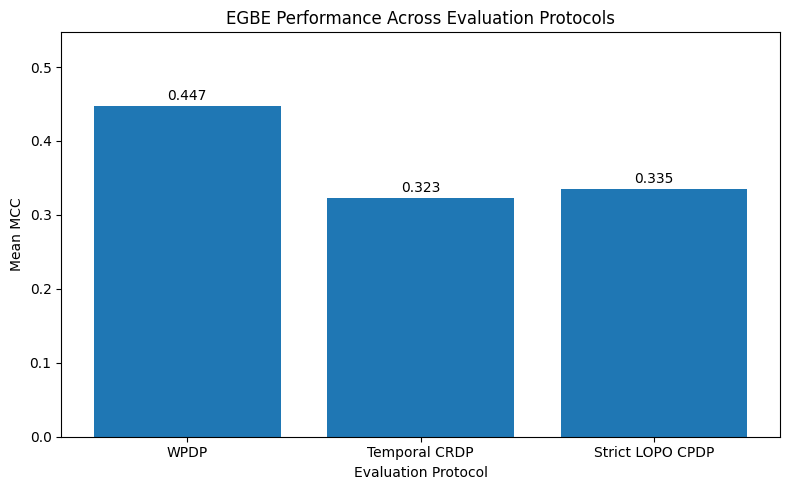

✓ Saved: 01_EGBE_Protocol_MCC.png


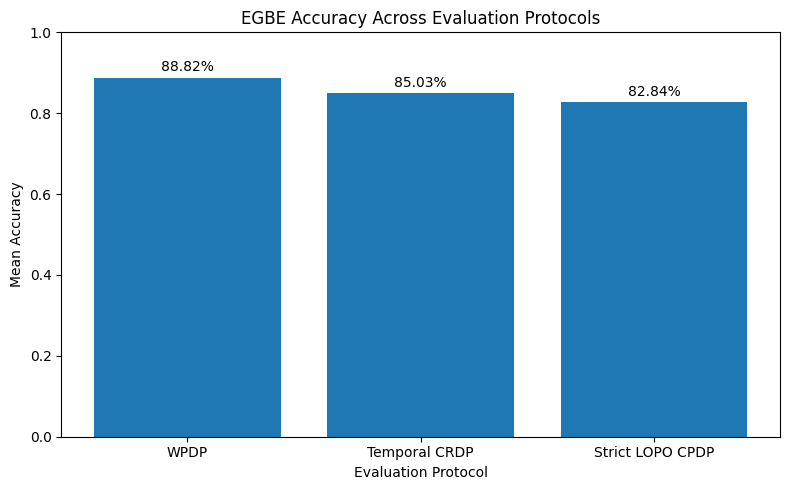

✓ Saved: 02_EGBE_Protocol_Accuracy.png


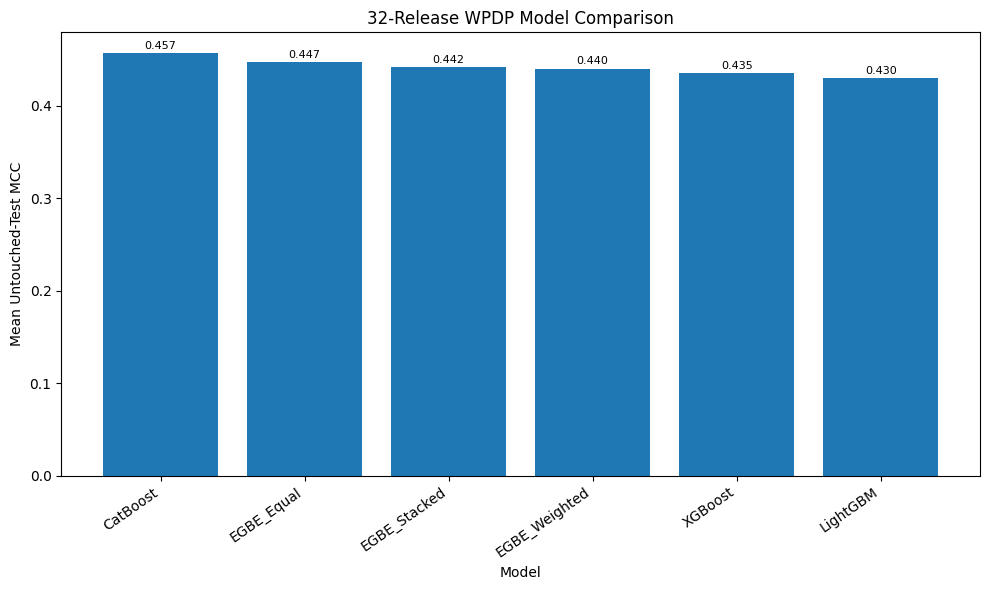

✓ Saved: 03_WPDP_Model_MCC_Comparison.png


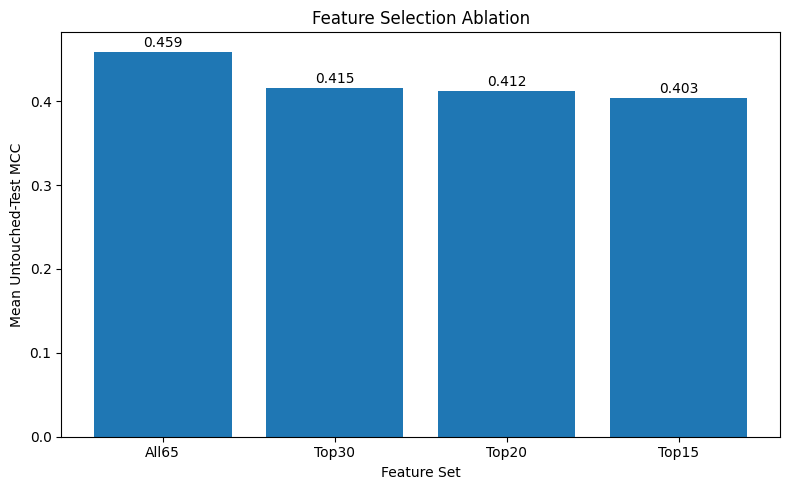

✓ Saved: 04_Feature_Selection_Ablation.png


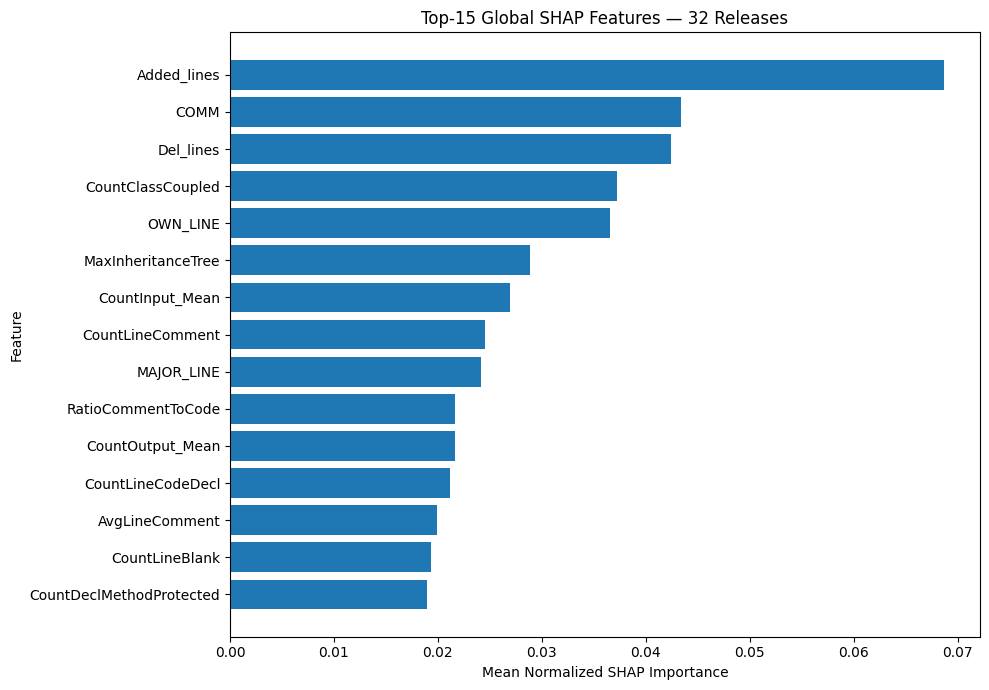

✓ Saved: 05_Top15_Global_SHAP.png


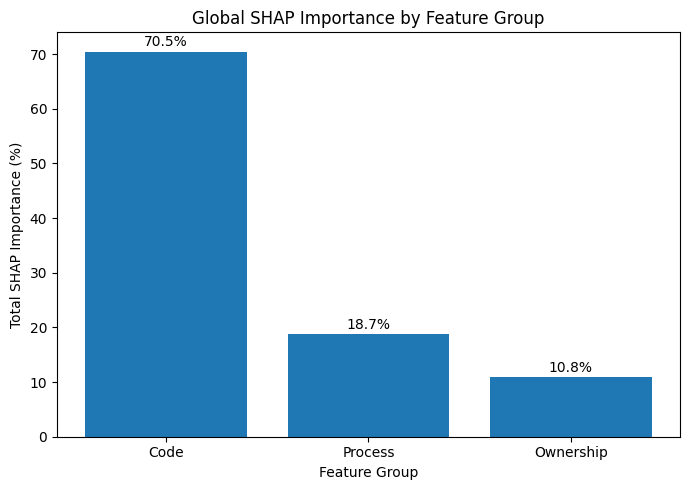

✓ Saved: 06_Feature_Group_SHAP_Importance.png


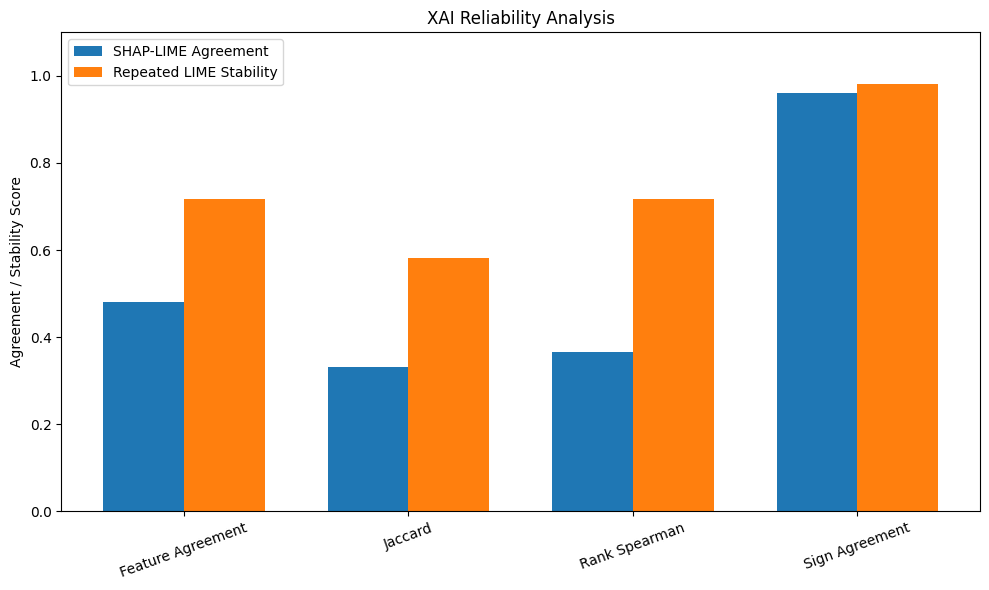

✓ Saved: 07_XAI_Reliability_Comparison.png


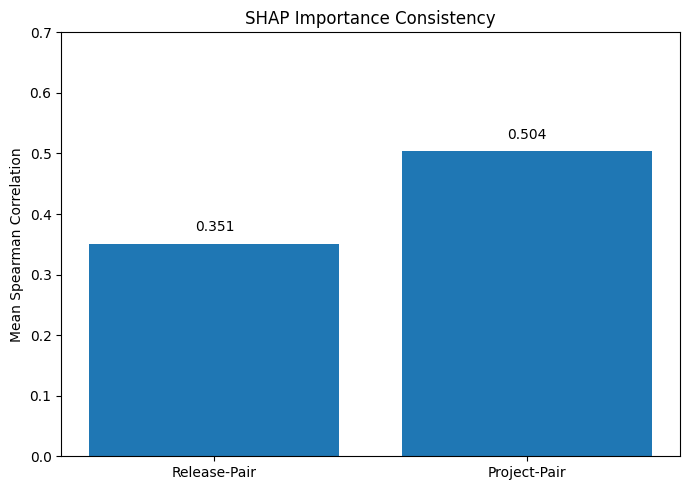

✓ Saved: 08_SHAP_Cross_Context_Consistency.png


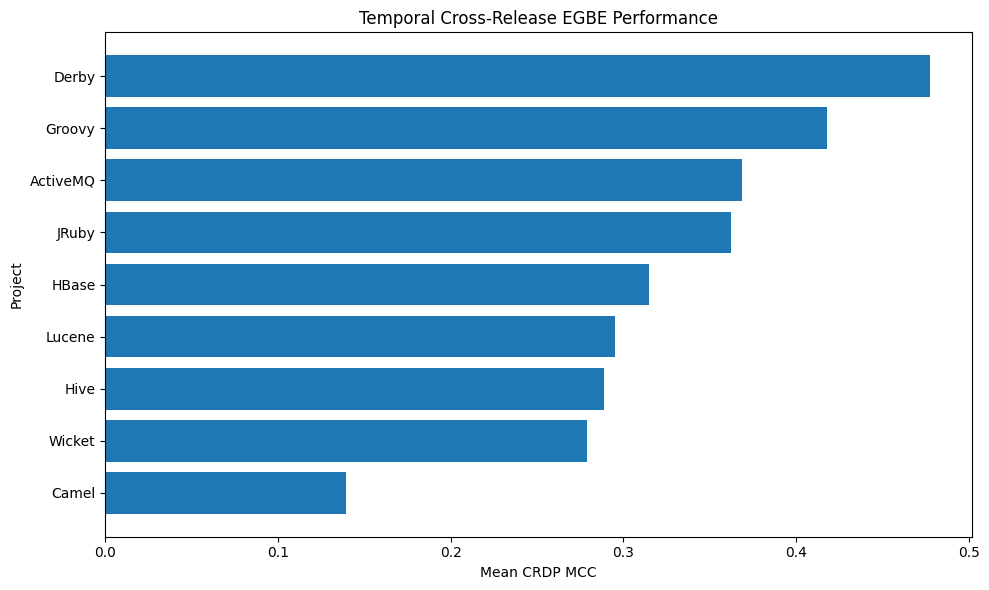

✓ Saved: 09_CRDP_Project_MCC.png


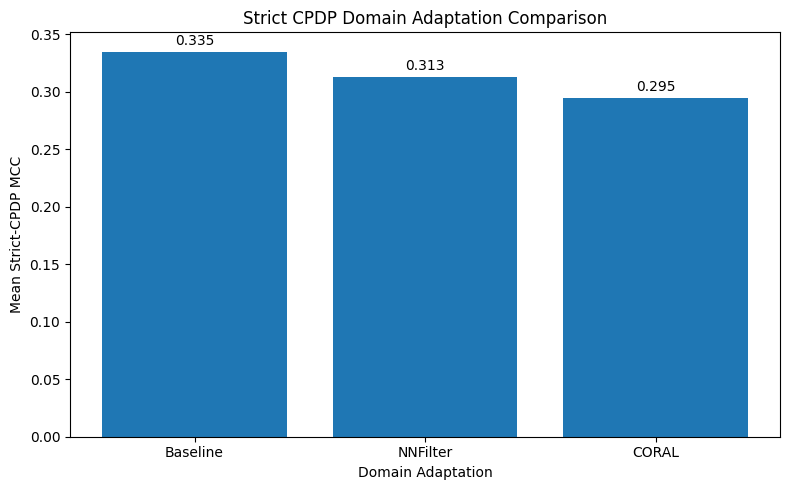

✓ Saved: 10_CPDP_Domain_Adaptation_MCC.png


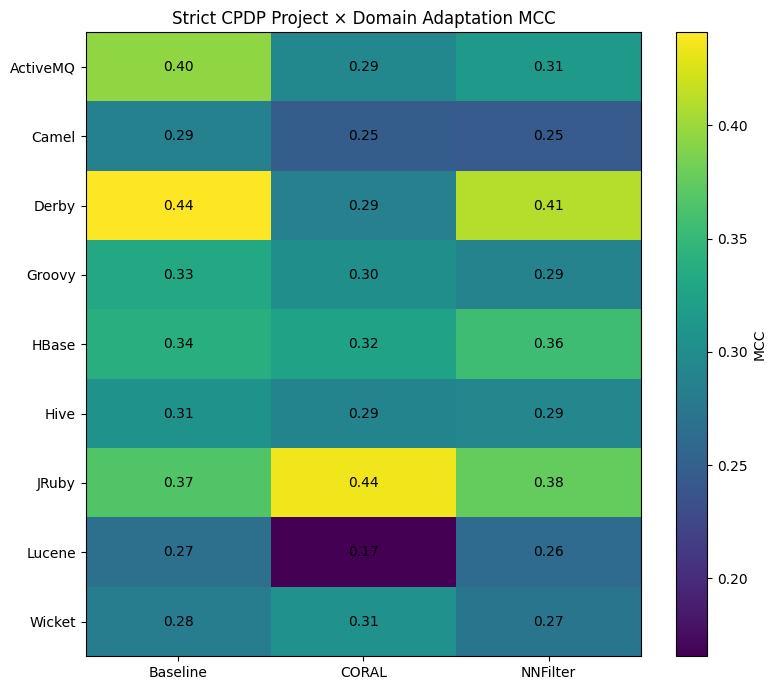

✓ Saved: 11_CPDP_Project_DA_Heatmap.png


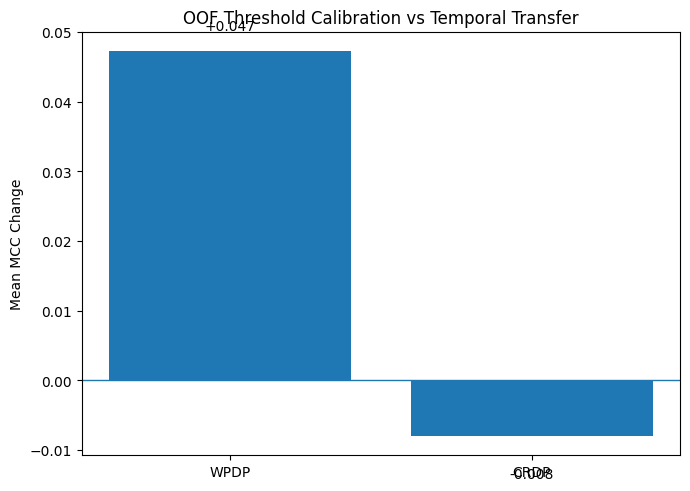

✓ Saved: 12_Threshold_Calibration_Effect.png
✓ Final Markdown summary created


FINAL EGBE PERFORMANCE — EXACT VALUES


,Protocol,Evaluation_Unit,Model,Accuracy,Precision,Recall,F1,MCC,Balanced_Accuracy,ROC_AUC,PR_AUC
0,WPDP,32 Releases,EGBE_Equal,0.888213,0.515059,0.522319,0.506759,0.446911,0.725932,0.862570,0.543548
1,Temporal CRDP,23 Later Releases,EGBE_Equal,0.850264,0.404895,0.468304,0.369581,0.322736,0.676401,0.810804,0.396612
2,Strict LOPO CPDP,9 Target Projects,EGBE_Equal / Baseline DA,0.828367,0.373046,0.526126,0.402055,0.335114,0.696466,0.804462,0.419606




🎯 FINAL ACCURACY ANSWER
WPDP Accuracy        : 88.82%
Temporal CRDP        : 85.03%
Strict LOPO CPDP     : 82.84%

Primary MCC values:
WPDP MCC             : 0.4469
CRDP MCC             : 0.3227
Strict CPDP MCC      : 0.3351


FINAL RESEARCH FINDINGS


,Finding,Result,Primary_Value
0,Feature selection,All65 outperformed reduced Top30/Top20/Top15 f...,0.459153
1,Final ensemble architecture,EGBE_Equal retained after cross-fitted weighti...,0.494677
2,WPDP threshold calibration,"MCC change +0.0473, Wilcoxon p=0.003379",0.047309
3,Temporal generalization,CRDP significantly lower than WPDP on matched ...,-0.078779
4,Strict cross-project DA,Source-only validation selected Baseline for a...,0.335114
5,SHAP-LIME agreement,Moderate feature/rank agreement but very high ...,0.481731
6,LIME stability,Repeated LIME explanations showed relatively s...,0.581838
7,Cross-project explanation consistency,Feature importance remains substantially conte...,0.504014



Top-15 SHAP Features:


,Feature,Feature_Group,Mean_Normalized_Importance,Mean_Abs_SHAP,Mean_Release_Rank,Global_Rank
0,Added_lines,Process,0.068722,0.027791,9.34375,1
1,COMM,Process,0.043363,0.014600,16.37500,2
2,Del_lines,Process,0.042405,0.014719,18.93750,3
3,CountClassCoupled,Code,0.037260,0.012249,13.25000,4
4,OWN_LINE,Ownership,0.036602,0.013465,12.96875,5
5,MaxInheritanceTree,Code,0.028832,0.011634,22.37500,6
6,CountInput_Mean,Code,0.026937,0.008022,16.62500,7
7,CountLineComment,Code,0.024500,0.008189,17.43750,8
8,MAJOR_LINE,Ownership,0.024171,0.009681,24.46875,9
9,RatioCommentToCode,Code,0.021641,0.006805,20.34375,10




✅ FINAL CONSOLIDATION COMPLETED

Master Excel:
/kaggle/working/IA_EGBE_32_RELEASE/12_Final_Tables/IA_EGBE_FINAL_32_RELEASE_MASTER_RESULTS.xlsx

Research Summary:
/kaggle/working/IA_EGBE_32_RELEASE/14_Final_Export/IA_EGBE_FINAL_32_RELEASE_RESEARCH_SUMMARY.md

All Graphs ZIP:
/kaggle/working/IA_EGBE_FINAL_ALL_GRAPHS.zip

Final Paper Package ZIP:
/kaggle/working/IA_EGBE_FINAL_PAPER_PACKAGE.zip

Graphs generated: 12
🎉 ALL MAJOR EXPERIMENTS COMPLETED
WPDP ✓ | CRDP ✓ | Strict CPDP ✓ | XAI ✓ | Statistics ✓ | Graphs ✓ | Export ✓


In [19]:
# =====================================================================
# FINAL CELL — COMPLETE RESEARCH CONSOLIDATION
# =====================================================================
#
# NO MODEL TRAINING
#
# Creates:
#   1. Final WPDP / CRDP / CPDP metric table
#   2. Exact final Accuracy values
#   3. Model / feature / threshold / XAI summaries
#   4. Paper-ready graphs
#   5. Master Excel workbook
#   6. Final Markdown research summary
#   7. Graph ZIP
#   8. Final paper package ZIP
#
# =====================================================================


# =====================================================================
# 0. IMPORTS
# =====================================================================

import json
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# =====================================================================
# 1. ROOT PATHS
# =====================================================================

ROOT = Path(
    "/kaggle/working/IA_EGBE_32_RELEASE"
)

FS_ROOT = (
    ROOT /
    "05_Feature_Selection"
)

CELL4_ROOT = (
    ROOT /
    "15_Cell4_Improved_EGBE"
)

CELL5_ROOT = (
    ROOT /
    "16_Cell5_Statistics"
)

CELL5B_ROOT = (
    ROOT /
    "17_Cell5B_CrossFitted_Weights"
)

CELL6_ROOT = (
    ROOT /
    "18_Cell6_XAI"
)

CELL7_ROOT = (
    ROOT /
    "19_Cell7_CRDP"
)

CELL8_ROOT = (
    ROOT /
    "20_Cell8_Strict_CPDP"
)

FINAL_ROOT = (
    ROOT /
    "21_Final_Consolidation"
)

GRAPH_DIR = (
    ROOT /
    "11_Graphs"
)

TABLE_DIR = (
    ROOT /
    "12_Final_Tables"
)

EXPORT_DIR = (
    ROOT /
    "14_Final_Export"
)


for folder in [
    FINAL_ROOT,
    GRAPH_DIR,
    TABLE_DIR,
    EXPORT_DIR
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# =====================================================================
# 2. HELPERS
# =====================================================================

def read_required(path):

    path = Path(path)

    if not path.exists():

        raise FileNotFoundError(
            f"Required file not found:\n{path}"
        )

    return pd.read_csv(path)


def mean_value(
    df,
    column
):

    if column not in df.columns:

        return np.nan

    return float(
        df[
            column
        ].mean()
    )


def save_current_figure(
    filename
):

    path = (
        GRAPH_DIR /
        filename
    )

    plt.tight_layout()

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    print(
        "✓ Saved:",
        path.name
    )


# =====================================================================
# 3. LOAD ALL MAJOR RESULTS
# =====================================================================

FS_TEST = read_required(

    FS_ROOT /
    "FS_TEST_ALL_RESULTS.csv"
)


C4_TEST = read_required(

    CELL4_ROOT /
    "CELL4_ALL_TEST_RESULTS.csv"
)


C4_OOF = read_required(

    CELL4_ROOT /
    "CELL4_ALL_OOF_RESULTS.csv"
)


C5_THRESHOLD = read_required(

    CELL5_ROOT /
    "10_THRESHOLD_ANALYSIS.csv"
)


C5_MODEL_RANKING = read_required(

    CELL5_ROOT /
    "01_RELEASE_MODEL_RANKING.csv"
)


C5_PIPELINE_DELTA = read_required(

    CELL5_ROOT /
    "07_CELL3_VS_CELL4_PIPELINE_DELTA.csv"
)


C5B_OOF = read_required(

    CELL5B_ROOT /
    "04_CORRECTED_EGBE_OOF_SUMMARY.csv"
)


C5B_TEST = read_required(

    CELL5B_ROOT /
    "05_CORRECTED_EGBE_TEST_SUMMARY.csv"
)


SHAP_GLOBAL = read_required(

    CELL6_ROOT /
    "02_OVERALL_SHAP_32_RELEASES.csv"
)


FEATURE_GROUPS = read_required(

    CELL6_ROOT /
    "04_FEATURE_GROUP_IMPORTANCE.csv"
)


XAI_AGREEMENT = read_required(

    CELL6_ROOT /
    "06_SHAP_LIME_AGREEMENT_SUMMARY.csv"
)


LIME_STABILITY = read_required(

    CELL6_ROOT /
    "08_LIME_STABILITY_SUMMARY.csv"
)


SHAP_CONSISTENCY = read_required(

    CELL6_ROOT /
    "11_SHAP_CONSISTENCY_SUMMARY.csv"
)


XAI_CONSENSUS = read_required(

    CELL6_ROOT /
    "12_MATCHED9_XAI_CONSENSUS.csv"
)


MODEL_VERIFICATION = read_required(

    CELL6_ROOT /
    "13_MODEL_RECONSTRUCTION_VERIFICATION.csv"
)


CRDP_RESULTS = read_required(

    CELL7_ROOT /
    "01_CRDP_ALL_MODEL_RESULTS.csv"
)


CRDP_MODEL_SUMMARY = read_required(

    CELL7_ROOT /
    "03_CRDP_MODEL_SUMMARY.csv"
)


CRDP_PROJECT_SUMMARY = read_required(

    CELL7_ROOT /
    "04_CRDP_PROJECT_SUMMARY.csv"
)


CRDP_THRESHOLD = read_required(

    CELL7_ROOT /
    "07_CRDP_THRESHOLD_EFFECT.csv"
)


CRDP_VS_WPDP = read_required(

    CELL7_ROOT /
    "10_WPDP_VS_CRDP_SUMMARY.csv"
)


CPDP_PROJECT_RESULTS = read_required(

    CELL8_ROOT /
    "01_CPDP_PROJECT_RESULTS.csv"
)


CPDP_DA_SUMMARY = read_required(

    CELL8_ROOT /
    "05_EGBE_DA_SUMMARY.csv"
)


CPDP_DA_STATS = read_required(

    CELL8_ROOT /
    "06_DA_PAIRWISE_STATISTICS.csv"
)


CPDP_MODEL_DA = read_required(

    CELL8_ROOT /
    "07_MODEL_DA_SUMMARY.csv"
)


CPDP_DA_FREQUENCY = read_required(

    CELL8_ROOT /
    "08_DA_SELECTION_FREQUENCY.csv"
)


# =====================================================================
# 4. FINAL WPDP EGBE
# =====================================================================
#
# Final fair development selection from Cell 5B:
# EGBE_Equal
#
# Cell 4 contains its untouched-test metrics.
# =====================================================================

WPDP_FINAL = (

    C4_TEST[
        C4_TEST[
            "Model"
        ]
        ==
        "EGBE_Equal"
    ]

    .copy()
)


assert len(
    WPDP_FINAL
) == 32


# =====================================================================
# 5. CELL 3 ALL65 BASELINE
# =====================================================================

WPDP_CELL3_BASELINE = (

    FS_TEST[
        FS_TEST[
            "Feature_Set"
        ]
        ==
        "All65"
    ]

    .copy()
)


assert len(
    WPDP_CELL3_BASELINE
) == 32


# =====================================================================
# 6. CRDP FINAL EGBE
# =====================================================================

CRDP_FINAL = (

    CRDP_MODEL_SUMMARY[
        CRDP_MODEL_SUMMARY[
            "Model"
        ]
        ==
        "EGBE_Equal"
    ]

    .iloc[
        0
    ]
)


# =====================================================================
# 7. STRICT CPDP FINAL
# =====================================================================
#
# Source-only validation selected Baseline for 9/9 projects.
# =====================================================================

CPDP_FINAL = (

    CPDP_DA_SUMMARY[
        CPDP_DA_SUMMARY[
            "DA_Method"
        ]
        ==
        "Baseline"
    ]

    .iloc[
        0
    ]
)


# =====================================================================
# 8. FINAL PROTOCOL PERFORMANCE TABLE
# =====================================================================

FINAL_PROTOCOL_PERFORMANCE = pd.DataFrame(
    [

        {
            "Protocol":
                "WPDP",

            "Evaluation_Unit":
                "32 Releases",

            "Model":
                "EGBE_Equal",

            "Accuracy":
                mean_value(
                    WPDP_FINAL,
                    "Test_Accuracy"
                ),

            "Precision":
                mean_value(
                    WPDP_FINAL,
                    "Test_Precision"
                ),

            "Recall":
                mean_value(
                    WPDP_FINAL,
                    "Test_Recall"
                ),

            "F1":
                mean_value(
                    WPDP_FINAL,
                    "Test_F1"
                ),

            "MCC":
                mean_value(
                    WPDP_FINAL,
                    "Test_MCC"
                ),

            "Balanced_Accuracy":
                mean_value(
                    WPDP_FINAL,
                    "Test_Balanced_Accuracy"
                ),

            "ROC_AUC":
                mean_value(
                    WPDP_FINAL,
                    "Test_ROC_AUC"
                ),

            "PR_AUC":
                mean_value(
                    WPDP_FINAL,
                    "Test_PR_AUC"
                )
        },


        {
            "Protocol":
                "Temporal CRDP",

            "Evaluation_Unit":
                "23 Later Releases",

            "Model":
                "EGBE_Equal",

            "Accuracy":
                float(
                    CRDP_FINAL[
                        "Mean_Accuracy"
                    ]
                ),

            "Precision":
                float(
                    CRDP_FINAL[
                        "Mean_Precision"
                    ]
                ),

            "Recall":
                float(
                    CRDP_FINAL[
                        "Mean_Recall"
                    ]
                ),

            "F1":
                float(
                    CRDP_FINAL[
                        "Mean_F1"
                    ]
                ),

            "MCC":
                float(
                    CRDP_FINAL[
                        "Mean_MCC"
                    ]
                ),

            "Balanced_Accuracy":
                float(
                    CRDP_FINAL[
                        "Mean_Balanced_Accuracy"
                    ]
                ),

            "ROC_AUC":
                float(
                    CRDP_FINAL[
                        "Mean_ROC_AUC"
                    ]
                ),

            "PR_AUC":
                float(
                    CRDP_FINAL[
                        "Mean_PR_AUC"
                    ]
                )
        },


        {
            "Protocol":
                "Strict LOPO CPDP",

            "Evaluation_Unit":
                "9 Target Projects",

            "Model":
                "EGBE_Equal / Baseline DA",

            "Accuracy":
                float(
                    CPDP_FINAL[
                        "Mean_Accuracy"
                    ]
                ),

            "Precision":
                float(
                    CPDP_FINAL[
                        "Mean_Precision"
                    ]
                ),

            "Recall":
                float(
                    CPDP_FINAL[
                        "Mean_Recall"
                    ]
                ),

            "F1":
                float(
                    CPDP_FINAL[
                        "Mean_F1"
                    ]
                ),

            "MCC":
                float(
                    CPDP_FINAL[
                        "Mean_MCC"
                    ]
                ),

            "Balanced_Accuracy":
                float(
                    CPDP_FINAL[
                        "Mean_Balanced_Accuracy"
                    ]
                ),

            "ROC_AUC":
                float(
                    CPDP_FINAL[
                        "Mean_ROC_AUC"
                    ]
                ),

            "PR_AUC":
                float(
                    CPDP_FINAL[
                        "Mean_PR_AUC"
                    ]
                )
        }
    ]
)


# =====================================================================
# 9. CELL 3 FEATURE ABLATION SUMMARY
# =====================================================================

FEATURE_ABLATION = (

    FS_TEST

    .groupby(
        "Feature_Set",
        as_index=False
    )

    .agg(

        Mean_MCC=(
            "Test_MCC_Optimized",
            "mean"
        ),

        Std_MCC=(
            "Test_MCC_Optimized",
            "std"
        ),

        Mean_F1=(
            "Test_F1_Optimized",
            "mean"
        ),

        Mean_Recall=(
            "Test_Recall_Optimized",
            "mean"
        ),

        Mean_Precision=(
            "Test_Precision_Optimized",
            "mean"
        ),

        Mean_Balanced_Accuracy=(
            "Test_Balanced_Accuracy_Optimized",
            "mean"
        ),

        Mean_ROC_AUC=(
            "Test_ROC_AUC_Optimized",
            "mean"
        ),

        Mean_PR_AUC=(
            "Test_PR_AUC_Optimized",
            "mean"
        )
    )

    .sort_values(
        "Mean_MCC",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 10. WPDP FINAL MODEL COMPARISON
# =====================================================================

WPDP_MODEL_SUMMARY = (

    C4_TEST

    .groupby(
        "Model",
        as_index=False
    )

    .agg(

        Mean_Accuracy=(
            "Test_Accuracy",
            "mean"
        ),

        Mean_F1=(
            "Test_F1",
            "mean"
        ),

        Mean_MCC=(
            "Test_MCC",
            "mean"
        ),

        Std_MCC=(
            "Test_MCC",
            "std"
        ),

        Mean_Balanced_Accuracy=(
            "Test_Balanced_Accuracy",
            "mean"
        ),

        Mean_ROC_AUC=(
            "Test_ROC_AUC",
            "mean"
        ),

        Mean_PR_AUC=(
            "Test_PR_AUC",
            "mean"
        )
    )

    .sort_values(
        "Mean_MCC",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# =====================================================================
# 11. FINAL RESEARCH FINDINGS TABLE
# =====================================================================

wpdp_threshold_delta = float(
    C5_THRESHOLD.iloc[0][
        "Mean_MCC_Delta"
    ]
)

wpdp_threshold_p = float(
    C5_THRESHOLD.iloc[0][
        "Wilcoxon_P"
    ]
)


crdp_release_comparison = (

    CRDP_VS_WPDP[
        CRDP_VS_WPDP[
            "Scope"
        ]
        ==
        "23_Target_Releases"
    ]

    .iloc[0]
)


crdp_project_comparison = (

    CRDP_VS_WPDP[
        CRDP_VS_WPDP[
            "Scope"
        ]
        ==
        "9_Project_Means"
    ]

    .iloc[0]
)


overall_xai = (

    XAI_AGREEMENT[
        XAI_AGREEMENT[
            "Scope"
        ]
        ==
        "Overall"
    ]

    .iloc[0]
)


overall_lime = (

    LIME_STABILITY[
        LIME_STABILITY[
            "Scope"
        ]
        ==
        "Overall"
    ]

    .iloc[0]
)


release_consistency = (

    SHAP_CONSISTENCY[
        SHAP_CONSISTENCY[
            "Scope"
        ]
        ==
        "Release-Pair"
    ]

    .iloc[0]
)


project_consistency = (

    SHAP_CONSISTENCY[
        SHAP_CONSISTENCY[
            "Scope"
        ]
        ==
        "Project-Pair"
    ]

    .iloc[0]
)


FINAL_FINDINGS = pd.DataFrame(
    [

        {
            "Finding":
                "Feature selection",

            "Result":
                (
                    "All65 outperformed reduced "
                    "Top30/Top20/Top15 feature sets."
                ),

            "Primary_Value":
                float(
                    FEATURE_ABLATION.iloc[0][
                        "Mean_MCC"
                    ]
                )
        },


        {
            "Finding":
                "Final ensemble architecture",

            "Result":
                (
                    "EGBE_Equal retained after "
                    "cross-fitted weighting correction."
                ),

            "Primary_Value":
                float(
                    C5B_OOF.loc[
                        C5B_OOF[
                            "Model"
                        ]
                        ==
                        "EGBE_Equal",

                        "Mean_OOF_MCC"
                    ].iloc[0]
                )
        },


        {
            "Finding":
                "WPDP threshold calibration",

            "Result":
                (
                    f"MCC change {wpdp_threshold_delta:+.4f}, "
                    f"Wilcoxon p={wpdp_threshold_p:.6f}"
                ),

            "Primary_Value":
                wpdp_threshold_delta
        },


        {
            "Finding":
                "Temporal generalization",

            "Result":
                (
                    "CRDP significantly lower than WPDP "
                    "on matched target releases."
                ),

            "Primary_Value":
                float(
                    crdp_release_comparison[
                        "Mean_Delta"
                    ]
                )
        },


        {
            "Finding":
                "Strict cross-project DA",

            "Result":
                (
                    "Source-only validation selected "
                    "Baseline for all 9 target projects."
                ),

            "Primary_Value":
                float(
                    CPDP_FINAL[
                        "Mean_MCC"
                    ]
                )
        },


        {
            "Finding":
                "SHAP-LIME agreement",

            "Result":
                (
                    "Moderate feature/rank agreement "
                    "but very high sign agreement."
                ),

            "Primary_Value":
                float(
                    overall_xai[
                        "Mean_Feature_Agreement"
                    ]
                )
        },


        {
            "Finding":
                "LIME stability",

            "Result":
                (
                    "Repeated LIME explanations "
                    "showed relatively strong stability."
                ),

            "Primary_Value":
                float(
                    overall_lime[
                        "Jaccard"
                    ]
                )
        },


        {
            "Finding":
                "Cross-project explanation consistency",

            "Result":
                (
                    "Feature importance remains "
                    "substantially context dependent."
                ),

            "Primary_Value":
                float(
                    project_consistency[
                        "Mean_Spearman"
                    ]
                )
        }
    ]
)


# =====================================================================
# 12. SAVE FINAL CSV TABLES
# =====================================================================

FINAL_PROTOCOL_PERFORMANCE.to_csv(

    FINAL_ROOT /
    "01_FINAL_PROTOCOL_PERFORMANCE.csv",

    index=False
)


WPDP_MODEL_SUMMARY.to_csv(

    FINAL_ROOT /
    "02_FINAL_WPDP_MODEL_SUMMARY.csv",

    index=False
)


FEATURE_ABLATION.to_csv(

    FINAL_ROOT /
    "03_FINAL_FEATURE_ABLATION.csv",

    index=False
)


FINAL_FINDINGS.to_csv(

    FINAL_ROOT /
    "04_FINAL_RESEARCH_FINDINGS.csv",

    index=False
)


# =====================================================================
# 13. GRAPH 1 — PROTOCOL MCC
# =====================================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(

    FINAL_PROTOCOL_PERFORMANCE[
        "Protocol"
    ],

    FINAL_PROTOCOL_PERFORMANCE[
        "MCC"
    ]
)

plt.ylabel(
    "Mean MCC"
)

plt.xlabel(
    "Evaluation Protocol"
)

plt.title(
    "EGBE Performance Across Evaluation Protocols"
)

plt.ylim(
    0,
    max(
        FINAL_PROTOCOL_PERFORMANCE[
            "MCC"
        ]
    )
    +
    0.10
)


for i, value in enumerate(
    FINAL_PROTOCOL_PERFORMANCE[
        "MCC"
    ]
):

    plt.text(
        i,
        value + 0.008,
        f"{value:.3f}",
        ha="center"
    )


save_current_figure(
    "01_EGBE_Protocol_MCC.png"
)


# =====================================================================
# 14. GRAPH 2 — PROTOCOL ACCURACY
# =====================================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(

    FINAL_PROTOCOL_PERFORMANCE[
        "Protocol"
    ],

    FINAL_PROTOCOL_PERFORMANCE[
        "Accuracy"
    ]
)

plt.ylabel(
    "Mean Accuracy"
)

plt.xlabel(
    "Evaluation Protocol"
)

plt.title(
    "EGBE Accuracy Across Evaluation Protocols"
)

plt.ylim(
    0,
    1
)


for i, value in enumerate(
    FINAL_PROTOCOL_PERFORMANCE[
        "Accuracy"
    ]
):

    plt.text(
        i,
        value + 0.015,
        f"{value*100:.2f}%",
        ha="center"
    )


save_current_figure(
    "02_EGBE_Protocol_Accuracy.png"
)


# =====================================================================
# 15. GRAPH 3 — WPDP MODEL MCC
# =====================================================================

plt.figure(
    figsize=(10, 6)
)

plot_df = (

    WPDP_MODEL_SUMMARY

    .sort_values(
        "Mean_MCC",
        ascending=False
    )
)


plt.bar(

    plot_df[
        "Model"
    ],

    plot_df[
        "Mean_MCC"
    ]
)

plt.ylabel(
    "Mean Untouched-Test MCC"
)

plt.xlabel(
    "Model"
)

plt.title(
    "32-Release WPDP Model Comparison"
)

plt.xticks(
    rotation=35,
    ha="right"
)


for i, value in enumerate(
    plot_df[
        "Mean_MCC"
    ]
):

    plt.text(
        i,
        value + 0.005,
        f"{value:.3f}",
        ha="center",
        fontsize=8
    )


save_current_figure(
    "03_WPDP_Model_MCC_Comparison.png"
)


# =====================================================================
# 16. GRAPH 4 — FEATURE ABLATION
# =====================================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(

    FEATURE_ABLATION[
        "Feature_Set"
    ],

    FEATURE_ABLATION[
        "Mean_MCC"
    ]
)

plt.ylabel(
    "Mean Untouched-Test MCC"
)

plt.xlabel(
    "Feature Set"
)

plt.title(
    "Feature Selection Ablation"
)


for i, value in enumerate(
    FEATURE_ABLATION[
        "Mean_MCC"
    ]
):

    plt.text(
        i,
        value + 0.006,
        f"{value:.3f}",
        ha="center"
    )


save_current_figure(
    "04_Feature_Selection_Ablation.png"
)


# =====================================================================
# 17. GRAPH 5 — TOP-15 SHAP
# =====================================================================

TOP15_SHAP = (

    SHAP_GLOBAL

    .sort_values(
        "Global_Rank"
    )

    .head(
        15
    )

    .sort_values(
        "Mean_Normalized_Importance"
    )
)


plt.figure(
    figsize=(10, 7)
)

plt.barh(

    TOP15_SHAP[
        "Feature"
    ],

    TOP15_SHAP[
        "Mean_Normalized_Importance"
    ]
)

plt.xlabel(
    "Mean Normalized SHAP Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top-15 Global SHAP Features — 32 Releases"
)


save_current_figure(
    "05_Top15_Global_SHAP.png"
)


# =====================================================================
# 18. GRAPH 6 — FEATURE GROUP IMPORTANCE
# =====================================================================

plt.figure(
    figsize=(7, 5)
)

plt.bar(

    FEATURE_GROUPS[
        "Feature_Group"
    ],

    FEATURE_GROUPS[
        "Total_Importance_Percent"
    ]
)

plt.ylabel(
    "Total SHAP Importance (%)"
)

plt.xlabel(
    "Feature Group"
)

plt.title(
    "Global SHAP Importance by Feature Group"
)


for i, value in enumerate(
    FEATURE_GROUPS[
        "Total_Importance_Percent"
    ]
):

    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )


save_current_figure(
    "06_Feature_Group_SHAP_Importance.png"
)


# =====================================================================
# 19. GRAPH 7 — SHAP-LIME AGREEMENT VS LIME STABILITY
# =====================================================================

xai_metrics = [
    "Feature Agreement",
    "Jaccard",
    "Rank Spearman",
    "Sign Agreement"
]


agreement_values = [

    float(
        overall_xai[
            "Mean_Feature_Agreement"
        ]
    ),

    float(
        overall_xai[
            "Mean_Jaccard"
        ]
    ),

    float(
        overall_xai[
            "Mean_Rank_Spearman"
        ]
    ),

    float(
        overall_xai[
            "Mean_Sign_Agreement"
        ]
    )
]


stability_values = [

    float(
        overall_lime[
            "Feature_Agreement"
        ]
    ),

    float(
        overall_lime[
            "Jaccard"
        ]
    ),

    float(
        overall_lime[
            "Rank_Spearman"
        ]
    ),

    float(
        overall_lime[
            "Sign_Agreement"
        ]
    )
]


x = np.arange(
    len(
        xai_metrics
    )
)

width = 0.36


plt.figure(
    figsize=(10, 6)
)

plt.bar(
    x - width / 2,
    agreement_values,
    width,
    label="SHAP-LIME Agreement"
)

plt.bar(
    x + width / 2,
    stability_values,
    width,
    label="Repeated LIME Stability"
)

plt.xticks(
    x,
    xai_metrics,
    rotation=20
)

plt.ylim(
    0,
    1.10
)

plt.ylabel(
    "Agreement / Stability Score"
)

plt.title(
    "XAI Reliability Analysis"
)

plt.legend()


save_current_figure(
    "07_XAI_Reliability_Comparison.png"
)


# =====================================================================
# 20. GRAPH 8 — SHAP CONSISTENCY
# =====================================================================

plt.figure(
    figsize=(7, 5)
)

plt.bar(

    SHAP_CONSISTENCY[
        "Scope"
    ],

    SHAP_CONSISTENCY[
        "Mean_Spearman"
    ]
)

plt.ylabel(
    "Mean Spearman Correlation"
)

plt.title(
    "SHAP Importance Consistency"
)

plt.ylim(
    0,
    0.7
)


for i, value in enumerate(
    SHAP_CONSISTENCY[
        "Mean_Spearman"
    ]
):

    plt.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )


save_current_figure(
    "08_SHAP_Cross_Context_Consistency.png"
)


# =====================================================================
# 21. GRAPH 9 — CRDP PROJECT MCC
# =====================================================================

plot_df = (

    CRDP_PROJECT_SUMMARY

    .sort_values(
        "Mean_MCC"
    )
)


plt.figure(
    figsize=(10, 6)
)

plt.barh(

    plot_df[
        "Project"
    ],

    plot_df[
        "Mean_MCC"
    ]
)

plt.xlabel(
    "Mean CRDP MCC"
)

plt.ylabel(
    "Project"
)

plt.title(
    "Temporal Cross-Release EGBE Performance"
)


save_current_figure(
    "09_CRDP_Project_MCC.png"
)


# =====================================================================
# 22. GRAPH 10 — CPDP DA COMPARISON
# =====================================================================

cpdp_plot = (

    CPDP_DA_SUMMARY[
        CPDP_DA_SUMMARY[
            "DA_Method"
        ]
        .isin(
            [
                "Baseline",
                "CORAL",
                "NNFilter"
            ]
        )
    ]

    .copy()
)


plt.figure(
    figsize=(8, 5)
)

plt.bar(

    cpdp_plot[
        "DA_Method"
    ],

    cpdp_plot[
        "Mean_MCC"
    ]
)

plt.ylabel(
    "Mean Strict-CPDP MCC"
)

plt.xlabel(
    "Domain Adaptation"
)

plt.title(
    "Strict CPDP Domain Adaptation Comparison"
)


for i, value in enumerate(
    cpdp_plot[
        "Mean_MCC"
    ]
):

    plt.text(
        i,
        value + 0.006,
        f"{value:.3f}",
        ha="center"
    )


save_current_figure(
    "10_CPDP_Domain_Adaptation_MCC.png"
)


# =====================================================================
# 23. GRAPH 11 — CPDP PROJECT × DA HEATMAP
# =====================================================================

cpdp_egbe = (

    CPDP_PROJECT_RESULTS[
        CPDP_PROJECT_RESULTS[
            "Model"
        ]
        ==
        "EGBE_Equal"
    ]

    .copy()
)


CPDP_MATRIX = (

    cpdp_egbe

    .pivot(
        index="Target_Project",
        columns="DA_Method",
        values="Target_MCC"
    )

    [
        [
            "Baseline",
            "CORAL",
            "NNFilter"
        ]
    ]
)


matrix = (
    CPDP_MATRIX
    .to_numpy()
)


plt.figure(
    figsize=(8, 7)
)

plt.imshow(
    matrix,
    aspect="auto"
)

plt.colorbar(
    label="MCC"
)

plt.xticks(
    np.arange(
        len(
            CPDP_MATRIX.columns
        )
    ),
    CPDP_MATRIX.columns
)

plt.yticks(
    np.arange(
        len(
            CPDP_MATRIX.index
        )
    ),
    CPDP_MATRIX.index
)

plt.title(
    "Strict CPDP Project × Domain Adaptation MCC"
)


for i in range(
    matrix.shape[
        0
    ]
):

    for j in range(
        matrix.shape[
            1
        ]
    ):

        plt.text(
            j,
            i,
            f"{matrix[i, j]:.2f}",
            ha="center",
            va="center"
        )


save_current_figure(
    "11_CPDP_Project_DA_Heatmap.png"
)


# =====================================================================
# 24. GRAPH 12 — THRESHOLD TRANSFER
# =====================================================================

threshold_df = pd.DataFrame({

    "Protocol": [
        "WPDP",
        "CRDP"
    ],

    "MCC_Delta": [

        float(
            C5_THRESHOLD.iloc[0][
                "Mean_MCC_Delta"
            ]
        ),

        float(
            CRDP_THRESHOLD.iloc[0][
                "Mean_Delta"
            ]
        )
    ]
})


plt.figure(
    figsize=(7, 5)
)

plt.bar(

    threshold_df[
        "Protocol"
    ],

    threshold_df[
        "MCC_Delta"
    ]
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel(
    "Mean MCC Change"
)

plt.title(
    "OOF Threshold Calibration vs Temporal Transfer"
)


for i, value in enumerate(
    threshold_df[
        "MCC_Delta"
    ]
):

    plt.text(
        i,
        value + (
            0.003
            if value >= 0
            else -0.006
        ),
        f"{value:+.3f}",
        ha="center"
    )


save_current_figure(
    "12_Threshold_Calibration_Effect.png"
)


# =====================================================================
# 25. FINAL MASTER EXCEL
# =====================================================================

MASTER_EXCEL = (

    TABLE_DIR /
    "IA_EGBE_FINAL_32_RELEASE_MASTER_RESULTS.xlsx"
)


with pd.ExcelWriter(
    MASTER_EXCEL,
    engine="openpyxl"
) as writer:


    FINAL_PROTOCOL_PERFORMANCE.to_excel(
        writer,
        sheet_name="Final Protocol Metrics",
        index=False
    )


    FINAL_FINDINGS.to_excel(
        writer,
        sheet_name="Final Findings",
        index=False
    )


    WPDP_MODEL_SUMMARY.to_excel(
        writer,
        sheet_name="WPDP Model Summary",
        index=False
    )


    FEATURE_ABLATION.to_excel(
        writer,
        sheet_name="Feature Ablation",
        index=False
    )


    C5_THRESHOLD.to_excel(
        writer,
        sheet_name="WPDP Threshold",
        index=False
    )


    C5_MODEL_RANKING.to_excel(
        writer,
        sheet_name="WPDP Statistics",
        index=False
    )


    C5_PIPELINE_DELTA.to_excel(
        writer,
        sheet_name="Pipeline Ablation",
        index=False
    )


    C5B_OOF.to_excel(
        writer,
        sheet_name="Corrected Ensemble OOF",
        index=False
    )


    C5B_TEST.to_excel(
        writer,
        sheet_name="Corrected Ensemble Test",
        index=False
    )


    SHAP_GLOBAL.head(
        65
    ).to_excel(
        writer,
        sheet_name="Global SHAP",
        index=False
    )


    FEATURE_GROUPS.to_excel(
        writer,
        sheet_name="SHAP Groups",
        index=False
    )


    XAI_AGREEMENT.to_excel(
        writer,
        sheet_name="SHAP LIME",
        index=False
    )


    LIME_STABILITY.to_excel(
        writer,
        sheet_name="LIME Stability",
        index=False
    )


    SHAP_CONSISTENCY.to_excel(
        writer,
        sheet_name="SHAP Consistency",
        index=False
    )


    XAI_CONSENSUS.head(
        30
    ).to_excel(
        writer,
        sheet_name="XAI Consensus",
        index=False
    )


    CRDP_MODEL_SUMMARY.to_excel(
        writer,
        sheet_name="CRDP Model Summary",
        index=False
    )


    CRDP_PROJECT_SUMMARY.to_excel(
        writer,
        sheet_name="CRDP Projects",
        index=False
    )


    CRDP_THRESHOLD.to_excel(
        writer,
        sheet_name="CRDP Threshold",
        index=False
    )


    CRDP_VS_WPDP.to_excel(
        writer,
        sheet_name="WPDP vs CRDP",
        index=False
    )


    CPDP_DA_SUMMARY.to_excel(
        writer,
        sheet_name="CPDP DA Summary",
        index=False
    )


    CPDP_MODEL_DA.to_excel(
        writer,
        sheet_name="CPDP Model DA",
        index=False
    )


    CPDP_DA_STATS.to_excel(
        writer,
        sheet_name="CPDP DA Statistics",
        index=False
    )


    CPDP_DA_FREQUENCY.to_excel(
        writer,
        sheet_name="CPDP DA Frequency",
        index=False
    )


    CPDP_MATRIX.reset_index().to_excel(
        writer,
        sheet_name="CPDP Project Matrix",
        index=False
    )


# =====================================================================
# 26. EXTRACT FINAL NUMBERS
# =====================================================================

wpdp_row = (

    FINAL_PROTOCOL_PERFORMANCE[
        FINAL_PROTOCOL_PERFORMANCE[
            "Protocol"
        ]
        ==
        "WPDP"
    ]

    .iloc[0]
)


crdp_row = (

    FINAL_PROTOCOL_PERFORMANCE[
        FINAL_PROTOCOL_PERFORMANCE[
            "Protocol"
        ]
        ==
        "Temporal CRDP"
    ]

    .iloc[0]
)


cpdp_row = (

    FINAL_PROTOCOL_PERFORMANCE[
        FINAL_PROTOCOL_PERFORMANCE[
            "Protocol"
        ]
        ==
        "Strict LOPO CPDP"
    ]

    .iloc[0]
)


top_features = (

    SHAP_GLOBAL

    .sort_values(
        "Global_Rank"
    )

    .head(
        10
    )[
        "Feature"
    ]

    .tolist()
)


# =====================================================================
# 27. CREATE PAPER-READY MARKDOWN SUMMARY
# =====================================================================

SUMMARY_MD = (

    EXPORT_DIR /
    "IA_EGBE_FINAL_32_RELEASE_RESEARCH_SUMMARY.md"
)


summary_text = f"""
# IA-EGBE / EGBE — Final 32-Release Research Summary

## 1. Experimental Scope

The final study evaluates software defect prediction across:

- 32 JIRA software releases
- 9 open-source software projects
- 65 software metrics
- Code, process, and ownership feature groups
- Binary target: RealBug

The main ensemble is EGBE Equal Soft Voting:

XGBoost + LightGBM + CatBoost

MCC is treated as the primary evaluation metric because the datasets are highly imbalanced.

---

## 2. Final Protocol Performance

### WPDP — Within-Project Defect Prediction

Accuracy: {wpdp_row['Accuracy']:.4f} ({wpdp_row['Accuracy']*100:.2f}%)
Precision: {wpdp_row['Precision']:.4f}
Recall: {wpdp_row['Recall']:.4f}
F1: {wpdp_row['F1']:.4f}
MCC: {wpdp_row['MCC']:.4f}
Balanced Accuracy: {wpdp_row['Balanced_Accuracy']:.4f}
ROC-AUC: {wpdp_row['ROC_AUC']:.4f}
PR-AUC: {wpdp_row['PR_AUC']:.4f}

### Temporal CRDP — Earlier Releases to Later Releases

Accuracy: {crdp_row['Accuracy']:.4f} ({crdp_row['Accuracy']*100:.2f}%)
Precision: {crdp_row['Precision']:.4f}
Recall: {crdp_row['Recall']:.4f}
F1: {crdp_row['F1']:.4f}
MCC: {crdp_row['MCC']:.4f}
Balanced Accuracy: {crdp_row['Balanced_Accuracy']:.4f}
ROC-AUC: {crdp_row['ROC_AUC']:.4f}
PR-AUC: {crdp_row['PR_AUC']:.4f}

### Strict LOPO CPDP — Unseen Project Prediction

Accuracy: {cpdp_row['Accuracy']:.4f} ({cpdp_row['Accuracy']*100:.2f}%)
Precision: {cpdp_row['Precision']:.4f}
Recall: {cpdp_row['Recall']:.4f}
F1: {cpdp_row['F1']:.4f}
MCC: {cpdp_row['MCC']:.4f}
Balanced Accuracy: {cpdp_row['Balanced_Accuracy']:.4f}
ROC-AUC: {cpdp_row['ROC_AUC']:.4f}
PR-AUC: {cpdp_row['PR_AUC']:.4f}

---

## 3. Feature Selection Finding

The 65-feature representation outperformed Top30, Top20, and Top15 subsets.

All65 fixed-evaluator untouched-test MCC:
{FEATURE_ABLATION.iloc[0]['Mean_MCC']:.4f}

Therefore feature reduction is treated as a negative ablation finding rather than a performance contribution.

---

## 4. Ensemble Selection Finding

Cross-fitted weighting analysis showed that the original weighted OOF score was optimistic.

The fair development comparison retained EGBE Equal as the final ensemble architecture.

Final development OOF MCC:
{float(C5B_OOF.loc[C5B_OOF['Model']=='EGBE_Equal','Mean_OOF_MCC'].iloc[0]):.4f}

---

## 5. Threshold Calibration

Within-project OOF threshold calibration changed untouched-test MCC by:

{wpdp_threshold_delta:+.4f}

Wilcoxon p-value:
{wpdp_threshold_p:.6f}

However, historical threshold transfer in CRDP changed MCC by:

{float(CRDP_THRESHOLD.iloc[0]['Mean_Delta']):+.4f}

with p:
{float(CRDP_THRESHOLD.iloc[0]['Wilcoxon_P']):.6f}

Thus, project-specific OOF threshold calibration is useful in WPDP, but thresholds do not reliably transfer across releases.

---

## 6. Temporal Generalization

On the same 23 target releases:

WPDP MCC:
{float(crdp_release_comparison['Mean_WPDP_MCC']):.4f}

CRDP MCC:
{float(crdp_release_comparison['Mean_CRDP_MCC']):.4f}

Difference:
{float(crdp_release_comparison['Mean_Delta']):+.4f}

Release-level Wilcoxon p:
{float(crdp_release_comparison['Wilcoxon_P']):.6f}

Project-level Wilcoxon p:
{float(crdp_project_comparison['Wilcoxon_P']):.6f}

Temporal cross-release prediction is therefore significantly more difficult than within-project random holdout evaluation.

---

## 7. Strict Cross-Project Prediction

Strict LOPO CPDP baseline EGBE MCC:
{float(CPDP_FINAL['Mean_MCC']):.4f}

CORAL MCC:
{float(CPDP_DA_SUMMARY.loc[CPDP_DA_SUMMARY['DA_Method']=='CORAL','Mean_MCC'].iloc[0]):.4f}

NNFilter MCC:
{float(CPDP_DA_SUMMARY.loc[CPDP_DA_SUMMARY['DA_Method']=='NNFilter','Mean_MCC'].iloc[0]):.4f}

Source-only validation selected the Baseline configuration for all nine target projects.

CORAL and NNFilter did not produce statistically significant improvements after Holm correction.

---

## 8. Explainability Findings

Top global features include:

{", ".join(top_features)}

SHAP-LIME feature agreement:
{float(overall_xai['Mean_Feature_Agreement']):.4f}

SHAP-LIME Jaccard:
{float(overall_xai['Mean_Jaccard']):.4f}

SHAP-LIME rank Spearman:
{float(overall_xai['Mean_Rank_Spearman']):.4f}

SHAP-LIME sign agreement:
{float(overall_xai['Mean_Sign_Agreement']):.4f}

Repeated LIME Jaccard:
{float(overall_lime['Jaccard']):.4f}

Repeated LIME rank stability:
{float(overall_lime['Rank_Spearman']):.4f}

Repeated LIME sign stability:
{float(overall_lime['Sign_Agreement']):.4f}

Release-pair SHAP Spearman:
{float(release_consistency['Mean_Spearman']):.4f}

Project-pair SHAP Spearman:
{float(project_consistency['Mean_Spearman']):.4f}

The explainers agree strongly on direction but only moderately on exact feature identity and ranking.

---

## 9. Main Research Interpretation

The strongest contribution is not universal classifier superiority.

The study provides a leakage-controlled and explainable defect-prediction evaluation across within-project, temporal cross-release, and strict cross-project settings.

The results demonstrate that:

1. Equal EGBE is competitive but does not universally outperform individual gradient-boosting learners.
2. All 65 software metrics outperform reduced feature subsets.
3. OOF threshold calibration is beneficial within projects.
4. Thresholds transfer poorly across releases.
5. Temporal generalization significantly degrades compared with WPDP.
6. Strict cross-project prediction remains difficult.
7. Simple CORAL and NN filtering do not consistently improve strict CPDP.
8. SHAP/LIME explanations are directionally consistent but context-dependent.

---

## 10. Safe Paper Claim

A defensible contribution statement is:

The proposed framework integrates XGBoost, LightGBM, and CatBoost through equal soft voting and combines leakage-controlled evaluation, imbalance-aware training, OOF threshold calibration, model-agnostic SHAP, LIME reliability analysis, temporal cross-release validation, and strict leave-one-project-out cross-project evaluation across 32 realistically labeled JIRA software releases. The results show competitive predictive performance while revealing significant degradation under temporal distribution shift and project-dependent explanation behavior.

---

## 11. Important Caution

Accuracy must not be interpreted alone.

For example, some methods can achieve higher Accuracy while obtaining substantially lower MCC because the defect datasets are highly imbalanced.

Therefore the paper should report Accuracy as a supporting metric and use MCC as the primary performance criterion.
"""


with open(
    SUMMARY_MD,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        summary_text
    )


print(
    "✓ Final Markdown summary created"
)


# =====================================================================
# 28. FINAL METADATA JSON
# =====================================================================

FINAL_METADATA = {

    "Research_Model":
        "EGBE_Equal",

    "Base_Models": [
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "Releases":
        32,

    "Projects":
        9,

    "Features":
        65,

    "Primary_Metric":
        "MCC",

    "Evaluation_Protocols": [
        "WPDP",
        "Temporal CRDP",
        "Strict LOPO CPDP"
    ],

    "XAI": [
        "Permutation SHAP",
        "LIME"
    ],

    "Final_WPDP_Accuracy":
        float(
            wpdp_row[
                "Accuracy"
            ]
        ),

    "Final_CRDP_Accuracy":
        float(
            crdp_row[
                "Accuracy"
            ]
        ),

    "Final_CPDP_Accuracy":
        float(
            cpdp_row[
                "Accuracy"
            ]
        ),

    "Final_WPDP_MCC":
        float(
            wpdp_row[
                "MCC"
            ]
        ),

    "Final_CRDP_MCC":
        float(
            crdp_row[
                "MCC"
            ]
        ),

    "Final_CPDP_MCC":
        float(
            cpdp_row[
                "MCC"
            ]
        ),

    "Random_Seed":
        42
}


FINAL_JSON = (

    EXPORT_DIR /
    "IA_EGBE_FINAL_METADATA.json"
)


with open(
    FINAL_JSON,
    "w"
) as f:

    json.dump(
        FINAL_METADATA,
        f,
        indent=4
    )


# =====================================================================
# 29. GRAPH ZIP
# =====================================================================

GRAPH_ZIP_BASE = (
    Path(
        "/kaggle/working/"
        "IA_EGBE_FINAL_ALL_GRAPHS"
    )
)


shutil.make_archive(
    str(
        GRAPH_ZIP_BASE
    ),
    "zip",
    GRAPH_DIR
)


GRAPH_ZIP = Path(
    str(
        GRAPH_ZIP_BASE
    )
    +
    ".zip"
)


# =====================================================================
# 30. CREATE FINAL PAPER PACKAGE
# =====================================================================

PACKAGE_DIR = (

    EXPORT_DIR /
    "IA_EGBE_FINAL_PAPER_PACKAGE"
)


if PACKAGE_DIR.exists():

    shutil.rmtree(
        PACKAGE_DIR
    )


PACKAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ---------------------------------------------------------------------
# Summary files
# ---------------------------------------------------------------------

summary_folder = (
    PACKAGE_DIR /
    "01_Summary"
)

summary_folder.mkdir()


shutil.copy2(
    SUMMARY_MD,
    summary_folder /
    SUMMARY_MD.name
)


shutil.copy2(
    FINAL_JSON,
    summary_folder /
    FINAL_JSON.name
)


FINAL_PROTOCOL_PERFORMANCE.to_csv(

    summary_folder /
    "FINAL_PROTOCOL_PERFORMANCE.csv",

    index=False
)


FINAL_FINDINGS.to_csv(

    summary_folder /
    "FINAL_RESEARCH_FINDINGS.csv",

    index=False
)


# ---------------------------------------------------------------------
# Final tables
# ---------------------------------------------------------------------

tables_folder = (
    PACKAGE_DIR /
    "02_Final_Tables"
)


shutil.copytree(

    TABLE_DIR,

    tables_folder,

    dirs_exist_ok=True
)


# ---------------------------------------------------------------------
# Graphs
# ---------------------------------------------------------------------

graphs_folder = (
    PACKAGE_DIR /
    "03_Graphs"
)


shutil.copytree(

    GRAPH_DIR,

    graphs_folder,

    dirs_exist_ok=True
)


# ---------------------------------------------------------------------
# Key XAI results
# ---------------------------------------------------------------------

xai_folder = (
    PACKAGE_DIR /
    "04_XAI"
)

xai_folder.mkdir()


for filename in [

    "02_OVERALL_SHAP_32_RELEASES.csv",
    "04_FEATURE_GROUP_IMPORTANCE.csv",
    "06_SHAP_LIME_AGREEMENT_SUMMARY.csv",
    "08_LIME_STABILITY_SUMMARY.csv",
    "11_SHAP_CONSISTENCY_SUMMARY.csv",
    "12_MATCHED9_XAI_CONSENSUS.csv",
    "13_MODEL_RECONSTRUCTION_VERIFICATION.csv"
]:

    source = (
        CELL6_ROOT /
        filename
    )

    if source.exists():

        shutil.copy2(
            source,
            xai_folder /
            filename
        )


# ---------------------------------------------------------------------
# Generalization results
# ---------------------------------------------------------------------

generalization_folder = (
    PACKAGE_DIR /
    "05_Generalization"
)

generalization_folder.mkdir()


for source in [

    CELL7_ROOT /
    "03_CRDP_MODEL_SUMMARY.csv",

    CELL7_ROOT /
    "04_CRDP_PROJECT_SUMMARY.csv",

    CELL7_ROOT /
    "07_CRDP_THRESHOLD_EFFECT.csv",

    CELL7_ROOT /
    "10_WPDP_VS_CRDP_SUMMARY.csv",

    CELL8_ROOT /
    "05_EGBE_DA_SUMMARY.csv",

    CELL8_ROOT /
    "06_DA_PAIRWISE_STATISTICS.csv",

    CELL8_ROOT /
    "07_MODEL_DA_SUMMARY.csv",

    CELL8_ROOT /
    "11_SOURCE_SELECTED_DA_PROJECT_RESULTS.csv"
]:

    if source.exists():

        shutil.copy2(
            source,
            generalization_folder /
            source.name
        )


# =====================================================================
# 31. ZIP FINAL PACKAGE
# =====================================================================

PACKAGE_ZIP_BASE = Path(

    "/kaggle/working/"
    "IA_EGBE_FINAL_PAPER_PACKAGE"
)


shutil.make_archive(

    str(
        PACKAGE_ZIP_BASE
    ),

    "zip",

    PACKAGE_DIR
)


PACKAGE_ZIP = Path(

    str(
        PACKAGE_ZIP_BASE
    )
    +
    ".zip"
)


# =====================================================================
# 32. FINAL DISPLAY — EXACT ACCURACY ANSWER
# =====================================================================

print("\n")
print("=" * 120)
print("FINAL EGBE PERFORMANCE — EXACT VALUES")
print("=" * 120)

display(
    FINAL_PROTOCOL_PERFORMANCE
)


print("\n")
print("=" * 120)
print("🎯 FINAL ACCURACY ANSWER")
print("=" * 120)


print(
    f"WPDP Accuracy        : "
    f"{wpdp_row['Accuracy']*100:.2f}%"
)


print(
    f"Temporal CRDP        : "
    f"{crdp_row['Accuracy']*100:.2f}%"
)


print(
    f"Strict LOPO CPDP     : "
    f"{cpdp_row['Accuracy']*100:.2f}%"
)


print("\nPrimary MCC values:")


print(
    f"WPDP MCC             : "
    f"{wpdp_row['MCC']:.4f}"
)


print(
    f"CRDP MCC             : "
    f"{crdp_row['MCC']:.4f}"
)


print(
    f"Strict CPDP MCC      : "
    f"{cpdp_row['MCC']:.4f}"
)


# =====================================================================
# 33. FINAL FINDINGS
# =====================================================================

print("\n")
print("=" * 120)
print("FINAL RESEARCH FINDINGS")
print("=" * 120)

display(
    FINAL_FINDINGS
)


print("\nTop-15 SHAP Features:")

display(
    SHAP_GLOBAL
    .sort_values(
        "Global_Rank"
    )
    .head(
        15
    )
)


# =====================================================================
# 34. FINAL FILE PATHS
# =====================================================================

print("\n")
print("=" * 120)
print("✅ FINAL CONSOLIDATION COMPLETED")
print("=" * 120)


print(
    "\nMaster Excel:"
)

print(
    MASTER_EXCEL
)


print(
    "\nResearch Summary:"
)

print(
    SUMMARY_MD
)


print(
    "\nAll Graphs ZIP:"
)

print(
    GRAPH_ZIP
)


print(
    "\nFinal Paper Package ZIP:"
)

print(
    PACKAGE_ZIP
)


print(
    "\nGraphs generated:",
    len(
        list(
            GRAPH_DIR.glob(
                "*.png"
            )
        )
    )
)


print("=" * 120)

print(
    "🎉 ALL MAJOR EXPERIMENTS COMPLETED"
)

print(
    "WPDP ✓ | CRDP ✓ | Strict CPDP ✓ | "
    "XAI ✓ | Statistics ✓ | Graphs ✓ | Export ✓"
)

print("=" * 120)

In [20]:
# =====================================================================
# FINAL GRAPH CELL — COMPLETE PAPER / THESIS VISUALIZATION PACKAGE
# =====================================================================
#
# Generates:
#
# CONFUSION MATRICES
#   - WPDP aggregate
#   - CRDP aggregate
#   - CPDP aggregate
#   - 32 WPDP release matrices
#   - 23 CRDP target-release matrices
#   - 9 CPDP target-project matrices
#
# CURVES
#   - WPDP ROC
#   - WPDP Precision-Recall
#   - CRDP ROC
#   - CRDP Precision-Recall
#   - CPDP ROC
#   - CPDP Precision-Recall
#   - Combined protocol ROC
#   - Combined protocol PR
#
# PERFORMANCE
#   - Protocol Accuracy
#   - Protocol MCC
#   - Protocol F1
#   - Protocol PR-AUC
#   - WPDP model comparison
#   - Feature selection ablation
#   - Threshold calibration
#   - WPDP vs CRDP
#   - CRDP project MCC
#   - CPDP domain adaptation
#   - CPDP DA heatmap
#
# XAI
#   - Top-15 SHAP
#   - Feature-group SHAP
#   - SHAP-LIME agreement
#   - LIME stability
#   - SHAP consistency
#
# DATA / OPTIONAL
#   - Defect rate by release
#   - Threshold distribution
#   - Imbalance selection frequency
#   - Release-level WPDP MCC
#
# OUTPUT:
#   - PNG @ 300 DPI
#   - CSV graph index
#   - Confusion Matrix ZIP
#   - All Graph ZIP
#
# =====================================================================


# =====================================================================
# 0. IMPORTS
# =====================================================================

import gc
import json
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

from imblearn.over_sampling import (
    SMOTE,
    ADASYN
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")


# =====================================================================
# 1. ROOT PATHS
# =====================================================================

ROOT = Path(
    "/kaggle/working/IA_EGBE_32_RELEASE"
)

CLEAN_DIR = (
    ROOT /
    "01_Clean_Data"
)

SUMMARY_DIR = (
    ROOT /
    "02_Dataset_Summary"
)

FS_ROOT = (
    ROOT /
    "05_Feature_Selection"
)

CELL4_ROOT = (
    ROOT /
    "15_Cell4_Improved_EGBE"
)

CELL5_ROOT = (
    ROOT /
    "16_Cell5_Statistics"
)

CELL6_ROOT = (
    ROOT /
    "18_Cell6_XAI"
)

CELL7_ROOT = (
    ROOT /
    "19_Cell7_CRDP"
)

CELL8_ROOT = (
    ROOT /
    "20_Cell8_Strict_CPDP"
)


GRAPH_ROOT = (
    ROOT /
    "22_FINAL_ALL_GRAPHS"
)


# =====================================================================
# 2. GRAPH DIRECTORIES
# =====================================================================

DIR_CM_WPDP = (
    GRAPH_ROOT /
    "01_Confusion_Matrix" /
    "WPDP"
)

DIR_CM_CRDP = (
    GRAPH_ROOT /
    "01_Confusion_Matrix" /
    "CRDP"
)

DIR_CM_CPDP = (
    GRAPH_ROOT /
    "01_Confusion_Matrix" /
    "CPDP"
)

DIR_CM_AGG = (
    GRAPH_ROOT /
    "01_Confusion_Matrix" /
    "Aggregate"
)

DIR_ROC = (
    GRAPH_ROOT /
    "02_ROC_Curves"
)

DIR_PR = (
    GRAPH_ROOT /
    "03_PR_Curves"
)

DIR_PERFORMANCE = (
    GRAPH_ROOT /
    "04_Performance"
)

DIR_GENERALIZATION = (
    GRAPH_ROOT /
    "05_Generalization"
)

DIR_XAI = (
    GRAPH_ROOT /
    "06_XAI"
)

DIR_DATA = (
    GRAPH_ROOT /
    "07_Data_Distribution"
)

DIR_OPTIONAL = (
    GRAPH_ROOT /
    "08_Optional_Appendix"
)


for folder in [
    GRAPH_ROOT,
    DIR_CM_WPDP,
    DIR_CM_CRDP,
    DIR_CM_CPDP,
    DIR_CM_AGG,
    DIR_ROC,
    DIR_PR,
    DIR_PERFORMANCE,
    DIR_GENERALIZATION,
    DIR_XAI,
    DIR_DATA,
    DIR_OPTIONAL
]:

    folder.mkdir(
        parents=True,
        exist_ok=True
    )


print("=" * 120)
print("FINAL GRAPH GENERATOR")
print("=" * 120)
print("Output:", GRAPH_ROOT)
print("=" * 120)


# =====================================================================
# 3. GRAPH INDEX
# =====================================================================

GRAPH_INDEX = []


def register_graph(
    path,
    category,
    paper_priority,
    description
):

    GRAPH_INDEX.append({

        "Filename":
            Path(path).name,

        "Category":
            category,

        "Paper_Priority":
            paper_priority,

        "Description":
            description,

        "Full_Path":
            str(path)
    })


def save_graph(
    path,
    category,
    priority,
    description
):

    plt.tight_layout()

    plt.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    register_graph(
        path,
        category,
        priority,
        description
    )


# =====================================================================
# 4. LOAD FEATURE LIST
# =====================================================================

FEATURE_GROUP_DF = pd.read_csv(

    SUMMARY_DIR /
    "JIRA_65_FEATURE_GROUPS.csv"
)


ALL_FEATURES = (
    FEATURE_GROUP_DF[
        "Feature"
    ]
    .tolist()
)


TARGET = "RealBug"


assert len(
    ALL_FEATURES
) == 65


# =====================================================================
# 5. LOAD RELEASE METADATA
# =====================================================================

RELEASE_METADATA = pd.read_csv(

    SUMMARY_DIR /
    "RELEASE_METADATA.csv"
)


RELEASE_FILES = (
    RELEASE_METADATA[
        "Filename"
    ].tolist()
)


assert len(
    RELEASE_FILES
) == 32


# =====================================================================
# 6. HELPERS
# =====================================================================

PROJECT_PREFIX_MAP = {

    "activemq-": "ActiveMQ",
    "camel-": "Camel",
    "derby-": "Derby",
    "groovy-": "Groovy",
    "hbase-": "HBase",
    "hive-": "Hive",
    "jruby-": "JRuby",
    "lucene-": "Lucene",
    "wicket-": "Wicket"
}


def get_project(filename):

    lower = filename.lower()

    for prefix, project in (
        PROJECT_PREFIX_MAP.items()
    ):

        if lower.startswith(
            prefix
        ):

            return project

    raise ValueError(filename)


def get_release_id(filename):

    return Path(
        filename
    ).stem


# =====================================================================
# 7. LOAD MAJOR RESULT FILES
# =====================================================================

C4_TEST = pd.read_csv(

    CELL4_ROOT /
    "CELL4_ALL_TEST_RESULTS.csv"
)


C4_OOF = pd.read_csv(

    CELL4_ROOT /
    "CELL4_ALL_OOF_RESULTS.csv"
)


FS_TEST = pd.read_csv(

    FS_ROOT /
    "FS_TEST_ALL_RESULTS.csv"
)


FS_OOF = pd.read_csv(

    FS_ROOT /
    "FS_OOF_ALL_RESULTS.csv"
)


CRDP_RESULTS = pd.read_csv(

    CELL7_ROOT /
    "01_CRDP_ALL_MODEL_RESULTS.csv"
)


CRDP_MODEL_SUMMARY = pd.read_csv(

    CELL7_ROOT /
    "03_CRDP_MODEL_SUMMARY.csv"
)


CRDP_PROJECT_SUMMARY = pd.read_csv(

    CELL7_ROOT /
    "04_CRDP_PROJECT_SUMMARY.csv"
)


CRDP_IMBALANCE_FREQ = pd.read_csv(

    CELL7_ROOT /
    "06_CRDP_IMBALANCE_FREQUENCY.csv"
)


CRDP_THRESHOLD = pd.read_csv(

    CELL7_ROOT /
    "07_CRDP_THRESHOLD_EFFECT.csv"
)


WPDP_CRDP_RELEASE = pd.read_csv(

    CELL7_ROOT /
    "08_WPDP_VS_CRDP_RELEASE.csv"
)


CPDP_PROJECT_RESULTS = pd.read_csv(

    CELL8_ROOT /
    "01_CPDP_PROJECT_RESULTS.csv"
)


CPDP_DA_SUMMARY = pd.read_csv(

    CELL8_ROOT /
    "05_EGBE_DA_SUMMARY.csv"
)


SHAP_GLOBAL = pd.read_csv(

    CELL6_ROOT /
    "02_OVERALL_SHAP_32_RELEASES.csv"
)


FEATURE_GROUP_IMPORTANCE = pd.read_csv(

    CELL6_ROOT /
    "04_FEATURE_GROUP_IMPORTANCE.csv"
)


SHAP_LIME_AGREEMENT = pd.read_csv(

    CELL6_ROOT /
    "06_SHAP_LIME_AGREEMENT_SUMMARY.csv"
)


LIME_STABILITY = pd.read_csv(

    CELL6_ROOT /
    "08_LIME_STABILITY_SUMMARY.csv"
)


SHAP_CONSISTENCY = pd.read_csv(

    CELL6_ROOT /
    "11_SHAP_CONSISTENCY_SUMMARY.csv"
)


# =====================================================================
# 8. LOAD CELL 4 BEST PARAMETERS
# =====================================================================

C4_MODEL_INFO = (
    CELL4_ROOT /
    "04_Model_Info"
)


# =====================================================================
# 9. MODEL RECONSTRUCTION HELPERS
# =====================================================================

def class_ratio(y):

    y = np.asarray(
        y
    )

    positive = int(
        np.sum(
            y == 1
        )
    )

    negative = int(
        np.sum(
            y == 0
        )
    )

    if positive == 0:
        return 1.0

    return (
        negative /
        positive
    )


def build_model(
    model_name,
    params,
    method,
    y_original,
    seed=42
):

    ratio = class_ratio(
        y_original
    )


    if model_name == "XGBoost":

        final_params = {

            "objective":
                "binary:logistic",

            "eval_metric":
                "logloss",

            "tree_method":
                "hist",

            "n_jobs":
                -1,

            "random_state":
                seed
        }

        final_params.update(
            params
        )

        if method == "CostSensitive":

            final_params[
                "scale_pos_weight"
            ] = ratio

        return XGBClassifier(
            **final_params
        )


    if model_name == "LightGBM":

        final_params = {

            "objective":
                "binary",

            "verbosity":
                -1,

            "n_jobs":
                -1,

            "random_state":
                seed
        }

        final_params.update(
            params
        )

        if method == "CostSensitive":

            final_params[
                "scale_pos_weight"
            ] = ratio

        return LGBMClassifier(
            **final_params
        )


    if model_name == "CatBoost":

        final_params = {

            "loss_function":
                "Logloss",

            "verbose":
                False,

            "allow_writing_files":
                False,

            "random_seed":
                seed,

            "thread_count":
                -1
        }

        final_params.update(
            params
        )

        if method == "CostSensitive":

            final_params[
                "class_weights"
            ] = [
                1.0,
                ratio
            ]

        return CatBoostClassifier(
            **final_params
        )


    raise ValueError(
        model_name
    )


# =====================================================================
# 10. FIT FINAL EGBE_EQUAL
# =====================================================================

def fit_egbe_equal(
    X_train,
    y_train,
    params,
    method,
    seed=42
):

    X_raw = np.asarray(
        X_train,
        dtype=float
    )

    y_raw = np.asarray(
        y_train
    ).astype(int)


    scaler = None


    # -------------------------------------------------------------
    # SMOTE / ADASYN
    # -------------------------------------------------------------

    if method in [
        "SMOTE",
        "ADASYN"
    ]:

        scaler = StandardScaler()

        X_scaled = (
            scaler.fit_transform(
                X_raw
            )
        )


        minority_count = int(
            min(
                np.sum(
                    y_raw == 0
                ),
                np.sum(
                    y_raw == 1
                )
            )
        )


        k = max(
            1,
            min(
                5,
                minority_count - 1
            )
        )


        if method == "SMOTE":

            sampler = SMOTE(
                random_state=seed,
                k_neighbors=k
            )

            X_fit, y_fit = (
                sampler.fit_resample(
                    X_scaled,
                    y_raw
                )
            )


        else:

            sampler = ADASYN(
                random_state=seed,
                n_neighbors=k
            )

            try:

                X_fit, y_fit = (
                    sampler.fit_resample(
                        X_scaled,
                        y_raw
                    )
                )

            except Exception:

                sampler = SMOTE(
                    random_state=seed,
                    k_neighbors=k
                )

                X_fit, y_fit = (
                    sampler.fit_resample(
                        X_scaled,
                        y_raw
                    )
                )


    else:

        X_fit = X_raw

        y_fit = y_raw


    models = {}


    for model_name in [
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ]:

        model = build_model(

            model_name,

            params[
                model_name
            ],

            method,

            y_raw,

            seed
        )


        model.fit(
            X_fit,
            y_fit
        )


        models[
            model_name
        ] = model


    def predict_probability(
        X
    ):

        X = np.asarray(
            X,
            dtype=float
        )


        if scaler is not None:

            X = scaler.transform(
                X
            )


        probabilities = []


        for model in (
            models.values()
        ):

            probabilities.append(

                model.predict_proba(
                    X
                )[:, 1]
            )


        return np.mean(

            np.column_stack(
                probabilities
            ),

            axis=1
        )


    return (
        models,
        predict_probability
    )


# =====================================================================
# 11. CONFUSION MATRIX PLOTTER
# =====================================================================

def plot_confusion(
    y_true,
    y_pred,
    title,
    path,
    category="Confusion Matrix",
    priority="Core"
):

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[
            0,
            1
        ]
    )


    fig, ax = plt.subplots(
        figsize=(
            5.5,
            5
        )
    )


    disp = ConfusionMatrixDisplay(

        confusion_matrix=
            cm,

        display_labels=[
            "Clean",
            "Defective"
        ]
    )


    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=False
    )


    ax.set_title(
        title
    )


    save_graph(

        path,

        category,

        priority,

        title
    )


    return cm


# =====================================================================
# 12. ROC PLOTTER
# =====================================================================

def plot_roc_curve(
    y_true,
    probability,
    title,
    path
):

    fpr, tpr, _ = roc_curve(
        y_true,
        probability
    )


    auc = roc_auc_score(
        y_true,
        probability
    )


    plt.figure(
        figsize=(
            7,
            6
        )
    )


    plt.plot(
        fpr,
        tpr,
        label=f"ROC-AUC = {auc:.4f}"
    )


    plt.plot(
        [
            0,
            1
        ],
        [
            0,
            1
        ],
        linestyle="--"
    )


    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )

    plt.title(
        title
    )

    plt.legend(
        loc="lower right"
    )


    save_graph(

        path,

        "ROC Curve",

        "Core",

        title
    )


# =====================================================================
# 13. PR PLOTTER
# =====================================================================

def plot_pr_curve(
    y_true,
    probability,
    title,
    path
):

    precision, recall, _ = (
        precision_recall_curve(
            y_true,
            probability
        )
    )


    pr_auc = (
        average_precision_score(
            y_true,
            probability
        )
    )


    prevalence = (
        np.mean(
            np.asarray(
                y_true
            )
        )
    )


    plt.figure(
        figsize=(
            7,
            6
        )
    )


    plt.plot(
        recall,
        precision,
        label=f"PR-AUC = {pr_auc:.4f}"
    )


    plt.axhline(
        prevalence,
        linestyle="--",
        label=f"Prevalence = {prevalence:.4f}"
    )


    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )

    plt.title(
        title
    )

    plt.legend()


    save_graph(

        path,

        "Precision-Recall Curve",

        "Core",

        title
    )


# =====================================================================
# 14. RECONSTRUCT WPDP FINAL PREDICTIONS
# =====================================================================

print("\n")
print("=" * 120)
print("A. RECONSTRUCTING FINAL WPDP PREDICTIONS")
print("=" * 120)


WPDP_PRED_ROWS = []


for number, filename in enumerate(
    RELEASE_FILES,
    start=1
):

    release = get_release_id(
        filename
    )

    project = get_project(
        filename
    )


    print(
        f"[{number:02d}/32] {release}"
    )


    df = pd.read_csv(

        CLEAN_DIR /
        f"{release}_clean.csv"
    )


    X = (
        df[
            ALL_FEATURES
        ]
        .reset_index(
            drop=True
        )
    )


    y = (
        df[
            TARGET
        ]
        .astype(int)
        .reset_index(
            drop=True
        )
    )


    split_df = pd.read_csv(

        FS_ROOT /
        "Outer_Splits" /
        f"{release}_split.csv"
    )


    train_idx = (

        split_df.loc[
            split_df[
                "Split"
            ]
            ==
            "Train",

            "Original_Row_Index"
        ]

        .astype(int)

        .to_numpy()
    )


    test_idx = (

        split_df.loc[
            split_df[
                "Split"
            ]
            ==
            "Test",

            "Original_Row_Index"
        ]

        .astype(int)

        .to_numpy()
    )


    X_train = (
        X.iloc[
            train_idx
        ]
    )


    y_train = (
        y.iloc[
            train_idx
        ]
    )


    X_test = (
        X.iloc[
            test_idx
        ]
    )


    y_test = (
        y.iloc[
            test_idx
        ].to_numpy()
    )


    selected_method = (

        C4_TEST.loc[
            (
                C4_TEST[
                    "Release"
                ]
                ==
                release
            )
            &
            (
                C4_TEST[
                    "Model"
                ]
                ==
                "EGBE_Equal"
            ),

            "Imbalance_Method"
        ]

        .iloc[0]
    )


    threshold = float(

        C4_OOF.loc[
            (
                C4_OOF[
                    "Release"
                ]
                ==
                release
            )
            &
            (
                C4_OOF[
                    "Model"
                ]
                ==
                "EGBE_Equal"
            ),

            "OOF_Threshold"
        ]

        .iloc[0]
    )


    with open(

        C4_MODEL_INFO /
        f"{release}_BEST_PARAMS.json"

    ) as f:

        best_params = json.load(
            f
        )


    models, predict_probability = (
        fit_egbe_equal(

            X_train,

            y_train,

            best_params,

            selected_method,

            seed=42
        )
    )


    probability = (
        predict_probability(
            X_test
        )
    )


    prediction = (
        probability
        >=
        threshold
    ).astype(int)


    # -------------------------------------------------------------
    # Individual WPDP confusion matrix
    # -------------------------------------------------------------

    plot_confusion(

        y_test,

        prediction,

        (
            f"WPDP Confusion Matrix — "
            f"{release}"
        ),

        DIR_CM_WPDP /
        f"WPDP_CM_{release}.png",

        priority="Appendix"
    )


    # -------------------------------------------------------------
    # Save predictions
    # -------------------------------------------------------------

    release_predictions = pd.DataFrame({

        "Protocol":
            "WPDP",

        "Project":
            project,

        "Release":
            release,

        "True_Label":
            y_test,

        "Probability":
            probability,

        "Prediction":
            prediction,

        "Threshold":
            threshold
    })


    WPDP_PRED_ROWS.extend(

        release_predictions
        .to_dict(
            "records"
        )
    )


    del models

    gc.collect()


WPDP_PRED = pd.DataFrame(
    WPDP_PRED_ROWS
)


WPDP_PRED.to_csv(

    GRAPH_ROOT /
    "WPDP_FINAL_PREDICTIONS.csv",

    index=False
)


print(
    "✓ WPDP prediction reconstruction complete"
)


# =====================================================================
# 15. AGGREGATE WPDP CONFUSION MATRIX
# =====================================================================

plot_confusion(

    WPDP_PRED[
        "True_Label"
    ],

    WPDP_PRED[
        "Prediction"
    ],

    "Aggregate WPDP Confusion Matrix — 32 Releases",

    DIR_CM_AGG /
    "Aggregate_WPDP_Confusion_Matrix.png"
)


# =====================================================================
# 16. WPDP ROC + PR
# =====================================================================

plot_roc_curve(

    WPDP_PRED[
        "True_Label"
    ],

    WPDP_PRED[
        "Probability"
    ],

    "Aggregate WPDP ROC Curve — EGBE Equal",

    DIR_ROC /
    "WPDP_ROC_Curve.png"
)


plot_pr_curve(

    WPDP_PRED[
        "True_Label"
    ],

    WPDP_PRED[
        "Probability"
    ],

    "Aggregate WPDP Precision-Recall Curve — EGBE Equal",

    DIR_PR /
    "WPDP_Precision_Recall_Curve.png"
)


# =====================================================================
# 17. LOAD CRDP PROBABILITIES
# =====================================================================

print("\n")
print("=" * 120)
print("B. GENERATING CRDP CONFUSION MATRICES")
print("=" * 120)


CRDP_PROB_DIR = (
    CELL7_ROOT /
    "Probabilities"
)


CRDP_PRED_ROWS = []


egbe_crdp_results = (

    CRDP_RESULTS[
        CRDP_RESULTS[
            "Model"
        ]
        ==
        "EGBE_Equal"
    ]

    .copy()
)


for _, result in (
    egbe_crdp_results.iterrows()
):


    release = (
        result[
            "Target_Release"
        ]
    )


    project = (
        result[
            "Project"
        ]
    )


    threshold = float(

        result[
            "Source_Selected_Threshold"
        ]
    )


    probability_file = (

        CRDP_PROB_DIR /
        f"{release}_TARGET_PROBABILITIES.csv"
    )


    prob_df = pd.read_csv(
        probability_file
    )


    y_true = (
        prob_df[
            "True_Label"
        ]
        .to_numpy()
    )


    probability = (
        prob_df[
            "EGBE_Equal"
        ]
        .to_numpy()
    )


    prediction = (
        probability
        >=
        threshold
    ).astype(int)


    plot_confusion(

        y_true,

        prediction,

        (
            f"Temporal CRDP Confusion Matrix — "
            f"{release}"
        ),

        DIR_CM_CRDP /
        f"CRDP_CM_{release}.png",

        priority="Appendix"
    )


    temp = pd.DataFrame({

        "Protocol":
            "Temporal CRDP",

        "Project":
            project,

        "Release":
            release,

        "True_Label":
            y_true,

        "Probability":
            probability,

        "Prediction":
            prediction,

        "Threshold":
            threshold
    })


    CRDP_PRED_ROWS.extend(
        temp.to_dict(
            "records"
        )
    )


CRDP_PRED = pd.DataFrame(
    CRDP_PRED_ROWS
)


CRDP_PRED.to_csv(

    GRAPH_ROOT /
    "CRDP_FINAL_PREDICTIONS.csv",

    index=False
)


# =====================================================================
# 18. AGGREGATE CRDP CONFUSION MATRIX
# =====================================================================

plot_confusion(

    CRDP_PRED[
        "True_Label"
    ],

    CRDP_PRED[
        "Prediction"
    ],

    "Aggregate Temporal CRDP Confusion Matrix — 23 Targets",

    DIR_CM_AGG /
    "Aggregate_CRDP_Confusion_Matrix.png"
)


plot_roc_curve(

    CRDP_PRED[
        "True_Label"
    ],

    CRDP_PRED[
        "Probability"
    ],

    "Temporal CRDP ROC Curve — EGBE Equal",

    DIR_ROC /
    "CRDP_ROC_Curve.png"
)


plot_pr_curve(

    CRDP_PRED[
        "True_Label"
    ],

    CRDP_PRED[
        "Probability"
    ],

    "Temporal CRDP Precision-Recall Curve — EGBE Equal",

    DIR_PR /
    "CRDP_Precision_Recall_Curve.png"
)


# =====================================================================
# 19. LOAD STRICT CPDP BASELINE PROBABILITIES
# =====================================================================

print("\n")
print("=" * 120)
print("C. GENERATING STRICT CPDP CONFUSION MATRICES")
print("=" * 120)


CPDP_PROB_DIR = (
    CELL8_ROOT /
    "Probabilities"
)


CPDP_PRED_ROWS = []


cpdp_baseline_egbe = (

    CPDP_PROJECT_RESULTS[
        (
            CPDP_PROJECT_RESULTS[
                "Model"
            ]
            ==
            "EGBE_Equal"
        )
        &
        (
            CPDP_PROJECT_RESULTS[
                "DA_Method"
            ]
            ==
            "Baseline"
        )
    ]

    .copy()
)


assert len(
    cpdp_baseline_egbe
) == 9


for _, result in (
    cpdp_baseline_egbe.iterrows()
):


    project = (
        result[
            "Target_Project"
        ]
    )


    threshold = float(

        result[
            "Source_Selected_Threshold"
        ]
    )


    prob_df = pd.read_csv(

        CPDP_PROB_DIR /
        f"{project}_TARGET_PROBABILITIES.csv"
    )


    y_true = (
        prob_df[
            "True_Label"
        ]
        .to_numpy()
    )


    probability = (
        prob_df[
            "Baseline_EGBE_Equal"
        ]
        .to_numpy()
    )


    prediction = (
        probability
        >=
        threshold
    ).astype(int)


    plot_confusion(

        y_true,

        prediction,

        (
            f"Strict CPDP Confusion Matrix — "
            f"{project}"
        ),

        DIR_CM_CPDP /
        f"CPDP_CM_{project}.png",

        priority="Appendix"
    )


    temp = pd.DataFrame({

        "Protocol":
            "Strict CPDP",

        "Project":
            project,

        "Release":
            prob_df[
                "Release"
            ],

        "True_Label":
            y_true,

        "Probability":
            probability,

        "Prediction":
            prediction,

        "Threshold":
            threshold
    })


    CPDP_PRED_ROWS.extend(
        temp.to_dict(
            "records"
        )
    )


CPDP_PRED = pd.DataFrame(
    CPDP_PRED_ROWS
)


CPDP_PRED.to_csv(

    GRAPH_ROOT /
    "CPDP_FINAL_PREDICTIONS.csv",

    index=False
)


# =====================================================================
# 20. AGGREGATE CPDP CONFUSION MATRIX
# =====================================================================

plot_confusion(

    CPDP_PRED[
        "True_Label"
    ],

    CPDP_PRED[
        "Prediction"
    ],

    "Aggregate Strict LOPO CPDP Confusion Matrix",

    DIR_CM_AGG /
    "Aggregate_CPDP_Confusion_Matrix.png"
)


plot_roc_curve(

    CPDP_PRED[
        "True_Label"
    ],

    CPDP_PRED[
        "Probability"
    ],

    "Strict LOPO CPDP ROC Curve — EGBE Equal",

    DIR_ROC /
    "CPDP_ROC_Curve.png"
)


plot_pr_curve(

    CPDP_PRED[
        "True_Label"
    ],

    CPDP_PRED[
        "Probability"
    ],

    "Strict LOPO CPDP Precision-Recall Curve — EGBE Equal",

    DIR_PR /
    "CPDP_Precision_Recall_Curve.png"
)


# =====================================================================
# 21. FINAL PROTOCOL METRIC TABLE
# =====================================================================

WPDP_FINAL = (

    C4_TEST[
        C4_TEST[
            "Model"
        ]
        ==
        "EGBE_Equal"
    ]
)


CRDP_FINAL = (

    CRDP_MODEL_SUMMARY[
        CRDP_MODEL_SUMMARY[
            "Model"
        ]
        ==
        "EGBE_Equal"
    ]

    .iloc[0]
)


CPDP_FINAL = (

    CPDP_DA_SUMMARY[
        CPDP_DA_SUMMARY[
            "DA_Method"
        ]
        ==
        "Baseline"
    ]

    .iloc[0]
)


PROTOCOL_METRICS = pd.DataFrame({

    "Protocol": [
        "WPDP",
        "Temporal CRDP",
        "Strict CPDP"
    ],

    "Accuracy": [

        WPDP_FINAL[
            "Test_Accuracy"
        ].mean(),

        CRDP_FINAL[
            "Mean_Accuracy"
        ],

        CPDP_FINAL[
            "Mean_Accuracy"
        ]
    ],

    "F1": [

        WPDP_FINAL[
            "Test_F1"
        ].mean(),

        CRDP_FINAL[
            "Mean_F1"
        ],

        CPDP_FINAL[
            "Mean_F1"
        ]
    ],

    "MCC": [

        WPDP_FINAL[
            "Test_MCC"
        ].mean(),

        CRDP_FINAL[
            "Mean_MCC"
        ],

        CPDP_FINAL[
            "Mean_MCC"
        ]
    ],

    "Balanced_Accuracy": [

        WPDP_FINAL[
            "Test_Balanced_Accuracy"
        ].mean(),

        CRDP_FINAL[
            "Mean_Balanced_Accuracy"
        ],

        CPDP_FINAL[
            "Mean_Balanced_Accuracy"
        ]
    ],

    "ROC_AUC": [

        WPDP_FINAL[
            "Test_ROC_AUC"
        ].mean(),

        CRDP_FINAL[
            "Mean_ROC_AUC"
        ],

        CPDP_FINAL[
            "Mean_ROC_AUC"
        ]
    ],

    "PR_AUC": [

        WPDP_FINAL[
            "Test_PR_AUC"
        ].mean(),

        CRDP_FINAL[
            "Mean_PR_AUC"
        ],

        CPDP_FINAL[
            "Mean_PR_AUC"
        ]
    ]
})


PROTOCOL_METRICS.to_csv(

    GRAPH_ROOT /
    "FINAL_PROTOCOL_METRICS.csv",

    index=False
)


# =====================================================================
# 22. ACCURACY COMPARISON
# =====================================================================

plt.figure(
    figsize=(
        8,
        5
    )
)


plt.bar(

    PROTOCOL_METRICS[
        "Protocol"
    ],

    PROTOCOL_METRICS[
        "Accuracy"
    ]
)


plt.ylim(
    0,
    1
)


plt.ylabel(
    "Mean Accuracy"
)

plt.title(
    "EGBE Accuracy Across Evaluation Protocols"
)


for i, value in enumerate(
    PROTOCOL_METRICS[
        "Accuracy"
    ]
):

    plt.text(
        i,
        value + 0.015,
        f"{value*100:.2f}%",
        ha="center"
    )


save_graph(

    DIR_PERFORMANCE /
    "01_Protocol_Accuracy.png",

    "Performance",

    "Core",

    "Accuracy comparison across WPDP, CRDP and strict CPDP"
)


# =====================================================================
# 23. MCC COMPARISON
# =====================================================================

plt.figure(
    figsize=(
        8,
        5
    )
)


plt.bar(

    PROTOCOL_METRICS[
        "Protocol"
    ],

    PROTOCOL_METRICS[
        "MCC"
    ]
)


plt.ylabel(
    "Mean MCC"
)

plt.title(
    "EGBE MCC Across Evaluation Protocols"
)


for i, value in enumerate(
    PROTOCOL_METRICS[
        "MCC"
    ]
):

    plt.text(
        i,
        value + 0.008,
        f"{value:.3f}",
        ha="center"
    )


save_graph(

    DIR_PERFORMANCE /
    "02_Protocol_MCC.png",

    "Performance",

    "Core",

    "Primary MCC comparison across evaluation protocols"
)


# =====================================================================
# 24. F1 COMPARISON
# =====================================================================

plt.figure(
    figsize=(
        8,
        5
    )
)


plt.bar(

    PROTOCOL_METRICS[
        "Protocol"
    ],

    PROTOCOL_METRICS[
        "F1"
    ]
)


plt.ylabel(
    "Mean F1"
)

plt.title(
    "EGBE F1 Across Evaluation Protocols"
)


save_graph(

    DIR_PERFORMANCE /
    "03_Protocol_F1.png",

    "Performance",

    "Core",

    "F1 comparison across evaluation protocols"
)


# =====================================================================
# 25. PR-AUC COMPARISON
# =====================================================================

plt.figure(
    figsize=(
        8,
        5
    )
)


plt.bar(

    PROTOCOL_METRICS[
        "Protocol"
    ],

    PROTOCOL_METRICS[
        "PR_AUC"
    ]
)


plt.ylabel(
    "Mean PR-AUC"
)

plt.title(
    "EGBE PR-AUC Across Evaluation Protocols"
)


save_graph(

    DIR_PERFORMANCE /
    "04_Protocol_PR_AUC.png",

    "Performance",

    "Core",

    "PR-AUC comparison across evaluation protocols"
)


# =====================================================================
# 26. WPDP MODEL COMPARISON
# =====================================================================

WPDP_MODEL_SUMMARY = (

    C4_TEST

    .groupby(
        "Model",
        as_index=False
    )

    .agg(

        Mean_MCC=(
            "Test_MCC",
            "mean"
        ),

        Std_MCC=(
            "Test_MCC",
            "std"
        ),

        Mean_Accuracy=(
            "Test_Accuracy",
            "mean"
        ),

        Mean_F1=(
            "Test_F1",
            "mean"
        ),

        Mean_PR_AUC=(
            "Test_PR_AUC",
            "mean"
        )
    )

    .sort_values(
        "Mean_MCC",
        ascending=True
    )
)


plt.figure(
    figsize=(
        10,
        6
    )
)


plt.barh(

    WPDP_MODEL_SUMMARY[
        "Model"
    ],

    WPDP_MODEL_SUMMARY[
        "Mean_MCC"
    ]
)


plt.xlabel(
    "Mean Untouched-Test MCC"
)

plt.title(
    "32-Release WPDP Model Comparison"
)


save_graph(

    DIR_PERFORMANCE /
    "05_WPDP_Model_MCC_Comparison.png",

    "Performance",

    "Core",

    "Final WPDP model comparison using mean untouched-test MCC"
)


# =====================================================================
# 27. FEATURE SELECTION ABLATION
# =====================================================================

FEATURE_ABLATION = (

    FS_TEST

    .groupby(
        "Feature_Set",
        as_index=False
    )

    .agg(

        Mean_MCC=(
            "Test_MCC_Optimized",
            "mean"
        )
    )

    .sort_values(
        "Mean_MCC",
        ascending=False
    )
)


plt.figure(
    figsize=(
        8,
        5
    )
)


plt.bar(

    FEATURE_ABLATION[
        "Feature_Set"
    ],

    FEATURE_ABLATION[
        "Mean_MCC"
    ]
)


plt.ylabel(
    "Mean Untouched-Test MCC"
)

plt.title(
    "Leakage-Safe Feature Selection Ablation"
)


for i, value in enumerate(
    FEATURE_ABLATION[
        "Mean_MCC"
    ]
):

    plt.text(
        i,
        value + 0.005,
        f"{value:.3f}",
        ha="center"
    )


save_graph(

    DIR_PERFORMANCE /
    "06_Feature_Selection_Ablation.png",

    "Performance",

    "Core",

    "All65 versus Top30, Top20 and Top15 feature subsets"
)


# =====================================================================
# 28. WPDP THRESHOLD EFFECT
# =====================================================================

ALL65_TEST = (

    FS_TEST[
        FS_TEST[
            "Feature_Set"
        ]
        ==
        "All65"
    ]
)


threshold_means = [

    ALL65_TEST[
        "Test_MCC_Default"
    ].mean(),

    ALL65_TEST[
        "Test_MCC_Optimized"
    ].mean()
]


plt.figure(
    figsize=(
        7,
        5
    )
)


plt.bar(

    [
        "Default 0.50",
        "OOF-Optimized"
    ],

    threshold_means
)


plt.ylabel(
    "Mean Test MCC"
)

plt.title(
    "WPDP OOF Threshold Calibration"
)


for i, value in enumerate(
    threshold_means
):

    plt.text(
        i,
        value + 0.008,
        f"{value:.3f}",
        ha="center"
    )


save_graph(

    DIR_PERFORMANCE /
    "07_WPDP_Threshold_Calibration.png",

    "Threshold",

    "Core",

    "Default 0.50 versus OOF-optimized threshold on untouched WPDP test"
)


# =====================================================================
# 29. WPDP VS CRDP MCC
# =====================================================================

compare_means = [

    WPDP_CRDP_RELEASE[
        "WPDP_MCC"
    ].mean(),

    WPDP_CRDP_RELEASE[
        "CRDP_MCC"
    ].mean()
]


plt.figure(
    figsize=(
        7,
        5
    )
)


plt.bar(

    [
        "WPDP",
        "Temporal CRDP"
    ],

    compare_means
)


plt.ylabel(
    "Mean MCC — Same 23 Targets"
)

plt.title(
    "Within-Project vs Temporal Cross-Release Prediction"
)


for i, value in enumerate(
    compare_means
):

    plt.text(
        i,
        value + 0.008,
        f"{value:.3f}",
        ha="center"
    )


save_graph(

    DIR_GENERALIZATION /
    "01_WPDP_vs_CRDP_MCC.png",

    "Generalization",

    "Core",

    "Matched 23-target WPDP versus temporal CRDP comparison"
)


# =====================================================================
# 30. RELEASE-WISE WPDP VS CRDP SCATTER
# =====================================================================

plt.figure(
    figsize=(
        7,
        7
    )
)


plt.scatter(

    WPDP_CRDP_RELEASE[
        "WPDP_MCC"
    ],

    WPDP_CRDP_RELEASE[
        "CRDP_MCC"
    ]
)


minimum = min(

    WPDP_CRDP_RELEASE[
        [
            "WPDP_MCC",
            "CRDP_MCC"
        ]
    ].min()
)


maximum = max(

    WPDP_CRDP_RELEASE[
        [
            "WPDP_MCC",
            "CRDP_MCC"
        ]
    ].max()
)


plt.plot(

    [
        minimum,
        maximum
    ],

    [
        minimum,
        maximum
    ],

    linestyle="--"
)


plt.xlabel(
    "WPDP MCC"
)

plt.ylabel(
    "CRDP MCC"
)

plt.title(
    "Release-Level WPDP vs CRDP"
)


save_graph(

    DIR_GENERALIZATION /
    "02_WPDP_vs_CRDP_Scatter.png",

    "Generalization",

    "Optional",

    "Release-level paired WPDP versus temporal CRDP MCC"
)


# =====================================================================
# 31. CRDP PROJECT MCC
# =====================================================================

crdp_plot = (

    CRDP_PROJECT_SUMMARY

    .sort_values(
        "Mean_MCC"
    )
)


plt.figure(
    figsize=(
        9,
        6
    )
)


plt.barh(

    crdp_plot[
        "Project"
    ],

    crdp_plot[
        "Mean_MCC"
    ]
)


plt.xlabel(
    "Mean CRDP MCC"
)

plt.title(
    "Temporal CRDP Performance by Project"
)


save_graph(

    DIR_GENERALIZATION /
    "03_CRDP_Project_MCC.png",

    "Generalization",

    "Core",

    "Project-wise temporal CRDP MCC"
)


# =====================================================================
# 32. CPDP DOMAIN ADAPTATION
# =====================================================================

cpdp_da = (

    CPDP_DA_SUMMARY[
        CPDP_DA_SUMMARY[
            "DA_Method"
        ]
        .isin(
            [
                "Baseline",
                "CORAL",
                "NNFilter"
            ]
        )
    ]
)


plt.figure(
    figsize=(
        8,
        5
    )
)


plt.bar(

    cpdp_da[
        "DA_Method"
    ],

    cpdp_da[
        "Mean_MCC"
    ]
)


plt.ylabel(
    "Mean Strict CPDP MCC"
)

plt.title(
    "Strict CPDP Domain Adaptation Comparison"
)


for i, value in enumerate(
    cpdp_da[
        "Mean_MCC"
    ]
):

    plt.text(
        i,
        value + 0.005,
        f"{value:.3f}",
        ha="center"
    )


save_graph(

    DIR_GENERALIZATION /
    "04_CPDP_Domain_Adaptation.png",

    "Generalization",

    "Core",

    "Baseline versus CORAL versus NNFilter on strict LOPO CPDP"
)


# =====================================================================
# 33. CPDP PROJECT × DA HEATMAP
# =====================================================================

CPDP_MATRIX = (

    CPDP_PROJECT_RESULTS[
        CPDP_PROJECT_RESULTS[
            "Model"
        ]
        ==
        "EGBE_Equal"
    ]

    .pivot(

        index=
            "Target_Project",

        columns=
            "DA_Method",

        values=
            "Target_MCC"
    )

    [
        [
            "Baseline",
            "CORAL",
            "NNFilter"
        ]
    ]
)


matrix = (
    CPDP_MATRIX.to_numpy()
)


plt.figure(
    figsize=(
        8,
        7
    )
)


plt.imshow(
    matrix,
    aspect="auto"
)


plt.colorbar(
    label="MCC"
)


plt.xticks(

    np.arange(
        3
    ),

    CPDP_MATRIX.columns
)


plt.yticks(

    np.arange(
        len(
            CPDP_MATRIX.index
        )
    ),

    CPDP_MATRIX.index
)


for i in range(
    matrix.shape[0]
):

    for j in range(
        matrix.shape[1]
    ):

        plt.text(
            j,
            i,
            f"{matrix[i, j]:.2f}",
            ha="center",
            va="center"
        )


plt.title(
    "Strict CPDP Project × Domain Adaptation MCC"
)


save_graph(

    DIR_GENERALIZATION /
    "05_CPDP_Project_DA_Heatmap.png",

    "Generalization",

    "Core",

    "Target-project by domain-adaptation MCC heatmap"
)


# =====================================================================
# 34. THRESHOLD TRANSFER COMPARISON
# =====================================================================

wpdp_delta = (

    ALL65_TEST[
        "Test_MCC_Optimized"
    ].mean()

    -

    ALL65_TEST[
        "Test_MCC_Default"
    ].mean()
)


crdp_delta = float(

    CRDP_THRESHOLD.iloc[0][
        "Mean_Delta"
    ]
)


plt.figure(
    figsize=(
        7,
        5
    )
)


plt.bar(

    [
        "WPDP",
        "Temporal CRDP"
    ],

    [
        wpdp_delta,
        crdp_delta
    ]
)


plt.axhline(
    0,
    linewidth=1
)


plt.ylabel(
    "Mean MCC Change"
)

plt.title(
    "Threshold Calibration and Temporal Transfer"
)


save_graph(

    DIR_GENERALIZATION /
    "06_Threshold_Transfer.png",

    "Generalization",

    "Core",

    "Positive WPDP calibration gain versus poor CRDP threshold transfer"
)


# =====================================================================
# 35. TOP-15 GLOBAL SHAP
# =====================================================================

TOP15 = (

    SHAP_GLOBAL

    .sort_values(
        "Global_Rank"
    )

    .head(
        15
    )

    .sort_values(
        "Mean_Normalized_Importance"
    )
)


plt.figure(
    figsize=(
        10,
        7
    )
)


plt.barh(

    TOP15[
        "Feature"
    ],

    TOP15[
        "Mean_Normalized_Importance"
    ]
)


plt.xlabel(
    "Mean Normalized SHAP Importance"
)

plt.title(
    "Top-15 Global EGBE Features — 32 Releases"
)


save_graph(

    DIR_XAI /
    "01_Top15_Global_SHAP.png",

    "XAI",

    "Core",

    "Top-15 global model-agnostic Permutation SHAP features"
)


# =====================================================================
# 36. FEATURE GROUP SHAP
# =====================================================================

plt.figure(
    figsize=(
        7,
        5
    )
)


plt.bar(

    FEATURE_GROUP_IMPORTANCE[
        "Feature_Group"
    ],

    FEATURE_GROUP_IMPORTANCE[
        "Total_Importance_Percent"
    ]
)


plt.ylabel(
    "Total Global SHAP Importance (%)"
)

plt.title(
    "SHAP Importance by Feature Group"
)


for i, value in enumerate(
    FEATURE_GROUP_IMPORTANCE[
        "Total_Importance_Percent"
    ]
):

    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )


save_graph(

    DIR_XAI /
    "02_SHAP_Feature_Group_Importance.png",

    "XAI",

    "Core",

    "Code, process and ownership feature-group importance"
)


# =====================================================================
# 37. SHAP-LIME AGREEMENT
# =====================================================================

overall_agreement = (

    SHAP_LIME_AGREEMENT[
        SHAP_LIME_AGREEMENT[
            "Scope"
        ]
        ==
        "Overall"
    ]

    .iloc[0]
)


agreement_values = [

    overall_agreement[
        "Mean_Feature_Agreement"
    ],

    overall_agreement[
        "Mean_Jaccard"
    ],

    overall_agreement[
        "Mean_Rank_Spearman"
    ],

    overall_agreement[
        "Mean_Sign_Agreement"
    ]
]


plt.figure(
    figsize=(
        9,
        5
    )
)


plt.bar(

    [
        "Feature\nAgreement",
        "Jaccard",
        "Rank\nSpearman",
        "Sign\nAgreement"
    ],

    agreement_values
)


plt.ylim(
    0,
    1.05
)


plt.ylabel(
    "Score"
)

plt.title(
    "SHAP–LIME Explanation Agreement"
)


save_graph(

    DIR_XAI /
    "03_SHAP_LIME_Agreement.png",

    "XAI",

    "Core",

    "Global summary of local SHAP-LIME explanation agreement"
)


# =====================================================================
# 38. LIME STABILITY
# =====================================================================

overall_lime = (

    LIME_STABILITY[
        LIME_STABILITY[
            "Scope"
        ]
        ==
        "Overall"
    ]

    .iloc[0]
)


lime_values = [

    overall_lime[
        "Feature_Agreement"
    ],

    overall_lime[
        "Jaccard"
    ],

    overall_lime[
        "Rank_Spearman"
    ],

    overall_lime[
        "Sign_Agreement"
    ]
]


plt.figure(
    figsize=(
        9,
        5
    )
)


plt.bar(

    [
        "Feature\nAgreement",
        "Jaccard",
        "Rank\nSpearman",
        "Sign\nAgreement"
    ],

    lime_values
)


plt.ylim(
    0,
    1.05
)


plt.ylabel(
    "Stability Score"
)

plt.title(
    "Repeated LIME Explanation Stability"
)


save_graph(

    DIR_XAI /
    "04_LIME_Stability.png",

    "XAI",

    "Core",

    "Repeated LIME stability across matched 9 releases"
)


# =====================================================================
# 39. SHAP CONSISTENCY
# =====================================================================

plt.figure(
    figsize=(
        7,
        5
    )
)


plt.bar(

    SHAP_CONSISTENCY[
        "Scope"
    ],

    SHAP_CONSISTENCY[
        "Mean_Spearman"
    ]
)


plt.ylabel(
    "Mean Spearman Correlation"
)

plt.title(
    "Cross-Context SHAP Importance Consistency"
)


for i, value in enumerate(
    SHAP_CONSISTENCY[
        "Mean_Spearman"
    ]
):

    plt.text(
        i,
        value + 0.015,
        f"{value:.3f}",
        ha="center"
    )


save_graph(

    DIR_XAI /
    "05_SHAP_Consistency.png",

    "XAI",

    "Core",

    "Release-pair and project-pair SHAP consistency"
)


# =====================================================================
# 40. DEFECT RATE — 32 RELEASES
# =====================================================================

dataset_rows = []


for filename in (
    RELEASE_FILES
):

    release = get_release_id(
        filename
    )

    project = get_project(
        filename
    )


    df = pd.read_csv(

        CLEAN_DIR /
        f"{release}_clean.csv"
    )


    defects = int(
        df[
            TARGET
        ].sum()
    )


    total = len(
        df
    )


    dataset_rows.append({

        "Project":
            project,

        "Release":
            release,

        "Rows":
            total,

        "Defective":
            defects,

        "Defect_Rate":
            defects / total * 100
    })


DATASET_SUMMARY = pd.DataFrame(
    dataset_rows
)


DATASET_SUMMARY.to_csv(

    GRAPH_ROOT /
    "DATASET_DEFECT_RATE_SUMMARY.csv",

    index=False
)


plot_df = (

    DATASET_SUMMARY

    .sort_values(
        "Defect_Rate"
    )
)


plt.figure(
    figsize=(
        10,
        11
    )
)


plt.barh(

    plot_df[
        "Release"
    ],

    plot_df[
        "Defect_Rate"
    ]
)


plt.xlabel(
    "Defect Rate (%)"
)

plt.ylabel(
    "Release"
)

plt.title(
    "Defect Distribution Across 32 JIRA Releases"
)


save_graph(

    DIR_DATA /
    "01_Defect_Rate_32_Releases.png",

    "Dataset",

    "Core",

    "Defect percentage across all 32 releases"
)


# =====================================================================
# 41. WPDP THRESHOLD DISTRIBUTION
# =====================================================================

wpdp_thresholds = (

    C4_OOF[
        C4_OOF[
            "Model"
        ]
        ==
        "EGBE_Equal"
    ][
        "OOF_Threshold"
    ]
)


plt.figure(
    figsize=(
        8,
        5
    )
)


plt.hist(
    wpdp_thresholds,
    bins=12
)


plt.axvline(
    0.5,
    linestyle="--",
    label="Default 0.50"
)


plt.xlabel(
    "OOF-Selected Threshold"
)

plt.ylabel(
    "Number of Releases"
)

plt.title(
    "Distribution of WPDP OOF Thresholds"
)

plt.legend()


save_graph(

    DIR_OPTIONAL /
    "01_WPDP_Threshold_Distribution.png",

    "Threshold",

    "Optional",

    "Distribution of release-specific OOF thresholds"
)


# =====================================================================
# 42. CRDP IMBALANCE SELECTION
# =====================================================================

plt.figure(
    figsize=(
        7,
        5
    )
)


plt.bar(

    CRDP_IMBALANCE_FREQ[
        "Imbalance_Method"
    ],

    CRDP_IMBALANCE_FREQ[
        "Selected_Count"
    ]
)


plt.ylabel(
    "Number of Targets"
)

plt.title(
    "CRDP Source-Selected Imbalance Strategy"
)


save_graph(

    DIR_OPTIONAL /
    "02_CRDP_Imbalance_Selection.png",

    "Imbalance",

    "Optional",

    "Original versus cost-sensitive strategy selection in temporal CRDP"
)


# =====================================================================
# 43. WPDP RELEASE MCC
# =====================================================================

wpdp_release = (

    C4_TEST[
        C4_TEST[
            "Model"
        ]
        ==
        "EGBE_Equal"
    ]

    .sort_values(
        "Test_MCC"
    )
)


plt.figure(
    figsize=(
        10,
        11
    )
)


plt.barh(

    wpdp_release[
        "Release"
    ],

    wpdp_release[
        "Test_MCC"
    ]
)


plt.xlabel(
    "Untouched-Test MCC"
)

plt.title(
    "WPDP EGBE Performance Across 32 Releases"
)


save_graph(

    DIR_OPTIONAL /
    "03_WPDP_Release_MCC.png",

    "Performance",

    "Optional",

    "Release-wise WPDP EGBE MCC"
)


# =====================================================================
# 44. COMBINED ROC CURVES
# =====================================================================

plt.figure(
    figsize=(
        8,
        7
    )
)


for label, df in [

    (
        "WPDP",
        WPDP_PRED
    ),

    (
        "Temporal CRDP",
        CRDP_PRED
    ),

    (
        "Strict CPDP",
        CPDP_PRED
    )
]:

    fpr, tpr, _ = roc_curve(

        df[
            "True_Label"
        ],

        df[
            "Probability"
        ]
    )


    auc = roc_auc_score(

        df[
            "True_Label"
        ],

        df[
            "Probability"
        ]
    )


    plt.plot(

        fpr,

        tpr,

        label=
            f"{label} (AUC={auc:.3f})"
    )


plt.plot(

    [
        0,
        1
    ],

    [
        0,
        1
    ],

    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Comparison Across Evaluation Protocols"
)

plt.legend()


save_graph(

    DIR_ROC /
    "Combined_Protocol_ROC.png",

    "ROC Curve",

    "Core",

    "Aggregate ROC comparison of WPDP, temporal CRDP and strict CPDP"
)


# =====================================================================
# 45. COMBINED PR CURVES
# =====================================================================

plt.figure(
    figsize=(
        8,
        7
    )
)


for label, df in [

    (
        "WPDP",
        WPDP_PRED
    ),

    (
        "Temporal CRDP",
        CRDP_PRED
    ),

    (
        "Strict CPDP",
        CPDP_PRED
    )
]:

    precision, recall, _ = (

        precision_recall_curve(

            df[
                "True_Label"
            ],

            df[
                "Probability"
            ]
        )
    )


    ap = average_precision_score(

        df[
            "True_Label"
        ],

        df[
            "Probability"
        ]
    )


    plt.plot(

        recall,

        precision,

        label=
            f"{label} (AP={ap:.3f})"
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Comparison Across Protocols"
)

plt.legend()


save_graph(

    DIR_PR /
    "Combined_Protocol_PR.png",

    "Precision-Recall Curve",

    "Core",

    "Aggregate Precision-Recall comparison across all protocols"
)


# =====================================================================
# 46. GRAPH INDEX
# =====================================================================

GRAPH_INDEX_DF = pd.DataFrame(
    GRAPH_INDEX
)


GRAPH_INDEX_DF.to_csv(

    GRAPH_ROOT /
    "00_GRAPH_INDEX.csv",

    index=False
)


# =====================================================================
# 47. CORE PAPER GRAPH LIST
# =====================================================================

CORE_GRAPHS = (

    GRAPH_INDEX_DF[
        GRAPH_INDEX_DF[
            "Paper_Priority"
        ]
        ==
        "Core"
    ]

    .copy()
)


CORE_GRAPHS.to_csv(

    GRAPH_ROOT /
    "00_CORE_PAPER_GRAPH_LIST.csv",

    index=False
)


# =====================================================================
# 48. ZIP CONFUSION MATRICES
# =====================================================================

CM_ZIP_BASE = Path(

    "/kaggle/working/"
    "IA_EGBE_ALL_CONFUSION_MATRICES"
)


shutil.make_archive(

    str(
        CM_ZIP_BASE
    ),

    "zip",

    GRAPH_ROOT /
    "01_Confusion_Matrix"
)


CM_ZIP = Path(

    str(
        CM_ZIP_BASE
    )
    +
    ".zip"
)


# =====================================================================
# 49. ZIP ALL GRAPHS
# =====================================================================

GRAPH_ZIP_BASE = Path(

    "/kaggle/working/"
    "IA_EGBE_FINAL_ALL_GRAPHS"
)


shutil.make_archive(

    str(
        GRAPH_ZIP_BASE
    ),

    "zip",

    GRAPH_ROOT
)


GRAPH_ZIP = Path(

    str(
        GRAPH_ZIP_BASE
    )
    +
    ".zip"
)


# =====================================================================
# 50. GRAPH PACKAGE ZIP
# =====================================================================

PACKAGE_DIR = Path(

    "/kaggle/working/"
    "IA_EGBE_VISUALIZATION_PACKAGE"
)


if PACKAGE_DIR.exists():

    shutil.rmtree(
        PACKAGE_DIR
    )


PACKAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


shutil.copytree(

    GRAPH_ROOT,

    PACKAGE_DIR /
    "All_Graphs",

    dirs_exist_ok=True
)


shutil.copy2(

    GRAPH_ROOT /
    "00_GRAPH_INDEX.csv",

    PACKAGE_DIR /
    "GRAPH_INDEX.csv"
)


shutil.copy2(

    GRAPH_ROOT /
    "00_CORE_PAPER_GRAPH_LIST.csv",

    PACKAGE_DIR /
    "CORE_PAPER_GRAPH_LIST.csv"
)


PACKAGE_ZIP_BASE = Path(

    "/kaggle/working/"
    "IA_EGBE_FINAL_VISUALIZATION_PACKAGE"
)


shutil.make_archive(

    str(
        PACKAGE_ZIP_BASE
    ),

    "zip",

    PACKAGE_DIR
)


PACKAGE_ZIP = Path(

    str(
        PACKAGE_ZIP_BASE
    )
    +
    ".zip"
)


# =====================================================================
# 51. FINAL COUNTS
# =====================================================================

png_files = list(

    GRAPH_ROOT.rglob(
        "*.png"
    )
)


wpdp_cm_count = len(
    list(
        DIR_CM_WPDP.glob(
            "*.png"
        )
    )
)


crdp_cm_count = len(
    list(
        DIR_CM_CRDP.glob(
            "*.png"
        )
    )
)


cpdp_cm_count = len(
    list(
        DIR_CM_CPDP.glob(
            "*.png"
        )
    )
)


aggregate_cm_count = len(
    list(
        DIR_CM_AGG.glob(
            "*.png"
        )
    )
)


# =====================================================================
# 52. FINAL DISPLAY
# =====================================================================

print("\n")
print("=" * 120)
print("✅ ALL FINAL GRAPHS GENERATED SUCCESSFULLY")
print("=" * 120)


print(
    f"Total PNG graphs              : "
    f"{len(png_files)}"
)


print(
    f"\nWPDP confusion matrices       : "
    f"{wpdp_cm_count}"
)


print(
    f"CRDP confusion matrices       : "
    f"{crdp_cm_count}"
)


print(
    f"CPDP confusion matrices       : "
    f"{cpdp_cm_count}"
)


print(
    f"Aggregate confusion matrices  : "
    f"{aggregate_cm_count}"
)


print(
    f"\nCore paper graphs             : "
    f"{len(CORE_GRAPHS)}"
)


print("\nFinal protocol metrics:")

display(
    PROTOCOL_METRICS
)


print("\nCore graph list:")

display(
    CORE_GRAPHS[
        [
            "Filename",
            "Category",
            "Description"
        ]
    ]
)


print("\n")
print("=" * 120)
print("DOWNLOAD FILES")
print("=" * 120)


print(
    "\n1. ALL CONFUSION MATRICES:"
)

print(
    CM_ZIP
)


print(
    "\n2. ALL GRAPHS:"
)

print(
    GRAPH_ZIP
)


print(
    "\n3. COMPLETE VISUALIZATION PACKAGE:"
)

print(
    PACKAGE_ZIP
)


print(
    "\n4. Graph folder:"
)

print(
    GRAPH_ROOT
)


print("=" * 120)

print(
    "🎉 CONFUSION MATRIX ✓ | ROC ✓ | PR ✓ | "
    "MCC ✓ | ACCURACY ✓ | XAI ✓ | "
    "WPDP ✓ | CRDP ✓ | CPDP ✓"
)

print("=" * 120)

FINAL GRAPH GENERATOR
Output: /kaggle/working/IA_EGBE_32_RELEASE/22_FINAL_ALL_GRAPHS


A. RECONSTRUCTING FINAL WPDP PREDICTIONS
[01/32] activemq-5.0.0
[02/32] activemq-5.1.0
[03/32] activemq-5.2.0
[04/32] activemq-5.3.0
[05/32] activemq-5.8.0
[06/32] camel-1.4.0
[07/32] camel-2.9.0
[08/32] camel-2.10.0
[09/32] camel-2.11.0
[10/32] derby-10.2.1.6
[11/32] derby-10.3.1.4
[12/32] derby-10.5.1.1
[13/32] groovy-1_5_7
[14/32] groovy-1_6_BETA_1
[15/32] groovy-1_6_BETA_2
[16/32] hbase-0.94.0
[17/32] hbase-0.95.0
[18/32] hbase-0.95.2
[19/32] hive-0.9.0
[20/32] hive-0.10.0
[21/32] hive-0.12.0
[22/32] jruby-1.1
[23/32] jruby-1.4.0
[24/32] jruby-1.5.0
[25/32] jruby-1.7.0.preview1
[26/32] lucene-2.3.0
[27/32] lucene-2.9.0
[28/32] lucene-3.0.0
[29/32] lucene-3.1
[30/32] wicket-1.3.0-beta2
[31/32] wicket-1.3.0-incubating-beta-1
[32/32] wicket-1.5.3
✓ WPDP prediction reconstruction complete


B. GENERATING CRDP CONFUSION MATRICES


C. GENERATING STRICT CPDP CONFUSION MATRICES


✅ ALL FINAL GRAPHS GENER

,Protocol,Accuracy,F1,MCC,Balanced_Accuracy,ROC_AUC,PR_AUC
0,WPDP,0.888213,0.506759,0.446911,0.725932,0.862570,0.543548
1,Temporal CRDP,0.850264,0.369581,0.322736,0.676401,0.810804,0.396612
2,Strict CPDP,0.828367,0.402055,0.335114,0.696466,0.804462,0.419606



Core graph list:


,Filename,Category,Description
32,Aggregate_WPDP_Confusion_Matrix.png,Confusion Matrix,Aggregate WPDP Confusion Matrix — 32 Releases
33,WPDP_ROC_Curve.png,ROC Curve,Aggregate WPDP ROC Curve — EGBE Equal
34,WPDP_Precision_Recall_Curve.png,Precision-Recall Curve,Aggregate WPDP Precision-Recall Curve — EGBE E...
58,Aggregate_CRDP_Confusion_Matrix.png,Confusion Matrix,Aggregate Temporal CRDP Confusion Matrix — 23 ...
59,CRDP_ROC_Curve.png,ROC Curve,Temporal CRDP ROC Curve — EGBE Equal
60,CRDP_Precision_Recall_Curve.png,Precision-Recall Curve,Temporal CRDP Precision-Recall Curve — EGBE Equal
70,Aggregate_CPDP_Confusion_Matrix.png,Confusion Matrix,Aggregate Strict LOPO CPDP Confusion Matrix
71,CPDP_ROC_Curve.png,ROC Curve,Strict LOPO CPDP ROC Curve — EGBE Equal
72,CPDP_Precision_Recall_Curve.png,Precision-Recall Curve,Strict LOPO CPDP Precision-Recall Curve — EGBE...
73,01_Protocol_Accuracy.png,Performance,"Accuracy comparison across WPDP, CRDP and stri..."




DOWNLOAD FILES

1. ALL CONFUSION MATRICES:
/kaggle/working/IA_EGBE_ALL_CONFUSION_MATRICES.zip

2. ALL GRAPHS:
/kaggle/working/IA_EGBE_FINAL_ALL_GRAPHS.zip

3. COMPLETE VISUALIZATION PACKAGE:
/kaggle/working/IA_EGBE_FINAL_VISUALIZATION_PACKAGE.zip

4. Graph folder:
/kaggle/working/IA_EGBE_32_RELEASE/22_FINAL_ALL_GRAPHS
🎉 CONFUSION MATRIX ✓ | ROC ✓ | PR ✓ | MCC ✓ | ACCURACY ✓ | XAI ✓ | WPDP ✓ | CRDP ✓ | CPDP ✓
